## 906 LVTestCase — GNN dataset generation (chunked)

Generate chunked OpenDSS snapshot data for DA-GPS training on the **IEEE European LV Test Case** (906 buses / LVTestCase).

This mirrors the 8500 **no-BESS** chunked driver in `withder.ipynb` (calls a thin Python generator per chunk).

### Full vs smoke sizes (same as 8500 chunked)
| Mode | `TOTAL_SCENARIOS` | `N_SAMPLES_PER_SCENARIO` | `SCENARIOS_PER_CHUNK` | chunks |
|---|---|---|---|---|
| Full (`SMOKE_TEST=False`) | 2000 | 40 | 50 | 40 |
| Smoke (`SMOKE_TEST=True`) | 4 | 8 | 2 | 2 |

### Save location (`CHUNK_ROOT`)
- **Colab:** `/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked`
- **Windows (preferred):** `K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked`
- Fallback: `D:\datasets\...` or `{repo}\datasets_gnn2\...`

### Differences vs 8500
| | IEEE 8500 unbalanced | 906 LVTestCase |
|---|---|---|
| DER | PV (+ optional BESS) | none (`p_pv_kw=0`) |
| Controls | regs + caps (real meta) | **none** — dummy constant 8500 `reg_*` / `cap_*` meta cols for trainer schema |
| Profiles | 5-min load + irradiance (288 pts) | 1-min per-load shapes (1440 pts) |
| MV aggregation | split-phase → MV `*_mvagg.csv` | **no real mvagg** — writes `gnn_node_features_and_targets_mvagg.csv` as a compat copy |
| Physics loss | optional (8500 Y / device catalog) | keep **off** (no regs/caps / no 8500 catalog) |

### Per-chunk outputs (`run_***/`)
- `gnn_node_index_master.csv` (incl. Laplacian PE)
- `gnn_edges_phase_static.csv`
- `gnn_sample_meta.csv` (incl. dummy cap/reg columns)
- `gnn_node_features_and_targets_mvagg.csv` ← what DA-GPS loads

### After generation
Point the DA-GPS training cell’s `CHUNK_PARENT` at `CHUNK_ROOT` below (same layout as 8500: parent of `run_*` folders). See the short follow-up cell after the generator.


In [ ]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — 906 LVTestCase
# - runs in chunks
# - different seed per chunk
# - different output folder per chunk
# - PE computed from static edges each chunk (node_pe_k > 0, no CSV)
# - writes *_mvagg.csv compat file (identity; no split-phase aggregation)
# - dummy 8500 cap/reg meta columns for existing DA-GPS trainer schema
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny run to verify paths / OpenDSS; False = full dataset

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 90620230

SIGMA_LOAD = 0.5
SIGMA_PV = 0.0  # unused (no PV); kept for parity with 8500 cell

# Nominal: 55 x 1 kW @ PF 0.95  →  P≈55 kW, Q≈18.08 kvar
P_LOAD_MEAN_KW = 55.0
Q_LOAD_MEAN_KVAR = 18.077625784837476
P_LOAD_SCALE_RANGE = (0.3, 1.8)
Q_LOAD_SCALE_RANGE = (0.3, 1.8)
P_PV_SCALE_RANGE = (0.0, 0.0)  # no PV on LVTestCase

VMIN_SAFE_PU = 0.55
VMAX_SAFE_PU = 1.45

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

# Colab / Windows / local defaults — edit CHUNK_ROOT to your Drive / disk
CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

_REPO = None
for root in CANDIDATES:
    if os.path.isdir(root) and os.path.isfile(os.path.join(root, "run_original_style_dataset_906_lvtestcase.py")):
        _REPO = os.path.abspath(root)
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate repo root containing run_original_style_dataset_906_lvtestcase.py")

# Do NOT use Path("/content/...").exists() — on Windows that is drive-root-relative
# (e.g. C:\content\...) and stays True forever after a mistaken mkdir.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_K_GNN2 = Path(r"K:\My Drive\datasets_gnn2")
_K_MYDRIVE = Path(r"K:\My Drive")

if IN_COLAB:
    CHUNK_ROOT = Path("/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked")
elif _K_GNN2.exists() or _K_MYDRIVE.exists():
    CHUNK_ROOT = _K_GNN2 / "original_906_lvtestcase_chunked"
elif Path(r"D:\datasets").exists():
    CHUNK_ROOT = Path(r"D:\datasets\original_906_lvtestcase_chunked")
else:
    CHUNK_ROOT = Path(_REPO) / "datasets_gnn2" / "original_906_lvtestcase_chunked"

CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("CHUNK_ROOT:", CHUNK_ROOT)

script_path = os.path.join(_REPO, "run_original_style_dataset_906_lvtestcase.py")
os.chdir(_REPO)
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

ns = {"__name__": "run_original_style_dataset_906_lvtestcase", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

# ---------------- preflight ----------------
model_dir = ns["MODEL_DIR"]
master_dss = ns["MASTER_DSS"]
print("MODEL_DIR:", model_dir)
print("MASTER_DSS exists:", master_dss.is_file())
if not master_dss.is_file():
    raise FileNotFoundError(f"Missing LVTestCase Master.dss: {master_dss}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST}")
print(f"P_LOAD_MEAN_KW={P_LOAD_MEAN_KW}  Q_LOAD_MEAN_KVAR={Q_LOAD_MEAN_KVAR}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_mean_kw=float(P_LOAD_MEAN_KW),
        q_load_mean_kvar=float(Q_LOAD_MEAN_KVAR),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
    )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_906_lvtestcase"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"])
    print(" -", ns["MVAGG_CSV"])

print("\nAll chunks finished.")
print("Next: set DA-GPS CHUNK_PARENT to:", CHUNK_ROOT)


## DA-GPS training on 906 LVTestCase (chunked)

Train the existing multitask DA-GPS model on the **already-generated** 906 chunked dataset. **Do not regenerate** data for training — point at:

- Local: `K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked`
- Colab: `/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked`

### System / latent tokens (this trainer)

`--n_system_tokens` allocates learnable **global tokens** after the fixed cap-bank and regulator tokens. With `--aux_meta_cols col0,col1,...`, column `i` supervises system-token slot `i` (global index `n_cap + n_reg + i`) via normalized MSE (`--lambda_pv`). Remaining system tokens (if any) stay unsupervised latents. For 906 we allocate **10** system tokens and supervise **2** of them with **substation upstream P and Q** (`P_grid_upstream_post_kw,Q_grid_upstream_post_kvar`); the remaining **8** system tokens are free unsupervised latents. There are **no** capacitor/regulator tokens (no dummy 8500 TARGET_* slots).

### 906 vs 8500 training differences

| Setting | 8500 (typical) | 906 (this cell) |
|--------|----------------|-----------------|
| Dataset | `original_8500_..._2000_40` | `original_906_lvtestcase_chunked` |
| Tokens | 10 cap + 12 reg + 10 system (**32**) | **0 cap + 0 reg + 10 system (10 total)** — no dummy TARGET_* |
| Supervised tokens | 10 BCE + 12 CE + 4 meta | **2** system (grid P/Q) via `lambda_pv`; **8 free** unsupervised latents |
| Meta aux | PV + losses | Substation P/Q only |
| `n_system_tokens` | 10 | **10** (2 supervised + 8 free) |
| Cap / reg loss | `lambda_cap/reg > 0` | **N/A** (`--cap_cols`/`--reg_cols` empty; no device tokens) |
| PV aux weight | `lambda_pv > 0` on PV cols | `lambda_pv` on grid P/Q (no `pv_pv2_*`) |
| Physics | optional PF catalogs | **always off** (`PHYSICS_WEIGHT=0`) |
| Loss meta units | as stored | `--meta_loss_scale 0.001` if/when `P_loss_*` / `Q_loss_*` are ingested |
| Cache / run tag | `..._mvagg_...` | `..._nodummy` (`da_gps_chunked_906_*_gine_nodummy`, `da_gps_906_*_gine_gridPQ_nodummy_*`) |

### Loss scale without regenerating CSVs

906 meta currently stores `P_loss_total_post_kw` / `Q_loss_total_post_kvar` ~**1000x** too large. The trainer flag `--meta_loss_scale 0.001` multiplies those two columns whenever they are loaded into aux/cache targets (default `1.0` keeps 8500 unchanged). This cell passes `0.001` for correctness if losses are ever added to `--aux_meta_cols`; substation P/Q tokens are **not** scaled.

### Smoke vs full

- `SMOKE_TEST=True`: prefer the first few **full-size** `run_*` chunks (scen span ≥ 50 in the folder name); if none exist, fall back to any `run_*`. Fewer epochs (fast check).
- `SMOKE_TEST=False`: **all full-size** chunks only (scen span ≥ 50). Smoke folders like `run_001_scen_0000_0001_...` (span=2) are **auto-skipped** — leave them on disk; no need to delete.

Caches use **906-specific** names (`da_gps_chunked_906_...`) so they never collide with 8500 caches. Runs go under `.../datasets_gnn2/runs`.


In [15]:
# --- DA-GPS training on 906 LVTestCase (long-running; Colab GPU or local CUDA) ---
import os
import sys
import re
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_906_lvtestcase_chunked"
WIN_CHUNK_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked")
WIN_RUNS_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\runs")
WIN_CACHE_PARENT = Path(r"K:\My Drive\datasets_gnn2\cache")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    """Resolve a data path; never join Windows drive letters with cwd on Linux."""
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(
            f"No run_*/gnn_node_index_master.csv under {chunk_parent}"
        )
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50  # full: scen_0000_0049 => 50; smoke: scen_0000_0001 => 2


def _parse_run_scen_span(name: str) -> int | None:
    """Return (end - start + 1) from run_*_scen_{start}_{end}_seed_*, else None."""
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    """Split run_* dirs into full vs other/smoke by scen span in the folder name."""
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    """Build --chunk_subdir_glob with full vs smoke awareness.

    Full training (smoke=False): keep only folders whose scen span >= min_full_span
    (typically 50). Smoke folders (span=2) are skipped without deleting them.

    Smoke training (smoke=True): prefer the first `smoke_count` *full-size* chunks
    when available; otherwise fall back to the first `smoke_count` any run_*.
    """
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} "
                f"under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        kept_names = {p.name for p in kept}
        print(f"  smoke: taking first {smoke_count} from {source}")
        for p in all_runs:
            span = _parse_run_scen_span(p.name)
            span_s = f"span={span}" if span is not None else "unparseable span"
            if p.name in kept_names:
                print(f"  KEEP  {p.name} ({span_s})")
            elif full and p not in full:
                print(f"  SKIP  {p.name} ({span_s}; smoke prefers full-size chunks)")
            else:
                print(f"  SKIP  {p.name} ({span_s}; beyond first {smoke_count})")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s)."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(
            f"  SKIP  {p.name} ({span_s}; need span>={min_full_span} for full training)"
        )
    for p in full:
        span = _parse_run_scen_span(p.name)
        print(f"  KEEP  {p.name} (span={span}; full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


def _write_smoke_compare_manifest(
    runs_parent: Path,
    *,
    out_dir: Path,
    physics_weight: float,
    chunk_glob: str,
    n_chunks: int,
    epochs: int,
    seed: int,
) -> None:
    import json as _json

    path = runs_parent / "_smoke_compare_manifest_906.json"
    manifest = {}
    if path.is_file():
        manifest = _json.loads(path.read_text(encoding="utf-8"))
    key = "physics" if physics_weight > 0 else "baseline"
    manifest[key] = {
        "run_dir": str(out_dir.resolve()),
        "physics_weight": physics_weight,
        "chunk_glob": chunk_glob,
        "n_chunks": n_chunks,
        "epochs": epochs,
        "seed": seed,
        "feeder": "906_lvtestcase",
    }
    path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"Smoke compare manifest ({key}) -> {path}")


# Colab: mount Drive when chunks/caches live under MyDrive
if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3  # first N full-size run_* when available; 3-5 = fast multi-chunk
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42
_DA_CACHE_NAME = "da_gps_chunked_906_smoke_gine_nodummy" if SMOKE_TEST else "da_gps_chunked_906_full_gine_nodummy"
_GNN_CACHE_NAME = "gnn_only_chunked_906_full_gine"

# --- paths: auto-detect Colab + Drive; prefer K: on Windows ---
_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError(
            "Colab requires Google Drive mounted. Re-run this cell and approve Drive access, "
            "or: from google.colab import drive; drive.mount('/content/drive')"
        )
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = WIN_CACHE_PARENT / _DA_CACHE_NAME
    GNN_CACHE_ROOT = WIN_CACHE_PARENT / _GNN_CACHE_NAME
    RUNS_PARENT = WIN_RUNS_DEFAULT
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_906_lvtestcase_chunked"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

NODE_PE_CSV = None  # auto: first run_*/gnn_node_index_master.csv under CHUNK_PARENT

# Optional overrides (use POSIX paths on Colab, not K:\...):
# CHUNK_PARENT = Path("/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked")
# NODE_PE_CSV = CHUNK_PARENT / "run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv"

# --- lighter architecture ---
LIGHTER_HIDDEN = 64
LIGHTER_LAYERS = 2
LIGHTER_HEADS = 2
LIGHTER_NODE_EMB_DIM = 2

PHYSICS_WEIGHT = 0.0  # always off for 906 (no 8500 PF catalogs)

# Substation upstream P/Q only (no PV aux, no loss tokens).
# 10 system tokens: 2 supervised (grid P/Q) + 8 free unsupervised latents.
# No cap/reg tokens (feeder has no devices; no dummy TARGET_*).
META_AUX_COLS = "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar"
N_SYSTEM_TOKENS = 10
CAP_COLS = ""  # empty => no capacitor tokens
REG_COLS = ""  # empty => no regulator tokens
META_LOSS_SCALE = 0.001  # fix buggy stored P/Q loss units if those cols are ingested
LAMBDA_PV = 0.1  # weight for meta-aux MSE on the first 2 system tokens
LAMBDA_CAP = 0.0
LAMBDA_REG = 0.0

NUM_WORKERS = 0 if os.name == "nt" else 4

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30
# Full: only scen-span >= 50 folders. Smoke: prefer first N full-size, else any run_*.
CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

print("=== Preflight (906 DA-GPS) ===")
print(f"REPO:           {REPO}")
print(f"SMOKE_TEST:     {SMOKE_TEST}")
print(f"SMOKE_CHUNK_COUNT: {SMOKE_CHUNK_COUNT}")
print(f"CHUNK_GLOB:     {CHUNK_GLOB}")
print(f"EPOCHS:         {EPOCHS}")
print(f"PATIENCE:       {PATIENCE}")
print(f"CHUNK_PARENT:   {chunk_parent}")
print(f"META_AUX_COLS:  {META_AUX_COLS}")
print(f"N_SYSTEM_TOKENS:{N_SYSTEM_TOKENS}  (2 supervised + {N_SYSTEM_TOKENS - 2} free)")
print(f"CAP_COLS/REG_COLS: {CAP_COLS!r} / {REG_COLS!r}")
print(f"META_LOSS_SCALE:{META_LOSS_SCALE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"PHYSICS_WEIGHT: {PHYSICS_WEIGHT}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

run_preview = sorted(
    p.name for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")
)[:5]
print(f"run_* preview:  {run_preview}")

if NODE_PE_CSV is None:
    node_pe = _find_node_pe_csv(chunk_parent)
else:
    node_pe = _resolve_data_path(NODE_PE_CSV, label="NODE_PE_CSV", colab_fallback=None)
    if not node_pe.is_file():
        warnings.warn(
            f"NODE_PE_CSV not found at {node_pe}; auto-discovering under CHUNK_PARENT.",
            UserWarning,
            stacklevel=2,
        )
        node_pe = _find_node_pe_csv(chunk_parent)

print(f"NODE_PE_CSV:    {node_pe}")
print(f"DA_CACHE_ROOT:  {da_cache_root}")
print(f"GNN_CACHE_ROOT: {gnn_cache_root}")
print(f"RUNS_PARENT:    {runs_parent}")
print("PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)")
print("=================")

da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
if not chunks:
    raise RuntimeError(f"No folders for CHUNK_GLOB={CHUNK_GLOB!r} under {chunk_parent}")

for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print(f"Found {len(chunks)} chunk(s) for CHUNK_GLOB under {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_906_l{LIGHTER_LAYERS}_h{LIGHTER_HIDDEN}_gine_gridPQ_nodummy"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

_early_stop = "total"

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--cap_cols", CAP_COLS,
    "--reg_cols", REG_COLS,
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", str(LAMBDA_PV),
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", "64",
    "--hidden", str(LIGHTER_HIDDEN),
    "--layers", str(LIGHTER_LAYERS),
    "--heads", str(LIGHTER_HEADS),
    "--node_emb_dim", str(LIGHTER_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", str(LAMBDA_CAP),
    "--lambda_reg", str(LAMBDA_REG),
    "--reg_loss", "mse",
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", _early_stop,
    "--dropout", "0.1",
]

# PHYSICS_WEIGHT must stay 0 for 906 — no PF flags added.

print(f"PHYSICS_WEIGHT={PHYSICS_WEIGHT} (baseline; no 8500 physics)")
print(f"early_stop_on={_early_stop}")
print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
_write_smoke_compare_manifest(
    runs_parent,
    out_dir=out_dir,
    physics_weight=PHYSICS_WEIGHT,
    chunk_glob=CHUNK_GLOB,
    n_chunks=len(chunks),
    epochs=EPOCHS,
    seed=SMOKE_SEED if SMOKE_TEST else 42,
)


FileNotFoundError: Repo root missing trainer script: C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced

Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
  SKIP  run_001_scen_0000_0001_seed_90720233 (span=2; need span>=50 for full training)
  SKIP  run_002_scen_0002_0003_seed_90820236 (span=2; need span>=50 for full training)
  KEEP  run_001_scen_0000_0049_seed_90720233 (span=50; full)
  KEEP  run_002_scen_0050_0099_seed_90820236 (span=50; full)
  KEEP  run_003_scen_0100_0149_seed_90920239 (span=50; full)
  KEEP  run_004_scen_0150_0199_seed_91020242 (span=50; full)
  KEEP  run_005_scen_0200_0249_seed_91120245 (span=50; full)
  KEEP  run_006_scen_0250_0299_seed_91220248 (span=50; full)
  KEEP  run_007_scen_0300_0349_seed_91320251 (span=50; full)
  KEEP  run_008_scen_0350_0399_seed_91420254 (span=50; full)
  KEEP  run_009_scen_0400_0449_seed_91520257 (span=50; full)
  KEEP  run_010_scen_0450_0499_seed_91620260 (span=50; full)
  KEEP  run_011_scen_0500_0549_seed_91720263 (span=50; full)
  KEEP  run_012_scen_0550_0599_seed_91820266 (span=50; full)
  KEEP  run_013_scen_0600_0649_seed_91920269 (span=50; full)
  KEEP  run_014_scen_0650_0699_seed_92020272 (span=50; full)
  KEEP  run_015_scen_0700_0749_seed_92120275 (span=50; full)
  KEEP  run_016_scen_0750_0799_seed_92220278 (span=50; full)
  KEEP  run_017_scen_0800_0849_seed_92320281 (span=50; full)
  KEEP  run_018_scen_0850_0899_seed_92420284 (span=50; full)
  KEEP  run_019_scen_0900_0949_seed_92520287 (span=50; full)
  KEEP  run_020_scen_0950_0999_seed_92620290 (span=50; full)
  KEEP  run_021_scen_1000_1049_seed_92720293 (span=50; full)
  KEEP  run_022_scen_1050_1099_seed_92820296 (span=50; full)
  KEEP  run_023_scen_1100_1149_seed_92920299 (span=50; full)
  KEEP  run_024_scen_1150_1199_seed_93020302 (span=50; full)
  KEEP  run_025_scen_1200_1249_seed_93120305 (span=50; full)
  KEEP  run_026_scen_1250_1299_seed_93220308 (span=50; full)
  KEEP  run_027_scen_1300_1349_seed_93320311 (span=50; full)
  KEEP  run_028_scen_1350_1399_seed_93420314 (span=50; full)
  KEEP  run_029_scen_1400_1449_seed_93520317 (span=50; full)
  KEEP  run_030_scen_1450_1499_seed_93620320 (span=50; full)
  KEEP  run_031_scen_1500_1549_seed_93720323 (span=50; full)
  KEEP  run_032_scen_1550_1599_seed_93820326 (span=50; full)
  KEEP  run_033_scen_1600_1649_seed_93920329 (span=50; full)
  KEEP  run_034_scen_1650_1699_seed_94020332 (span=50; full)
  KEEP  run_035_scen_1700_1749_seed_94120335 (span=50; full)
  KEEP  run_036_scen_1750_1799_seed_94220338 (span=50; full)
  KEEP  run_037_scen_1800_1849_seed_94320341 (span=50; full)
  KEEP  run_038_scen_1850_1899_seed_94420344 (span=50; full)
  KEEP  run_039_scen_1900_1949_seed_94520347 (span=50; full)
  KEEP  run_040_scen_1950_1999_seed_94620350 (span=50; full)
=== Preflight (906 DA-GPS) ===
REPO:           /content/GNN-Sandia
SMOKE_TEST:     False
SMOKE_CHUNK_COUNT: 3
CHUNK_GLOB:     run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350
EPOCHS:         200
PATIENCE:       30
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
META_AUX_COLS:  P_grid_upstream_post_kw,Q_grid_upstream_post_kvar
N_SYSTEM_TOKENS:2
META_LOSS_SCALE:0.001
lambda_cap/reg/pv: 0.0/0.0/0.1
PHYSICS_WEIGHT: 0.0
run_* preview:  ['run_001_scen_0000_0001_seed_90720233', 'run_001_scen_0000_0049_seed_90720233', 'run_002_scen_0002_0003_seed_90820236', 'run_002_scen_0050_0099_seed_90820236', 'run_003_scen_0100_0149_seed_90920239']
NODE_PE_CSV:    /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)
=================
Found 40 chunk(s) for CHUNK_GLOB under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
PHYSICS_WEIGHT=0.0 (baseline; no 8500 physics)
early_stop_on=total

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 2 --aux_meta_cols P_grid_upstream_post_kw,Q_grid_upstream_post_kvar --meta_loss_scale 0.001 --lambda_pv 0.1 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --heads 2 --node_emb_dim 2 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0.0 --lambda_reg 0.0 --reg_loss mse --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

meta_loss_scale=0.001: scaling P_loss_total_post_kw / Q_loss_total_post_kvar when those columns are loaded as meta-aux targets
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
Meta aux (sample_meta): 2 column(s); chunk DA caches use suffix __mauxa6f0b9b7 (per chunk name).
  global token index 22 (system slot 0): column 'p_grid_upstream_post_kw'
  global token index 23 (system slot 1): column 'q_grid_upstream_post_kvar'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
  - run_001_scen_0000_0049_seed_90720233
  - run_002_scen_0050_0099_seed_90820236
  - run_003_scen_0100_0149_seed_90920239
  - run_004_scen_0150_0199_seed_91020242
  - run_005_scen_0200_0249_seed_91120245
  - run_006_scen_0250_0299_seed_91220248
  - run_007_scen_0300_0349_seed_91320251
  - run_008_scen_0350_0399_seed_91420254
  - run_009_scen_0400_0449_seed_91520257
  - run_010_scen_0450_0499_seed_91620260
  - run_011_scen_0500_0549_seed_91720263
  - run_012_scen_0550_0599_seed_91820266
  - run_013_scen_0600_0649_seed_91920269
  - run_014_scen_0650_0699_seed_92020272
  - run_015_scen_0700_0749_seed_92120275
  - run_016_scen_0750_0799_seed_92220278
  - run_017_scen_0800_0849_seed_92320281
  - run_018_scen_0850_0899_seed_92420284
  - run_019_scen_0900_0949_seed_92520287
  - run_020_scen_0950_0999_seed_92620290
  - run_021_scen_1000_1049_seed_92720293
  - run_022_scen_1050_1099_seed_92820296
  - run_023_scen_1100_1149_seed_92920299
  - run_024_scen_1150_1199_seed_93020302
  - run_025_scen_1200_1249_seed_93120305
  - run_026_scen_1250_1299_seed_93220308
  - run_027_scen_1300_1349_seed_93320311
  - run_028_scen_1350_1399_seed_93420314
  - run_029_scen_1400_1449_seed_93520317
  - run_030_scen_1450_1499_seed_93620320
  - run_031_scen_1500_1549_seed_93720323
  - run_032_scen_1550_1599_seed_93820326
  - run_033_scen_1600_1649_seed_93920329
  - run_034_scen_1650_1699_seed_94020332
  - run_035_scen_1700_1749_seed_94120335
  - run_036_scen_1750_1799_seed_94220338
  - run_037_scen_1800_1849_seed_94320341
  - run_038_scen_1850_1899_seed_94420344
  - run_039_scen_1900_1949_seed_94520347
  - run_040_scen_1950_1999_seed_94620350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_002_scen_0050_0099_seed_90820236/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_002_scen_0050_0099_seed_90820236__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_003_scen_0100_0149_seed_90920239/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_003_scen_0100_0149_seed_90920239__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_004_scen_0150_0199_seed_91020242/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_004_scen_0150_0199_seed_91020242__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_005_scen_0200_0249_seed_91120245/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_005_scen_0200_0249_seed_91120245__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_006_scen_0250_0299_seed_91220248/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_006_scen_0250_0299_seed_91220248__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_007_scen_0300_0349_seed_91320251/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_007_scen_0300_0349_seed_91320251__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_008_scen_0350_0399_seed_91420254/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_008_scen_0350_0399_seed_91420254__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_009_scen_0400_0449_seed_91520257/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_009_scen_0400_0449_seed_91520257__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_010_scen_0450_0499_seed_91620260/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_010_scen_0450_0499_seed_91620260__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_011_scen_0500_0549_seed_91720263/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_011_scen_0500_0549_seed_91720263__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_012_scen_0550_0599_seed_91820266/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_012_scen_0550_0599_seed_91820266__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_013_scen_0600_0649_seed_91920269/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_013_scen_0600_0649_seed_91920269__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_014_scen_0650_0699_seed_92020272/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_014_scen_0650_0699_seed_92020272__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_015_scen_0700_0749_seed_92120275/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_015_scen_0700_0749_seed_92120275__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_016_scen_0750_0799_seed_92220278/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_016_scen_0750_0799_seed_92220278__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_017_scen_0800_0849_seed_92320281/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_017_scen_0800_0849_seed_92320281__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_018_scen_0850_0899_seed_92420284/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_018_scen_0850_0899_seed_92420284__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_019_scen_0900_0949_seed_92520287/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_019_scen_0900_0949_seed_92520287__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_020_scen_0950_0999_seed_92620290/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_020_scen_0950_0999_seed_92620290__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_021_scen_1000_1049_seed_92720293/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_021_scen_1000_1049_seed_92720293__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_022_scen_1050_1099_seed_92820296/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_022_scen_1050_1099_seed_92820296__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_023_scen_1100_1149_seed_92920299/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_023_scen_1100_1149_seed_92920299__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_024_scen_1150_1199_seed_93020302/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_024_scen_1150_1199_seed_93020302__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_025_scen_1200_1249_seed_93120305/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_025_scen_1200_1249_seed_93120305__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_026_scen_1250_1299_seed_93220308/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_026_scen_1250_1299_seed_93220308__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_027_scen_1300_1349_seed_93320311/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_027_scen_1300_1349_seed_93320311__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_028_scen_1350_1399_seed_93420314/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_028_scen_1350_1399_seed_93420314__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_029_scen_1400_1449_seed_93520317/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_029_scen_1400_1449_seed_93520317__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_030_scen_1450_1499_seed_93620320/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_030_scen_1450_1499_seed_93620320__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_031_scen_1500_1549_seed_93720323/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_031_scen_1500_1549_seed_93720323__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_032_scen_1550_1599_seed_93820326/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_032_scen_1550_1599_seed_93820326__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_033_scen_1600_1649_seed_93920329/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_033_scen_1600_1649_seed_93920329__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_034_scen_1650_1699_seed_94020332/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_034_scen_1650_1699_seed_94020332__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_035_scen_1700_1749_seed_94120335/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_035_scen_1700_1749_seed_94120335__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_036_scen_1750_1799_seed_94220338/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_036_scen_1750_1799_seed_94220338__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_037_scen_1800_1849_seed_94320341/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_037_scen_1800_1849_seed_94320341__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_038_scen_1850_1899_seed_94420344/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_038_scen_1850_1899_seed_94420344__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_039_scen_1900_1949_seed_94520347/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_039_scen_1900_1949_seed_94520347__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_040_scen_1950_1999_seed_94620350/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_040_scen_1950_1999_seed_94620350__full__nobess__mauxa6f0b9b7.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_run_manifest.json
torch.compile: enabled
AMP (autocast + GradScaler): enabled
W0716 18:15:10.105000 9611 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
[da_gps chunk_parent] epoch    1/200 | train_tot=0.7754 train_volt=0.7416 train_cap=0.5828 train_reg=1.4634 train_meta_aux=0.3380 val_meta_aux=0.0759 | val_tot=0.5756 val_volt=0.5680 val_cap=0.5373 val_reg=1.5755 | val_r2_mean=0.3689 val_r2_min=-13.6052 val_r2_min_node=5.3 val_worst_mae=0.0097 | best=0.5756
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.5891  cap_capbank0b_n_steps_on=0.5731  cap_capbank0c_n_steps_on=0.5766  cap_capbank1a_n_steps_on=0.5860  cap_capbank1b_n_steps_on=0.5934  cap_capbank1c_n_steps_on=0.5735
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.5829  cap_capbank2b_n_steps_on=0.5668  cap_capbank2c_n_steps_on=0.6011  cap_capbank3_n_steps_on=0.5854
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.5654  cap_capbank0b_n_steps_on=0.5214  cap_capbank0c_n_steps_on=0.5406  cap_capbank1a_n_steps_on=0.5509  cap_capbank1b_n_steps_on=0.5373  cap_capbank1c_n_steps_on=0.5198
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.5265  cap_capbank2b_n_steps_on=0.5086  cap_capbank2c_n_steps_on=0.5550  cap_capbank3_n_steps_on=0.5477
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=1.4487  reg_feeder_regb_tap_pu=1.4872  reg_feeder_regc_tap_pu=1.4800  reg_vreg2_a_tap_pu=1.4729  reg_vreg2_b_tap_pu=1.3802  reg_vreg2_c_tap_pu=1.4030
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=1.4636  reg_vreg3_b_tap_pu=1.4988  reg_vreg3_c_tap_pu=1.4587  reg_vreg4_a_tap_pu=1.5044  reg_vreg4_b_tap_pu=1.4623  reg_vreg4_c_tap_pu=1.5005
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=1.5350  reg_feeder_regb_tap_pu=1.5514  reg_feeder_regc_tap_pu=1.5366  reg_vreg2_a_tap_pu=1.5422  reg_vreg2_b_tap_pu=1.5024  reg_vreg2_c_tap_pu=1.5956
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=1.5598  reg_vreg3_b_tap_pu=1.6111  reg_vreg3_c_tap_pu=1.6603  reg_vreg4_a_tap_pu=1.5766  reg_vreg4_b_tap_pu=1.6365  reg_vreg4_c_tap_pu=1.5990
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.3390  q_grid_upstream_post_kvar=0.3369
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0781  q_grid_upstream_post_kvar=0.0737

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.003311  angle MAE=0.104793  Re/Im MSE(nrm)=0.568000  r2_mean=0.3920  r2_min=-0.3376  worst_mae=0.009703  tot=0.5756  volt=0.5680
Test  |V| MAE=0.003250  angle MAE=0.103703  Re/Im MSE(nrm)=0.566343  r2_mean=0.4010  r2_min=-0.2953  worst_mae=0.009662  tot=0.5746  volt=0.5663
[da_gps chunk_parent] epoch   10/200 | train_tot=0.1339 train_volt=0.1293 train_cap=0.4268 train_reg=0.5287 train_meta_aux=0.0463 val_meta_aux=0.0271 | val_tot=0.1042 val_volt=0.1015 val_cap=0.4397 val_reg=0.5464 | val_r2_mean=0.8967 val_r2_min=-4.7361 val_r2_min_node=1.1 val_worst_mae=0.0050 | best=0.1042
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4682  cap_capbank0b_n_steps_on=0.4394  cap_capbank0c_n_steps_on=0.4128  cap_capbank1a_n_steps_on=0.3703  cap_capbank1b_n_steps_on=0.4391  cap_capbank1c_n_steps_on=0.4486
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3683  cap_capbank2b_n_steps_on=0.4639  cap_capbank2c_n_steps_on=0.4815  cap_capbank3_n_steps_on=0.3760
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4829  cap_capbank0b_n_steps_on=0.4598  cap_capbank0c_n_steps_on=0.4336  cap_capbank1a_n_steps_on=0.3664  cap_capbank1b_n_steps_on=0.4602  cap_capbank1c_n_steps_on=0.4654
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3697  cap_capbank2b_n_steps_on=0.4831  cap_capbank2c_n_steps_on=0.5012  cap_capbank3_n_steps_on=0.3752
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.5043  reg_feeder_regb_tap_pu=0.4960  reg_feeder_regc_tap_pu=0.4643  reg_vreg2_a_tap_pu=0.5708  reg_vreg2_b_tap_pu=0.5837  reg_vreg2_c_tap_pu=0.5523
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.4576  reg_vreg3_b_tap_pu=0.5836  reg_vreg3_c_tap_pu=0.5888  reg_vreg4_a_tap_pu=0.5600  reg_vreg4_b_tap_pu=0.5092  reg_vreg4_c_tap_pu=0.4742
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.5161  reg_feeder_regb_tap_pu=0.5053  reg_feeder_regc_tap_pu=0.4772  reg_vreg2_a_tap_pu=0.6123  reg_vreg2_b_tap_pu=0.6067  reg_vreg2_c_tap_pu=0.5716
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4662  reg_vreg3_b_tap_pu=0.5866  reg_vreg3_c_tap_pu=0.6132  reg_vreg4_a_tap_pu=0.5784  reg_vreg4_b_tap_pu=0.5256  reg_vreg4_c_tap_pu=0.4978
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0407  q_grid_upstream_post_kvar=0.0518
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0279  q_grid_upstream_post_kvar=0.0263

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.001383  angle MAE=0.049772  Re/Im MSE(nrm)=0.101463  r2_mean=0.9023  r2_min=0.6205  worst_mae=0.004987  tot=0.1042  volt=0.1015
Test  |V| MAE=0.001391  angle MAE=0.049691  Re/Im MSE(nrm)=0.103748  r2_mean=0.8990  r2_min=0.6260  worst_mae=0.004977  tot=0.1065  volt=0.1037
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0377 train_volt=0.0359 train_cap=0.3821 train_reg=0.3410 train_meta_aux=0.0187 val_meta_aux=0.0098 | val_tot=0.0299 val_volt=0.0289 val_cap=0.3532 val_reg=0.2986 | val_r2_mean=0.9688 val_r2_min=-0.9080 val_r2_min_node=1.1 val_worst_mae=0.0031 | best=0.0299
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4175  cap_capbank0b_n_steps_on=0.3611  cap_capbank0c_n_steps_on=0.3593  cap_capbank1a_n_steps_on=0.3699  cap_capbank1b_n_steps_on=0.3670  cap_capbank1c_n_steps_on=0.3680
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3661  cap_capbank2b_n_steps_on=0.4135  cap_capbank2c_n_steps_on=0.4273  cap_capbank3_n_steps_on=0.3716
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3936  cap_capbank0b_n_steps_on=0.3340  cap_capbank0c_n_steps_on=0.3348  cap_capbank1a_n_steps_on=0.3331  cap_capbank1b_n_steps_on=0.3386  cap_capbank1c_n_steps_on=0.3398
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3282  cap_capbank2b_n_steps_on=0.3918  cap_capbank2c_n_steps_on=0.4046  cap_capbank3_n_steps_on=0.3339
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.3075  reg_feeder_regb_tap_pu=0.3081  reg_feeder_regc_tap_pu=0.2893  reg_vreg2_a_tap_pu=0.4072  reg_vreg2_b_tap_pu=0.4092  reg_vreg2_c_tap_pu=0.3618
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2890  reg_vreg3_b_tap_pu=0.3724  reg_vreg3_c_tap_pu=0.4097  reg_vreg4_a_tap_pu=0.3217  reg_vreg4_b_tap_pu=0.3093  reg_vreg4_c_tap_pu=0.3064
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.2730  reg_feeder_regb_tap_pu=0.2675  reg_feeder_regc_tap_pu=0.2519  reg_vreg2_a_tap_pu=0.3550  reg_vreg2_b_tap_pu=0.3740  reg_vreg2_c_tap_pu=0.3093
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.2473  reg_vreg3_b_tap_pu=0.3354  reg_vreg3_c_tap_pu=0.3462  reg_vreg4_a_tap_pu=0.2861  reg_vreg4_b_tap_pu=0.2689  reg_vreg4_c_tap_pu=0.2687
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0167  q_grid_upstream_post_kvar=0.0207
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0103

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.000718  angle MAE=0.026457  Re/Im MSE(nrm)=0.028934  r2_mean=0.9715  r2_min=0.8872  worst_mae=0.003131  tot=0.0299  volt=0.0289
Test  |V| MAE=0.000709  angle MAE=0.026294  Re/Im MSE(nrm)=0.029338  r2_mean=0.9717  r2_min=0.8906  worst_mae=0.003110  tot=0.0304  volt=0.0293
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0252 train_volt=0.0238 train_cap=0.3779 train_reg=0.2632 train_meta_aux=0.0134 val_meta_aux=0.0044 | val_tot=0.0186 val_volt=0.0182 val_cap=0.3469 val_reg=0.2323 | val_r2_mean=0.9811 val_r2_min=-0.1156 val_r2_min_node=1.1 val_worst_mae=0.0027 | best=0.0186
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4268  cap_capbank0b_n_steps_on=0.3666  cap_capbank0c_n_steps_on=0.3689  cap_capbank1a_n_steps_on=0.3426  cap_capbank1b_n_steps_on=0.3684  cap_capbank1c_n_steps_on=0.3678
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3410  cap_capbank2b_n_steps_on=0.4204  cap_capbank2c_n_steps_on=0.4320  cap_capbank3_n_steps_on=0.3448
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3961  cap_capbank0b_n_steps_on=0.3336  cap_capbank0c_n_steps_on=0.3327  cap_capbank1a_n_steps_on=0.3174  cap_capbank1b_n_steps_on=0.3340  cap_capbank1c_n_steps_on=0.3324
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3154  cap_capbank2b_n_steps_on=0.3868  cap_capbank2c_n_steps_on=0.4022  cap_capbank3_n_steps_on=0.3183
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2146  reg_feeder_regb_tap_pu=0.2196  reg_feeder_regc_tap_pu=0.2112  reg_vreg2_a_tap_pu=0.3344  reg_vreg2_b_tap_pu=0.3518  reg_vreg2_c_tap_pu=0.3168
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2070  reg_vreg3_b_tap_pu=0.3056  reg_vreg3_c_tap_pu=0.3478  reg_vreg4_a_tap_pu=0.2170  reg_vreg4_b_tap_pu=0.2189  reg_vreg4_c_tap_pu=0.2141
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1821  reg_feeder_regb_tap_pu=0.1826  reg_feeder_regc_tap_pu=0.1776  reg_vreg2_a_tap_pu=0.3142  reg_vreg2_b_tap_pu=0.3533  reg_vreg2_c_tap_pu=0.2900
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1704  reg_vreg3_b_tap_pu=0.2562  reg_vreg3_c_tap_pu=0.3210  reg_vreg4_a_tap_pu=0.1824  reg_vreg4_b_tap_pu=0.1816  reg_vreg4_c_tap_pu=0.1755
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0119  q_grid_upstream_post_kvar=0.0149
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0027  q_grid_upstream_post_kvar=0.0060

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.000605  angle MAE=0.020905  Re/Im MSE(nrm)=0.018167  r2_mean=0.9828  r2_min=0.9328  worst_mae=0.002660  tot=0.0186  volt=0.0182
Test  |V| MAE=0.000606  angle MAE=0.021034  Re/Im MSE(nrm)=0.018893  r2_mean=0.9827  r2_min=0.9360  worst_mae=0.002657  tot=0.0194  volt=0.0189
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0186 train_volt=0.0176 train_cap=0.3692 train_reg=0.2415 train_meta_aux=0.0104 val_meta_aux=0.0051 | val_tot=0.0132 val_volt=0.0127 val_cap=0.3482 val_reg=0.2267 | val_r2_mean=0.9873 val_r2_min=0.1868 val_r2_min_node=1.1 val_worst_mae=0.0022 | best=0.0132
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4113  cap_capbank0b_n_steps_on=0.3607  cap_capbank0c_n_steps_on=0.3629  cap_capbank1a_n_steps_on=0.3353  cap_capbank1b_n_steps_on=0.3616  cap_capbank1c_n_steps_on=0.3663
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3333  cap_capbank2b_n_steps_on=0.4034  cap_capbank2c_n_steps_on=0.4214  cap_capbank3_n_steps_on=0.3356
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3982  cap_capbank0b_n_steps_on=0.3354  cap_capbank0c_n_steps_on=0.3391  cap_capbank1a_n_steps_on=0.3170  cap_capbank1b_n_steps_on=0.3366  cap_capbank1c_n_steps_on=0.3417
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3108  cap_capbank2b_n_steps_on=0.3846  cap_capbank2c_n_steps_on=0.4028  cap_capbank3_n_steps_on=0.3157
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1799  reg_feeder_regb_tap_pu=0.1783  reg_feeder_regc_tap_pu=0.1687  reg_vreg2_a_tap_pu=0.3574  reg_vreg2_b_tap_pu=0.3928  reg_vreg2_c_tap_pu=0.2839
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1732  reg_vreg3_b_tap_pu=0.2642  reg_vreg3_c_tap_pu=0.3717  reg_vreg4_a_tap_pu=0.1740  reg_vreg4_b_tap_pu=0.1766  reg_vreg4_c_tap_pu=0.1776
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1564  reg_feeder_regb_tap_pu=0.1578  reg_feeder_regc_tap_pu=0.1486  reg_vreg2_a_tap_pu=0.3839  reg_vreg2_b_tap_pu=0.4348  reg_vreg2_c_tap_pu=0.2365
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1500  reg_vreg3_b_tap_pu=0.2014  reg_vreg3_c_tap_pu=0.3898  reg_vreg4_a_tap_pu=0.1524  reg_vreg4_b_tap_pu=0.1565  reg_vreg4_c_tap_pu=0.1525
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0114
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0064  q_grid_upstream_post_kvar=0.0037

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.000473  angle MAE=0.018076  Re/Im MSE(nrm)=0.012703  r2_mean=0.9885  r2_min=0.9478  worst_mae=0.002168  tot=0.0132  volt=0.0127
Test  |V| MAE=0.000471  angle MAE=0.017942  Re/Im MSE(nrm)=0.012349  r2_mean=0.9888  r2_min=0.9505  worst_mae=0.002167  tot=0.0129  volt=0.0123
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0165 train_volt=0.0156 train_cap=0.3649 train_reg=0.2194 train_meta_aux=0.0093 val_meta_aux=0.0066 | val_tot=0.0107 val_volt=0.0100 val_cap=0.3631 val_reg=0.1987 | val_r2_mean=0.9891 val_r2_min=0.1672 val_r2_min_node=1.1 val_worst_mae=0.0021 | best=0.0107
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4224  cap_capbank0b_n_steps_on=0.3590  cap_capbank0c_n_steps_on=0.3652  cap_capbank1a_n_steps_on=0.3197  cap_capbank1b_n_steps_on=0.3634  cap_capbank1c_n_steps_on=0.3663
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3186  cap_capbank2b_n_steps_on=0.3943  cap_capbank2c_n_steps_on=0.4185  cap_capbank3_n_steps_on=0.3216
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4364  cap_capbank0b_n_steps_on=0.3554  cap_capbank0c_n_steps_on=0.3617  cap_capbank1a_n_steps_on=0.3118  cap_capbank1b_n_steps_on=0.3608  cap_capbank1c_n_steps_on=0.3615
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3082  cap_capbank2b_n_steps_on=0.3930  cap_capbank2c_n_steps_on=0.4285  cap_capbank3_n_steps_on=0.3133
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1551  reg_feeder_regb_tap_pu=0.1546  reg_feeder_regc_tap_pu=0.1519  reg_vreg2_a_tap_pu=0.3901  reg_vreg2_b_tap_pu=0.4080  reg_vreg2_c_tap_pu=0.2031
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1544  reg_vreg3_b_tap_pu=0.1839  reg_vreg3_c_tap_pu=0.3667  reg_vreg4_a_tap_pu=0.1533  reg_vreg4_b_tap_pu=0.1561  reg_vreg4_c_tap_pu=0.1556
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1324  reg_feeder_regb_tap_pu=0.1308  reg_feeder_regc_tap_pu=0.1317  reg_vreg2_a_tap_pu=0.3931  reg_vreg2_b_tap_pu=0.4179  reg_vreg2_c_tap_pu=0.1557
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1329  reg_vreg3_b_tap_pu=0.1297  reg_vreg3_c_tap_pu=0.3667  reg_vreg4_a_tap_pu=0.1319  reg_vreg4_b_tap_pu=0.1308  reg_vreg4_c_tap_pu=0.1307
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0084  q_grid_upstream_post_kvar=0.0101
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0031  q_grid_upstream_post_kvar=0.0102

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.000446  angle MAE=0.016834  Re/Im MSE(nrm)=0.010005  r2_mean=0.9901  r2_min=0.9631  worst_mae=0.002078  tot=0.0107  volt=0.0100
Test  |V| MAE=0.000446  angle MAE=0.016823  Re/Im MSE(nrm)=0.010255  r2_mean=0.9903  r2_min=0.9624  worst_mae=0.002065  tot=0.0109  volt=0.0103
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0141 train_volt=0.0133 train_cap=0.3507 train_reg=0.1917 train_meta_aux=0.0079 val_meta_aux=0.0030 | val_tot=0.0078 val_volt=0.0075 val_cap=0.3488 val_reg=0.1639 | val_r2_mean=0.9920 val_r2_min=0.1241 val_r2_min_node=1.1 val_worst_mae=0.0018 | best=0.0078
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4017  cap_capbank0b_n_steps_on=0.3508  cap_capbank0c_n_steps_on=0.3517  cap_capbank1a_n_steps_on=0.3087  cap_capbank1b_n_steps_on=0.3533  cap_capbank1c_n_steps_on=0.3528
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3086  cap_capbank2b_n_steps_on=0.3685  cap_capbank2c_n_steps_on=0.4000  cap_capbank3_n_steps_on=0.3105
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4032  cap_capbank0b_n_steps_on=0.3505  cap_capbank0c_n_steps_on=0.3481  cap_capbank1a_n_steps_on=0.3099  cap_capbank1b_n_steps_on=0.3524  cap_capbank1c_n_steps_on=0.3503
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3059  cap_capbank2b_n_steps_on=0.3580  cap_capbank2c_n_steps_on=0.3986  cap_capbank3_n_steps_on=0.3108
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1328  reg_feeder_regb_tap_pu=0.1346  reg_feeder_regc_tap_pu=0.1333  reg_vreg2_a_tap_pu=0.3560  reg_vreg2_b_tap_pu=0.3840  reg_vreg2_c_tap_pu=0.1478
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1350  reg_vreg3_b_tap_pu=0.1379  reg_vreg3_c_tap_pu=0.3333  reg_vreg4_a_tap_pu=0.1352  reg_vreg4_b_tap_pu=0.1364  reg_vreg4_c_tap_pu=0.1334
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1061  reg_feeder_regb_tap_pu=0.1084  reg_feeder_regc_tap_pu=0.1099  reg_vreg2_a_tap_pu=0.3441  reg_vreg2_b_tap_pu=0.3919  reg_vreg2_c_tap_pu=0.0858
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1091  reg_vreg3_b_tap_pu=0.0845  reg_vreg3_c_tap_pu=0.3083  reg_vreg4_a_tap_pu=0.1071  reg_vreg4_b_tap_pu=0.1070  reg_vreg4_c_tap_pu=0.1044
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0072  q_grid_upstream_post_kvar=0.0086
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0028  q_grid_upstream_post_kvar=0.0032

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.000352  angle MAE=0.014053  Re/Im MSE(nrm)=0.007475  r2_mean=0.9930  r2_min=0.9643  worst_mae=0.001803  tot=0.0078  volt=0.0075
Test  |V| MAE=0.000352  angle MAE=0.014024  Re/Im MSE(nrm)=0.007519  r2_mean=0.9934  r2_min=0.9662  worst_mae=0.001796  tot=0.0078  volt=0.0075
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt


## OpenDSS vs Log(v) 3LPF (single cell — snapshot + daily)

| knob | meaning |
|---|---|
| `FEEDER` | `ieee34` / `906` / `8500` |
| `CONTROL_MODE` | `off` / `synced` / `static` |
| `RUN_SNAPSHOT` | **one-sample** accuracy + original figures (V scatter, signed residual, audit, controllers, ZIP, paper tables) |
| `RUN_DAILY` | day profile (288×5 min or smoke 24×1 h) + V/reg/cap **evolution** plots + CSV |
| `RUN_SPEED` | FastLogv vs OpenDSS timing on the **same daily samples** |
| `SMOKE_TEST` | `True` → 24 hourly steps; `False` → full 288×5 min |
| `DAY` | 8500 representative-day index (`load_day_XXX` / `irr_day_XXX`) |

**Snapshot figures (kept):** voltage OD vs Log(v), signed residual, audit 2×2, controller states, load-model panels, paper Table II/IV text.

**Daily figures:** |V|/angle vs hour, regulator taps vs hour, capacitor on/off/kvar vs hour, all-node MAE vs hour.

**Speedups:** scroll to `SPEED SUMMARY (DAILY)` when `RUN_SPEED=True`.


Plan: FEEDER=ieee34  CONTROL_MODE=synced  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


AUDIT - what this cell actually ran
  feeder          : ieee34
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
    - PVSystems -> negative const-P loads (no InvControl in Log(v)).
    - Paper Table II FLOPs are inverse-update estimates; wall-clock

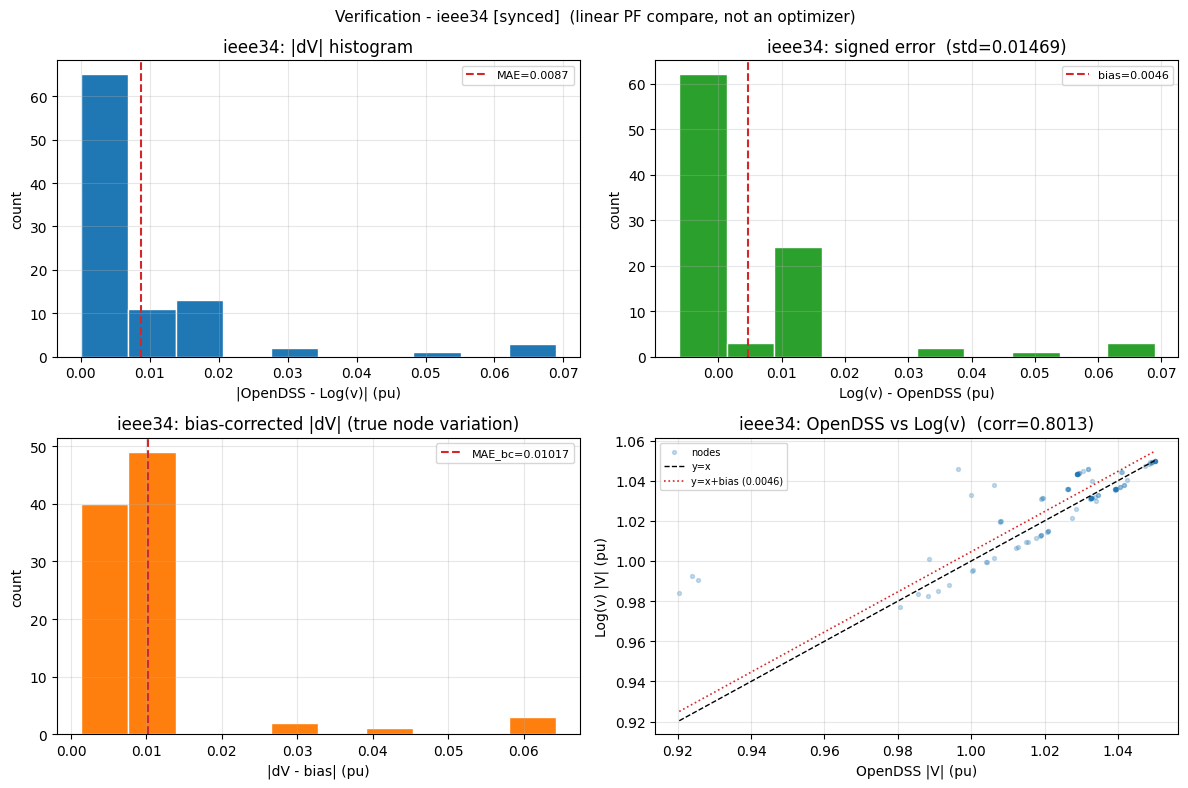

<Figure size 1600x800 with 0 Axes>

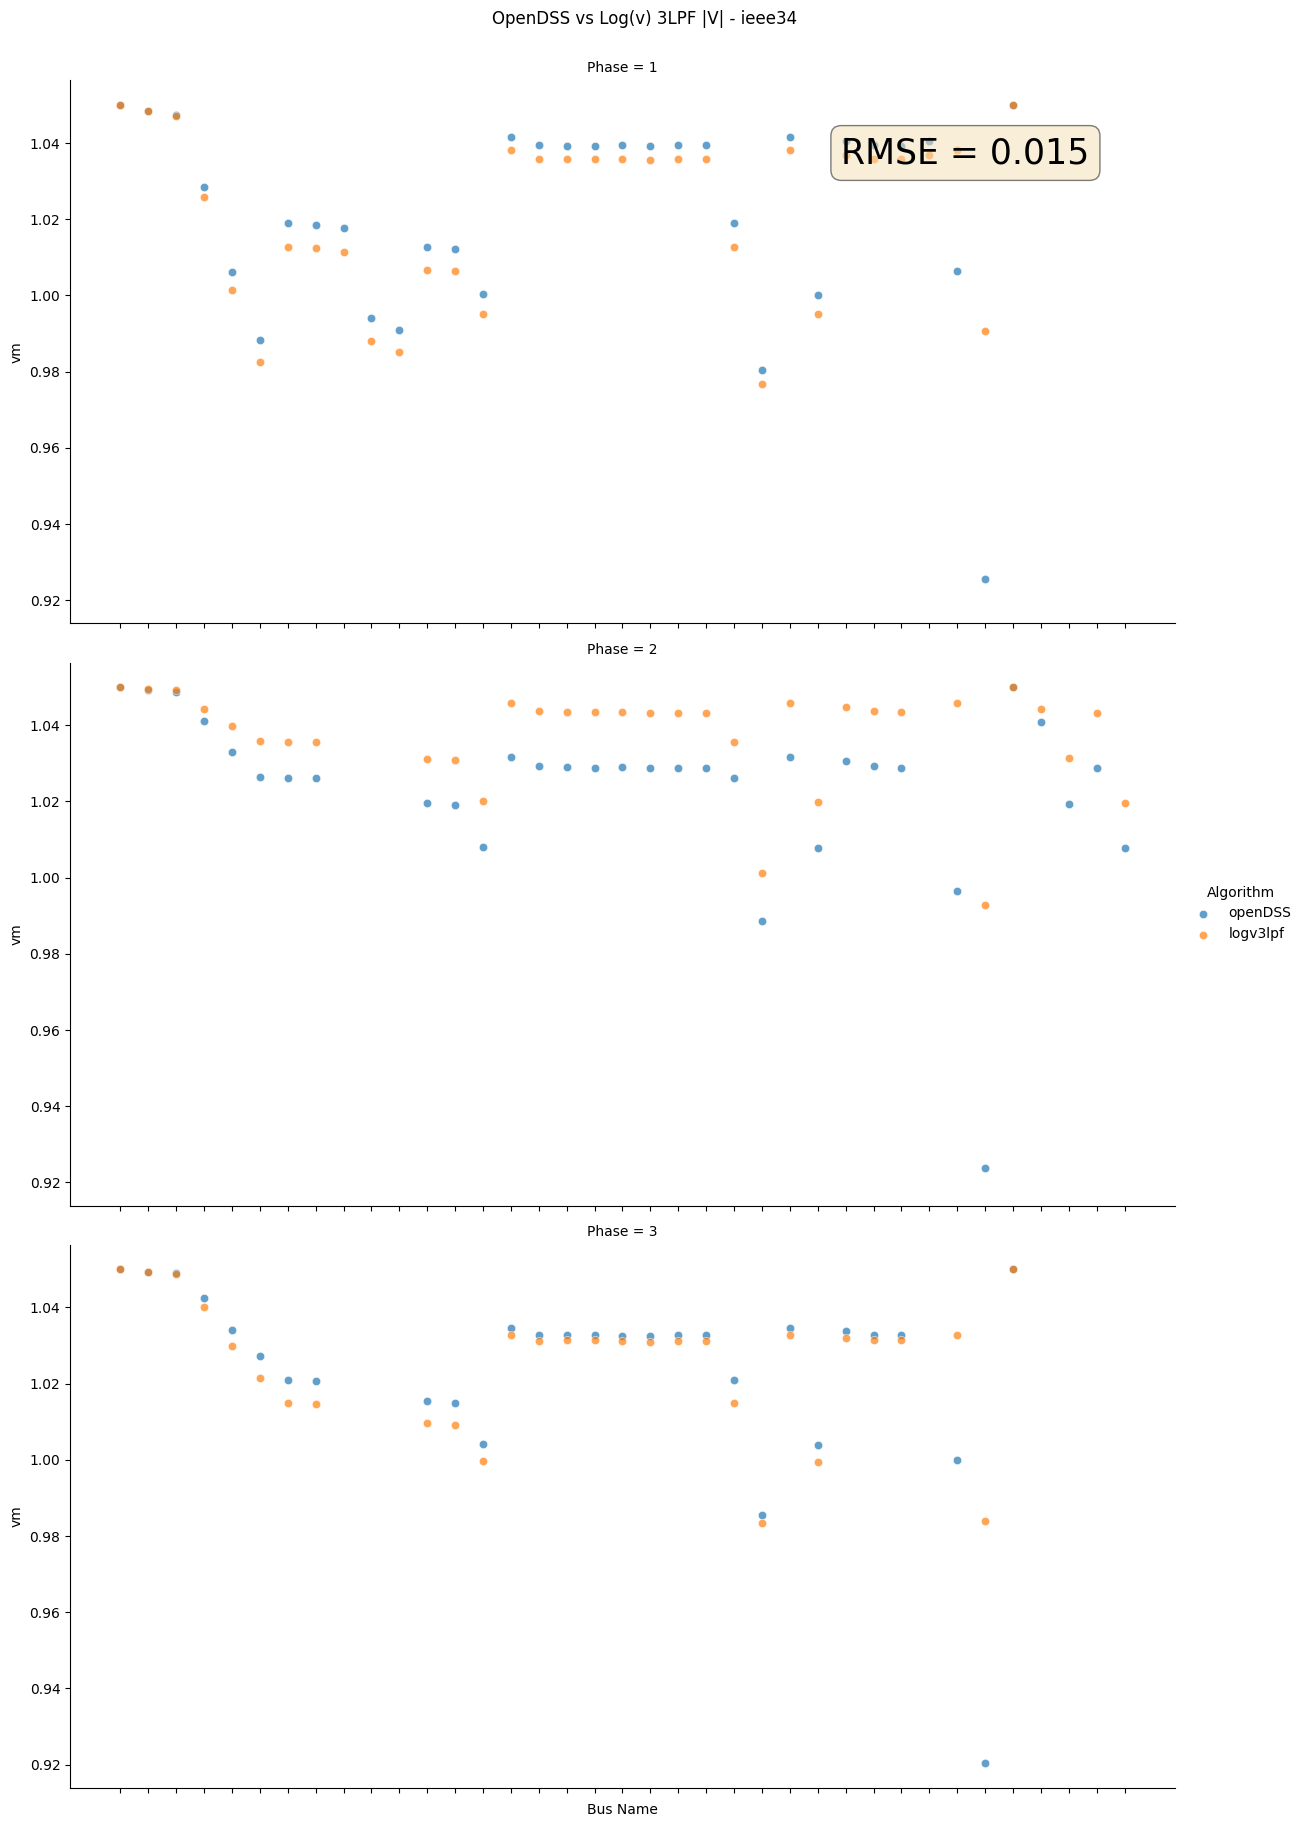

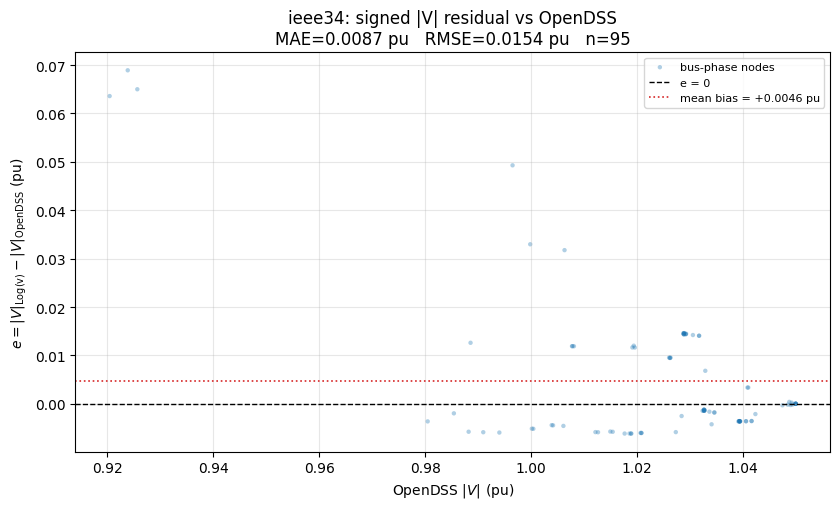

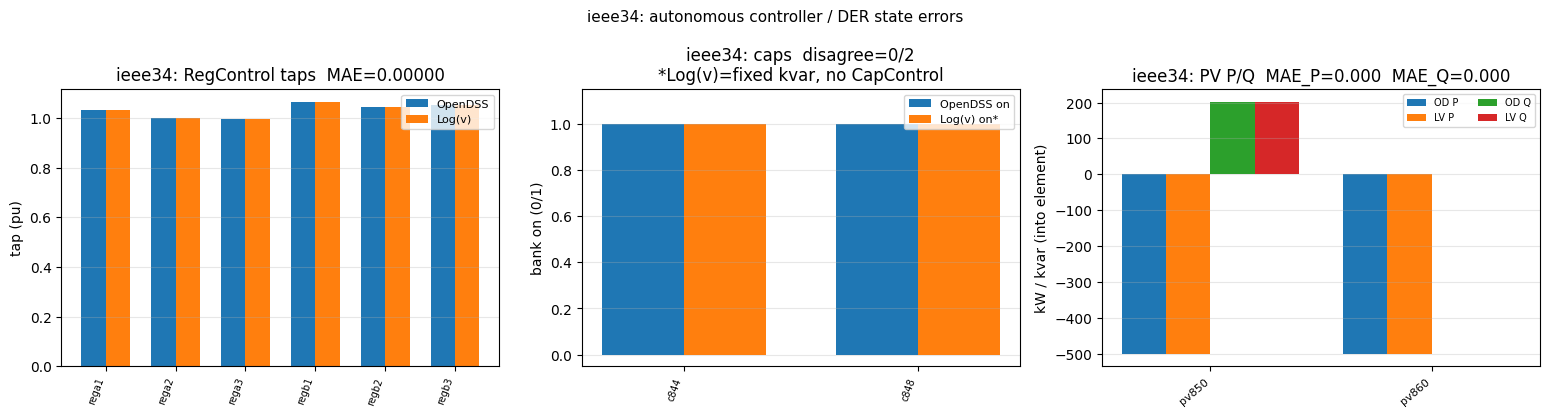

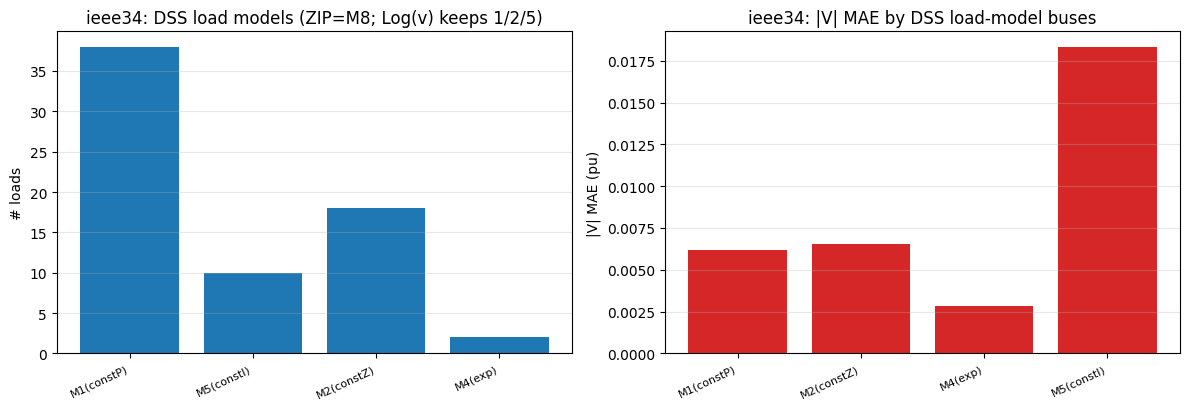


ACCURACY SUMMARY (SNAPSHOT)  feeder=ieee34  mode=synced
  |V| RMSE (pu)  : 0.015409598707416166
  |V| MAPE (%)   : 0.8763302304895875
  angle RMSE deg : 4.185254841177516
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer subxf is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


Nodes =  95
k =  130
Complexity of KLU decomposition, 4.72e+06 FLOPS 
Complexity of LogV algorithm, 1.30e+07 FLOPS 
Ratio 0.36
DAILY OpenDSS vs Log(v)  feeder=ieee34  mode=synced  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  plot nodes: ['890.1', '844.1', '840.1', '814r.1', '852r.1']
  regs: ['reg_rega1_tap_pu', 'reg_rega2_tap_pu', 'reg_rega3_tap_pu', 'reg_regb1_tap_pu', 'reg_regb2_tap_pu', 'reg_regb3_tap_pu']
  caps: ['c844', 'c848']
  load models: M1 constP×36, M2 constZ×20, M4 exp×2, M5 constI×12
  time_speed (FastLogv): True
  OD cold snapshot probe: InitSnap+Solve after metrics (ControlMode=Static; extra probe only — not primary OD metric)
  OpenDSS primary metric: snapshot Solve() only (Method A buckets)
  fair Fast protocol: bake OD taps into A on change; Fast voltages -> metrics/plots (synced/off)
  profile: native DSS loadshapes -> explicit kW/kvar each step (snapshot); plot distal LV buses (source-end bus 1 i

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "ieee34"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "synced"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=ieee34  CONTROL_MODE=static  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


AUDIT - what this cell actually ran
  feeder          : ieee34
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
    - PVSystems -> negative const-P loads (no InvControl in Log(v)).
    - Paper Table II FLOPs are inverse-update estimates; wall-clock

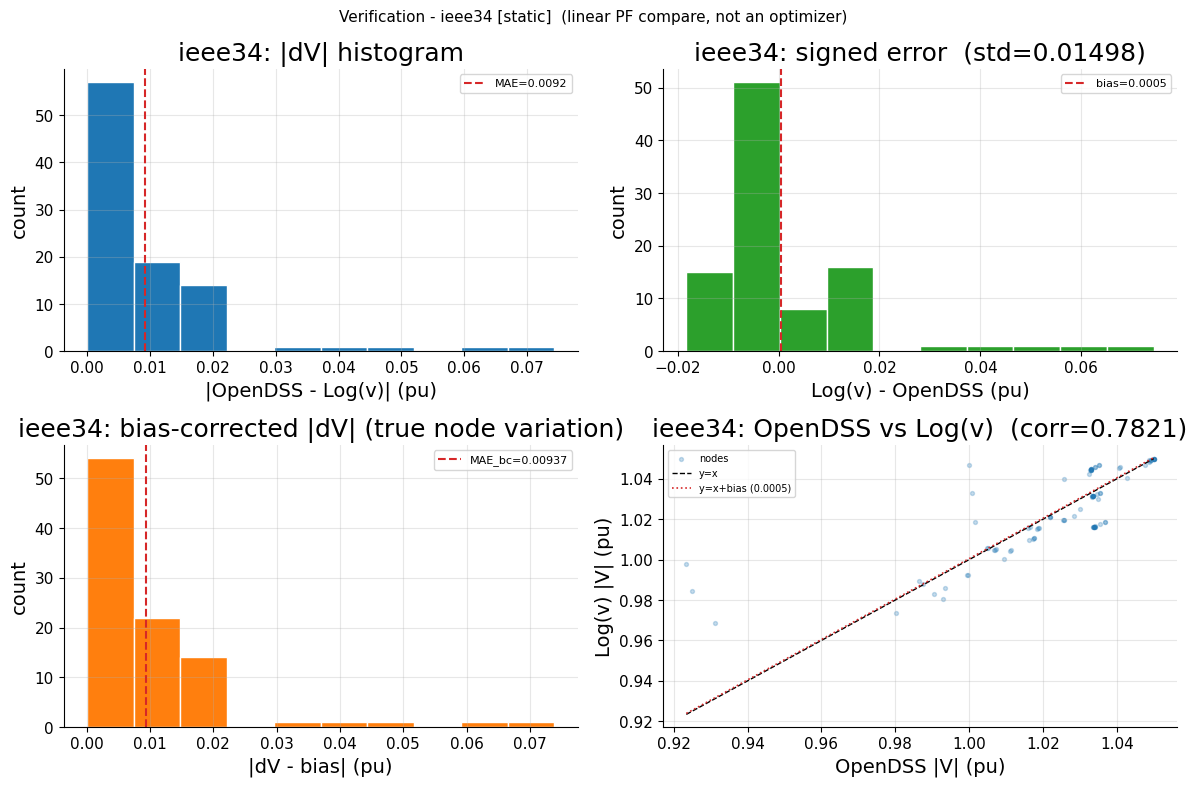

<Figure size 1600x800 with 0 Axes>

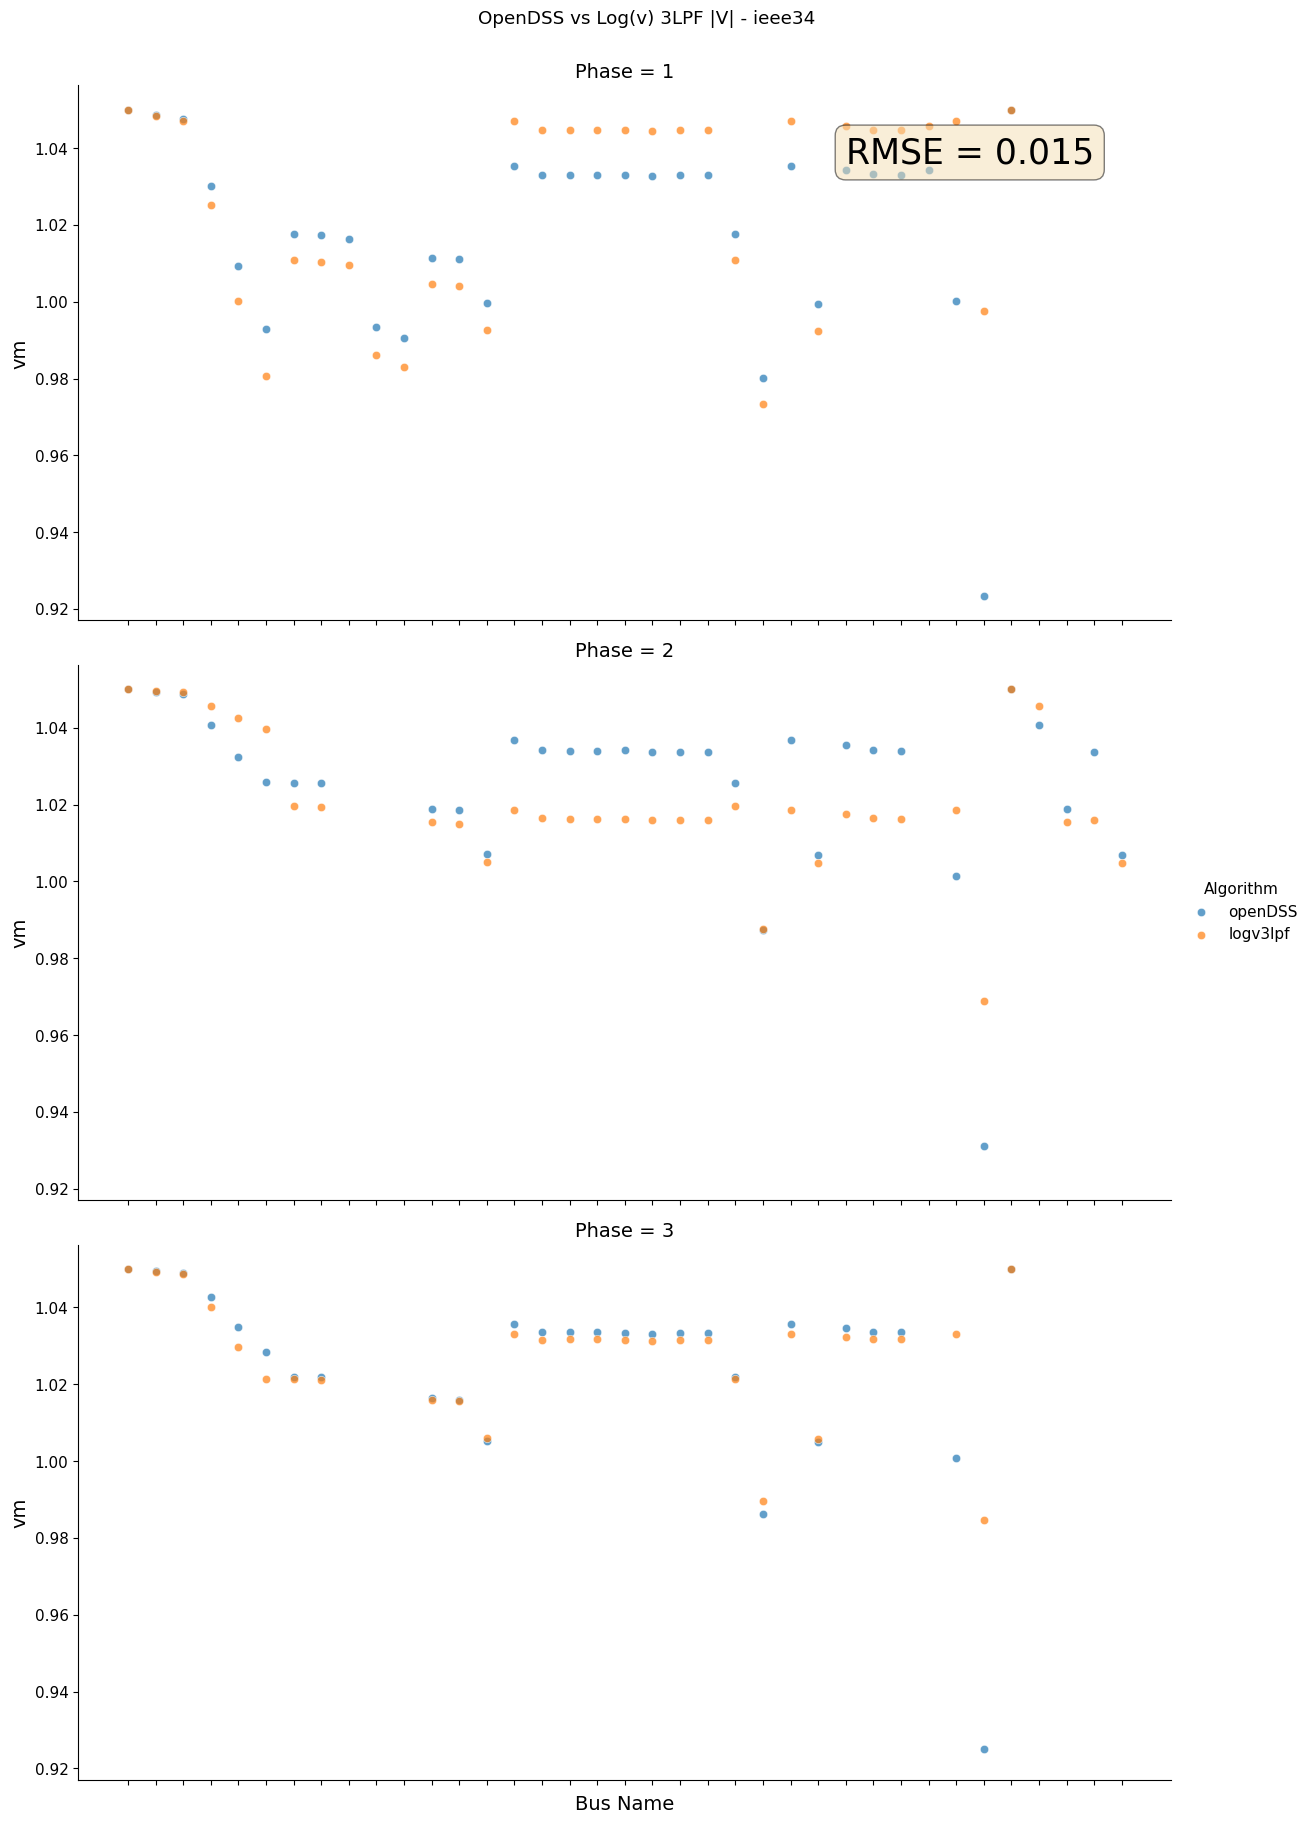

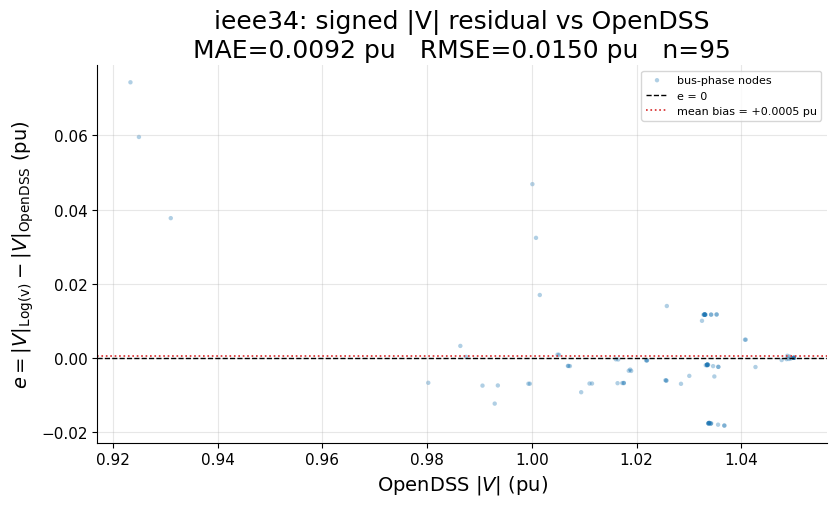

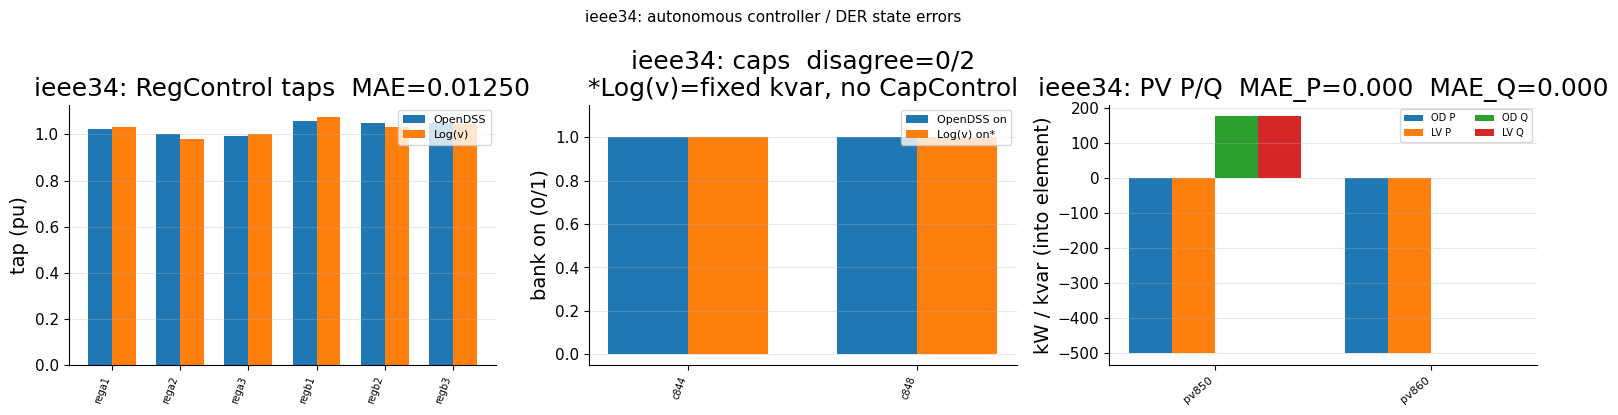

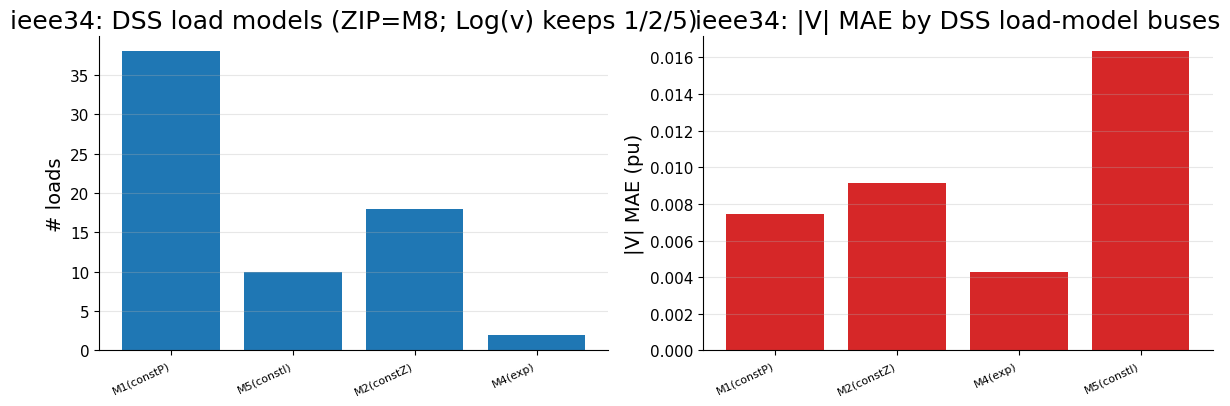


ACCURACY SUMMARY (SNAPSHOT)  feeder=ieee34  mode=static
  |V| RMSE (pu)  : 0.014991073186793465
  |V| MAPE (%)   : 0.9149047285603247
  angle RMSE deg : 3.887646948230946
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer subxf is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices


C:\Users\alita\OneDrive\Desktop\GNN2\Log-v-3LPF\logv3lpf\DSSParser.py:50: UserWarning: Log(v) remapped 2 load(s) with unsupported OpenDSS model id(s) → model 1 (const-P). Original ids preserved in loads.dss_model. Paper-faithful ZIP is only models 1/2/5.
  DSScase.get_loads_from_dss(self)


Nodes =  95
k =  130
Complexity of KLU decomposition, 4.72e+06 FLOPS 
Complexity of LogV algorithm, 1.30e+07 FLOPS 
Ratio 0.36
DAILY OpenDSS vs Log(v)  feeder=ieee34  mode=static  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
  plot nodes: ['890.1', '844.1', '840.1', '814r.1', '852r.1']
  regs: ['reg_rega1_tap_pu', 'reg_rega2_tap_pu', 'reg_rega3_tap_pu', 'reg_regb1_tap_pu', 'reg_regb2_tap_pu', 'reg_regb3_tap_pu']
  caps: ['c844', 'c848']
  load models: M1 constP×36, M2 constZ×20, M4 exp×2, M5 constI×12
  time_speed (FastLogv): True
  OD cold snapshot probe: InitSnap+Solve after metrics (ControlMode=Static; extra probe only — not primary OD metric)
  OpenDSS primary metric: snapshot Solve() only (Method A buckets)
  note: static Fast is init-A probe only; plots/metrics use stock autonomous Log(v)
  profile: native DSS loadshapes -> explicit kW/kvar each step (snapshot); plot distal LV buses (source-end bus 1 is nearly flat

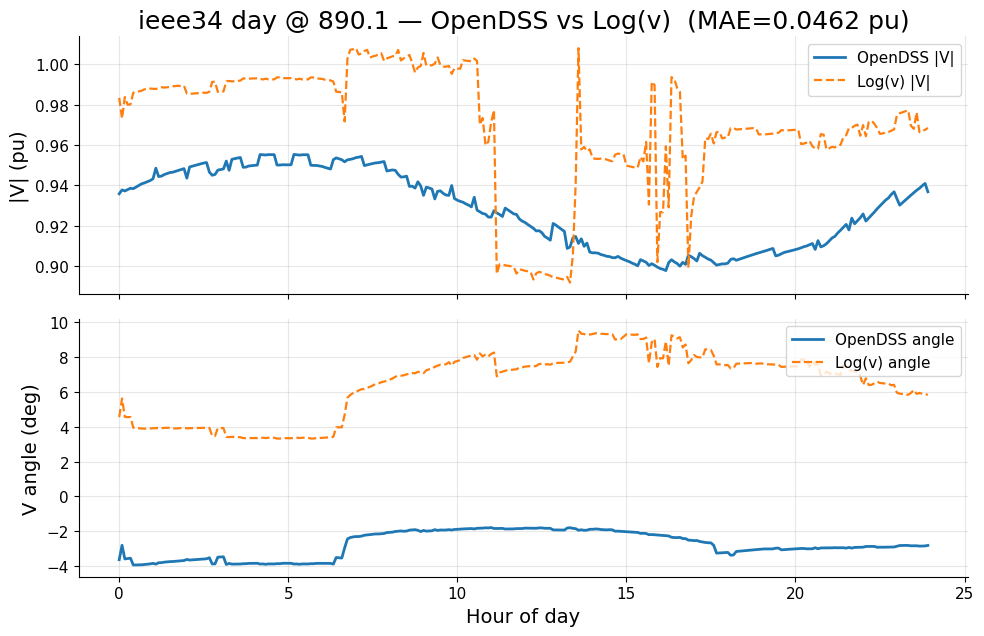

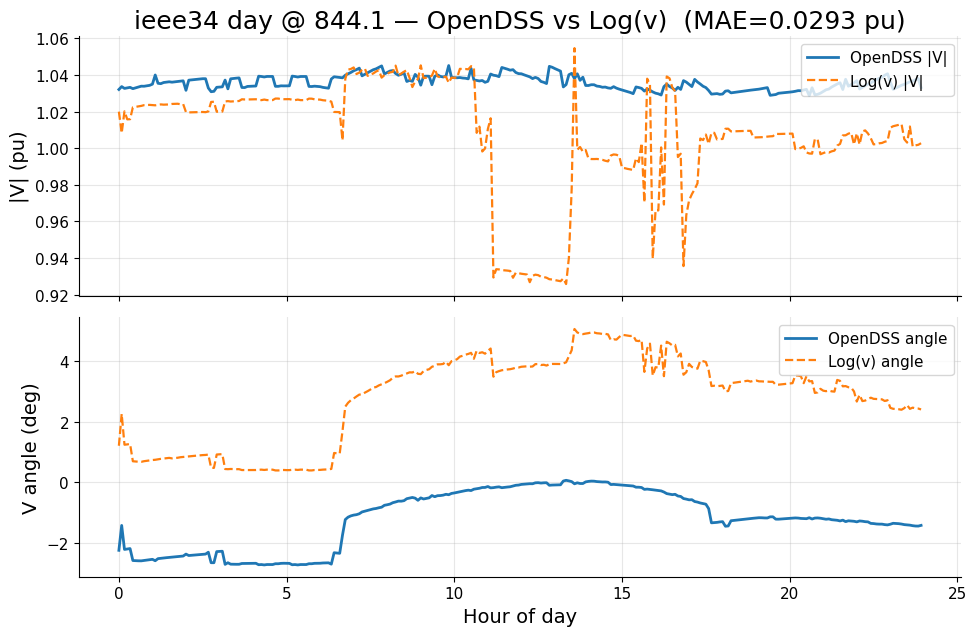

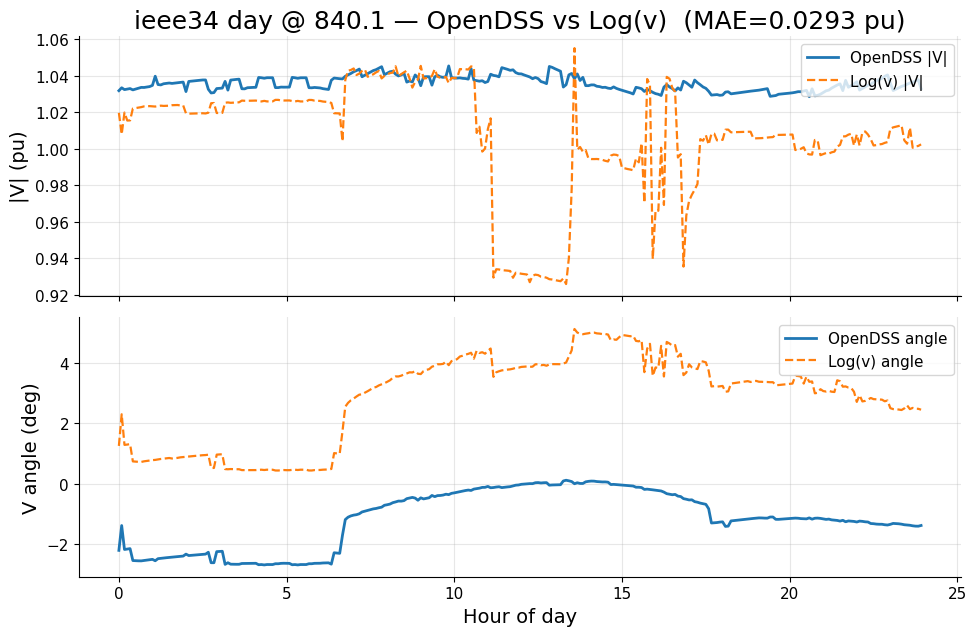

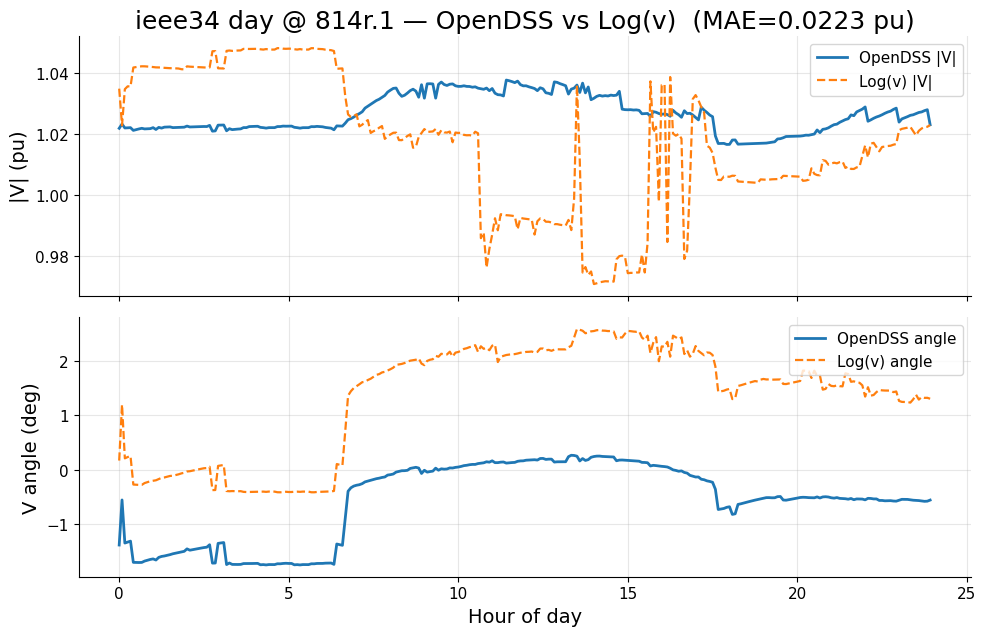

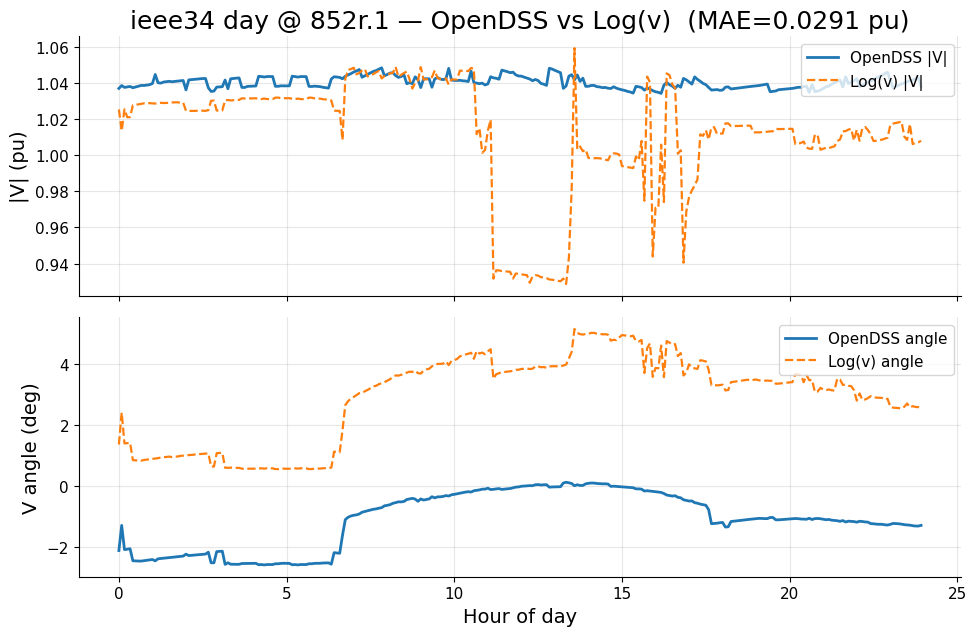

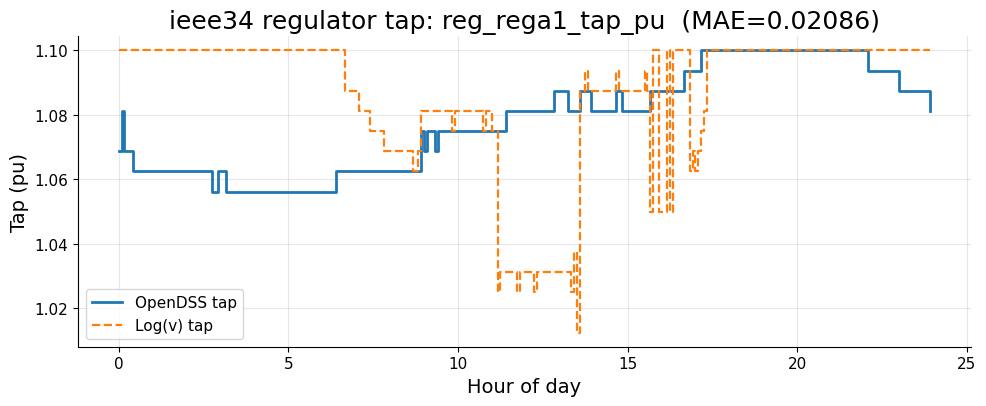

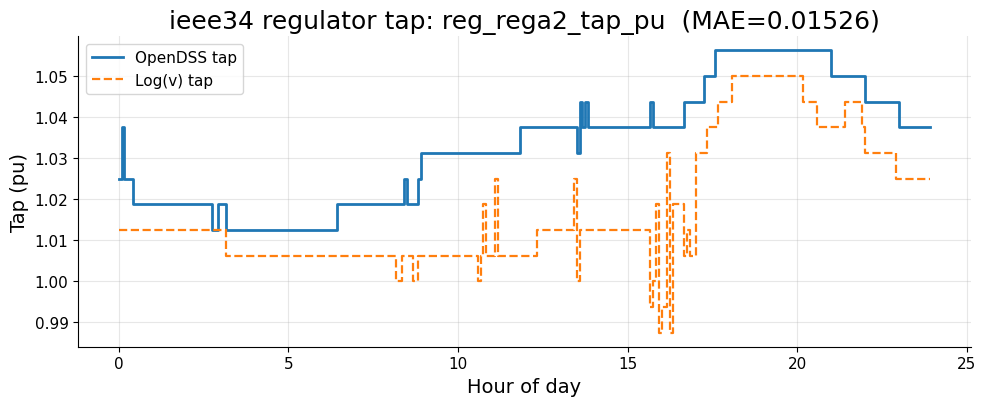

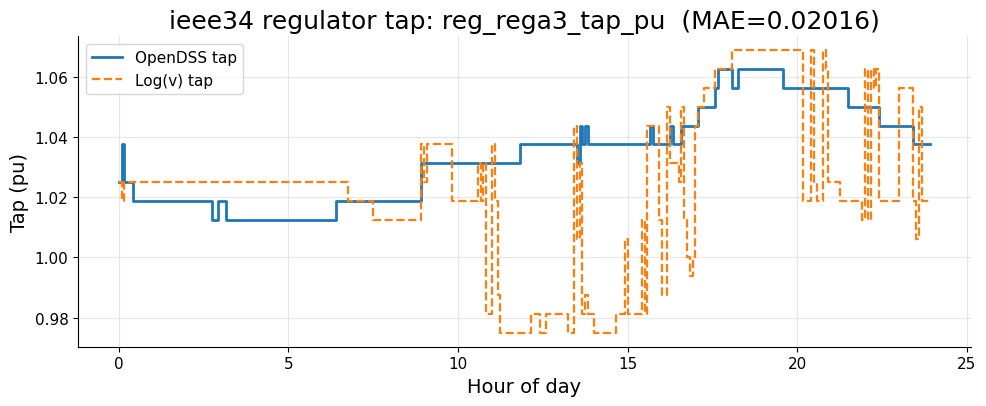

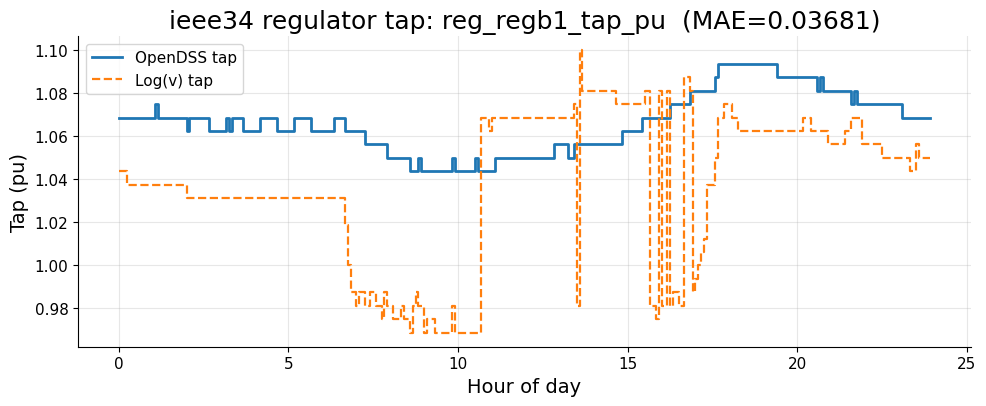

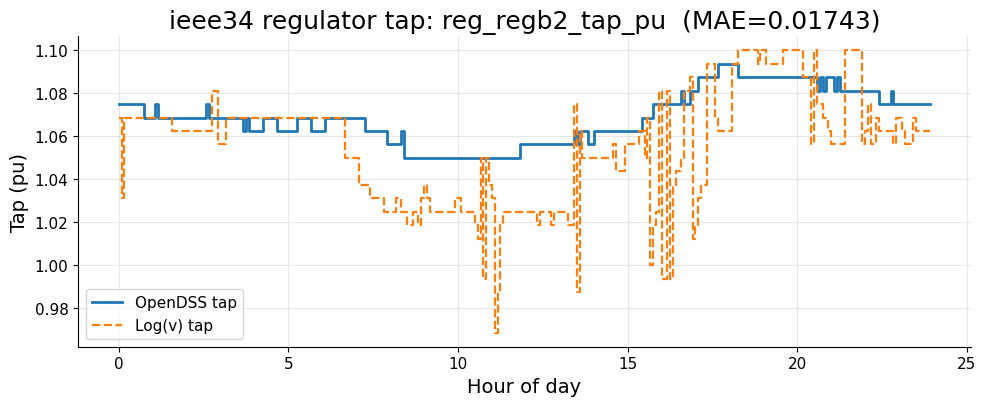

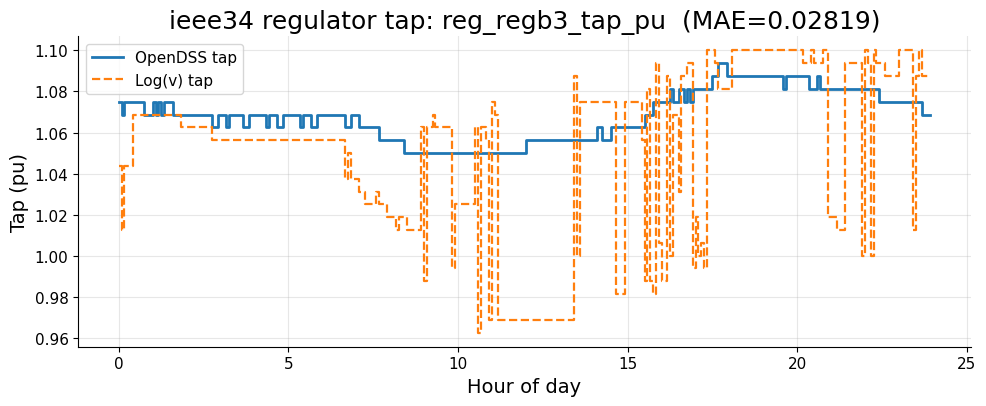

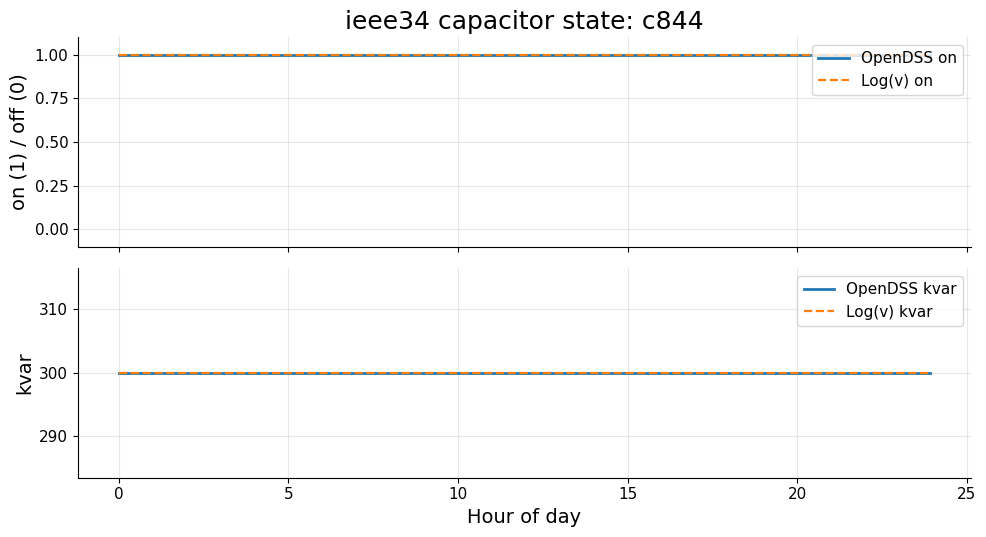

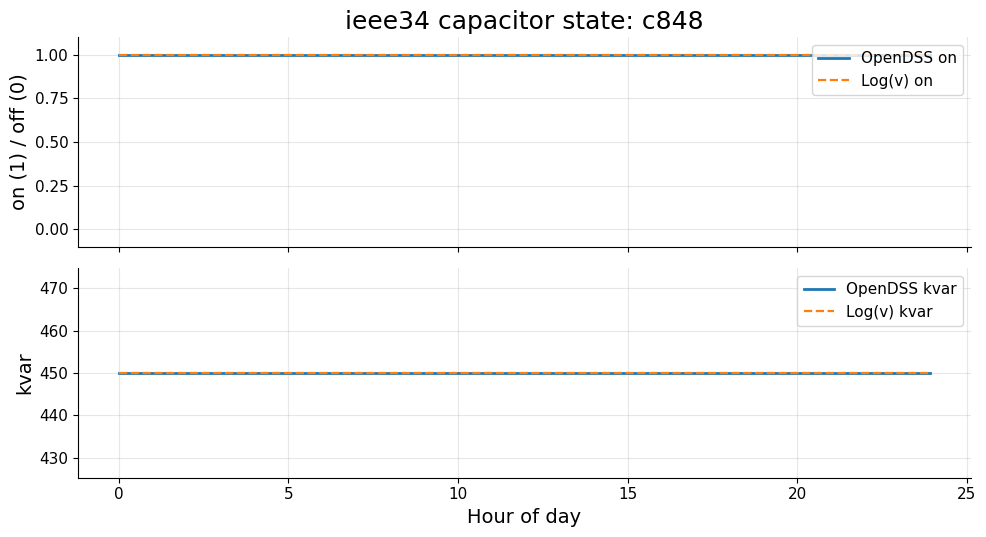

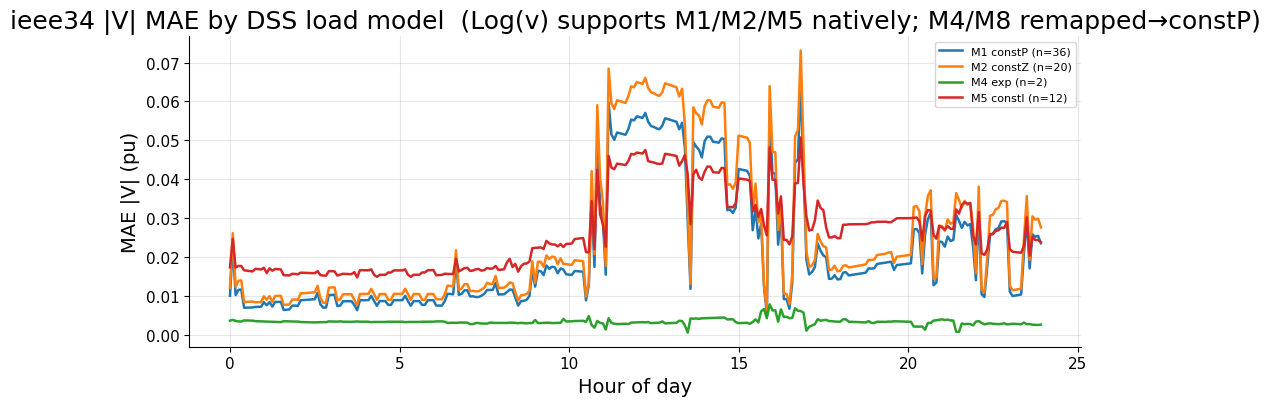

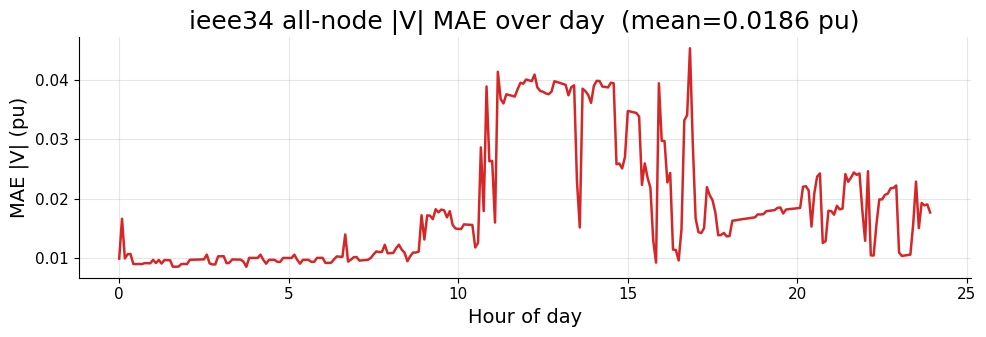

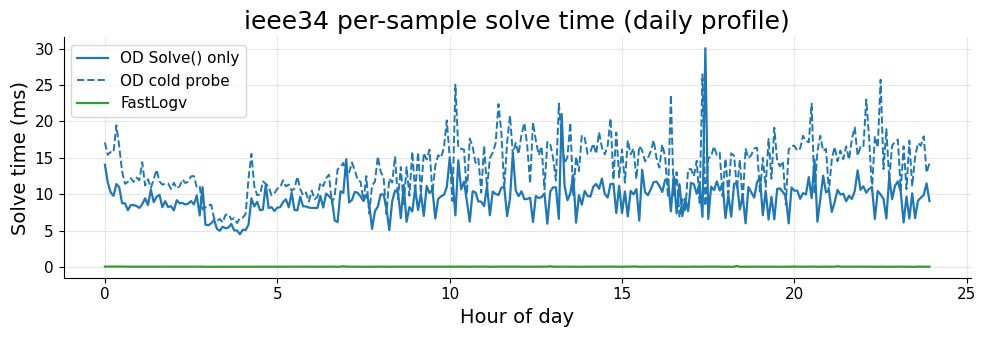


ACCURACY SUMMARY (DAILY)  feeder=ieee34  mode=static
  samples ok     : 288/288  (bad=0)
  mean |V| MAE   : 0.018590 pu
  mean |V| RMSE  : 0.025579 pu
  max  |V| MAE   : 0.045281 pu
  wall           : 1119.1 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_ieee34_mode_static_npts288_metrics.csv

SPEED SUMMARY (DAILY)  feeder=ieee34   <--- use MEAN numbers
  N samples ok    : 288
  logv source     : stock  fair_fast=False
  A rebuilds      : 0
  |V| MAE mean    : 0.018590 pu  (median 0.015661, max 0.045281)
  OD warm mean    : 9.431 ms  (median 9.654)
  OD cold mean    : 13.758 ms  (median 14.247)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 3840.671 ms
  FastLogv mean   : 0.048 ms  (median 0.049)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  mean OD_warm/Fast: 194.70x
  mean OD_cold/Fast: 284.03x  <--- fair cold compare
  note: static probe — F

(<logv3lpf.run_case.case at 0x1bbbad5c910>,
 {'mae': 0.009175370604878014,
  'rmse': 0.014991073186793465,
  'max': 0.07432466620158151,
  'n': 95,
  'control_mode': 'static',
  'n_reg': 6,
  'reg_iters': 2,
  'tap_mae': 0.012500000000000048,
  'paper_accuracy': {'n_phase_nodes': 95,
   'vm_rmse_pu': 0.014991073186793465,
   'vm_mape_pct': 0.9149047285603247,
   'vm_mae_pu': 0.009175370604878014,
   'va_rmse_deg': 3.887646948230946,
   'va_rmse_deg_global_aligned': 2.081705576893908,
   'va_source_offset_deg': -0.00019490872228781578,
   'vsource_angle_deg': 30.0},
  'paper_flops': {'n_bus_phases': 95.0,
   'n_excl_source': 92.0,
   'n_source_phases': 3.0,
   'n_sys': 190.0,
   'k': 130.0,
   'k_load_phases': 47.0,
   'k_cap_phases': 6.0,
   'k_reg_phases': 12.0,
   'k_reg_primary_phases': 6.0,
   'k_woodbury_U': 106.0,
   'n_regulators': 6.0,
   'opendss_lu_flops': 4717066.0,
   'opendss_lu_flops_excl_source': 4288426.0,
   'logv_woodbury_update_flops': 13049230.0,
   'logv_apply_flop

In [19]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "ieee34"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "static"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=906  CONTROL_MODE=synced  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4
AUDIT - what this cell actually ran
  feeder          : 906
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load model

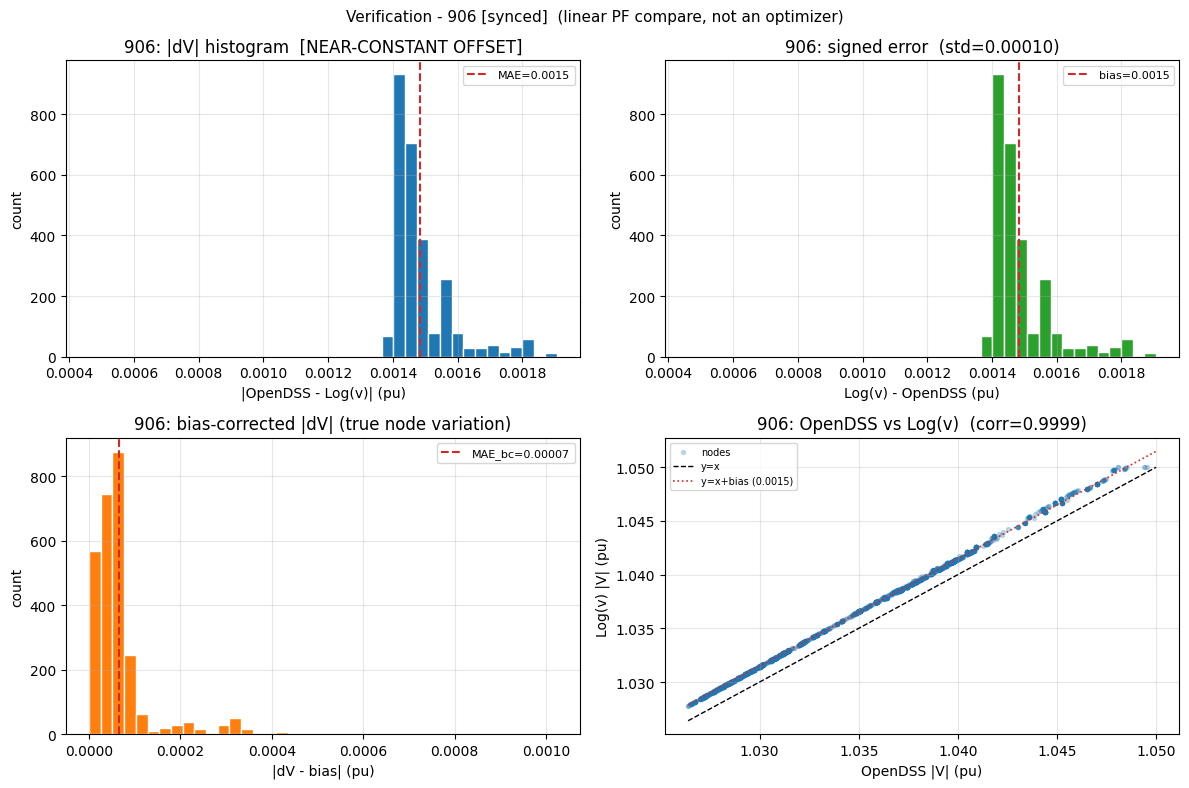

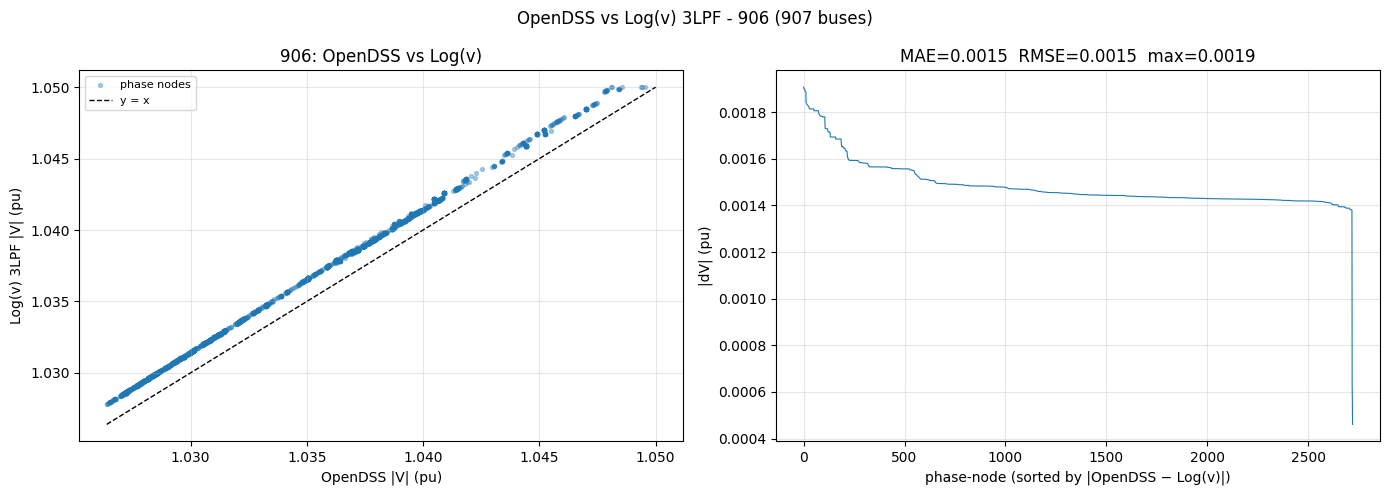

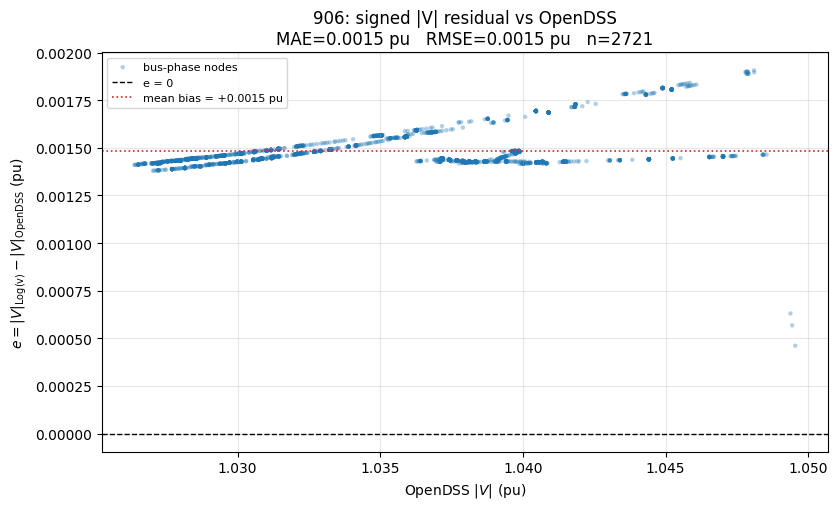


ACCURACY SUMMARY (SNAPSHOT)  feeder=906  mode=synced
  |V| RMSE (pu)  : 0.0014882088706001388
  |V| MAPE (%)   : 0.14345725286626854
  angle RMSE deg : 0.20104696817184936
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Transformer tr1 is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  2721
k =  0
Complexity of KLU decomposition, 1.08e+11 FLOPS 
Complexity of LogV algorithm, 2.96e+07 FLOPS 
DAILY OpenDSS vs Log(v)  feeder=906  mode=synced  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  plot nodes: ['817.1', '860.1', '896.1', '906.1']
  regs: (none)
  caps: (none)
  load models: M1 constP×55
  time_speed (FastLogv): True

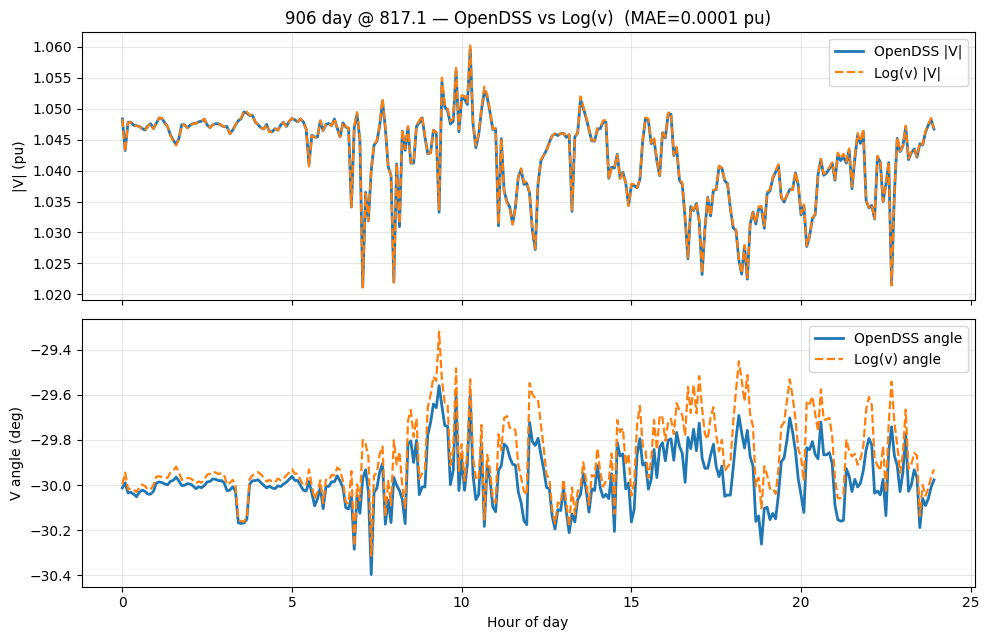

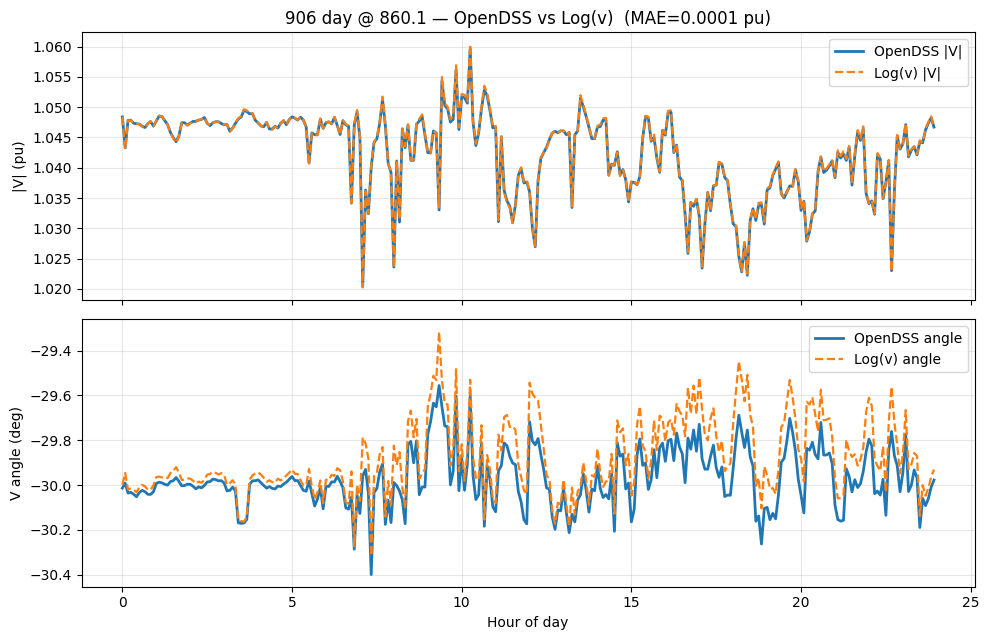

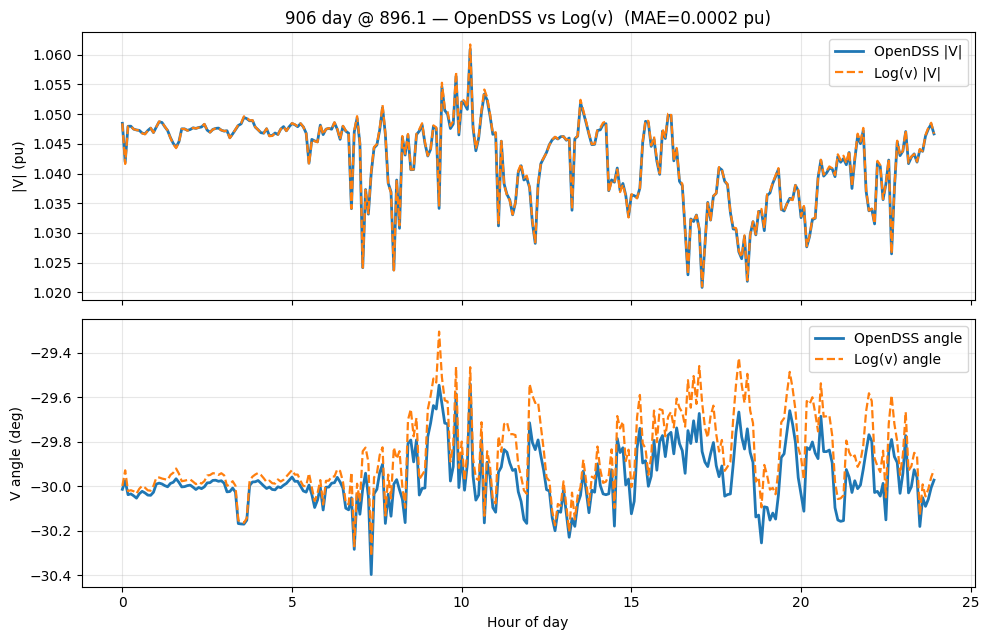

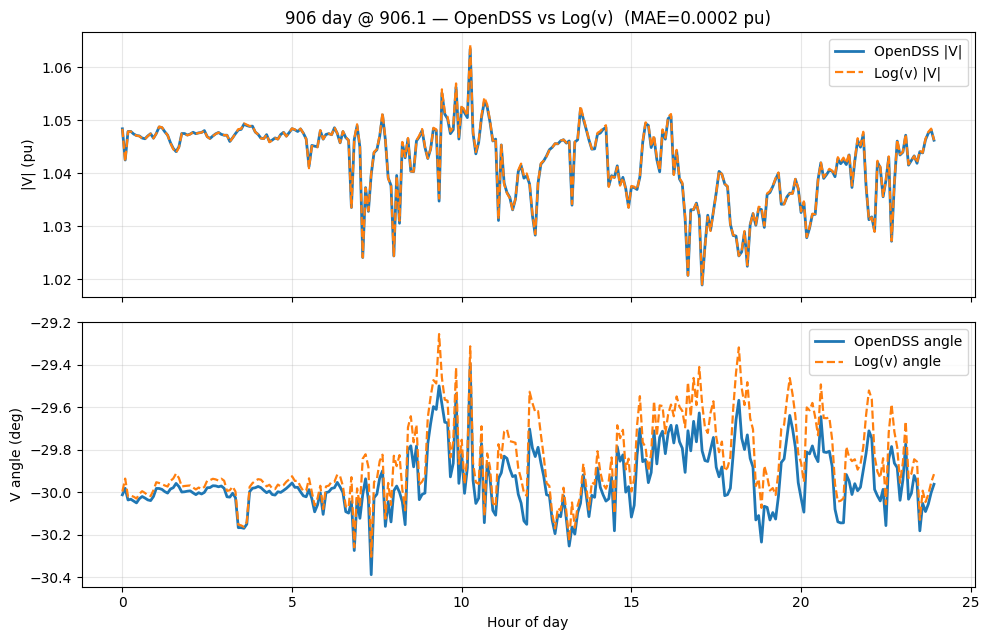

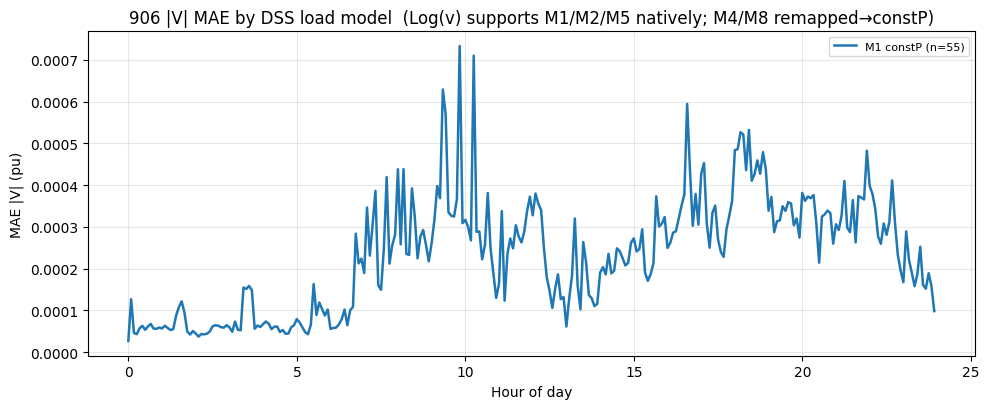

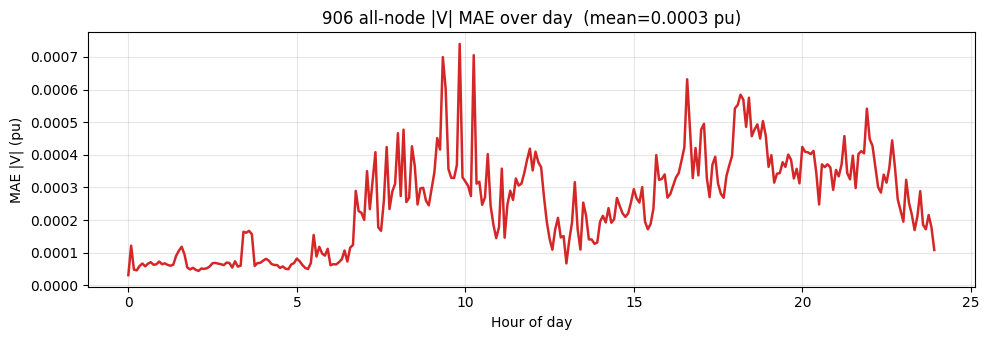

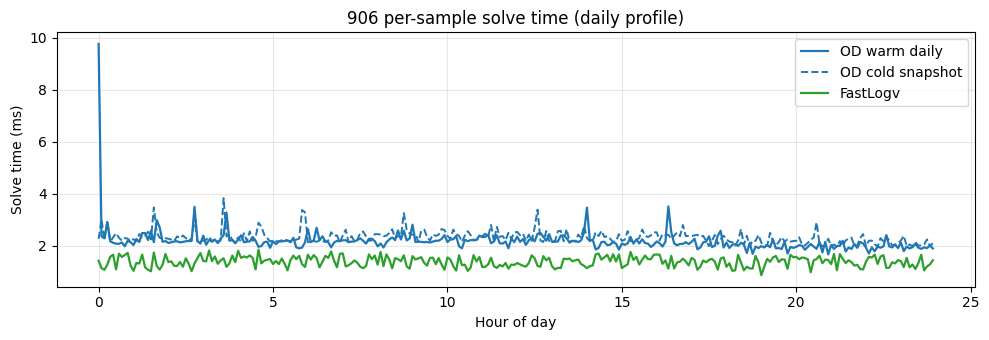


ACCURACY SUMMARY (DAILY)  feeder=906  mode=synced
  samples ok     : 288/288  (bad=0)
  mean |V| MAE   : 0.000252 pu
  mean |V| RMSE  : 0.000291 pu
  max  |V| MAE   : 0.000740 pu
  wall           : 44.1 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_906_mode_synced_npts288_metrics.csv

SPEED SUMMARY (DAILY)  feeder=906   <--- use MEAN numbers
  N samples ok    : 288
  logv source     : fast  fair_fast=True
  A rebuilds      : 1
  |V| MAE mean    : 0.000252 pu  (median 0.000257, max 0.000740)
  OD warm mean    : 2.181 ms  (median 2.143)
  OD cold mean    : 2.323 ms  (median 2.271)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 46.786 ms
  FastLogv mean   : 1.389 ms  (median 1.400)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  Fast refresh mean: 197.084 ms  (n=1; outside Fast timer)
  mean OD_warm/Fast: 1.57x
  mean OD_cold/Fast: 1.67x  <--- fair

(<logv3lpf.run_case.case at 0x27c51e39250>,
 {'mae': 0.0014849760382257301,
  'rmse': 0.0014882088706001388,
  'max': 0.0019070265757819005,
  'n': 2721,
  'control_mode': 'synced',
  'n_reg': 0,
  'reg_iters': 0,
  'tap_mae': nan,
  'paper_accuracy': {'n_phase_nodes': 2721,
   'vm_rmse_pu': 0.0014882088706001388,
   'vm_mape_pct': 0.14345725286626854,
   'vm_mae_pu': 0.0014849760382257301,
   'va_rmse_deg': 0.20104696817184936,
   'va_rmse_deg_global_aligned': 0.028450004077618506,
   'va_source_offset_deg': -0.04777777317052786,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 2721.0,
   'n_excl_source': 2718.0,
   'n_source_phases': 3.0,
   'n_sys': 5442.0,
   'k': 0.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 0.0,
   'k_reg_phases': 0.0,
   'k_reg_primary_phases': 0.0,
   'k_woodbury_U': 0.0,
   'n_regulators': 0.0,
   'opendss_lu_flops': 107563002048.0,
   'opendss_lu_flops_excl_source': 107207748288.0,
   'logv_woodbury_update_flops': 0.0,
   'logv_apply_flops_l

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "906"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "synced"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=906  CONTROL_MODE=static  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4


AUDIT - what this cell actually ran
  feeder          : 906
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
    - PVSystems -> negative const-P loads (no InvControl in Log(v)).
    - Pap

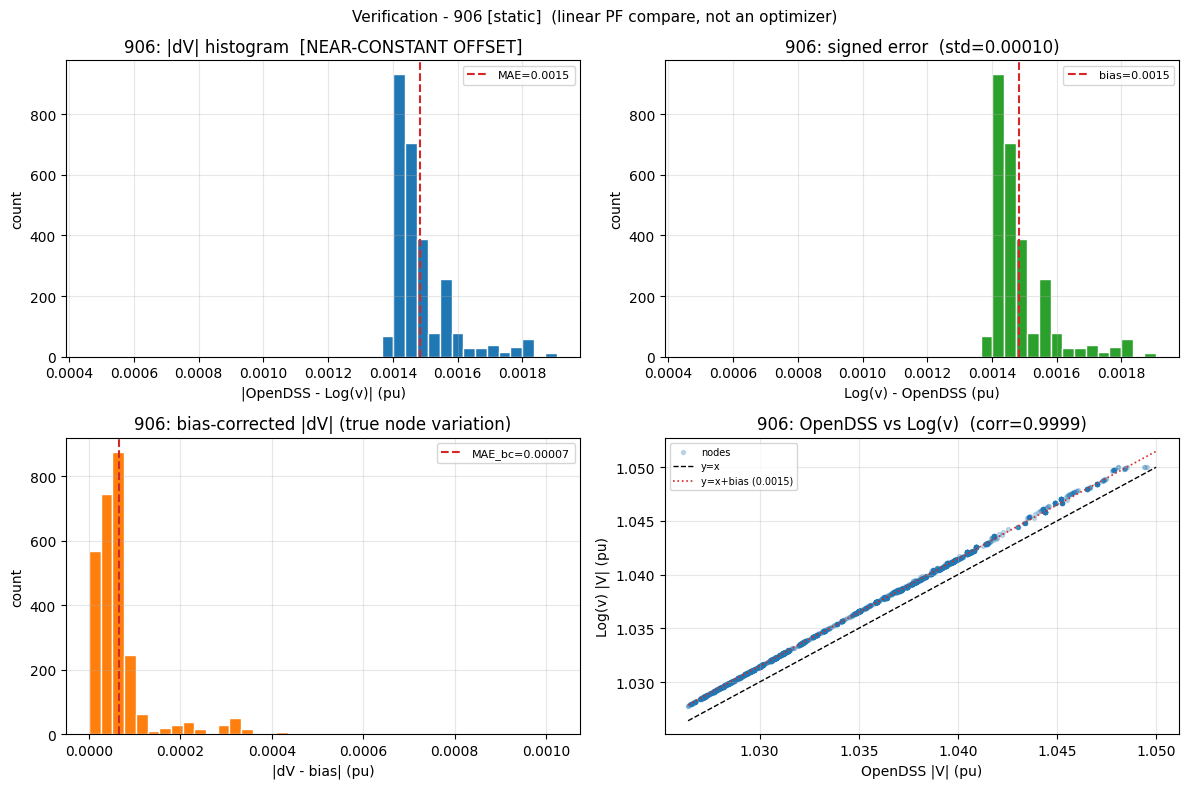

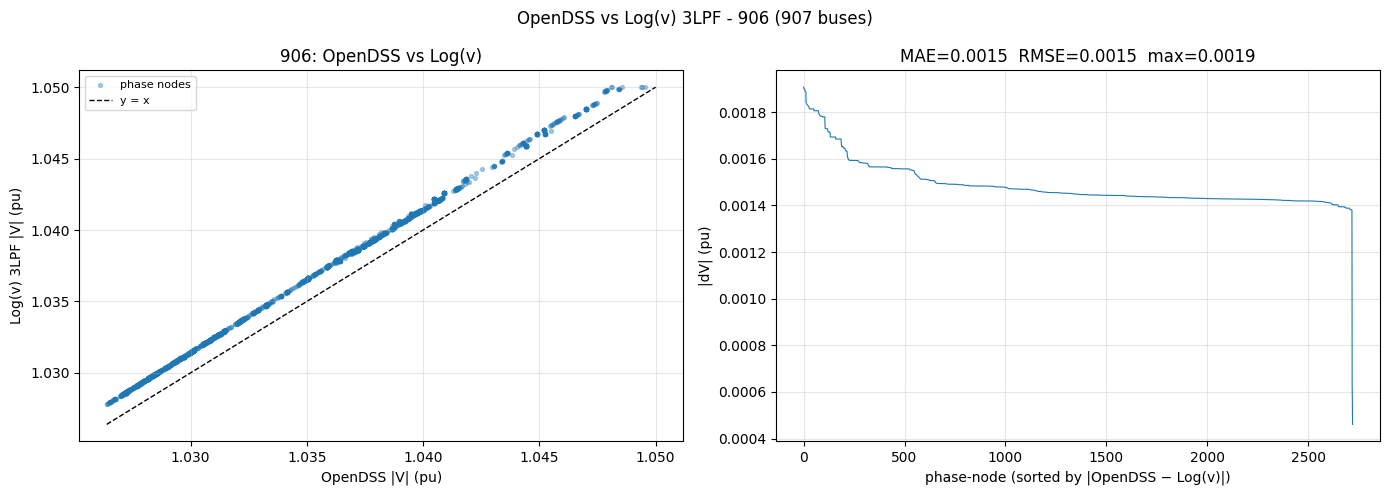

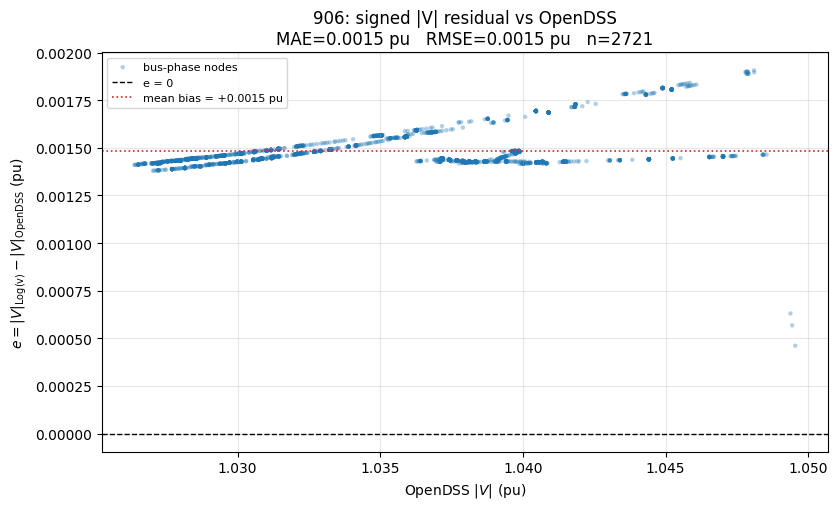


ACCURACY SUMMARY (SNAPSHOT)  feeder=906  mode=static
  |V| RMSE (pu)  : 0.0014882088706001388
  |V| MAPE (%)   : 0.14345725286626854
  angle RMSE deg : 0.20104696817184936
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Transformer tr1 is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  2721
k =  0
Complexity of KLU decomposition, 1.08e+11 FLOPS 
Complexity of LogV algorithm, 2.96e+07 FLOPS 
DAILY OpenDSS vs Log(v)  feeder=906  mode=static  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase\Master_snapshot.dss
  plot nodes: ['817.1', '860.1', '896.1', '906.1']
  regs: (none)
  caps: (none)
  load models: M1 constP×55
  time_speed (FastLogv): True

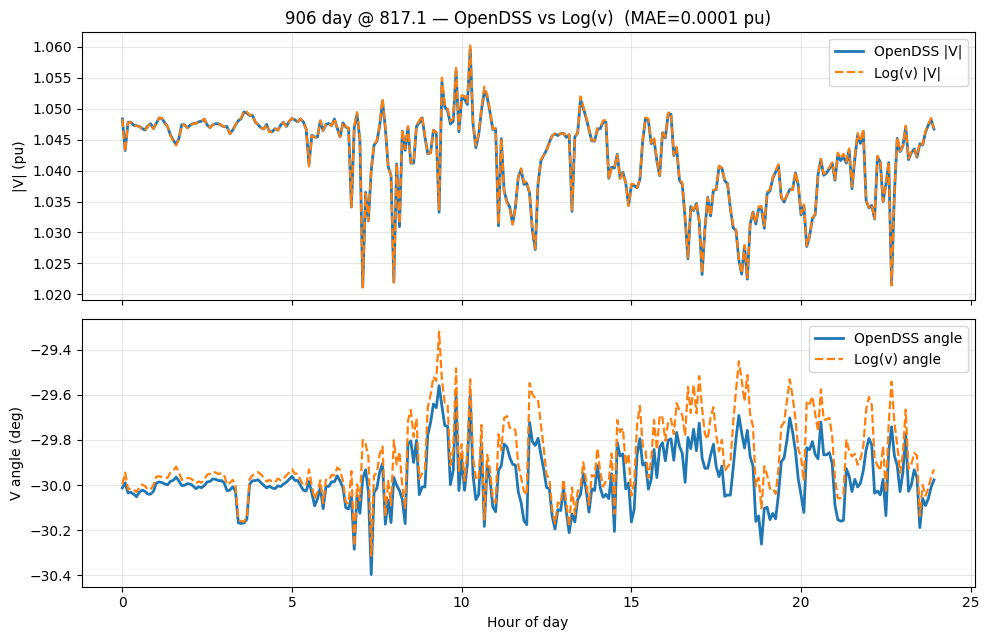

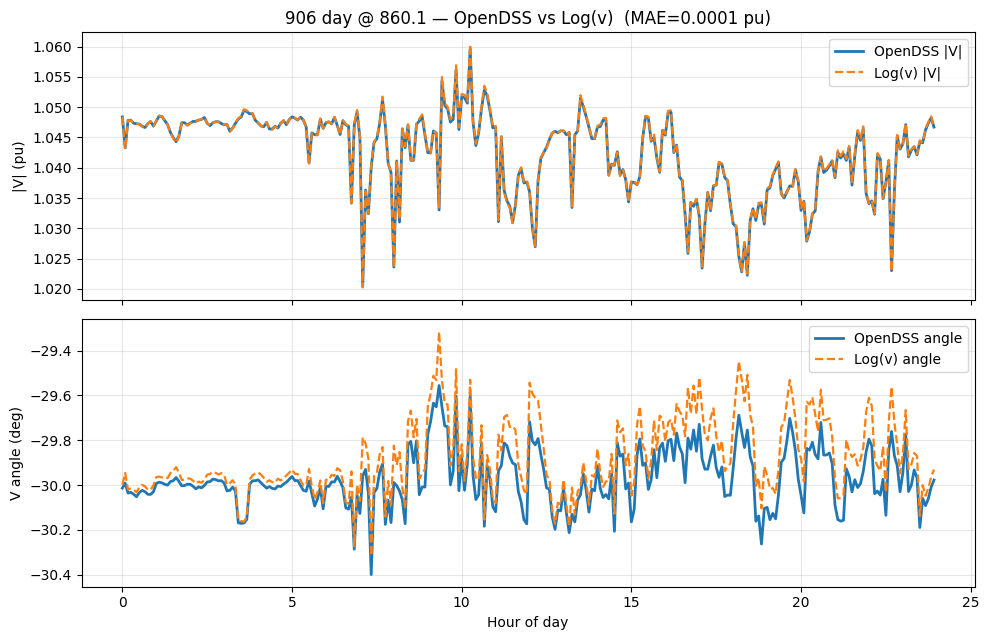

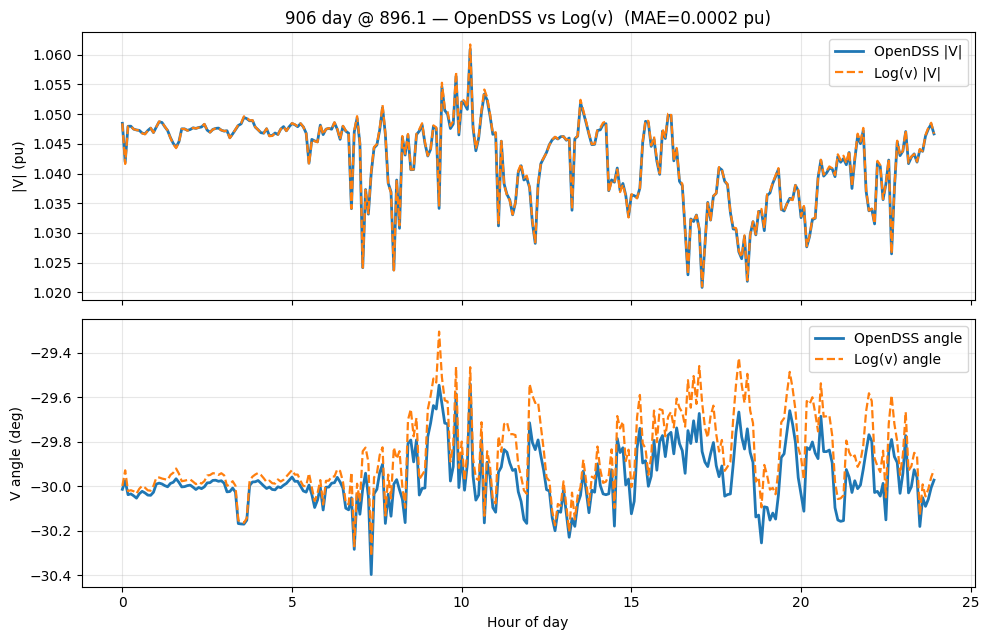

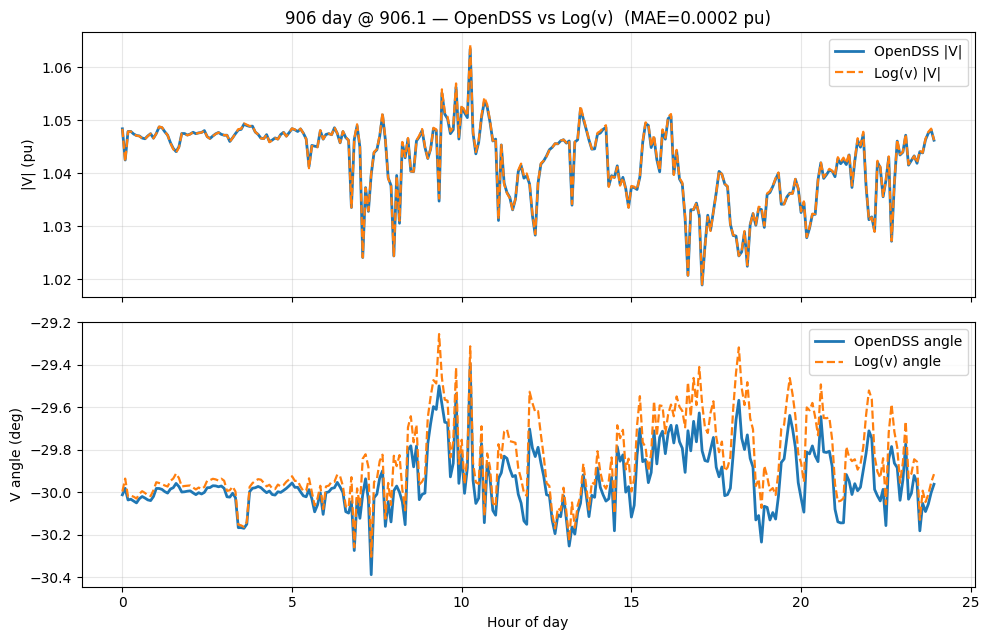

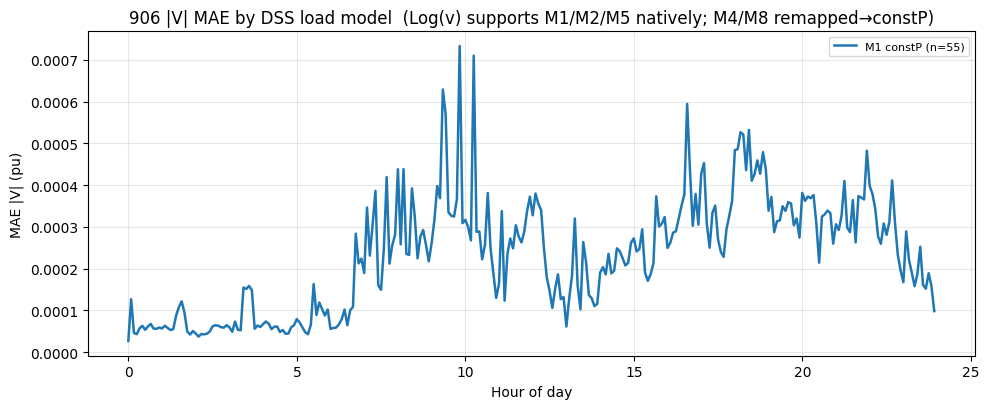

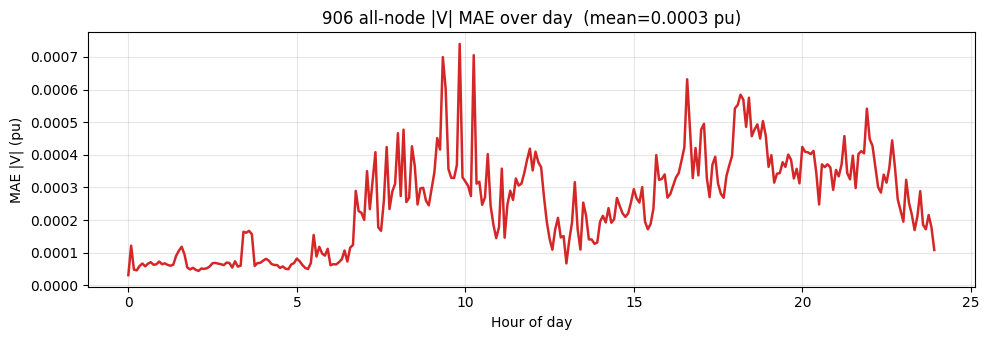

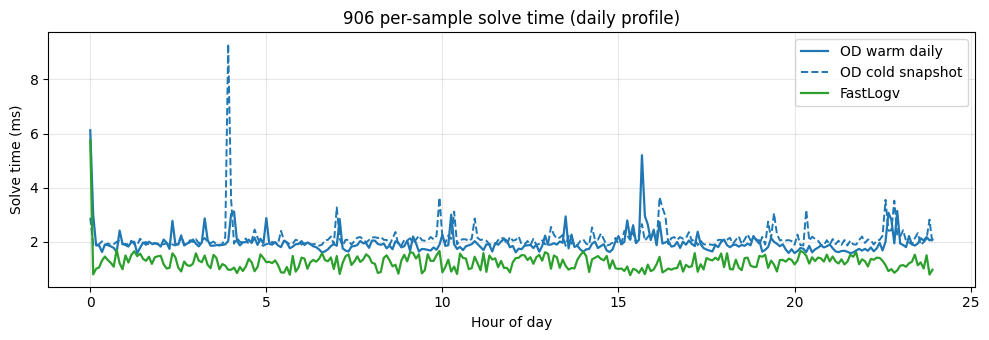


ACCURACY SUMMARY (DAILY)  feeder=906  mode=static
  samples ok     : 288/288  (bad=0)
  mean |V| MAE   : 0.000252 pu
  mean |V| RMSE  : 0.000291 pu
  max  |V| MAE   : 0.000740 pu
  wall           : 31.1 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_906_mode_static_npts288_metrics.csv

SPEED SUMMARY (DAILY)  feeder=906   <--- use MEAN numbers
  N samples ok    : 288
  logv source     : stock  fair_fast=False
  A rebuilds      : 0
  |V| MAE mean    : 0.000252 pu  (median 0.000257, max 0.000740)
  OD warm mean    : 1.961 ms  (median 1.888)
  OD cold mean    : 2.127 ms  (median 2.046)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 42.746 ms
  FastLogv mean   : 1.249 ms  (median 1.265)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  mean OD_warm/Fast: 1.57x
  mean OD_cold/Fast: 1.70x  <--- fair cold compare
  note: static probe — Fast uses init A; pl

(<logv3lpf.run_case.case at 0x27c55b64550>,
 {'mae': 0.0014849760382257301,
  'rmse': 0.0014882088706001388,
  'max': 0.0019070265757819005,
  'n': 2721,
  'control_mode': 'static',
  'n_reg': 0,
  'reg_iters': 0,
  'tap_mae': nan,
  'paper_accuracy': {'n_phase_nodes': 2721,
   'vm_rmse_pu': 0.0014882088706001388,
   'vm_mape_pct': 0.14345725286626854,
   'vm_mae_pu': 0.0014849760382257301,
   'va_rmse_deg': 0.20104696817184936,
   'va_rmse_deg_global_aligned': 0.028450004077618506,
   'va_source_offset_deg': -0.04777777317052786,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 2721.0,
   'n_excl_source': 2718.0,
   'n_source_phases': 3.0,
   'n_sys': 5442.0,
   'k': 0.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 0.0,
   'k_reg_phases': 0.0,
   'k_reg_primary_phases': 0.0,
   'k_woodbury_U': 0.0,
   'n_regulators': 0.0,
   'opendss_lu_flops': 107563002048.0,
   'opendss_lu_flops_excl_source': 107207748288.0,
   'logv_woodbury_update_flops': 0.0,
   'logv_apply_flops_l

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "906"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "static"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=8500  CONTROL_MODE=synced  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=24  STEP_MIN=60.0  DAY=4
AUDIT - what this cell actually ran
  feeder          : 8500
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  control_mode    : synced

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
 

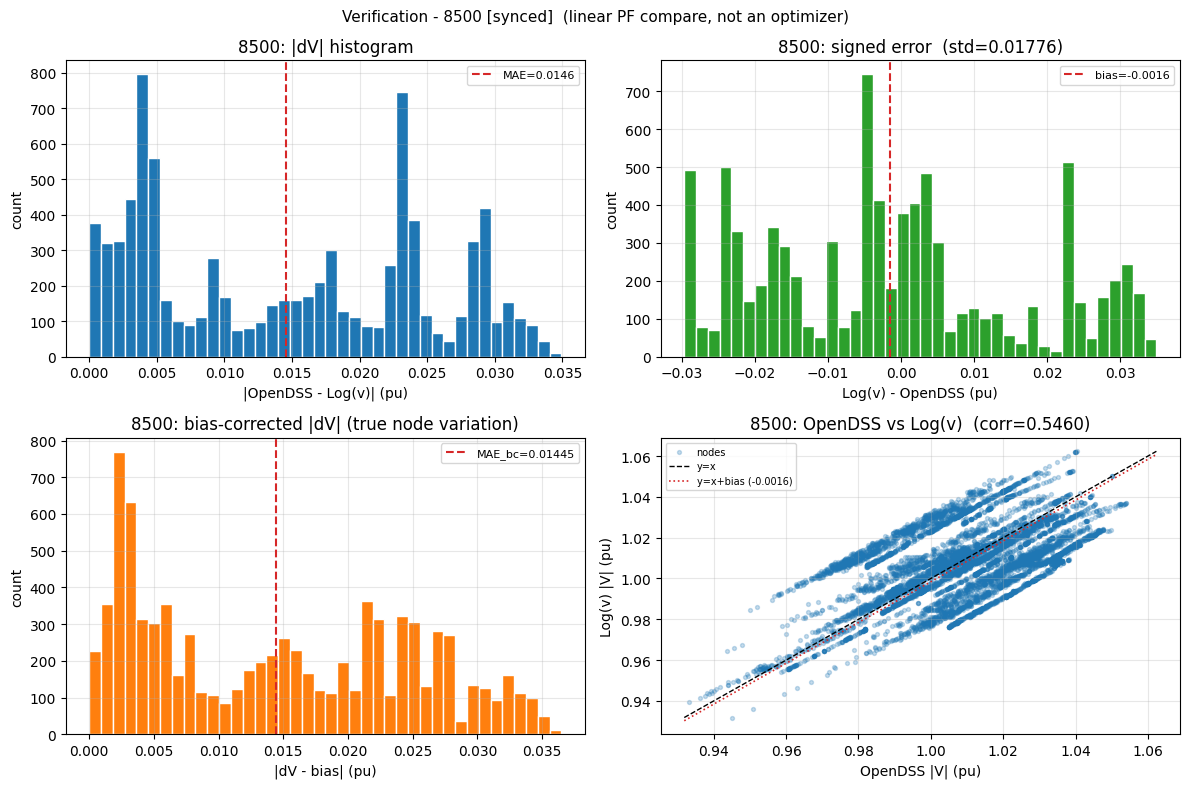

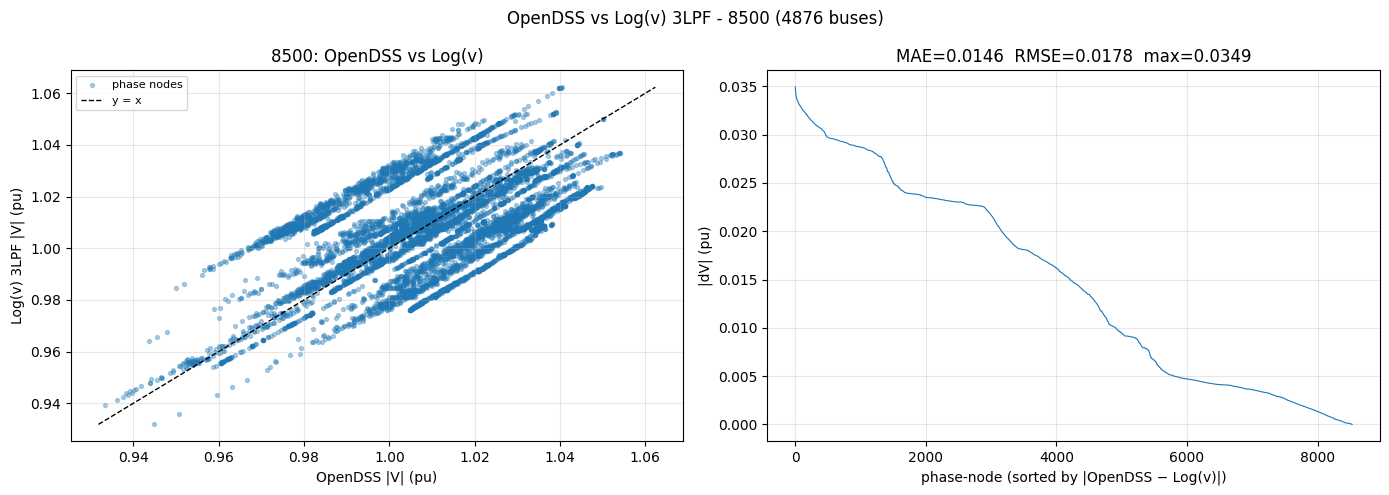

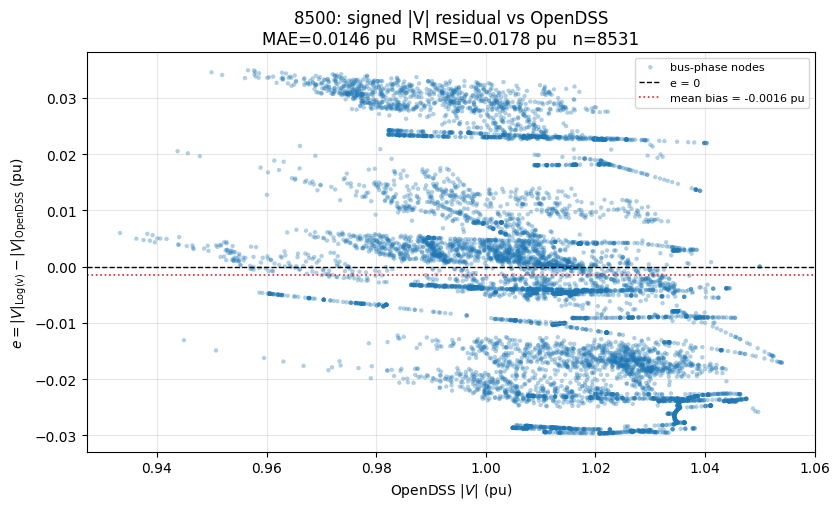

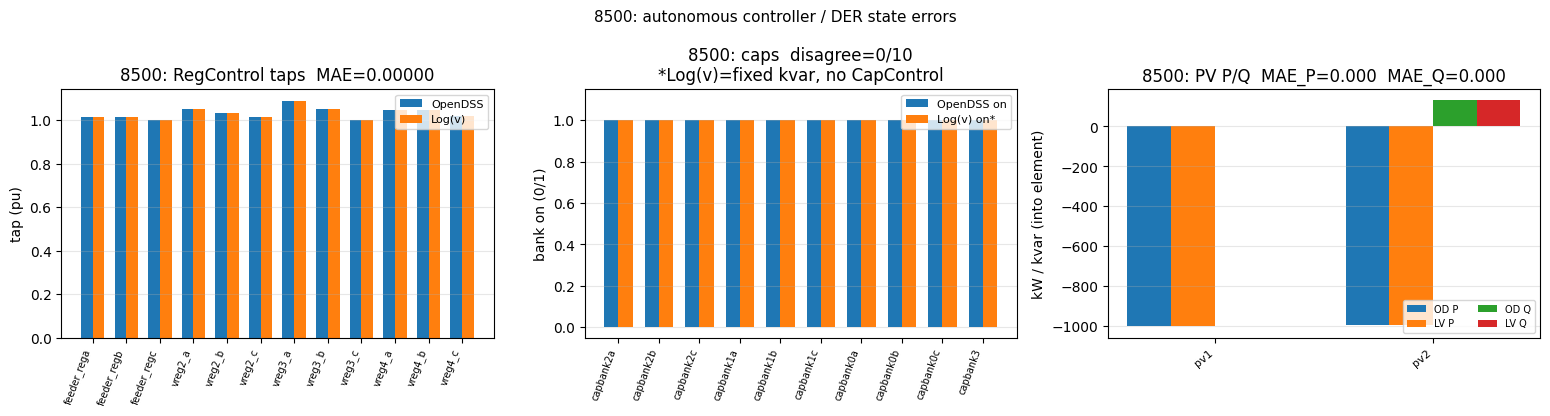


ACCURACY SUMMARY (SNAPSHOT)  feeder=8500  mode=synced
  |V| RMSE (pu)  : 0.017825269783593157
  |V| MAPE (%)   : 1.4444790793157125
  angle RMSE deg : 2.3062047325785326
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer hvmv_sub is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  8534
k =  72
Complexity of KLU decomposition, 3.32e+12 FLOPS 
Complexity of LogV algorithm, 4.69e+08 FLOPS 
Ratio 7064.29


c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DAILY OpenDSS vs Log(v)  feeder=8500  mode=synced  npts=24  step=60.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  plot nodes: ['l2841632.1', '190-8593.1']
  regs: ['reg_vreg3_a_tap_pu', 'reg_feeder_rega_tap_pu', 'reg_vreg2_a_tap_pu']
  caps: ['capbank0a', 'capbank1a', 'capbank2a', 'capbank3']
  load models: M1 constP×2354
  time_speed (FastLogv): True
  OD cold snapshot probe: InitSnap+Solve after metrics (ControlMode=Static; extra probe only — not primary OD metric)
  OpenDSS primary metric: snapshot Solve() only (Method A buckets)
  fair Fast protocol: bake OD taps into A on change; Fast voltages -> metrics/plots (synced/off)
  profile: 8500 representative-day CSV -> explicit kW/kvar (snapshot)
Solving base case logv3lpf...
Bus 193-48013, phase mismatch
Bus 193-51796, phase mismatch
Bus e182745, phase mismatch
  [1/24] apply=0.01s reassert=0.00s solve=0.47s getV=0.06s  |V| MAE=0.01421  LV=403.8ms  Fast=5.4ms
Solving ba

C:\Users\alita\OneDrive\Desktop\GNN2\logv3lpf_daily_opendss_compare.py:569: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



ACCURACY SUMMARY (DAILY)  feeder=8500  mode=synced
  samples ok     : 24/24  (bad=0)
  mean |V| MAE   : 0.015062 pu
  mean |V| RMSE  : 0.016079 pu
  max  |V| MAE   : 0.016722 pu
  wall           : 108.4 s
  CSV (all steps): C:\Users\alita\OneDrive\Desktop\GNN2\outputs\logv3lpf_daily_compare\daily_8500_mode_synced_npts24_metrics.csv

SPEED SUMMARY (DAILY)  feeder=8500   <--- use MEAN numbers
  N samples ok    : 24
  logv source     : fast  fair_fast=True
  A rebuilds      : 19
  |V| MAE mean    : 0.015062 pu  (median 0.015006, max 0.016722)
  OD warm mean    : 184.527 ms  (median 163.422)
  OD cold mean    : 315.835 ms  (median 285.761)
    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)
  stock Log(v) mean: 474.894 ms
  FastLogv mean   : 5.065 ms  (median 5.101)
    note: Fast = online RHS+factor only (init/tap-refresh excluded)
  Fast refresh mean: 384.861 ms  (n=19; outside Fast timer)
  mean OD_warm/Fast: 36.43x
  mean OD_cold/Fast: 62.3

(<logv3lpf.run_case.case at 0x1bbac93d250>,
 {'mae': 0.014584379331163652,
  'rmse': 0.017825269783593157,
  'max': 0.034919902659956814,
  'n': 8531,
  'control_mode': 'synced',
  'n_reg': 12,
  'reg_iters': 12,
  'tap_mae': 0.0,
  'paper_accuracy': {'n_phase_nodes': 8531,
   'vm_rmse_pu': 0.017825269783593157,
   'vm_mape_pct': 1.4444790793157125,
   'vm_mae_pu': 0.014584379331163652,
   'va_rmse_deg': 2.3062047325785326,
   'va_rmse_deg_global_aligned': 0.9522017880408518,
   'va_source_offset_deg': -3.844541888990231e-05,
   'vsource_angle_deg': 0.0},
  'paper_flops': {'n_bus_phases': 8534.0,
   'n_excl_source': 8531.0,
   'n_source_phases': 3.0,
   'n_sys': 17068.0,
   'k': 72.0,
   'k_load_phases': 0.0,
   'k_cap_phases': 12.0,
   'k_reg_phases': 24.0,
   'k_reg_primary_phases': 12.0,
   'k_woodbury_U': 24.0,
   'n_regulators': 12.0,
   'opendss_lu_flops': 3315960025450.0,
   'opendss_lu_flops_excl_source': 3312464635594.0,
   'logv_woodbury_update_flops': 469397464.0,
   'logv_a

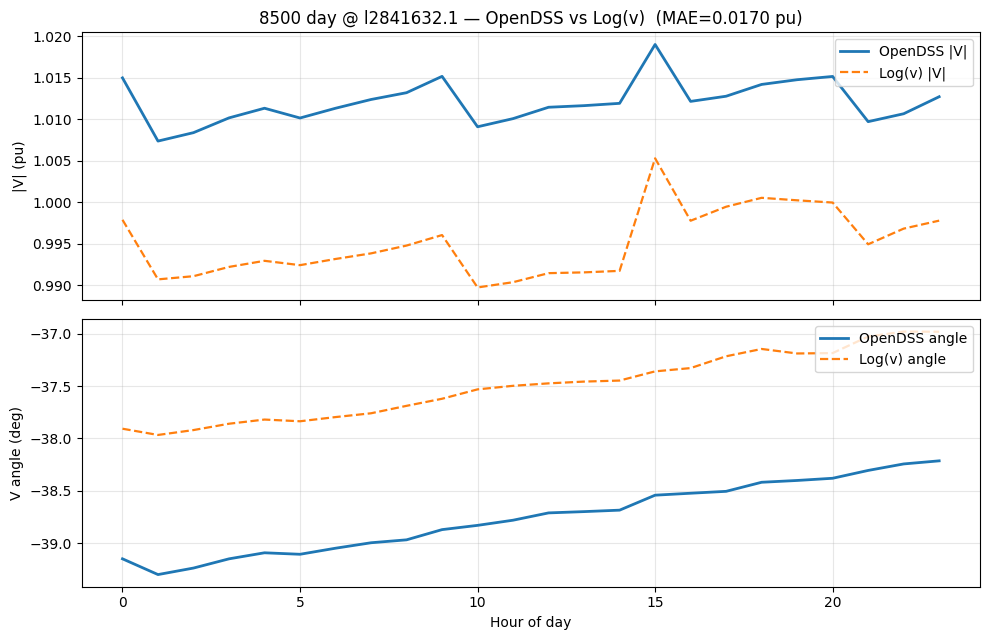

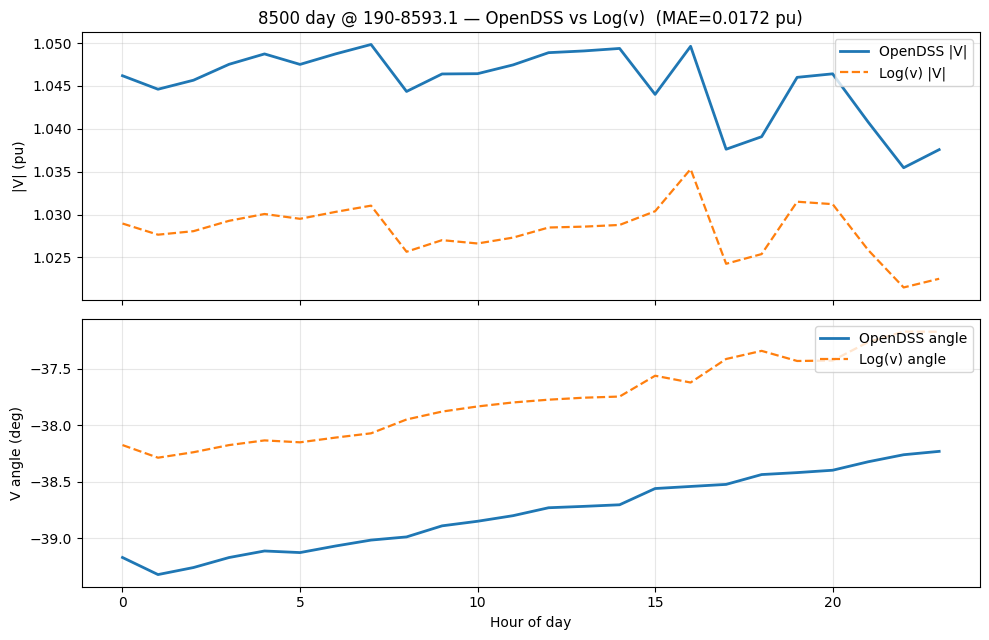

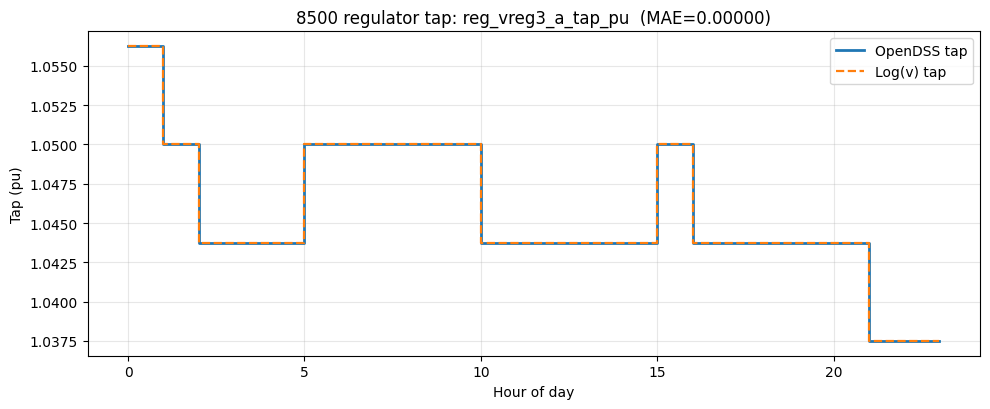

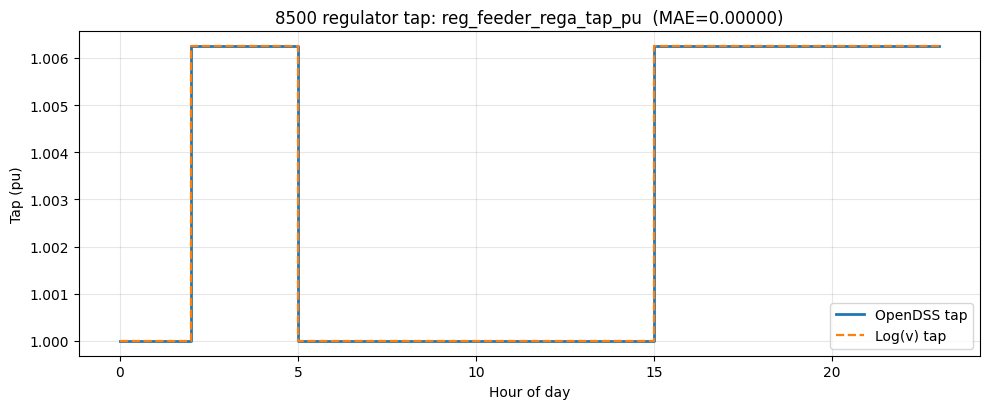

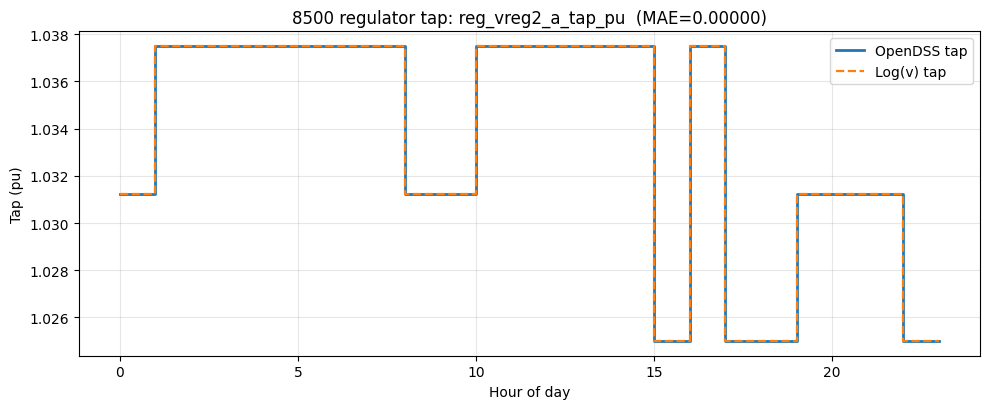

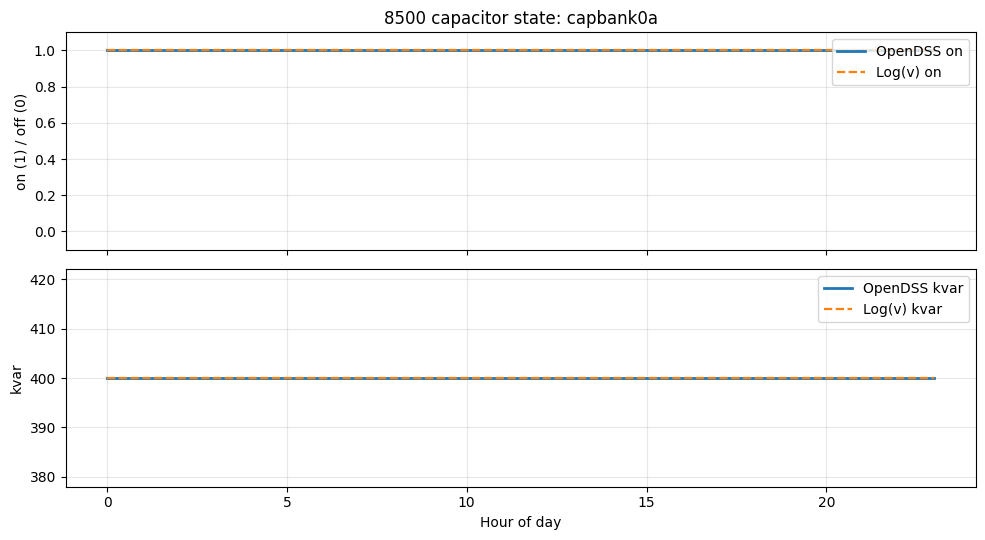

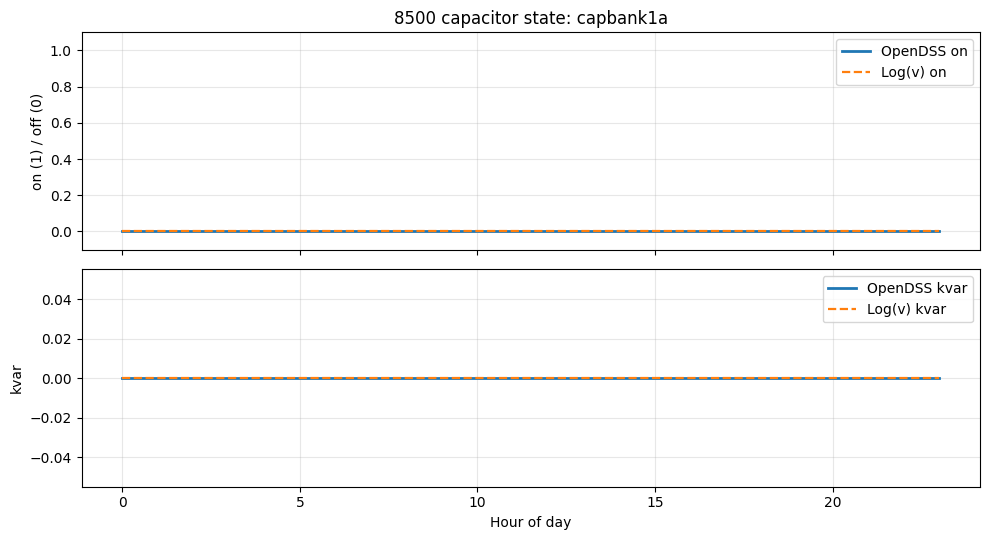

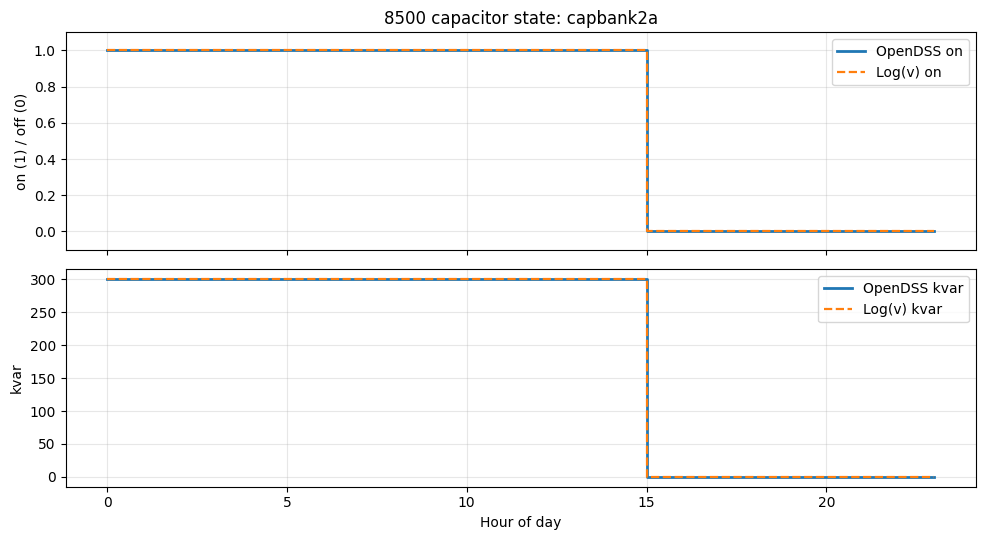

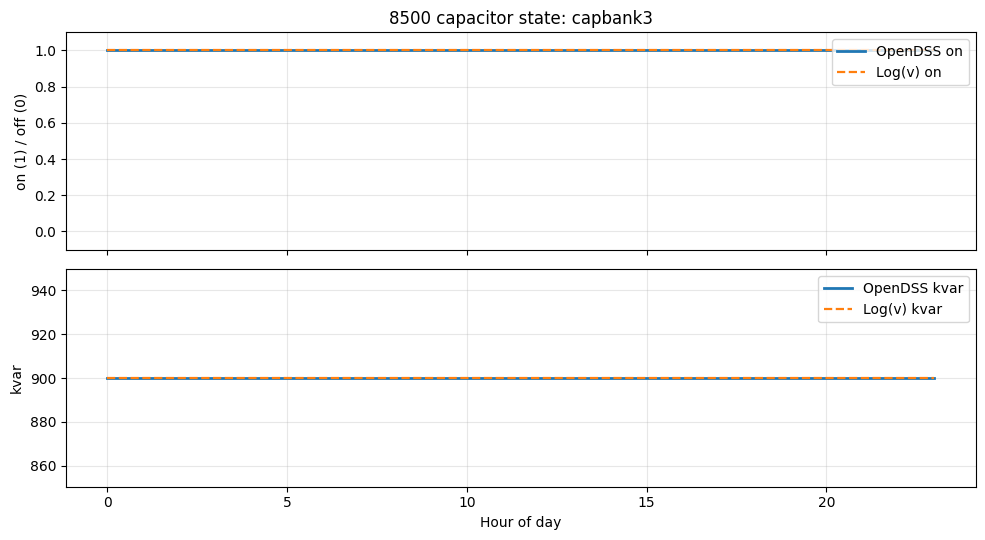

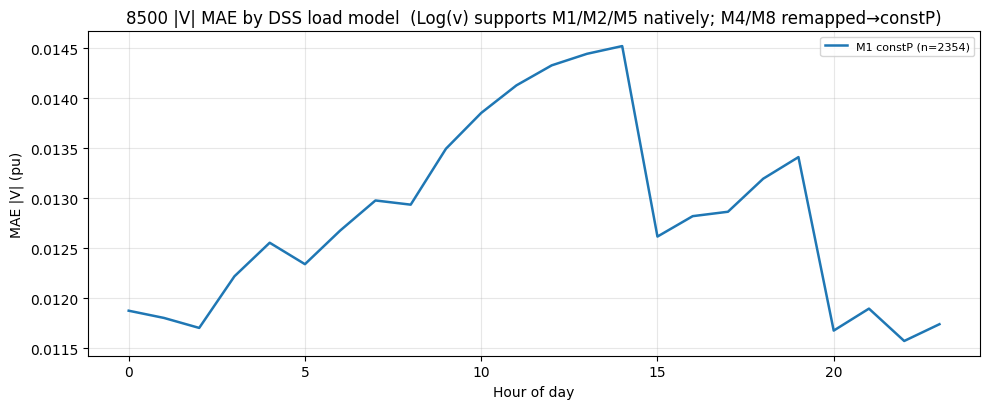

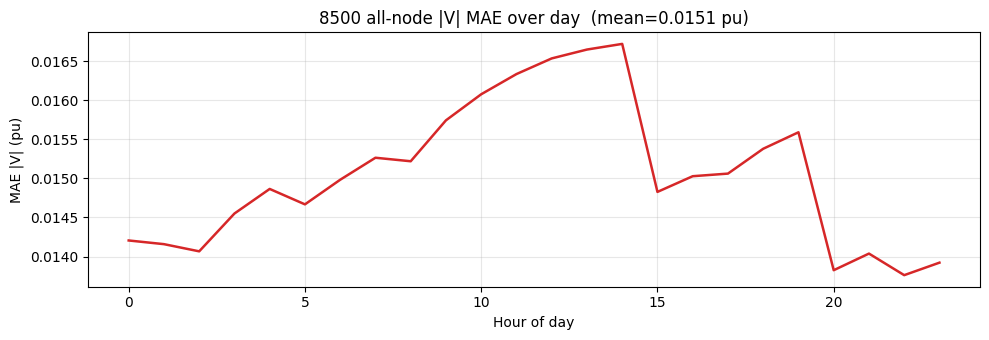

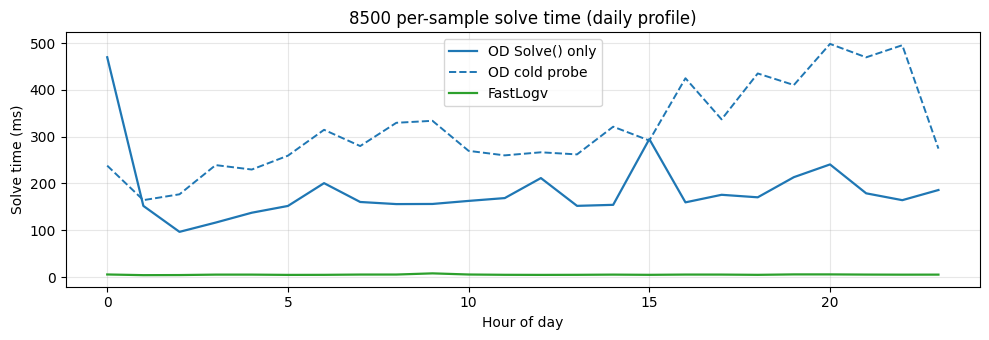

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "8500"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "synced"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


Plan: FEEDER=8500  CONTROL_MODE=static  RUN_SNAPSHOT=True  RUN_DAILY=True  RUN_SPEED=True  NPTS=288  STEP_MIN=5.0  DAY=4
AUDIT - what this cell actually ran
  feeder          : 8500
  DSS             : C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  control_mode    : static

  WHAT Log(v) IS
    linearized power-flow (rank-k / Woodbury linear algebra)
    NOT a linear program / optimizer
    paper: v ~ Delta*(1+u+j*theta_tilde); Ytilde=Delta*Y*.*Delta^H; ytilde=Ytilde*1
    controller limits are NOT encoded as LP constraints
  MODEL DISCLOSURES
    - Log(v) uses paper Ytilde:=Delta Y* Delta^H and ytilde:=Ytilde*1 (row sums).
    - No Delta-Wye ytilde zeroing; no default A ridge (ainv_ridge=0).
    - 2-winding transformer Yprim from OpenDSS CktElement.YPrim (pu), not ad-hoc ytilde zeroing.
    - Analytical Yprim is fallback only; magnetizing branch omitted in fallback.
    - Unsupported DSS load models remapped -> const-P (see load_models).
 

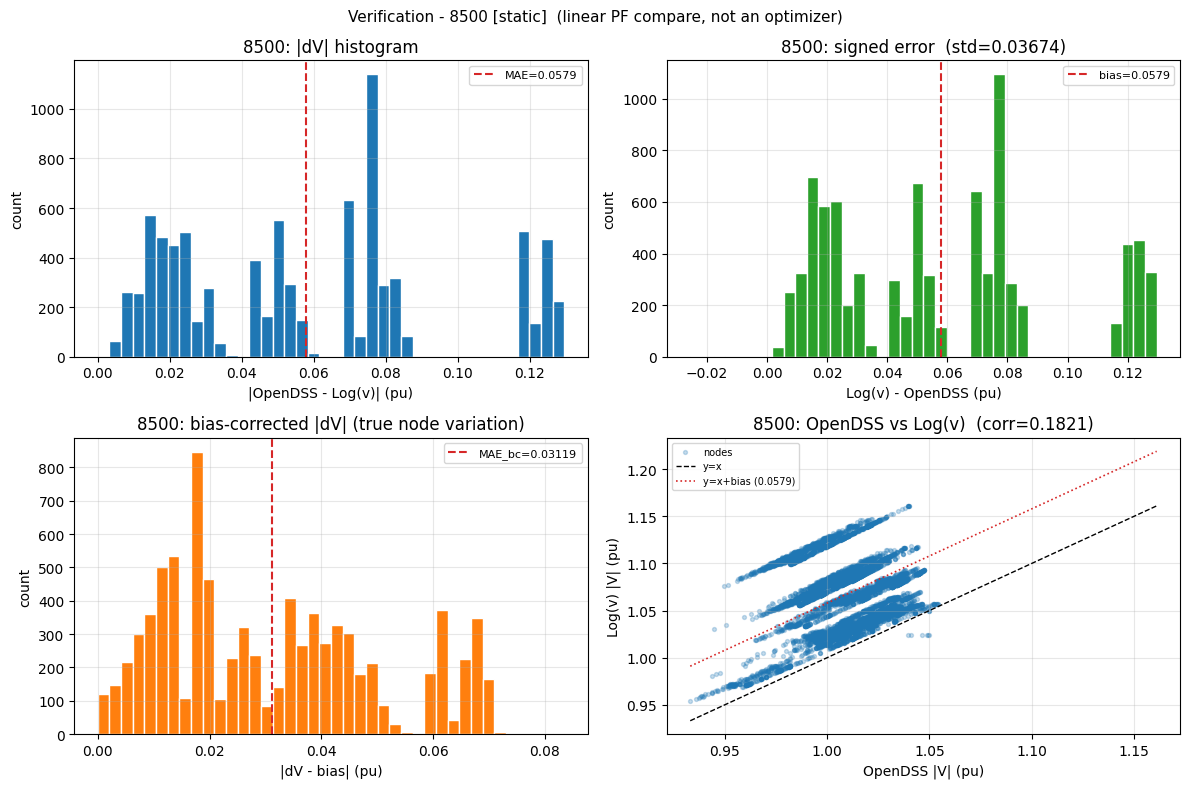

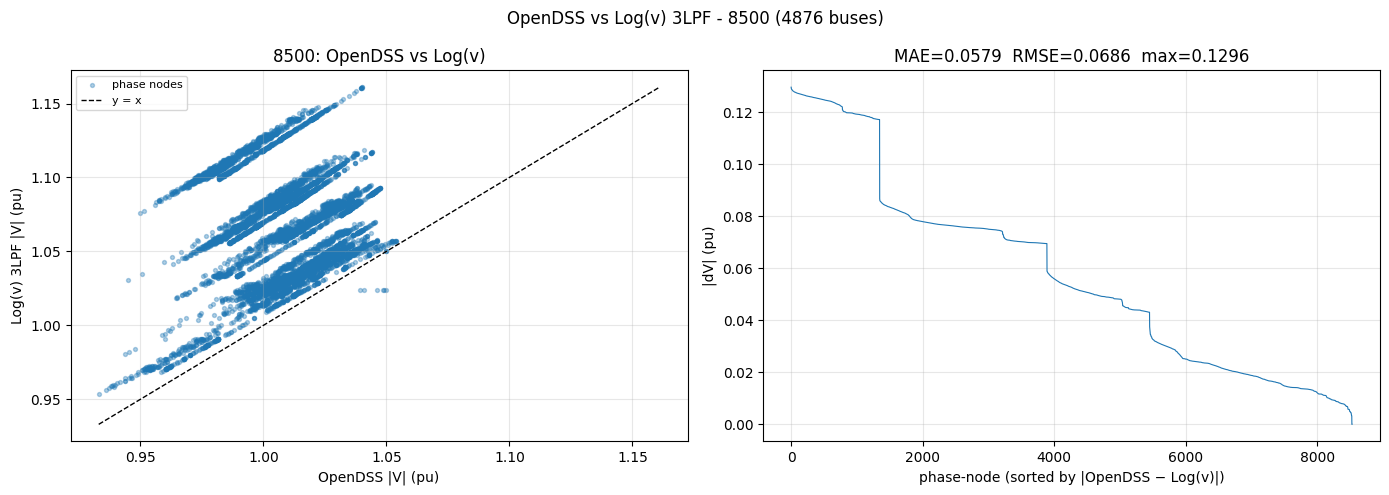

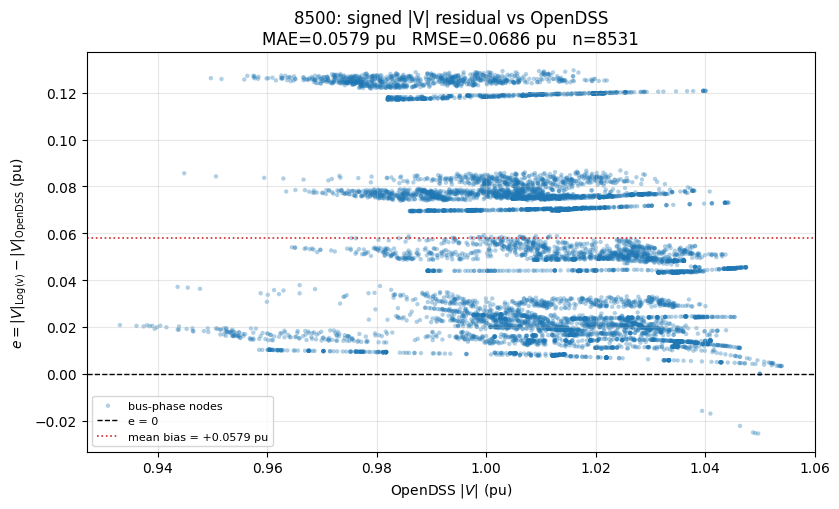

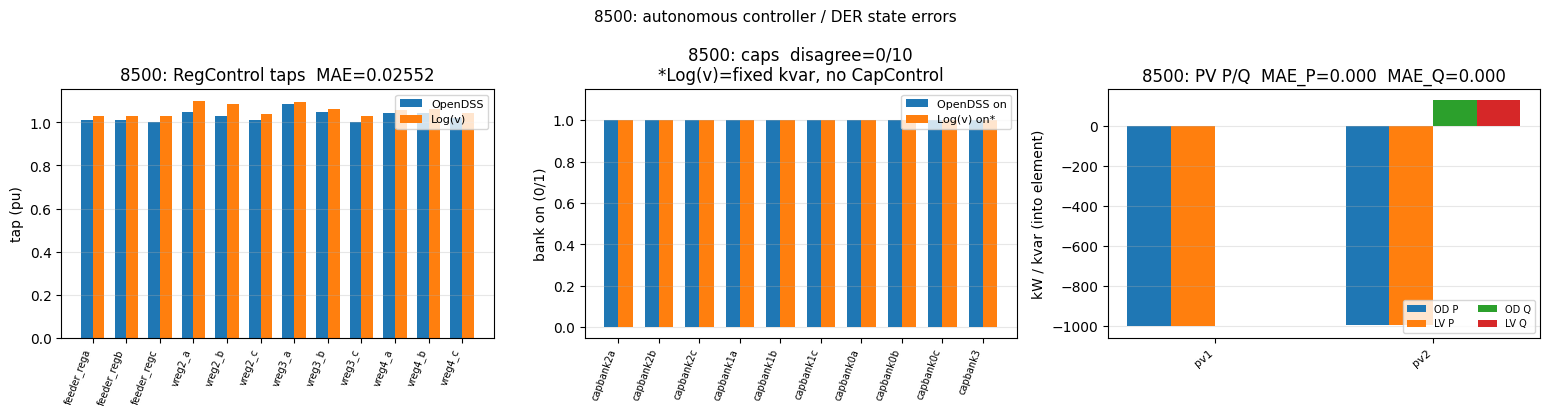


ACCURACY SUMMARY (SNAPSHOT)  feeder=8500  mode=static
  |V| RMSE (pu)  : 0.06856218488900076
  |V| MAPE (%)   : 5.767004077575042
  angle RMSE deg : 1.8670011478858646
  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)
Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Appended 2 PVSystem(s) as negative constant-power loads for Log(v).
Transformer hvmv_sub is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices
Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  8534
k =  72
Complexity of KLU decomposition, 3.32e+12 FLOPS 
Complexity of LogV algorithm, 4.69e+08 FLOPS 
Ratio 7064.29
DAILY OpenDSS vs Log(v)  feeder=8500  mode=static  npts=288  step=5.0min  day=4
  DSS: C:\Users\alita\OneDrive\Desktop\GNN2\8500 nodes with solar unbalanced\Master-PV2MW-inv.dss
  plot nodes: ['l2841632.1', '190-8593.1']
  regs: ['reg_vreg3_a_tap_pu', 'reg_feeder_rega_tap_pu

KeyboardInterrupt: 

In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ============================================================
# OpenDSS vs Log(v) — snapshot figures + daily (288) profile
# ============================================================
FEEDER = "8500"              # "ieee34" | "906" | "8500"
CONTROL_MODE = "static"      # "off" | "synced" | "static"
#   off:    frozen taps — cleanest linearization compare
#   synced: OD Static settles; sync loads/PV/caps/taps; rebuild A on tap change
#           + RUN_SPEED: Fast voltages → metrics/plots (fair speed+accuracy)
#   static: OD Static vs Log(v) own RegControl (caps/PV still synced)
#           Fast is init-A probe only; plots stay on stock autonomous Log(v)

RUN_SNAPSHOT = True          # one-sample accuracy + ORIGINAL figures (V, residual, audit, controllers)
RUN_DAILY = True             # day profile accuracy + V/reg/cap evolution plots + CSV
RUN_SPEED = True             # with synced: fair Fast vs OD (baked taps in A)

SMOKE_TEST = False           # True: 24 x 1h.  False: 288 x 5 min
DAY = 4                      # 8500 representative-day index only
PLOT_NODES = None            # None → feeder defaults
REG_COLS = None
CAP_NAMES = None
PLOT = True                  # snapshot figures
DIAGNOSTICS = True           # audit + paper tables with snapshot
SAVE_PLOTS = False
SAVE_CSV = True
# ============================================================


def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_opendss_compare.py"
    )


REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
        "logv_fast_solver",
        "compare_mv_daily_timing",
    ):
        sys.modules.pop(mod, None)

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0
_nan = float("nan")
case = None
metrics = None
series = None

print(
    f"Plan: FEEDER={FEEDER}  CONTROL_MODE={CONTROL_MODE}  "
    f"RUN_SNAPSHOT={RUN_SNAPSHOT}  RUN_DAILY={RUN_DAILY}  RUN_SPEED={RUN_SPEED}  "
    f"NPTS={NPTS}  STEP_MIN={STEP_MIN}  DAY={DAY}"
)

# --- Snapshot (original figures + paper tables) ---
if RUN_SNAPSHOT:
    from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

    case, metrics = compare_logv3lpf_vs_opendss(
        REPO,
        feeder=FEEDER,
        plot=bool(PLOT),
        save_plots=bool(SAVE_PLOTS),
        out_dir=REPO / "outputs" / "logv3lpf_snapshot",
        control_mode=CONTROL_MODE,
        diagnostics=bool(DIAGNOSTICS),
        timing_repeats=0,
    )
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (SNAPSHOT)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    pa = (metrics or {}).get("paper_accuracy") or {}
    print(f"  |V| RMSE (pu)  : {pa.get('vm_rmse_pu', _nan)}")
    print(f"  |V| MAPE (%)   : {pa.get('vm_mape_pct', _nan)}")
    print(f"  angle RMSE deg : {pa.get('va_rmse_deg', _nan)}")
    print("  figures: voltage, signed residual, audit, controllers/ZIP (if applicable)")

# --- Daily profile (evolution plots + optional speed) ---
if RUN_DAILY or RUN_SPEED:
    from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

    series = run_daily_opendss_vs_logv3lpf(
        REPO,
        feeder=FEEDER,
        day=int(DAY),
        npts=int(NPTS),
        step_min=float(STEP_MIN),
        control_mode=CONTROL_MODE,
        plot_nodes=PLOT_NODES,
        reg_cols=REG_COLS,
        cap_names=CAP_NAMES,
        show_plots=True,
        save_plots=bool(SAVE_PLOTS),
        save_csv=bool(SAVE_CSV),
        time_speed=bool(RUN_SPEED),
        out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
    )

    summ = series.get("summary") or {}
    print("\n" + "=" * 72)
    print(f"ACCURACY SUMMARY (DAILY)  feeder={FEEDER}  mode={CONTROL_MODE}")
    print("=" * 72)
    print(f"  samples ok     : {summ.get('n_ok')}/{series.get('npts')}  (bad={summ.get('n_bad')})")
    print(f"  mean |V| MAE   : {summ.get('mean_mae_vm', _nan):.6f} pu")
    print(f"  mean |V| RMSE  : {summ.get('mean_rmse_vm', _nan):.6f} pu")
    print(f"  max  |V| MAE   : {summ.get('max_mae_vm', _nan):.6f} pu")
    print(f"  wall           : {summ.get('wall_s', _nan):.1f} s")
    if series.get("csv_path"):
        print(f"  CSV (all steps): {series['csv_path']}")

    if RUN_SPEED:
        import numpy as np

        od = np.asarray(series["t_opendss_s"], float)
        odc = np.asarray(series.get("t_opendss_cold_s", []), float)
        lv = np.asarray(series["t_logv_s"], float)
        ft = np.asarray(series["t_fast_s"], float)
        m_od = np.isfinite(od) & (od > 0)
        m_odc = np.isfinite(odc) & (odc > 0) if odc.size else np.array([], dtype=bool)
        m_lv = np.isfinite(lv) & (lv > 0)
        m_ft = np.isfinite(ft) & (ft > 0)
        summ = series.get("summary") or {}
        print("\n" + "=" * 72)
        print(f"SPEED SUMMARY (DAILY)  feeder={FEEDER}   <--- use MEAN numbers")
        print("=" * 72)
        print(f"  N samples ok    : {int(np.isfinite(series['mae_vm_all_nodes']).sum())}")
        print(f"  logv source     : {summ.get('logv_source', '?')}  fair_fast={summ.get('fair_fast')}")
        print(f"  A rebuilds      : {summ.get('n_A_rebuilds', 0)}")
        mae = np.asarray(series["mae_vm_all_nodes"], float)
        m_mae = np.isfinite(mae)
        if m_mae.any():
            print(
                f"  |V| MAE mean    : {np.mean(mae[m_mae]):.6f} pu  "
                f"(median {np.median(mae[m_mae]):.6f}, max {np.max(mae[m_mae]):.6f})"
            )
        if m_od.any():
            print(f"  OD warm mean    : {np.mean(od[m_od])*1e3:.3f} ms  (median {np.median(od[m_od])*1e3:.3f})")
        if m_odc.any():
            print(f"  OD cold mean    : {np.mean(odc[m_odc])*1e3:.3f} ms  (median {np.median(odc[m_odc])*1e3:.3f})")
            print("    note: OD cold = reset taps + InitSnap+Solve Static (controls from flat start; no warm-start)")
        if m_lv.any():
            print(f"  stock Log(v) mean: {np.mean(lv[m_lv])*1e3:.3f} ms")
        if m_ft.any():
            print(f"  FastLogv mean   : {np.mean(ft[m_ft])*1e3:.3f} ms  (median {np.median(ft[m_ft])*1e3:.3f})")
            print("    note: Fast = online RHS+factor only (init/tap-refresh excluded)")
            fr = np.asarray(series.get("t_fast_refresh_s", []), float)
            m_fr = (
                np.isfinite(fr) & (fr > 0)
                if getattr(fr, "size", 0)
                else np.array([], dtype=bool)
            )
            if m_fr.any():
                print(
                    f"  Fast refresh mean: {np.mean(fr[m_fr])*1e3:.3f} ms  "
                    f"(n={int(m_fr.sum())}; outside Fast timer)"
                )
        if m_od.any() and m_ft.any():
            print(f"  mean OD_warm/Fast: {np.mean(od[m_od])/np.mean(ft[m_ft]):.2f}x")
        if m_odc.any() and m_ft.any():
            print(f"  mean OD_cold/Fast: {np.mean(odc[m_odc])/np.mean(ft[m_ft]):.2f}x  <--- fair cold compare")
        if summ.get("fair_fast"):
            print("  note: fair synced/off — OD taps baked into A; Fast voltages → metrics/plots")
        elif m_ft.any():
            print("  note: static probe — Fast uses init A; plots use stock autonomous Log(v)")
        if not (m_od.any() and (m_lv.any() or m_ft.any())):
            print("  (no valid timings)")

if not (RUN_SNAPSHOT or RUN_DAILY or RUN_SPEED):
    print("All RUN_* flags are False — nothing to run.")

case, metrics, series


<!-- obsolete daily compare cell removed; use unified cell above -->


## IEEE 34 (Mirzaei) — GNN dataset generation (chunked)

Generate chunked OpenDSS snapshot data for DA-GPS training on **Dr. Mirzaei's IEEE34_PV.dss** (`new dss from dr mirzaei/IEEE34_PV.dss`).

Same chunked driver pattern as the 906 / 8500 cells above. Generator script: `run_original_style_dataset_ieee34_mirzaei.py`.

### Full vs smoke sizes
| Mode | `TOTAL_SCENARIOS` | `N_SAMPLES_PER_SCENARIO` | `SCENARIOS_PER_CHUNK` | chunks |
|---|---|---|---|---|
| Full (`SMOKE_TEST=False`) | 2000 | 40 | 50 | 40 |
| Smoke (`SMOKE_TEST=True`) | 4 | 8 | 2 | 2 |

### Save location (`CHUNK_ROOT`)
- **Colab:** `/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked`
- **Windows (preferred):** `K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked`
- Fallback: `D:\datasets\...` or `{repo}\datasets_gnn2\...`

### What this feeder has (vs 906 / 8500)
| | IEEE 8500 | 906 LVTestCase | **IEEE 34 Mirzaei** |
|---|---|---|---|
| DER | PV (+ optional BESS) | none | **PV850 + PV860** (PV850 has Volt-Var InvControl) |
| Load models | mostly const-P | const-P | **mixed ZIP**: DSS models 1 / 2 / 4 / 5 |
| Caps | CapControl banks | none | **fixed** C844 / C848 (no CapControl) |
| Regs | RegControl taps | none | native `rega*/regb*` transformers (**no RegControl**) |
| Profiles | 5-min load + irrad | 1-min load shapes | **5-min** `5minDayShape` + `IrradShape` (288 pts) |
| Trainer schema | real TARGET_* | dummy TARGET_* | **dummy TARGET_*** (same 8500 column names) + real IEEE34 meta for system tokens |

ZIP shares (`share_m*_p`) are **randomized per scenario** (`RANDOMIZE_ZIP_MODELS=True`) so those tokens are not constant; set False to keep the Mirzaei DSS default model mix.

### Per-chunk outputs (`run_***/`)
- `gnn_node_index_master.csv` (Laplacian PE)
- `gnn_edges_phase_static.csv`
- `gnn_sample_meta.csv` — dummy 8500 `TARGET_*` plus IEEE34 tokens (grid, PV post, ZIP shares, native taps, fixed cap kvar)
- `gnn_node_features_and_targets_mvagg.csv` ← what DA-GPS loads (compat copy; no split-phase agg)

### After generation
Point the IEEE34 DA-GPS training cell's `CHUNK_PARENT` at `CHUNK_ROOT` below.


In [22]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — IEEE 34 Mirzaei
# - runs in chunks, different seed / out folder per chunk
# - PE from static edges each chunk
# - *_mvagg.csv compat file (identity; no split-phase aggregation)
# - dummy 8500 TARGET_* cap/reg meta + real IEEE34 system-token columns
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny path check; set False for full 2000×40

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 3420230

SIGMA_LOAD = 0.02
SIGMA_PV = 0.02

# Scenario totals are scaled around injection BASELINE (~849 kW / 501 kvar / 975 kW PV)
P_LOAD_SCALE_RANGE = (0.95, 1.05)
Q_LOAD_SCALE_RANGE = (0.95, 1.05)
P_PV_SCALE_RANGE = (0.95, 1.05)

VMIN_SAFE_PU = 0.85
VMAX_SAFE_PU = 1.10

# OpenDSS ControlMode while sampling: "static" lets InvControl Volt-Var settle;
# "off" freezes controls. Prefer static so PV Q (autonomous) varies in the data.
CONTROL_MODE = "static"
# Per-scenario random Load.Model in {1,2,4,5} so ZIP-share tokens are informative.
RANDOMIZE_ZIP_MODELS = True

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

_REPO = None
for root in CANDIDATES:
    if os.path.isdir(root) and os.path.isfile(os.path.join(root, "run_original_style_dataset_ieee34_mirzaei.py")):
        _REPO = os.path.abspath(root)
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate repo root containing run_original_style_dataset_ieee34_mirzaei.py")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_K_GNN2 = Path(r"K:\My Drive\datasets_gnn2")
_K_MYDRIVE = Path(r"K:\My Drive")

if IN_COLAB:
    CHUNK_ROOT = Path("/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked")
elif _K_GNN2.exists() or _K_MYDRIVE.exists():
    CHUNK_ROOT = _K_GNN2 / "original_ieee34_mirzaei_chunked"
elif Path(r"D:\datasets").exists():
    CHUNK_ROOT = Path(r"D:\datasets\original_ieee34_mirzaei_chunked")
else:
    CHUNK_ROOT = Path(_REPO) / "datasets_gnn2" / "original_ieee34_mirzaei_chunked"

CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("CHUNK_ROOT:", CHUNK_ROOT)

script_path = os.path.join(_REPO, "run_original_style_dataset_ieee34_mirzaei.py")
os.chdir(_REPO)
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

ns = {"__name__": "run_original_style_dataset_ieee34_mirzaei", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

dss_file = ns["DSS_FILE"]
print("DSS_FILE:", dss_file)
print("DSS exists:", Path(dss_file).is_file())
if not Path(dss_file).is_file():
    raise FileNotFoundError(f"Missing IEEE34 DSS: {dss_file}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST} | CONTROL_MODE={CONTROL_MODE}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
        control_mode=str(CONTROL_MODE),
        randomize_zip_models=bool(RANDOMIZE_ZIP_MODELS),
    )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_ieee34_mirzaei"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"])
    print(" -", ns["MVAGG_CSV"])

print("\nAll chunks finished.")
print("Next: set IEEE34 DA-GPS CHUNK_PARENT to:", CHUNK_ROOT)


CHUNK_ROOT: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked
CWD: C:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_original_style_dataset_ieee34_mirzaei.py
DSS_FILE: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
DSS exists: True

Total chunks: 40 | SMOKE_TEST=False | CONTROL_MODE=static

=== Chunk 1/40 ===
Scenarios in chunk: 50
Seed: 3520233
OUT_DIR: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked\run_001_scen_0000_0049_seed_3520233
[DSS] maxcontroliter=20000
[ieee34] nodes_all=95 nodes_graph=89 control_mode=static
[saved] phase-edge CSV -> K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked\run_001_scen_0000_0049_seed_3520233\gnn_edges_phase_static.csv | rows=172 | cols=17 | bidirectional=True
[ieee34] computed PE k=8
[ieee34] scenario 1/50 done in 0.3s | samples so far=40
[ieee34] scenario 2/50 done in 0.3s | samples so far=80
[ieee34] scenario 3/50 done in 0.3s | samples so far=120
[ieee34] s

## DA-GPS training on IEEE 34 Mirzaei (chunked)

Train the existing multitask DA-GPS model on the **already-generated** IEEE34 chunked dataset. **Do not regenerate** for training — point at:

- Local: `K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked`
- Colab: `/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked`

### System / latent tokens (chosen for IEEE 34)

`--n_system_tokens` allocates learnable **global tokens** after the fixed (dummy) cap-bank and regulator tokens. With `--aux_meta_cols`, column `i` supervises system-token slot `i` via normalized MSE (`--lambda_pv`).

For IEEE 34 we use **10 supervised system tokens** that match what actually varies on this feeder:

| # | Meta column | Why |
|---|-------------|-----|
| 1–2 | `P_grid_upstream_post_kw`, `Q_grid_upstream_post_kvar` | Substation / net operating point |
| 3–4 | `pv_pv850_p_post_kw`, `pv_pv850_q_post_kvar` | PV850 **active + Volt-Var Q** (autonomous InvControl) |
| 5–6 | `pv_pv860_p_post_kw`, `pv_pv860_q_post_kvar` | PV860 post-solve P/Q |
| 7–10 | `share_m1_p`, `share_m2_p`, `share_m4_p`, `share_m5_p` | ZIP / load-model mix (ConstP / ConstZ / CVR / ConstI), **randomized per scenario** |

**Native device tokens (supervised):**

- **2** capacitor tokens: `cap_c844_n_steps_on`, `cap_c848_n_steps_on` (BCE, `lambda_cap=0.1`)
- **6** regulator tokens: `reg_rega1..3_tap_pu`, `reg_regb1..3_tap_pu` (MSE, `lambda_reg=0.1`)

Dummy 8500 `TARGET_*` columns are **not** used (`--cap_cols` / `--reg_cols` point at native meta only).

**Also written to meta for diagnostics only (not token heads):** fixed `cap_c844_*` / `cap_c848_*` kvar continuous values.

### IEEE 34 vs 906 vs 8500 training

| Setting | 8500 (typical) | 906 | **IEEE 34 (this cell)** |
|--------|----------------|-----|-------------------------|
| Dataset | `original_8500_...` | `original_906_...` | `original_ieee34_mirzaei_chunked` |
| Tokens | 10+12+10 = 32 | 0+0+10 = 10 | **2+6+10 = 18** (native caps/regs; no dummy TARGET_*) |
| Supervised | 10 BCE + 12 CE + 4 meta | 2 meta (+ 8 free) | **all 18**: 2 BCE + 6 MSE + 10 meta |
| `n_system_tokens` | 10 | 10 (2 supervised) | **10** |
| Meta aux | PV + losses | grid P/Q | **grid + 2×PV P/Q + 4 ZIP shares** |
| Cap / reg loss | `> 0` | none | **`lambda_cap=lambda_reg=0.1`** on native devices |
| Physics | optional | off | **off** (`PHYSICS_WEIGHT=0`) |
| Cache / run tag | `..._mvagg_...` | `..._nodummy` | `..._nativectrl` |

Caches use **ieee34-specific** names so they never collide with 906/8500.


In [ ]:
# --- DA-GPS training on IEEE 34 Mirzaei (long-running; Colab GPU or local CUDA) ---
import os
import sys
import re
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_ieee34_mirzaei_chunked"
WIN_CHUNK_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked")
WIN_RUNS_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\runs")
WIN_CACHE_PARENT = Path(r"K:\My Drive\datasets_gnn2\cache")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    """Resolve a data path; never join Windows drive letters with cwd on Linux."""
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(
            f"No run_*/gnn_node_index_master.csv under {chunk_parent}"
        )
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50  # full: scen_0000_0049 => 50; smoke: scen_0000_0001 => 2


def _parse_run_scen_span(name: str) -> int | None:
    """Return (end - start + 1) from run_*_scen_{start}_{end}_seed_*, else None."""
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    """Split run_* dirs into full vs other/smoke by scen span in the folder name."""
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    """Build --chunk_subdir_glob with full vs smoke awareness.

    Full training (smoke=False): keep only folders whose scen span >= min_full_span
    (typically 50). Smoke folders (span=2) are skipped without deleting them.

    Smoke training (smoke=True): prefer the first `smoke_count` *full-size* chunks
    when available; otherwise fall back to the first `smoke_count` any run_*.
    """
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} "
                f"under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        kept_names = {p.name for p in kept}
        print(f"  smoke: taking first {smoke_count} from {source}")
        for p in all_runs:
            span = _parse_run_scen_span(p.name)
            span_s = f"span={span}" if span is not None else "unparseable span"
            if p.name in kept_names:
                print(f"  KEEP  {p.name} ({span_s})")
            elif full and p not in full:
                print(f"  SKIP  {p.name} ({span_s}; smoke prefers full-size chunks)")
            else:
                print(f"  SKIP  {p.name} ({span_s}; beyond first {smoke_count})")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s)."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(
            f"  SKIP  {p.name} ({span_s}; need span>={min_full_span} for full training)"
        )
    for p in full:
        span = _parse_run_scen_span(p.name)
        print(f"  KEEP  {p.name} (span={span}; full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


def _write_smoke_compare_manifest(
    runs_parent: Path,
    *,
    out_dir: Path,
    physics_weight: float,
    chunk_glob: str,
    n_chunks: int,
    epochs: int,
    seed: int,
) -> None:
    import json as _json

    path = runs_parent / "_smoke_compare_manifest_906.json"
    manifest = {}
    if path.is_file():
        manifest = _json.loads(path.read_text(encoding="utf-8"))
    key = "physics" if physics_weight > 0 else "baseline"
    manifest[key] = {
        "run_dir": str(out_dir.resolve()),
        "physics_weight": physics_weight,
        "chunk_glob": chunk_glob,
        "n_chunks": n_chunks,
        "epochs": epochs,
        "seed": seed,
        "feeder": "906_lvtestcase",
    }
    path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"Smoke compare manifest ({key}) -> {path}")


# Colab: mount Drive when chunks/caches live under MyDrive
if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = True
SMOKE_CHUNK_COUNT = 3  # first N full-size run_* when available; 3-5 = fast multi-chunk
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42
_DA_CACHE_NAME = "da_gps_chunked_ieee34_smoke_gine_nativectrl" if SMOKE_TEST else "da_gps_chunked_ieee34_full_gine_nativectrl"
_GNN_CACHE_NAME = "gnn_only_chunked_ieee34_full_gine"

# --- paths: auto-detect Colab + Drive; prefer K: on Windows ---
_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError(
            "Colab requires Google Drive mounted. Re-run this cell and approve Drive access, "
            "or: from google.colab import drive; drive.mount('/content/drive')"
        )
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = WIN_CACHE_PARENT / _DA_CACHE_NAME
    GNN_CACHE_ROOT = WIN_CACHE_PARENT / _GNN_CACHE_NAME
    RUNS_PARENT = WIN_RUNS_DEFAULT
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_ieee34_mirzaei_chunked"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

NODE_PE_CSV = None  # auto: first run_*/gnn_node_index_master.csv under CHUNK_PARENT

# Optional overrides (use POSIX paths on Colab, not K:\...):
# CHUNK_PARENT = Path("/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked")
# NODE_PE_CSV = CHUNK_PARENT / "run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv"

# --- lighter architecture ---
LIGHTER_HIDDEN = 64
LIGHTER_LAYERS = 2
LIGHTER_HEADS = 2
LIGHTER_NODE_EMB_DIM = 2

PHYSICS_WEIGHT = 0.0  # always off for IEEE34 (no 8500 PF catalogs)

# System tokens: grid + PV850/860 P/Q + ZIP shares (10 supervised).
# Device tokens: native 2 caps + 6 regs (no dummy 8500 TARGET_*).
META_AUX_COLS = (
    "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,"
    "pv_pv850_p_post_kw,pv_pv850_q_post_kvar,"
    "pv_pv860_p_post_kw,pv_pv860_q_post_kvar,"
    "share_m1_p,share_m2_p,share_m4_p,share_m5_p"
)
N_SYSTEM_TOKENS = 10
CAP_COLS = "cap_c844_n_steps_on,cap_c848_n_steps_on"
REG_COLS = (
    "reg_rega1_tap_pu,reg_rega2_tap_pu,reg_rega3_tap_pu,"
    "reg_regb1_tap_pu,reg_regb2_tap_pu,reg_regb3_tap_pu"
)
META_LOSS_SCALE = 0.001  # fix buggy stored P/Q loss units if those cols are ingested
LAMBDA_PV = 0.1  # weight for meta-aux MSE on the 10 system tokens
LAMBDA_CAP = 0.1
LAMBDA_REG = 0.1

NUM_WORKERS = 0 if os.name == "nt" else 4

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30
# Full: only scen-span >= 50 folders. Smoke: prefer first N full-size, else any run_*.
CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

print("=== Preflight (IEEE34 DA-GPS) ===")
print(f"REPO:           {REPO}")
print(f"SMOKE_TEST:     {SMOKE_TEST}")
print(f"SMOKE_CHUNK_COUNT: {SMOKE_CHUNK_COUNT}")
print(f"CHUNK_GLOB:     {CHUNK_GLOB}")
print(f"EPOCHS:         {EPOCHS}")
print(f"PATIENCE:       {PATIENCE}")
print(f"CHUNK_PARENT:   {chunk_parent}")
print(f"META_AUX_COLS:  {META_AUX_COLS}")
print(f"N_SYSTEM_TOKENS:{N_SYSTEM_TOKENS}")
print(f"CAP_COLS:       {CAP_COLS}")
print(f"REG_COLS:       {REG_COLS}")
print(f"Token total:    {len([c for c in CAP_COLS.split(',') if c.strip()])}+{len([c for c in REG_COLS.split(',') if c.strip()])}+{N_SYSTEM_TOKENS}")
print(f"META_LOSS_SCALE:{META_LOSS_SCALE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"PHYSICS_WEIGHT: {PHYSICS_WEIGHT}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

run_preview = sorted(
    p.name for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")
)[:5]
print(f"run_* preview:  {run_preview}")

if NODE_PE_CSV is None:
    node_pe = _find_node_pe_csv(chunk_parent)
else:
    node_pe = _resolve_data_path(NODE_PE_CSV, label="NODE_PE_CSV", colab_fallback=None)
    if not node_pe.is_file():
        warnings.warn(
            f"NODE_PE_CSV not found at {node_pe}; auto-discovering under CHUNK_PARENT.",
            UserWarning,
            stacklevel=2,
        )
        node_pe = _find_node_pe_csv(chunk_parent)

print(f"NODE_PE_CSV:    {node_pe}")
print(f"DA_CACHE_ROOT:  {da_cache_root}")
print(f"GNN_CACHE_ROOT: {gnn_cache_root}")
print(f"RUNS_PARENT:    {runs_parent}")
print("PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)")
print("=================")

da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
if not chunks:
    raise RuntimeError(f"No folders for CHUNK_GLOB={CHUNK_GLOB!r} under {chunk_parent}")

for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print(f"Found {len(chunks)} chunk(s) for CHUNK_GLOB under {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_ieee34_l{LIGHTER_LAYERS}_h{LIGHTER_HIDDEN}_gine_nativectrl"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

_early_stop = "total"

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--cap_cols", CAP_COLS,
    "--reg_cols", REG_COLS,
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", str(LAMBDA_PV),
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", "64",
    "--hidden", str(LIGHTER_HIDDEN),
    "--layers", str(LIGHTER_LAYERS),
    "--heads", str(LIGHTER_HEADS),
    "--node_emb_dim", str(LIGHTER_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", str(LAMBDA_CAP),
    "--lambda_reg", str(LAMBDA_REG),
    "--reg_loss", "mse",
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", _early_stop,
    "--dropout", "0.1",
]

# PHYSICS_WEIGHT must stay 0 for IEEE34 — no PF flags added.

print(f"PHYSICS_WEIGHT={PHYSICS_WEIGHT} (baseline; no 8500 physics)")
print(f"early_stop_on={_early_stop}")
print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
_write_smoke_compare_manifest(
    runs_parent,
    out_dir=out_dir,
    physics_weight=PHYSICS_WEIGHT,
    chunk_glob=CHUNK_GLOB,
    n_chunks=len(chunks),
    epochs=EPOCHS,
    seed=SMOKE_SEED if SMOKE_TEST else 42,
)


Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
  SKIP  run_001_scen_0000_0001_seed_3520233 (span=2; need span>=50 for full training)
  SKIP  run_002_scen_0002_0003_seed_3620236 (span=2; need span>=50 for full training)
  KEEP  run_001_scen_0000_0049_seed_3520233 (span=50; full)
  KEEP  run_002_scen_0050_0099_seed_3620236 (span=50; full)
  KEEP  run_003_scen_0100_0149_seed_3720239 (span=50; full)
  KEEP  run_004_scen_0150_0199_seed_3820242 (span=50; full)
  KEEP  run_005_scen_0200_0249_seed_3920245 (span=50; full)
  KEEP  run_006_scen_0250_0299_seed_4020248 (span=50; full)
  KEEP  run_007_scen_0300_0349_seed_4120251 (span=50; full)
  KEEP  run_008_scen_0350_0399_seed_4220254 (span=50; full)
  KEEP  run_009_scen_0400_0449_seed_4320257 (span=50; full)
  KEEP  run_010_scen_0450_0499_seed_4420260 (span=50; full)
  KEEP  run_011_scen_0500_0549_seed_4520263 (span=50; full)
  KEEP  run_012_scen_0550_0599_seed_4620266 (span=50; full)
  KEEP  run_013_scen_0600_0649_seed_4720269 (span=50; full)
  KEEP  run_014_scen_0650_0699_seed_4820272 (span=50; full)
  KEEP  run_015_scen_0700_0749_seed_4920275 (span=50; full)
  KEEP  run_016_scen_0750_0799_seed_5020278 (span=50; full)
  KEEP  run_017_scen_0800_0849_seed_5120281 (span=50; full)
  KEEP  run_018_scen_0850_0899_seed_5220284 (span=50; full)
  KEEP  run_019_scen_0900_0949_seed_5320287 (span=50; full)
  KEEP  run_020_scen_0950_0999_seed_5420290 (span=50; full)
  KEEP  run_021_scen_1000_1049_seed_5520293 (span=50; full)
  KEEP  run_022_scen_1050_1099_seed_5620296 (span=50; full)
  KEEP  run_023_scen_1100_1149_seed_5720299 (span=50; full)
  KEEP  run_024_scen_1150_1199_seed_5820302 (span=50; full)
  KEEP  run_025_scen_1200_1249_seed_5920305 (span=50; full)
  KEEP  run_026_scen_1250_1299_seed_6020308 (span=50; full)
  KEEP  run_027_scen_1300_1349_seed_6120311 (span=50; full)
  KEEP  run_028_scen_1350_1399_seed_6220314 (span=50; full)
  KEEP  run_029_scen_1400_1449_seed_6320317 (span=50; full)
  KEEP  run_030_scen_1450_1499_seed_6420320 (span=50; full)
  KEEP  run_031_scen_1500_1549_seed_6520323 (span=50; full)
  KEEP  run_032_scen_1550_1599_seed_6620326 (span=50; full)
  KEEP  run_033_scen_1600_1649_seed_6720329 (span=50; full)
  KEEP  run_034_scen_1650_1699_seed_6820332 (span=50; full)
  KEEP  run_035_scen_1700_1749_seed_6920335 (span=50; full)
  KEEP  run_036_scen_1750_1799_seed_7020338 (span=50; full)
  KEEP  run_037_scen_1800_1849_seed_7120341 (span=50; full)
  KEEP  run_038_scen_1850_1899_seed_7220344 (span=50; full)
  KEEP  run_039_scen_1900_1949_seed_7320347 (span=50; full)
  KEEP  run_040_scen_1950_1999_seed_7420350 (span=50; full)
=== Preflight (IEEE34 DA-GPS) ===
REPO:           /content/GNN-Sandia
SMOKE_TEST:     False
SMOKE_CHUNK_COUNT: 3
CHUNK_GLOB:     run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350
EPOCHS:         200
PATIENCE:       30
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
META_AUX_COLS:  P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,pv_pv850_p_post_kw,pv_pv850_q_post_kvar,pv_pv860_p_post_kw,pv_pv860_q_post_kvar,share_m1_p,share_m2_p,share_m4_p,share_m5_p
N_SYSTEM_TOKENS:10
META_LOSS_SCALE:0.001
lambda_cap/reg/pv: 0.0/0.0/0.1
PHYSICS_WEIGHT: 0.0
run_* preview:  ['run_001_scen_0000_0001_seed_3520233', 'run_001_scen_0000_0049_seed_3520233', 'run_002_scen_0002_0003_seed_3620236', 'run_002_scen_0050_0099_seed_3620236', 'run_003_scen_0100_0149_seed_3720239']
NODE_PE_CSV:    /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)
=================
Found 40 chunk(s) for CHUNK_GLOB under /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
PHYSICS_WEIGHT=0.0 (baseline; no 8500 physics)
early_stop_on=total

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 10 --aux_meta_cols P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,pv_pv850_p_post_kw,pv_pv850_q_post_kvar,pv_pv860_p_post_kw,pv_pv860_q_post_kvar,share_m1_p,share_m2_p,share_m4_p,share_m5_p --meta_loss_scale 0.001 --lambda_pv 0.1 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --heads 2 --node_emb_dim 2 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0.0 --lambda_reg 0.0 --reg_loss mse --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

meta_loss_scale=0.001: scaling P_loss_total_post_kw / Q_loss_total_post_kvar when those columns are loaded as meta-aux targets
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
Meta aux (sample_meta): 10 column(s); chunk DA caches use suffix __maux80f03146 (per chunk name).
  global token index 22 (system slot 0): column 'p_grid_upstream_post_kw'
  global token index 23 (system slot 1): column 'q_grid_upstream_post_kvar'
  global token index 24 (system slot 2): column 'pv_pv850_p_post_kw'
  global token index 25 (system slot 3): column 'pv_pv850_q_post_kvar'
  global token index 26 (system slot 4): column 'pv_pv860_p_post_kw'
  global token index 27 (system slot 5): column 'pv_pv860_q_post_kvar'
  global token index 28 (system slot 6): column 'share_m1_p'
  global token index 29 (system slot 7): column 'share_m2_p'
  global token index 30 (system slot 8): column 'share_m4_p'
  global token index 31 (system slot 9): column 'share_m5_p'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
  - run_001_scen_0000_0049_seed_3520233
  - run_002_scen_0050_0099_seed_3620236
  - run_003_scen_0100_0149_seed_3720239
  - run_004_scen_0150_0199_seed_3820242
  - run_005_scen_0200_0249_seed_3920245
  - run_006_scen_0250_0299_seed_4020248
  - run_007_scen_0300_0349_seed_4120251
  - run_008_scen_0350_0399_seed_4220254
  - run_009_scen_0400_0449_seed_4320257
  - run_010_scen_0450_0499_seed_4420260
  - run_011_scen_0500_0549_seed_4520263
  - run_012_scen_0550_0599_seed_4620266
  - run_013_scen_0600_0649_seed_4720269
  - run_014_scen_0650_0699_seed_4820272
  - run_015_scen_0700_0749_seed_4920275
  - run_016_scen_0750_0799_seed_5020278
  - run_017_scen_0800_0849_seed_5120281
  - run_018_scen_0850_0899_seed_5220284
  - run_019_scen_0900_0949_seed_5320287
  - run_020_scen_0950_0999_seed_5420290
  - run_021_scen_1000_1049_seed_5520293
  - run_022_scen_1050_1099_seed_5620296
  - run_023_scen_1100_1149_seed_5720299
  - run_024_scen_1150_1199_seed_5820302
  - run_025_scen_1200_1249_seed_5920305
  - run_026_scen_1250_1299_seed_6020308
  - run_027_scen_1300_1349_seed_6120311
  - run_028_scen_1350_1399_seed_6220314
  - run_029_scen_1400_1449_seed_6320317
  - run_030_scen_1450_1499_seed_6420320
  - run_031_scen_1500_1549_seed_6520323
  - run_032_scen_1550_1599_seed_6620326
  - run_033_scen_1600_1649_seed_6720329
  - run_034_scen_1650_1699_seed_6820332
  - run_035_scen_1700_1749_seed_6920335
  - run_036_scen_1750_1799_seed_7020338
  - run_037_scen_1800_1849_seed_7120341
  - run_038_scen_1850_1899_seed_7220344
  - run_039_scen_1900_1949_seed_7320347
  - run_040_scen_1950_1999_seed_7420350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_002_scen_0050_0099_seed_3620236/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_002_scen_0050_0099_seed_3620236__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_003_scen_0100_0149_seed_3720239/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_003_scen_0100_0149_seed_3720239__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_004_scen_0150_0199_seed_3820242/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_004_scen_0150_0199_seed_3820242__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_005_scen_0200_0249_seed_3920245/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_005_scen_0200_0249_seed_3920245__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_006_scen_0250_0299_seed_4020248/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_006_scen_0250_0299_seed_4020248__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_007_scen_0300_0349_seed_4120251/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_007_scen_0300_0349_seed_4120251__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_008_scen_0350_0399_seed_4220254/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_008_scen_0350_0399_seed_4220254__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_009_scen_0400_0449_seed_4320257/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_009_scen_0400_0449_seed_4320257__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_010_scen_0450_0499_seed_4420260/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_010_scen_0450_0499_seed_4420260__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_011_scen_0500_0549_seed_4520263/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_011_scen_0500_0549_seed_4520263__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_012_scen_0550_0599_seed_4620266/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_012_scen_0550_0599_seed_4620266__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_013_scen_0600_0649_seed_4720269/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_013_scen_0600_0649_seed_4720269__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_014_scen_0650_0699_seed_4820272/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_014_scen_0650_0699_seed_4820272__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_015_scen_0700_0749_seed_4920275/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_015_scen_0700_0749_seed_4920275__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_016_scen_0750_0799_seed_5020278/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_016_scen_0750_0799_seed_5020278__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_017_scen_0800_0849_seed_5120281/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_017_scen_0800_0849_seed_5120281__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_018_scen_0850_0899_seed_5220284/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_018_scen_0850_0899_seed_5220284__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_019_scen_0900_0949_seed_5320287/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_019_scen_0900_0949_seed_5320287__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_020_scen_0950_0999_seed_5420290/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_020_scen_0950_0999_seed_5420290__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_021_scen_1000_1049_seed_5520293/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_021_scen_1000_1049_seed_5520293__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_022_scen_1050_1099_seed_5620296/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_022_scen_1050_1099_seed_5620296__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_023_scen_1100_1149_seed_5720299/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_023_scen_1100_1149_seed_5720299__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_024_scen_1150_1199_seed_5820302/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_024_scen_1150_1199_seed_5820302__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_025_scen_1200_1249_seed_5920305/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_025_scen_1200_1249_seed_5920305__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_026_scen_1250_1299_seed_6020308/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_026_scen_1250_1299_seed_6020308__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_027_scen_1300_1349_seed_6120311/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_027_scen_1300_1349_seed_6120311__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_028_scen_1350_1399_seed_6220314/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_028_scen_1350_1399_seed_6220314__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_029_scen_1400_1449_seed_6320317/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_029_scen_1400_1449_seed_6320317__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_030_scen_1450_1499_seed_6420320/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_030_scen_1450_1499_seed_6420320__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_031_scen_1500_1549_seed_6520323/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_031_scen_1500_1549_seed_6520323__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_032_scen_1550_1599_seed_6620326/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_032_scen_1550_1599_seed_6620326__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_033_scen_1600_1649_seed_6720329/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_033_scen_1600_1649_seed_6720329__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_034_scen_1650_1699_seed_6820332/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_034_scen_1650_1699_seed_6820332__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_035_scen_1700_1749_seed_6920335/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_035_scen_1700_1749_seed_6920335__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_036_scen_1750_1799_seed_7020338/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_036_scen_1750_1799_seed_7020338__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_037_scen_1800_1849_seed_7120341/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_037_scen_1800_1849_seed_7120341__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_038_scen_1850_1899_seed_7220344/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_038_scen_1850_1899_seed_7220344__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_039_scen_1900_1949_seed_7320347/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_039_scen_1900_1949_seed_7320347__full__nobess__maux80f03146.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_040_scen_1950_1999_seed_7420350/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_040_scen_1950_1999_seed_7420350__full__nobess__maux80f03146.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_run_manifest.json
torch.compile: enabled
AMP (autocast + GradScaler): enabled
[da_gps chunk_parent] epoch    1/200 | train_tot=0.2198 train_volt=0.1619 train_cap=0.6665 train_reg=0.5935 train_meta_aux=0.5787 val_meta_aux=0.4734 | val_tot=0.0816 val_volt=0.0343 val_cap=0.6234 val_reg=0.6752 | val_r2_mean=0.9564 val_r2_min=0.6758 val_r2_min_node=806.2 val_worst_mae=0.0076 | best=0.0816
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6480  cap_capbank0b_n_steps_on=0.6557  cap_capbank0c_n_steps_on=0.6722  cap_capbank1a_n_steps_on=0.6759  cap_capbank1b_n_steps_on=0.6566  cap_capbank1c_n_steps_on=0.6752
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6883  cap_capbank2b_n_steps_on=0.6632  cap_capbank2c_n_steps_on=0.6551  cap_capbank3_n_steps_on=0.6742
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6089  cap_capbank0b_n_steps_on=0.6146  cap_capbank0c_n_steps_on=0.6317  cap_capbank1a_n_steps_on=0.6246  cap_capbank1b_n_steps_on=0.6110  cap_capbank1c_n_steps_on=0.6248
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6494  cap_capbank2b_n_steps_on=0.6172  cap_capbank2c_n_steps_on=0.6226  cap_capbank3_n_steps_on=0.6290
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.5834  reg_feeder_regb_tap_pu=0.5752  reg_feeder_regc_tap_pu=0.5985  reg_vreg2_a_tap_pu=0.6527  reg_vreg2_b_tap_pu=0.5578  reg_vreg2_c_tap_pu=0.6011
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.5986  reg_vreg3_b_tap_pu=0.5709  reg_vreg3_c_tap_pu=0.6043  reg_vreg4_a_tap_pu=0.6103  reg_vreg4_b_tap_pu=0.5766  reg_vreg4_c_tap_pu=0.5923
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.6865  reg_feeder_regb_tap_pu=0.6486  reg_feeder_regc_tap_pu=0.6721  reg_vreg2_a_tap_pu=0.7070  reg_vreg2_b_tap_pu=0.6437  reg_vreg2_c_tap_pu=0.6938
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.6919  reg_vreg3_b_tap_pu=0.6429  reg_vreg3_c_tap_pu=0.6840  reg_vreg4_a_tap_pu=0.6772  reg_vreg4_b_tap_pu=0.6690  reg_vreg4_c_tap_pu=0.6858
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.1540  q_grid_upstream_post_kvar=0.1847  pv_pv850_p_post_kw=0.1727  pv_pv850_q_post_kvar=0.1601  pv_pv860_p_post_kw=0.1171  pv_pv860_q_post_kvar=0.9929
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9985  share_m2_p=1.0031  share_m4_p=1.0009  share_m5_p=1.0028
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0284  q_grid_upstream_post_kvar=0.0298  pv_pv850_p_post_kw=0.0335  pv_pv850_q_post_kvar=0.0135  pv_pv860_p_post_kw=0.0172  pv_pv860_q_post_kvar=0.5882
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=1.0068  share_m2_p=1.0154  share_m4_p=1.0006  share_m5_p=1.0006

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.001691  angle MAE=0.061046  Re/Im MSE(nrm)=0.034276  r2_mean=0.9582  r2_min=0.9123  worst_mae=0.007631  tot=0.0816  volt=0.0343
Test  |V| MAE=0.001694  angle MAE=0.060061  Re/Im MSE(nrm)=0.034085  r2_mean=0.9578  r2_min=0.9127  worst_mae=0.007589  tot=0.1043  volt=0.0341
[da_gps chunk_parent] epoch   10/200 | train_tot=0.0592 train_volt=0.0091 train_cap=0.7221 train_reg=0.7186 train_meta_aux=0.5018 val_meta_aux=0.4609 | val_tot=0.0540 val_volt=0.0079 val_cap=0.6997 val_reg=0.7211 | val_r2_mean=0.9914 val_r2_min=0.9402 val_r2_min_node=806.2 val_worst_mae=0.0031 | best=0.0540
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7255  cap_capbank0b_n_steps_on=0.7137  cap_capbank0c_n_steps_on=0.7277  cap_capbank1a_n_steps_on=0.7250  cap_capbank1b_n_steps_on=0.7175  cap_capbank1c_n_steps_on=0.7212
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7215  cap_capbank2b_n_steps_on=0.7179  cap_capbank2c_n_steps_on=0.7228  cap_capbank3_n_steps_on=0.7280
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7034  cap_capbank0b_n_steps_on=0.6863  cap_capbank0c_n_steps_on=0.7200  cap_capbank1a_n_steps_on=0.6965  cap_capbank1b_n_steps_on=0.6926  cap_capbank1c_n_steps_on=0.6950
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7042  cap_capbank2b_n_steps_on=0.6994  cap_capbank2c_n_steps_on=0.6954  cap_capbank3_n_steps_on=0.7043
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.7232  reg_feeder_regb_tap_pu=0.7143  reg_feeder_regc_tap_pu=0.7152  reg_vreg2_a_tap_pu=0.7186  reg_vreg2_b_tap_pu=0.7180  reg_vreg2_c_tap_pu=0.7228
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.7213  reg_vreg3_b_tap_pu=0.7063  reg_vreg3_c_tap_pu=0.7252  reg_vreg4_a_tap_pu=0.7086  reg_vreg4_b_tap_pu=0.7236  reg_vreg4_c_tap_pu=0.7255
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.7268  reg_feeder_regb_tap_pu=0.7174  reg_feeder_regc_tap_pu=0.7189  reg_vreg2_a_tap_pu=0.7228  reg_vreg2_b_tap_pu=0.7173  reg_vreg2_c_tap_pu=0.7212
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.7231  reg_vreg3_b_tap_pu=0.7103  reg_vreg3_c_tap_pu=0.7302  reg_vreg4_a_tap_pu=0.7082  reg_vreg4_b_tap_pu=0.7274  reg_vreg4_c_tap_pu=0.7293
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0161  pv_pv850_p_post_kw=0.0095  pv_pv850_q_post_kvar=0.0081  pv_pv860_p_post_kw=0.0064  pv_pv860_q_post_kvar=0.9629
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=1.0017  share_m2_p=1.0014  share_m4_p=1.0024  share_m5_p=1.0000
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0074  q_grid_upstream_post_kvar=0.0119  pv_pv850_p_post_kw=0.0045  pv_pv850_q_post_kvar=0.0075  pv_pv860_p_post_kw=0.0031  pv_pv860_q_post_kvar=0.5718
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=1.0025  share_m2_p=1.0048  share_m4_p=0.9906  share_m5_p=1.0046

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.000782  angle MAE=0.027266  Re/Im MSE(nrm)=0.007922  r2_mean=0.9919  r2_min=0.9861  worst_mae=0.003115  tot=0.0540  volt=0.0079
Test  |V| MAE=0.000790  angle MAE=0.027431  Re/Im MSE(nrm)=0.008141  r2_mean=0.9916  r2_min=0.9856  worst_mae=0.003163  tot=0.0766  volt=0.0081
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0570 train_volt=0.0072 train_cap=0.7149 train_reg=0.4783 train_meta_aux=0.4982 val_meta_aux=0.4573 | val_tot=0.0554 val_volt=0.0097 val_cap=0.6849 val_reg=0.4799 | val_r2_mean=0.9888 val_r2_min=0.9100 val_r2_min_node=806.2 val_worst_mae=0.0036 | best=0.0540
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7213  cap_capbank0b_n_steps_on=0.7106  cap_capbank0c_n_steps_on=0.7223  cap_capbank1a_n_steps_on=0.7101  cap_capbank1b_n_steps_on=0.7096  cap_capbank1c_n_steps_on=0.7208
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7137  cap_capbank2b_n_steps_on=0.7114  cap_capbank2c_n_steps_on=0.7078  cap_capbank3_n_steps_on=0.7216
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6900  cap_capbank0b_n_steps_on=0.6876  cap_capbank0c_n_steps_on=0.6891  cap_capbank1a_n_steps_on=0.6820  cap_capbank1b_n_steps_on=0.6805  cap_capbank1c_n_steps_on=0.6868
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6912  cap_capbank2b_n_steps_on=0.6815  cap_capbank2c_n_steps_on=0.6711  cap_capbank3_n_steps_on=0.6890
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.4762  reg_feeder_regb_tap_pu=0.4746  reg_feeder_regc_tap_pu=0.4799  reg_vreg2_a_tap_pu=0.4751  reg_vreg2_b_tap_pu=0.4816  reg_vreg2_c_tap_pu=0.4770
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.4801  reg_vreg3_b_tap_pu=0.4753  reg_vreg3_c_tap_pu=0.4818  reg_vreg4_a_tap_pu=0.4722  reg_vreg4_b_tap_pu=0.4795  reg_vreg4_c_tap_pu=0.4861
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.4741  reg_feeder_regb_tap_pu=0.4801  reg_feeder_regc_tap_pu=0.4833  reg_vreg2_a_tap_pu=0.4762  reg_vreg2_b_tap_pu=0.4836  reg_vreg2_c_tap_pu=0.4758
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4847  reg_vreg3_b_tap_pu=0.4792  reg_vreg3_c_tap_pu=0.4792  reg_vreg4_a_tap_pu=0.4764  reg_vreg4_b_tap_pu=0.4786  reg_vreg4_c_tap_pu=0.4879
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0069  q_grid_upstream_post_kvar=0.0124  pv_pv850_p_post_kw=0.0058  pv_pv850_q_post_kvar=0.0064  pv_pv860_p_post_kw=0.0041  pv_pv860_q_post_kvar=0.9406
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=1.0015  share_m2_p=1.0013  share_m4_p=1.0007  share_m5_p=1.0019
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0070  q_grid_upstream_post_kvar=0.0130  pv_pv850_p_post_kw=0.0036  pv_pv850_q_post_kvar=0.0063  pv_pv860_p_post_kw=0.0010  pv_pv860_q_post_kvar=0.5622
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9993  share_m2_p=1.0020  share_m4_p=0.9888  share_m5_p=0.9900

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.000944  angle MAE=0.024549  Re/Im MSE(nrm)=0.009703  r2_mean=0.9894  r2_min=0.9828  worst_mae=0.003640  tot=0.0554  volt=0.0097
Test  |V| MAE=0.000953  angle MAE=0.024512  Re/Im MSE(nrm)=0.009845  r2_mean=0.9892  r2_min=0.9823  worst_mae=0.003657  tot=0.0779  volt=0.0098
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0565 train_volt=0.0067 train_cap=0.7234 train_reg=0.3358 train_meta_aux=0.4973 val_meta_aux=0.4567 | val_tot=0.0512 val_volt=0.0055 val_cap=0.6980 val_reg=0.4048 | val_r2_mean=0.9934 val_r2_min=0.9470 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7278  cap_capbank0b_n_steps_on=0.7154  cap_capbank0c_n_steps_on=0.7280  cap_capbank1a_n_steps_on=0.7251  cap_capbank1b_n_steps_on=0.7207  cap_capbank1c_n_steps_on=0.7253
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7215  cap_capbank2b_n_steps_on=0.7234  cap_capbank2c_n_steps_on=0.7209  cap_capbank3_n_steps_on=0.7258
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7040  cap_capbank0b_n_steps_on=0.6928  cap_capbank0c_n_steps_on=0.6999  cap_capbank1a_n_steps_on=0.7007  cap_capbank1b_n_steps_on=0.6942  cap_capbank1c_n_steps_on=0.6996
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6935  cap_capbank2b_n_steps_on=0.6997  cap_capbank2c_n_steps_on=0.6979  cap_capbank3_n_steps_on=0.6977
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.3343  reg_feeder_regb_tap_pu=0.3351  reg_feeder_regc_tap_pu=0.3349  reg_vreg2_a_tap_pu=0.3350  reg_vreg2_b_tap_pu=0.3355  reg_vreg2_c_tap_pu=0.3339
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.3367  reg_vreg3_b_tap_pu=0.3362  reg_vreg3_c_tap_pu=0.3359  reg_vreg4_a_tap_pu=0.3357  reg_vreg4_b_tap_pu=0.3373  reg_vreg4_c_tap_pu=0.3394
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.4008  reg_feeder_regb_tap_pu=0.4045  reg_feeder_regc_tap_pu=0.4052  reg_vreg2_a_tap_pu=0.4078  reg_vreg2_b_tap_pu=0.4062  reg_vreg2_c_tap_pu=0.4011
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4023  reg_vreg3_b_tap_pu=0.4035  reg_vreg3_c_tap_pu=0.4069  reg_vreg4_a_tap_pu=0.4052  reg_vreg4_b_tap_pu=0.4084  reg_vreg4_c_tap_pu=0.4052
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0059  q_grid_upstream_post_kvar=0.0107  pv_pv850_p_post_kw=0.0047  pv_pv850_q_post_kvar=0.0056  pv_pv860_p_post_kw=0.0034  pv_pv860_q_post_kvar=0.9455
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=1.0010  share_m2_p=1.0003  share_m4_p=0.9995  share_m5_p=0.9968
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0039  q_grid_upstream_post_kvar=0.0095  pv_pv850_p_post_kw=0.0017  pv_pv850_q_post_kvar=0.0048  pv_pv860_p_post_kw=0.0008  pv_pv860_q_post_kvar=0.5622
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9962  share_m2_p=1.0058  share_m4_p=0.9909  share_m5_p=0.9915

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.000689  angle MAE=0.018488  Re/Im MSE(nrm)=0.005541  r2_mean=0.9937  r2_min=0.9883  worst_mae=0.002875  tot=0.0512  volt=0.0055
Test  |V| MAE=0.000696  angle MAE=0.018615  Re/Im MSE(nrm)=0.005721  r2_mean=0.9935  r2_min=0.9877  worst_mae=0.002888  tot=0.0737  volt=0.0057
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0558 train_volt=0.0064 train_cap=0.7290 train_reg=0.2765 train_meta_aux=0.4937 val_meta_aux=0.4574 | val_tot=0.0525 val_volt=0.0068 val_cap=0.6981 val_reg=0.3094 | val_r2_mean=0.9914 val_r2_min=0.9368 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7326  cap_capbank0b_n_steps_on=0.7285  cap_capbank0c_n_steps_on=0.7293  cap_capbank1a_n_steps_on=0.7274  cap_capbank1b_n_steps_on=0.7286  cap_capbank1c_n_steps_on=0.7303
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7280  cap_capbank2b_n_steps_on=0.7309  cap_capbank2c_n_steps_on=0.7261  cap_capbank3_n_steps_on=0.7284
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7017  cap_capbank0b_n_steps_on=0.6970  cap_capbank0c_n_steps_on=0.6991  cap_capbank1a_n_steps_on=0.6970  cap_capbank1b_n_steps_on=0.6979  cap_capbank1c_n_steps_on=0.7009
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6982  cap_capbank2b_n_steps_on=0.6981  cap_capbank2c_n_steps_on=0.6947  cap_capbank3_n_steps_on=0.6969
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2727  reg_feeder_regb_tap_pu=0.2768  reg_feeder_regc_tap_pu=0.2716  reg_vreg2_a_tap_pu=0.2790  reg_vreg2_b_tap_pu=0.2774  reg_vreg2_c_tap_pu=0.2745
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2751  reg_vreg3_b_tap_pu=0.2796  reg_vreg3_c_tap_pu=0.2792  reg_vreg4_a_tap_pu=0.2773  reg_vreg4_b_tap_pu=0.2778  reg_vreg4_c_tap_pu=0.2773
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.3054  reg_feeder_regb_tap_pu=0.3060  reg_feeder_regc_tap_pu=0.3029  reg_vreg2_a_tap_pu=0.3109  reg_vreg2_b_tap_pu=0.3103  reg_vreg2_c_tap_pu=0.3078
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.3078  reg_vreg3_b_tap_pu=0.3146  reg_vreg3_c_tap_pu=0.3123  reg_vreg4_a_tap_pu=0.3121  reg_vreg4_b_tap_pu=0.3117  reg_vreg4_c_tap_pu=0.3110
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0056  q_grid_upstream_post_kvar=0.0101  pv_pv850_p_post_kw=0.0035  pv_pv850_q_post_kvar=0.0052  pv_pv860_p_post_kw=0.0030  pv_pv860_q_post_kvar=0.9118
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9996  share_m2_p=0.9993  share_m4_p=1.0015  share_m5_p=0.9978
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0085  pv_pv850_p_post_kw=0.0014  pv_pv850_q_post_kvar=0.0036  pv_pv860_p_post_kw=0.0009  pv_pv860_q_post_kvar=0.5635
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=1.0009  share_m2_p=1.0060  share_m4_p=0.9914  share_m5_p=0.9932

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.000821  angle MAE=0.017484  Re/Im MSE(nrm)=0.006753  r2_mean=0.9919  r2_min=0.9873  worst_mae=0.002862  tot=0.0525  volt=0.0068
Test  |V| MAE=0.000824  angle MAE=0.017641  Re/Im MSE(nrm)=0.006849  r2_mean=0.9918  r2_min=0.9872  worst_mae=0.002870  tot=0.0742  volt=0.0068
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0554 train_volt=0.0061 train_cap=0.7296 train_reg=0.2432 train_meta_aux=0.4931 val_meta_aux=0.4604 | val_tot=0.0530 val_volt=0.0070 val_cap=0.7233 val_reg=0.2148 | val_r2_mean=0.9920 val_r2_min=0.9345 val_r2_min_node=806.2 val_worst_mae=0.0032 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7307  cap_capbank0b_n_steps_on=0.7283  cap_capbank0c_n_steps_on=0.7305  cap_capbank1a_n_steps_on=0.7280  cap_capbank1b_n_steps_on=0.7306  cap_capbank1c_n_steps_on=0.7316
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7272  cap_capbank2b_n_steps_on=0.7297  cap_capbank2c_n_steps_on=0.7290  cap_capbank3_n_steps_on=0.7304
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7255  cap_capbank0b_n_steps_on=0.7213  cap_capbank0c_n_steps_on=0.7241  cap_capbank1a_n_steps_on=0.7215  cap_capbank1b_n_steps_on=0.7236  cap_capbank1c_n_steps_on=0.7263
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7217  cap_capbank2b_n_steps_on=0.7216  cap_capbank2c_n_steps_on=0.7230  cap_capbank3_n_steps_on=0.7248
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2419  reg_feeder_regb_tap_pu=0.2422  reg_feeder_regc_tap_pu=0.2438  reg_vreg2_a_tap_pu=0.2433  reg_vreg2_b_tap_pu=0.2440  reg_vreg2_c_tap_pu=0.2397
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2410  reg_vreg3_b_tap_pu=0.2435  reg_vreg3_c_tap_pu=0.2483  reg_vreg4_a_tap_pu=0.2400  reg_vreg4_b_tap_pu=0.2454  reg_vreg4_c_tap_pu=0.2450
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.2088  reg_feeder_regb_tap_pu=0.2113  reg_feeder_regc_tap_pu=0.2181  reg_vreg2_a_tap_pu=0.2168  reg_vreg2_b_tap_pu=0.2166  reg_vreg2_c_tap_pu=0.2116
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.2164  reg_vreg3_b_tap_pu=0.2134  reg_vreg3_c_tap_pu=0.2183  reg_vreg4_a_tap_pu=0.2106  reg_vreg4_b_tap_pu=0.2166  reg_vreg4_c_tap_pu=0.2187
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0052  q_grid_upstream_post_kvar=0.0093  pv_pv850_p_post_kw=0.0030  pv_pv850_q_post_kvar=0.0047  pv_pv860_p_post_kw=0.0025  pv_pv860_q_post_kvar=0.9100
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9978  share_m2_p=0.9985  share_m4_p=1.0000  share_m5_p=0.9996
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0051  q_grid_upstream_post_kvar=0.0086  pv_pv850_p_post_kw=0.0031  pv_pv850_q_post_kvar=0.0042  pv_pv860_p_post_kw=0.0011  pv_pv860_q_post_kvar=0.6011
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9990  share_m2_p=1.0017  share_m4_p=0.9905  share_m5_p=0.9897

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.000747  angle MAE=0.020223  Re/Im MSE(nrm)=0.006964  r2_mean=0.9924  r2_min=0.9858  worst_mae=0.003217  tot=0.0530  volt=0.0070
Test  |V| MAE=0.000742  angle MAE=0.020351  Re/Im MSE(nrm)=0.006961  r2_mean=0.9925  r2_min=0.9856  worst_mae=0.003192  tot=0.0745  volt=0.0070
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0552 train_volt=0.0059 train_cap=0.7307 train_reg=0.2019 train_meta_aux=0.4935 val_meta_aux=0.4655 | val_tot=0.0529 val_volt=0.0064 val_cap=0.7179 val_reg=0.1774 | val_r2_mean=0.9923 val_r2_min=0.9394 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7297  cap_capbank0b_n_steps_on=0.7286  cap_capbank0c_n_steps_on=0.7339  cap_capbank1a_n_steps_on=0.7295  cap_capbank1b_n_steps_on=0.7286  cap_capbank1c_n_steps_on=0.7324
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7313  cap_capbank2b_n_steps_on=0.7290  cap_capbank2c_n_steps_on=0.7316  cap_capbank3_n_steps_on=0.7321
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7177  cap_capbank0b_n_steps_on=0.7179  cap_capbank0c_n_steps_on=0.7215  cap_capbank1a_n_steps_on=0.7149  cap_capbank1b_n_steps_on=0.7151  cap_capbank1c_n_steps_on=0.7178
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7181  cap_capbank2b_n_steps_on=0.7164  cap_capbank2c_n_steps_on=0.7177  cap_capbank3_n_steps_on=0.7217
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1998  reg_feeder_regb_tap_pu=0.2013  reg_feeder_regc_tap_pu=0.2044  reg_vreg2_a_tap_pu=0.2038  reg_vreg2_b_tap_pu=0.2005  reg_vreg2_c_tap_pu=0.2032
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2049  reg_vreg3_b_tap_pu=0.1986  reg_vreg3_c_tap_pu=0.2049  reg_vreg4_a_tap_pu=0.1982  reg_vreg4_b_tap_pu=0.1990  reg_vreg4_c_tap_pu=0.2043
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1770  reg_feeder_regb_tap_pu=0.1784  reg_feeder_regc_tap_pu=0.1770  reg_vreg2_a_tap_pu=0.1772  reg_vreg2_b_tap_pu=0.1770  reg_vreg2_c_tap_pu=0.1781
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1792  reg_vreg3_b_tap_pu=0.1751  reg_vreg3_c_tap_pu=0.1813  reg_vreg4_a_tap_pu=0.1747  reg_vreg4_b_tap_pu=0.1743  reg_vreg4_c_tap_pu=0.1796
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0051  q_grid_upstream_post_kvar=0.0090  pv_pv850_p_post_kw=0.0027  pv_pv850_q_post_kvar=0.0046  pv_pv860_p_post_kw=0.0024  pv_pv860_q_post_kvar=0.9144
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9990  share_m2_p=0.9998  share_m4_p=0.9992  share_m5_p=0.9987
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0057  q_grid_upstream_post_kvar=0.0073  pv_pv850_p_post_kw=0.0036  pv_pv850_q_post_kvar=0.0050  pv_pv860_p_post_kw=0.0011  pv_pv860_q_post_kvar=0.6566
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9962  share_m2_p=1.0013  share_m4_p=0.9869  share_m5_p=0.9910

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.000730  angle MAE=0.022653  Re/Im MSE(nrm)=0.006358  r2_mean=0.9927  r2_min=0.9870  worst_mae=0.002946  tot=0.0529  volt=0.0064
Test  |V| MAE=0.000731  angle MAE=0.022620  Re/Im MSE(nrm)=0.006553  r2_mean=0.9925  r2_min=0.9866  worst_mae=0.002950  tot=0.0719  volt=0.0066
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   70/200 | train_tot=0.0551 train_volt=0.0058 train_cap=0.7194 train_reg=0.1698 train_meta_aux=0.4930 val_meta_aux=0.4646 | val_tot=0.0520 val_volt=0.0055 val_cap=0.6929 val_reg=0.1903 | val_r2_mean=0.9932 val_r2_min=0.9496 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7198  cap_capbank0b_n_steps_on=0.7180  cap_capbank0c_n_steps_on=0.7208  cap_capbank1a_n_steps_on=0.7187  cap_capbank1b_n_steps_on=0.7180  cap_capbank1c_n_steps_on=0.7205
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7174  cap_capbank2b_n_steps_on=0.7187  cap_capbank2c_n_steps_on=0.7219  cap_capbank3_n_steps_on=0.7199
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6947  cap_capbank0b_n_steps_on=0.6906  cap_capbank0c_n_steps_on=0.6949  cap_capbank1a_n_steps_on=0.6930  cap_capbank1b_n_steps_on=0.6917  cap_capbank1c_n_steps_on=0.6938
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6898  cap_capbank2b_n_steps_on=0.6921  cap_capbank2c_n_steps_on=0.6945  cap_capbank3_n_steps_on=0.6941
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1683  reg_feeder_regb_tap_pu=0.1706  reg_feeder_regc_tap_pu=0.1716  reg_vreg2_a_tap_pu=0.1702  reg_vreg2_b_tap_pu=0.1710  reg_vreg2_c_tap_pu=0.1705
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1643  reg_vreg3_b_tap_pu=0.1714  reg_vreg3_c_tap_pu=0.1699  reg_vreg4_a_tap_pu=0.1710  reg_vreg4_b_tap_pu=0.1708  reg_vreg4_c_tap_pu=0.1678
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1888  reg_feeder_regb_tap_pu=0.1909  reg_feeder_regc_tap_pu=0.1919  reg_vreg2_a_tap_pu=0.1908  reg_vreg2_b_tap_pu=0.1918  reg_vreg2_c_tap_pu=0.1914
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1855  reg_vreg3_b_tap_pu=0.1915  reg_vreg3_c_tap_pu=0.1914  reg_vreg4_a_tap_pu=0.1901  reg_vreg4_b_tap_pu=0.1902  reg_vreg4_c_tap_pu=0.1897
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0049  q_grid_upstream_post_kvar=0.0090  pv_pv850_p_post_kw=0.0027  pv_pv850_q_post_kvar=0.0046  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.9154
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9982  share_m2_p=0.9977  share_m4_p=0.9993  share_m5_p=0.9962
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0044  q_grid_upstream_post_kvar=0.0072  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0041  pv_pv860_p_post_kw=0.0014  pv_pv860_q_post_kvar=0.6227
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9963  share_m2_p=1.0186  share_m4_p=0.9896  share_m5_p=1.0012

=== train_pool_eval (epoch 70) ===
Val  |V| MAE=0.000688  angle MAE=0.017370  Re/Im MSE(nrm)=0.005549  r2_mean=0.9936  r2_min=0.9889  worst_mae=0.002727  tot=0.0520  volt=0.0055
Test  |V| MAE=0.000701  angle MAE=0.017694  Re/Im MSE(nrm)=0.005906  r2_mean=0.9932  r2_min=0.9884  worst_mae=0.002750  tot=0.0712  volt=0.0059
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   80/200 | train_tot=0.0548 train_volt=0.0057 train_cap=0.7234 train_reg=0.1413 train_meta_aux=0.4907 val_meta_aux=0.4571 | val_tot=0.0516 val_volt=0.0059 val_cap=0.7046 val_reg=0.1638 | val_r2_mean=0.9925 val_r2_min=0.9400 val_r2_min_node=806.2 val_worst_mae=0.0030 | best=0.0512
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7253  cap_capbank0b_n_steps_on=0.7213  cap_capbank0c_n_steps_on=0.7237  cap_capbank1a_n_steps_on=0.7206  cap_capbank1b_n_steps_on=0.7238  cap_capbank1c_n_steps_on=0.7248
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7224  cap_capbank2b_n_steps_on=0.7227  cap_capbank2c_n_steps_on=0.7240  cap_capbank3_n_steps_on=0.7251
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7064  cap_capbank0b_n_steps_on=0.7035  cap_capbank0c_n_steps_on=0.7045  cap_capbank1a_n_steps_on=0.7017  cap_capbank1b_n_steps_on=0.7055  cap_capbank1c_n_steps_on=0.7059
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7035  cap_capbank2b_n_steps_on=0.7026  cap_capbank2c_n_steps_on=0.7050  cap_capbank3_n_steps_on=0.7076
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1419  reg_feeder_regb_tap_pu=0.1388  reg_feeder_regc_tap_pu=0.1423  reg_vreg2_a_tap_pu=0.1394  reg_vreg2_b_tap_pu=0.1446  reg_vreg2_c_tap_pu=0.1427
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1392  reg_vreg3_b_tap_pu=0.1403  reg_vreg3_c_tap_pu=0.1419  reg_vreg4_a_tap_pu=0.1421  reg_vreg4_b_tap_pu=0.1402  reg_vreg4_c_tap_pu=0.1419
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1657  reg_feeder_regb_tap_pu=0.1598  reg_feeder_regc_tap_pu=0.1674  reg_vreg2_a_tap_pu=0.1605  reg_vreg2_b_tap_pu=0.1653  reg_vreg2_c_tap_pu=0.1655
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1627  reg_vreg3_b_tap_pu=0.1632  reg_vreg3_c_tap_pu=0.1668  reg_vreg4_a_tap_pu=0.1635  reg_vreg4_b_tap_pu=0.1604  reg_vreg4_c_tap_pu=0.1654
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0049  q_grid_upstream_post_kvar=0.0090  pv_pv850_p_post_kw=0.0025  pv_pv850_q_post_kvar=0.0044  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.8913
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9979  share_m2_p=0.9996  share_m4_p=0.9978  share_m5_p=0.9975
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0034  q_grid_upstream_post_kvar=0.0060  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0033  pv_pv860_p_post_kw=0.0006  pv_pv860_q_post_kvar=0.5685
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9962  share_m2_p=1.0035  share_m4_p=0.9972  share_m5_p=0.9917

=== train_pool_eval (epoch 80) ===
Val  |V| MAE=0.000733  angle MAE=0.017348  Re/Im MSE(nrm)=0.005865  r2_mean=0.9929  r2_min=0.9875  worst_mae=0.003034  tot=0.0516  volt=0.0059
Test  |V| MAE=0.000735  angle MAE=0.017417  Re/Im MSE(nrm)=0.006007  r2_mean=0.9928  r2_min=0.9871  worst_mae=0.003033  tot=0.0732  volt=0.0060
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch   90/200 | train_tot=0.0543 train_volt=0.0056 train_cap=0.7083 train_reg=0.1193 train_meta_aux=0.4873 val_meta_aux=0.4556 | val_tot=0.0509 val_volt=0.0054 val_cap=0.7003 val_reg=0.1324 | val_r2_mean=0.9935 val_r2_min=0.9521 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0509
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7086  cap_capbank0b_n_steps_on=0.7079  cap_capbank0c_n_steps_on=0.7087  cap_capbank1a_n_steps_on=0.7067  cap_capbank1b_n_steps_on=0.7075  cap_capbank1c_n_steps_on=0.7079
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7074  cap_capbank2b_n_steps_on=0.7090  cap_capbank2c_n_steps_on=0.7082  cap_capbank3_n_steps_on=0.7114
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7012  cap_capbank0b_n_steps_on=0.6997  cap_capbank0c_n_steps_on=0.7013  cap_capbank1a_n_steps_on=0.6986  cap_capbank1b_n_steps_on=0.6987  cap_capbank1c_n_steps_on=0.7004
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6997  cap_capbank2b_n_steps_on=0.7006  cap_capbank2c_n_steps_on=0.6995  cap_capbank3_n_steps_on=0.7035
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1200  reg_feeder_regb_tap_pu=0.1171  reg_feeder_regc_tap_pu=0.1203  reg_vreg2_a_tap_pu=0.1164  reg_vreg2_b_tap_pu=0.1211  reg_vreg2_c_tap_pu=0.1211
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1175  reg_vreg3_b_tap_pu=0.1205  reg_vreg3_c_tap_pu=0.1202  reg_vreg4_a_tap_pu=0.1199  reg_vreg4_b_tap_pu=0.1169  reg_vreg4_c_tap_pu=0.1209
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1312  reg_feeder_regb_tap_pu=0.1292  reg_feeder_regc_tap_pu=0.1359  reg_vreg2_a_tap_pu=0.1293  reg_vreg2_b_tap_pu=0.1347  reg_vreg2_c_tap_pu=0.1357
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1296  reg_vreg3_b_tap_pu=0.1343  reg_vreg3_c_tap_pu=0.1327  reg_vreg4_a_tap_pu=0.1333  reg_vreg4_b_tap_pu=0.1296  reg_vreg4_c_tap_pu=0.1336
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0048  q_grid_upstream_post_kvar=0.0086  pv_pv850_p_post_kw=0.0030  pv_pv850_q_post_kvar=0.0044  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.8543
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9960  share_m2_p=0.9992  share_m4_p=1.0013  share_m5_p=0.9987
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0034  q_grid_upstream_post_kvar=0.0062  pv_pv850_p_post_kw=0.0009  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5608
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9963  share_m2_p=0.9997  share_m4_p=0.9897  share_m5_p=0.9949

=== train_pool_eval (epoch 90) ===
Val  |V| MAE=0.000684  angle MAE=0.016239  Re/Im MSE(nrm)=0.005380  r2_mean=0.9939  r2_min=0.9885  worst_mae=0.002890  tot=0.0509  volt=0.0054
Test  |V| MAE=0.000695  angle MAE=0.016198  Re/Im MSE(nrm)=0.005671  r2_mean=0.9935  r2_min=0.9879  worst_mae=0.002910  tot=0.0706  volt=0.0057
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  100/200 | train_tot=0.0552 train_volt=0.0056 train_cap=0.7075 train_reg=0.1107 train_meta_aux=0.4960 val_meta_aux=0.4558 | val_tot=0.0510 val_volt=0.0054 val_cap=0.7051 val_reg=0.1283 | val_r2_mean=0.9940 val_r2_min=0.9519 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0509
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7076  cap_capbank0b_n_steps_on=0.7076  cap_capbank0c_n_steps_on=0.7075  cap_capbank1a_n_steps_on=0.7066  cap_capbank1b_n_steps_on=0.7071  cap_capbank1c_n_steps_on=0.7072
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7059  cap_capbank2b_n_steps_on=0.7087  cap_capbank2c_n_steps_on=0.7066  cap_capbank3_n_steps_on=0.7102
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7044  cap_capbank0b_n_steps_on=0.7056  cap_capbank0c_n_steps_on=0.7050  cap_capbank1a_n_steps_on=0.7040  cap_capbank1b_n_steps_on=0.7047  cap_capbank1c_n_steps_on=0.7053
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7031  cap_capbank2b_n_steps_on=0.7067  cap_capbank2c_n_steps_on=0.7046  cap_capbank3_n_steps_on=0.7077
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1097  reg_feeder_regb_tap_pu=0.1077  reg_feeder_regc_tap_pu=0.1112  reg_vreg2_a_tap_pu=0.1085  reg_vreg2_b_tap_pu=0.1122  reg_vreg2_c_tap_pu=0.1134
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1087  reg_vreg3_b_tap_pu=0.1114  reg_vreg3_c_tap_pu=0.1108  reg_vreg4_a_tap_pu=0.1102  reg_vreg4_b_tap_pu=0.1120  reg_vreg4_c_tap_pu=0.1128
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1255  reg_feeder_regb_tap_pu=0.1237  reg_feeder_regc_tap_pu=0.1280  reg_vreg2_a_tap_pu=0.1259  reg_vreg2_b_tap_pu=0.1313  reg_vreg2_c_tap_pu=0.1314
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1247  reg_vreg3_b_tap_pu=0.1311  reg_vreg3_c_tap_pu=0.1276  reg_vreg4_a_tap_pu=0.1296  reg_vreg4_b_tap_pu=0.1303  reg_vreg4_c_tap_pu=0.1305
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0051  q_grid_upstream_post_kvar=0.0091  pv_pv850_p_post_kw=0.0021  pv_pv850_q_post_kvar=0.0047  pv_pv860_p_post_kw=0.0023  pv_pv860_q_post_kvar=0.9446
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9969  share_m2_p=0.9975  share_m4_p=0.9995  share_m5_p=0.9979
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0025  q_grid_upstream_post_kvar=0.0076  pv_pv850_p_post_kw=0.0015  pv_pv850_q_post_kvar=0.0031  pv_pv860_p_post_kw=0.0006  pv_pv860_q_post_kvar=0.5631
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9995  share_m2_p=1.0002  share_m4_p=0.9905  share_m5_p=0.9891

=== train_pool_eval (epoch 100) ===
Val  |V| MAE=0.000641  angle MAE=0.019656  Re/Im MSE(nrm)=0.005404  r2_mean=0.9943  r2_min=0.9899  worst_mae=0.002679  tot=0.0510  volt=0.0054
Test  |V| MAE=0.000643  angle MAE=0.019846  Re/Im MSE(nrm)=0.005499  r2_mean=0.9943  r2_min=0.9897  worst_mae=0.002676  tot=0.0724  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  110/200 | train_tot=0.0543 train_volt=0.0055 train_cap=0.7087 train_reg=0.0974 train_meta_aux=0.4884 val_meta_aux=0.4550 | val_tot=0.0507 val_volt=0.0052 val_cap=0.7074 val_reg=0.1057 | val_r2_mean=0.9935 val_r2_min=0.9507 val_r2_min_node=806.2 val_worst_mae=0.0028 | best=0.0507
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7077  cap_capbank0b_n_steps_on=0.7085  cap_capbank0c_n_steps_on=0.7108  cap_capbank1a_n_steps_on=0.7087  cap_capbank1b_n_steps_on=0.7073  cap_capbank1c_n_steps_on=0.7087
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7065  cap_capbank2b_n_steps_on=0.7094  cap_capbank2c_n_steps_on=0.7088  cap_capbank3_n_steps_on=0.7107
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7054  cap_capbank0b_n_steps_on=0.7070  cap_capbank0c_n_steps_on=0.7104  cap_capbank1a_n_steps_on=0.7081  cap_capbank1b_n_steps_on=0.7051  cap_capbank1c_n_steps_on=0.7069
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7059  cap_capbank2b_n_steps_on=0.7078  cap_capbank2c_n_steps_on=0.7073  cap_capbank3_n_steps_on=0.7100
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0971  reg_feeder_regb_tap_pu=0.0978  reg_feeder_regc_tap_pu=0.0984  reg_vreg2_a_tap_pu=0.0962  reg_vreg2_b_tap_pu=0.0969  reg_vreg2_c_tap_pu=0.0978
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0963  reg_vreg3_b_tap_pu=0.0995  reg_vreg3_c_tap_pu=0.0981  reg_vreg4_a_tap_pu=0.0977  reg_vreg4_b_tap_pu=0.0950  reg_vreg4_c_tap_pu=0.0984
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1064  reg_feeder_regb_tap_pu=0.1056  reg_feeder_regc_tap_pu=0.1070  reg_vreg2_a_tap_pu=0.1040  reg_vreg2_b_tap_pu=0.1053  reg_vreg2_c_tap_pu=0.1072
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1058  reg_vreg3_b_tap_pu=0.1060  reg_vreg3_c_tap_pu=0.1069  reg_vreg4_a_tap_pu=0.1064  reg_vreg4_b_tap_pu=0.1018  reg_vreg4_c_tap_pu=0.1055
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0046  q_grid_upstream_post_kvar=0.0084  pv_pv850_p_post_kw=0.0020  pv_pv850_q_post_kvar=0.0041  pv_pv860_p_post_kw=0.0021  pv_pv860_q_post_kvar=0.8706
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9970  share_m2_p=0.9990  share_m4_p=0.9996  share_m5_p=0.9961
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0032  q_grid_upstream_post_kvar=0.0058  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5667
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9934  share_m2_p=0.9995  share_m4_p=0.9884  share_m5_p=0.9885

=== train_pool_eval (epoch 110) ===
Val  |V| MAE=0.000671  angle MAE=0.015649  Re/Im MSE(nrm)=0.005243  r2_mean=0.9938  r2_min=0.9887  worst_mae=0.002769  tot=0.0507  volt=0.0052
Test  |V| MAE=0.000682  angle MAE=0.015718  Re/Im MSE(nrm)=0.005596  r2_mean=0.9934  r2_min=0.9880  worst_mae=0.002788  tot=0.0705  volt=0.0056
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  120/200 | train_tot=0.0537 train_volt=0.0055 train_cap=0.7063 train_reg=0.0879 train_meta_aux=0.4822 val_meta_aux=0.4559 | val_tot=0.0509 val_volt=0.0053 val_cap=0.7156 val_reg=0.0896 | val_r2_mean=0.9937 val_r2_min=0.9508 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0507
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7064  cap_capbank0b_n_steps_on=0.7041  cap_capbank0c_n_steps_on=0.7072  cap_capbank1a_n_steps_on=0.7055  cap_capbank1b_n_steps_on=0.7057  cap_capbank1c_n_steps_on=0.7062
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7054  cap_capbank2b_n_steps_on=0.7071  cap_capbank2c_n_steps_on=0.7065  cap_capbank3_n_steps_on=0.7087
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7148  cap_capbank0b_n_steps_on=0.7137  cap_capbank0c_n_steps_on=0.7167  cap_capbank1a_n_steps_on=0.7152  cap_capbank1b_n_steps_on=0.7154  cap_capbank1c_n_steps_on=0.7152
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7140  cap_capbank2b_n_steps_on=0.7162  cap_capbank2c_n_steps_on=0.7152  cap_capbank3_n_steps_on=0.7194
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0883  reg_feeder_regb_tap_pu=0.0887  reg_feeder_regc_tap_pu=0.0877  reg_vreg2_a_tap_pu=0.0885  reg_vreg2_b_tap_pu=0.0892  reg_vreg2_c_tap_pu=0.0878
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0883  reg_vreg3_b_tap_pu=0.0842  reg_vreg3_c_tap_pu=0.0863  reg_vreg4_a_tap_pu=0.0893  reg_vreg4_b_tap_pu=0.0874  reg_vreg4_c_tap_pu=0.0888
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0882  reg_feeder_regb_tap_pu=0.0894  reg_feeder_regc_tap_pu=0.0897  reg_vreg2_a_tap_pu=0.0896  reg_vreg2_b_tap_pu=0.0906  reg_vreg2_c_tap_pu=0.0898
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0900  reg_vreg3_b_tap_pu=0.0880  reg_vreg3_c_tap_pu=0.0885  reg_vreg4_a_tap_pu=0.0918  reg_vreg4_b_tap_pu=0.0882  reg_vreg4_c_tap_pu=0.0917
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0045  q_grid_upstream_post_kvar=0.0082  pv_pv850_p_post_kw=0.0017  pv_pv850_q_post_kvar=0.0041  pv_pv860_p_post_kw=0.0020  pv_pv860_q_post_kvar=0.8094
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9963  share_m2_p=0.9981  share_m4_p=0.9994  share_m5_p=0.9978
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0034  q_grid_upstream_post_kvar=0.0060  pv_pv850_p_post_kw=0.0008  pv_pv850_q_post_kvar=0.0035  pv_pv860_p_post_kw=0.0010  pv_pv860_q_post_kvar=0.5690
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9981  share_m2_p=0.9988  share_m4_p=0.9880  share_m5_p=0.9906

=== train_pool_eval (epoch 120) ===
Val  |V| MAE=0.000667  angle MAE=0.017420  Re/Im MSE(nrm)=0.005293  r2_mean=0.9940  r2_min=0.9893  worst_mae=0.002729  tot=0.0509  volt=0.0053
Test  |V| MAE=0.000669  angle MAE=0.017694  Re/Im MSE(nrm)=0.005501  r2_mean=0.9938  r2_min=0.9889  worst_mae=0.002725  tot=0.0695  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  130/200 | train_tot=0.0546 train_volt=0.0054 train_cap=0.7038 train_reg=0.0817 train_meta_aux=0.4921 val_meta_aux=0.4553 | val_tot=0.0506 val_volt=0.0050 val_cap=0.7159 val_reg=0.0933 | val_r2_mean=0.9940 val_r2_min=0.9546 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7038  cap_capbank0b_n_steps_on=0.7033  cap_capbank0c_n_steps_on=0.7037  cap_capbank1a_n_steps_on=0.7032  cap_capbank1b_n_steps_on=0.7042  cap_capbank1c_n_steps_on=0.7027
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7032  cap_capbank2b_n_steps_on=0.7038  cap_capbank2c_n_steps_on=0.7045  cap_capbank3_n_steps_on=0.7054
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7145  cap_capbank0b_n_steps_on=0.7146  cap_capbank0c_n_steps_on=0.7158  cap_capbank1a_n_steps_on=0.7172  cap_capbank1b_n_steps_on=0.7167  cap_capbank1c_n_steps_on=0.7140
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7149  cap_capbank2b_n_steps_on=0.7164  cap_capbank2c_n_steps_on=0.7153  cap_capbank3_n_steps_on=0.7200
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0831  reg_feeder_regb_tap_pu=0.0813  reg_feeder_regc_tap_pu=0.0825  reg_vreg2_a_tap_pu=0.0771  reg_vreg2_b_tap_pu=0.0802  reg_vreg2_c_tap_pu=0.0835
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0811  reg_vreg3_b_tap_pu=0.0792  reg_vreg3_c_tap_pu=0.0831  reg_vreg4_a_tap_pu=0.0846  reg_vreg4_b_tap_pu=0.0806  reg_vreg4_c_tap_pu=0.0839
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0940  reg_feeder_regb_tap_pu=0.0929  reg_feeder_regc_tap_pu=0.0944  reg_vreg2_a_tap_pu=0.0933  reg_vreg2_b_tap_pu=0.0937  reg_vreg2_c_tap_pu=0.0939
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0929  reg_vreg3_b_tap_pu=0.0928  reg_vreg3_c_tap_pu=0.0941  reg_vreg4_a_tap_pu=0.0944  reg_vreg4_b_tap_pu=0.0912  reg_vreg4_c_tap_pu=0.0925
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0045  q_grid_upstream_post_kvar=0.0083  pv_pv850_p_post_kw=0.0026  pv_pv850_q_post_kvar=0.0042  pv_pv860_p_post_kw=0.0022  pv_pv860_q_post_kvar=0.9100
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9975  share_m2_p=0.9966  share_m4_p=0.9987  share_m5_p=0.9961
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0029  q_grid_upstream_post_kvar=0.0059  pv_pv850_p_post_kw=0.0007  pv_pv850_q_post_kvar=0.0033  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5653
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9922  share_m2_p=1.0026  share_m4_p=0.9911  share_m5_p=0.9889

=== train_pool_eval (epoch 130) ===
Val  |V| MAE=0.000661  angle MAE=0.016158  Re/Im MSE(nrm)=0.005047  r2_mean=0.9943  r2_min=0.9899  worst_mae=0.002724  tot=0.0506  volt=0.0050
Test  |V| MAE=0.000672  angle MAE=0.016464  Re/Im MSE(nrm)=0.005319  r2_mean=0.9940  r2_min=0.9894  worst_mae=0.002757  tot=0.0691  volt=0.0053
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  140/200 | train_tot=0.0537 train_volt=0.0053 train_cap=0.7063 train_reg=0.0739 train_meta_aux=0.4833 val_meta_aux=0.4558 | val_tot=0.0509 val_volt=0.0053 val_cap=0.7111 val_reg=0.0777 | val_r2_mean=0.9939 val_r2_min=0.9540 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7073  cap_capbank0b_n_steps_on=0.7062  cap_capbank0c_n_steps_on=0.7079  cap_capbank1a_n_steps_on=0.7050  cap_capbank1b_n_steps_on=0.7070  cap_capbank1c_n_steps_on=0.7057
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7045  cap_capbank2b_n_steps_on=0.7054  cap_capbank2c_n_steps_on=0.7064  cap_capbank3_n_steps_on=0.7076
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7126  cap_capbank0b_n_steps_on=0.7109  cap_capbank0c_n_steps_on=0.7139  cap_capbank1a_n_steps_on=0.7086  cap_capbank1b_n_steps_on=0.7116  cap_capbank1c_n_steps_on=0.7105
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7086  cap_capbank2b_n_steps_on=0.7101  cap_capbank2c_n_steps_on=0.7114  cap_capbank3_n_steps_on=0.7129
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0749  reg_feeder_regb_tap_pu=0.0738  reg_feeder_regc_tap_pu=0.0744  reg_vreg2_a_tap_pu=0.0738  reg_vreg2_b_tap_pu=0.0750  reg_vreg2_c_tap_pu=0.0707
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0747  reg_vreg3_b_tap_pu=0.0755  reg_vreg3_c_tap_pu=0.0739  reg_vreg4_a_tap_pu=0.0744  reg_vreg4_b_tap_pu=0.0725  reg_vreg4_c_tap_pu=0.0727
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0770  reg_feeder_regb_tap_pu=0.0772  reg_feeder_regc_tap_pu=0.0782  reg_vreg2_a_tap_pu=0.0791  reg_vreg2_b_tap_pu=0.0811  reg_vreg2_c_tap_pu=0.0814
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0752  reg_vreg3_b_tap_pu=0.0811  reg_vreg3_c_tap_pu=0.0779  reg_vreg4_a_tap_pu=0.0770  reg_vreg4_b_tap_pu=0.0739  reg_vreg4_c_tap_pu=0.0737
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0081  pv_pv850_p_post_kw=0.0018  pv_pv850_q_post_kvar=0.0040  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.8186
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9972  share_m2_p=0.9984  share_m4_p=0.9996  share_m5_p=0.9987
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0032  q_grid_upstream_post_kvar=0.0063  pv_pv850_p_post_kw=0.0005  pv_pv850_q_post_kvar=0.0032  pv_pv860_p_post_kw=0.0005  pv_pv860_q_post_kvar=0.5732
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9954  share_m2_p=0.9982  share_m4_p=0.9880  share_m5_p=0.9896

=== train_pool_eval (epoch 140) ===
Val  |V| MAE=0.000661  angle MAE=0.017566  Re/Im MSE(nrm)=0.005328  r2_mean=0.9942  r2_min=0.9894  worst_mae=0.002683  tot=0.0509  volt=0.0053
Test  |V| MAE=0.000665  angle MAE=0.017644  Re/Im MSE(nrm)=0.005487  r2_mean=0.9940  r2_min=0.9890  worst_mae=0.002685  tot=0.0694  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  150/200 | train_tot=0.0531 train_volt=0.0053 train_cap=0.7086 train_reg=0.0700 train_meta_aux=0.4776 val_meta_aux=0.4586 | val_tot=0.0510 val_volt=0.0051 val_cap=0.6943 val_reg=0.0841 | val_r2_mean=0.9940 val_r2_min=0.9536 val_r2_min_node=806.2 val_worst_mae=0.0026 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7082  cap_capbank0b_n_steps_on=0.7095  cap_capbank0c_n_steps_on=0.7111  cap_capbank1a_n_steps_on=0.7078  cap_capbank1b_n_steps_on=0.7097  cap_capbank1c_n_steps_on=0.7071
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7085  cap_capbank2b_n_steps_on=0.7076  cap_capbank2c_n_steps_on=0.7077  cap_capbank3_n_steps_on=0.7084
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6925  cap_capbank0b_n_steps_on=0.6946  cap_capbank0c_n_steps_on=0.6963  cap_capbank1a_n_steps_on=0.6948  cap_capbank1b_n_steps_on=0.6965  cap_capbank1c_n_steps_on=0.6924
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6944  cap_capbank2b_n_steps_on=0.6932  cap_capbank2c_n_steps_on=0.6941  cap_capbank3_n_steps_on=0.6941
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0686  reg_feeder_regb_tap_pu=0.0696  reg_feeder_regc_tap_pu=0.0700  reg_vreg2_a_tap_pu=0.0704  reg_vreg2_b_tap_pu=0.0704  reg_vreg2_c_tap_pu=0.0717
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0710  reg_vreg3_b_tap_pu=0.0717  reg_vreg3_c_tap_pu=0.0676  reg_vreg4_a_tap_pu=0.0711  reg_vreg4_b_tap_pu=0.0679  reg_vreg4_c_tap_pu=0.0694
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0810  reg_feeder_regb_tap_pu=0.0843  reg_feeder_regc_tap_pu=0.0851  reg_vreg2_a_tap_pu=0.0857  reg_vreg2_b_tap_pu=0.0847  reg_vreg2_c_tap_pu=0.0860
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0857  reg_vreg3_b_tap_pu=0.0847  reg_vreg3_c_tap_pu=0.0819  reg_vreg4_a_tap_pu=0.0851  reg_vreg4_b_tap_pu=0.0815  reg_vreg4_c_tap_pu=0.0835
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0042  q_grid_upstream_post_kvar=0.0079  pv_pv850_p_post_kw=0.0018  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0018  pv_pv860_q_post_kvar=0.7675
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9978  share_m2_p=0.9948  share_m4_p=1.0000  share_m5_p=0.9966
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0027  q_grid_upstream_post_kvar=0.0055  pv_pv850_p_post_kw=0.0011  pv_pv850_q_post_kvar=0.0028  pv_pv860_p_post_kw=0.0003  pv_pv860_q_post_kvar=0.6028
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9939  share_m2_p=0.9998  share_m4_p=0.9874  share_m5_p=0.9896

=== train_pool_eval (epoch 150) ===
Val  |V| MAE=0.000640  angle MAE=0.017448  Re/Im MSE(nrm)=0.005120  r2_mean=0.9943  r2_min=0.9901  worst_mae=0.002632  tot=0.0510  volt=0.0051
Test  |V| MAE=0.000641  angle MAE=0.017257  Re/Im MSE(nrm)=0.005194  r2_mean=0.9943  r2_min=0.9898  worst_mae=0.002631  tot=0.0623  volt=0.0052
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  160/200 | train_tot=0.0526 train_volt=0.0053 train_cap=0.7110 train_reg=0.0644 train_meta_aux=0.4731 val_meta_aux=0.4579 | val_tot=0.0507 val_volt=0.0049 val_cap=0.7232 val_reg=0.0664 | val_r2_mean=0.9941 val_r2_min=0.9552 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7097  cap_capbank0b_n_steps_on=0.7122  cap_capbank0c_n_steps_on=0.7117  cap_capbank1a_n_steps_on=0.7109  cap_capbank1b_n_steps_on=0.7116  cap_capbank1c_n_steps_on=0.7100
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7108  cap_capbank2b_n_steps_on=0.7103  cap_capbank2c_n_steps_on=0.7113  cap_capbank3_n_steps_on=0.7117
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7201  cap_capbank0b_n_steps_on=0.7243  cap_capbank0c_n_steps_on=0.7255  cap_capbank1a_n_steps_on=0.7236  cap_capbank1b_n_steps_on=0.7239  cap_capbank1c_n_steps_on=0.7223
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7226  cap_capbank2b_n_steps_on=0.7228  cap_capbank2c_n_steps_on=0.7226  cap_capbank3_n_steps_on=0.7240
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0594  reg_feeder_regb_tap_pu=0.0657  reg_feeder_regc_tap_pu=0.0626  reg_vreg2_a_tap_pu=0.0668  reg_vreg2_b_tap_pu=0.0641  reg_vreg2_c_tap_pu=0.0646
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0677  reg_vreg3_b_tap_pu=0.0658  reg_vreg3_c_tap_pu=0.0639  reg_vreg4_a_tap_pu=0.0647  reg_vreg4_b_tap_pu=0.0629  reg_vreg4_c_tap_pu=0.0649
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0595  reg_feeder_regb_tap_pu=0.0691  reg_feeder_regc_tap_pu=0.0651  reg_vreg2_a_tap_pu=0.0690  reg_vreg2_b_tap_pu=0.0659  reg_vreg2_c_tap_pu=0.0671
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0695  reg_vreg3_b_tap_pu=0.0692  reg_vreg3_c_tap_pu=0.0645  reg_vreg4_a_tap_pu=0.0675  reg_vreg4_b_tap_pu=0.0645  reg_vreg4_c_tap_pu=0.0656
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0042  q_grid_upstream_post_kvar=0.0079  pv_pv850_p_post_kw=0.0015  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.7261
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9937  share_m2_p=0.9963  share_m4_p=0.9989  share_m5_p=0.9965
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0032  q_grid_upstream_post_kvar=0.0054  pv_pv850_p_post_kw=0.0007  pv_pv850_q_post_kvar=0.0030  pv_pv860_p_post_kw=0.0006  pv_pv860_q_post_kvar=0.5845
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9976  share_m2_p=1.0041  share_m4_p=0.9880  share_m5_p=0.9920

=== train_pool_eval (epoch 160) ===
Val  |V| MAE=0.000641  angle MAE=0.017436  Re/Im MSE(nrm)=0.004923  r2_mean=0.9944  r2_min=0.9897  worst_mae=0.002681  tot=0.0507  volt=0.0049
Test  |V| MAE=0.000654  angle MAE=0.017743  Re/Im MSE(nrm)=0.005207  r2_mean=0.9941  r2_min=0.9891  worst_mae=0.002717  tot=0.0683  volt=0.0052
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  170/200 | train_tot=0.0528 train_volt=0.0053 train_cap=0.7081 train_reg=0.0657 train_meta_aux=0.4744 val_meta_aux=0.4579 | val_tot=0.0511 val_volt=0.0053 val_cap=0.7200 val_reg=0.0759 | val_r2_mean=0.9938 val_r2_min=0.9536 val_r2_min_node=806.2 val_worst_mae=0.0029 | best=0.0506
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7092  cap_capbank0b_n_steps_on=0.7088  cap_capbank0c_n_steps_on=0.7097  cap_capbank1a_n_steps_on=0.7065  cap_capbank1b_n_steps_on=0.7092  cap_capbank1c_n_steps_on=0.7067
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7083  cap_capbank2b_n_steps_on=0.7074  cap_capbank2c_n_steps_on=0.7076  cap_capbank3_n_steps_on=0.7077
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7203  cap_capbank0b_n_steps_on=0.7195  cap_capbank0c_n_steps_on=0.7226  cap_capbank1a_n_steps_on=0.7206  cap_capbank1b_n_steps_on=0.7204  cap_capbank1c_n_steps_on=0.7190
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7192  cap_capbank2b_n_steps_on=0.7178  cap_capbank2c_n_steps_on=0.7199  cap_capbank3_n_steps_on=0.7203
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0661  reg_feeder_regb_tap_pu=0.0668  reg_feeder_regc_tap_pu=0.0663  reg_vreg2_a_tap_pu=0.0670  reg_vreg2_b_tap_pu=0.0652  reg_vreg2_c_tap_pu=0.0645
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0683  reg_vreg3_b_tap_pu=0.0667  reg_vreg3_c_tap_pu=0.0620  reg_vreg4_a_tap_pu=0.0662  reg_vreg4_b_tap_pu=0.0636  reg_vreg4_c_tap_pu=0.0650
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0762  reg_feeder_regb_tap_pu=0.0780  reg_feeder_regc_tap_pu=0.0777  reg_vreg2_a_tap_pu=0.0769  reg_vreg2_b_tap_pu=0.0755  reg_vreg2_c_tap_pu=0.0763
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0788  reg_vreg3_b_tap_pu=0.0769  reg_vreg3_c_tap_pu=0.0721  reg_vreg4_a_tap_pu=0.0765  reg_vreg4_b_tap_pu=0.0709  reg_vreg4_c_tap_pu=0.0746
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0080  pv_pv850_p_post_kw=0.0023  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.7332
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9956  share_m2_p=0.9986  share_m4_p=0.9999  share_m5_p=0.9963
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0031  q_grid_upstream_post_kvar=0.0058  pv_pv850_p_post_kw=0.0015  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0007  pv_pv860_q_post_kvar=0.5941
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9937  share_m2_p=0.9980  share_m4_p=0.9860  share_m5_p=0.9924

=== train_pool_eval (epoch 170) ===
Val  |V| MAE=0.000686  angle MAE=0.019209  Re/Im MSE(nrm)=0.005278  r2_mean=0.9941  r2_min=0.9897  worst_mae=0.002862  tot=0.0511  volt=0.0053
Test  |V| MAE=0.000693  angle MAE=0.019310  Re/Im MSE(nrm)=0.005480  r2_mean=0.9939  r2_min=0.9894  worst_mae=0.002874  tot=0.0670  volt=0.0055
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  180/200 | train_tot=0.0535 train_volt=0.0053 train_cap=0.7108 train_reg=0.0682 train_meta_aux=0.4821 val_meta_aux=0.4548 | val_tot=0.0503 val_volt=0.0048 val_cap=0.7099 val_reg=0.0747 | val_r2_mean=0.9942 val_r2_min=0.9564 val_r2_min_node=806.2 val_worst_mae=0.0027 | best=0.0503
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7102  cap_capbank0b_n_steps_on=0.7121  cap_capbank0c_n_steps_on=0.7123  cap_capbank1a_n_steps_on=0.7096  cap_capbank1b_n_steps_on=0.7109  cap_capbank1c_n_steps_on=0.7104
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7116  cap_capbank2b_n_steps_on=0.7095  cap_capbank2c_n_steps_on=0.7096  cap_capbank3_n_steps_on=0.7114
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7103  cap_capbank0b_n_steps_on=0.7108  cap_capbank0c_n_steps_on=0.7101  cap_capbank1a_n_steps_on=0.7094  cap_capbank1b_n_steps_on=0.7099  cap_capbank1c_n_steps_on=0.7087
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7117  cap_capbank2b_n_steps_on=0.7082  cap_capbank2c_n_steps_on=0.7102  cap_capbank3_n_steps_on=0.7096
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0681  reg_feeder_regb_tap_pu=0.0699  reg_feeder_regc_tap_pu=0.0690  reg_vreg2_a_tap_pu=0.0701  reg_vreg2_b_tap_pu=0.0687  reg_vreg2_c_tap_pu=0.0701
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0688  reg_vreg3_b_tap_pu=0.0655  reg_vreg3_c_tap_pu=0.0656  reg_vreg4_a_tap_pu=0.0674  reg_vreg4_b_tap_pu=0.0666  reg_vreg4_c_tap_pu=0.0688
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0771  reg_feeder_regb_tap_pu=0.0769  reg_feeder_regc_tap_pu=0.0729  reg_vreg2_a_tap_pu=0.0757  reg_vreg2_b_tap_pu=0.0733  reg_vreg2_c_tap_pu=0.0757
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0746  reg_vreg3_b_tap_pu=0.0749  reg_vreg3_c_tap_pu=0.0747  reg_vreg4_a_tap_pu=0.0743  reg_vreg4_b_tap_pu=0.0726  reg_vreg4_c_tap_pu=0.0742
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0043  q_grid_upstream_post_kvar=0.0079  pv_pv850_p_post_kw=0.0021  pv_pv850_q_post_kvar=0.0040  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.8155
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9937  share_m2_p=0.9966  share_m4_p=0.9982  share_m5_p=0.9972
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0028  q_grid_upstream_post_kvar=0.0058  pv_pv850_p_post_kw=0.0004  pv_pv850_q_post_kvar=0.0029  pv_pv860_p_post_kw=0.0003  pv_pv860_q_post_kvar=0.5703
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9930  share_m2_p=0.9973  share_m4_p=0.9854  share_m5_p=0.9896

=== train_pool_eval (epoch 180) ===
Val  |V| MAE=0.000641  angle MAE=0.015960  Re/Im MSE(nrm)=0.004808  r2_mean=0.9945  r2_min=0.9898  worst_mae=0.002703  tot=0.0503  volt=0.0048
Test  |V| MAE=0.000649  angle MAE=0.016131  Re/Im MSE(nrm)=0.005013  r2_mean=0.9943  r2_min=0.9894  worst_mae=0.002721  tot=0.0699  volt=0.0050
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  190/200 | train_tot=0.0545 train_volt=0.0053 train_cap=0.7025 train_reg=0.0660 train_meta_aux=0.4919 val_meta_aux=0.4560 | val_tot=0.0506 val_volt=0.0050 val_cap=0.7230 val_reg=0.0732 | val_r2_mean=0.9936 val_r2_min=0.9467 val_r2_min_node=806.2 val_worst_mae=0.0028 | best=0.0503
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7034  cap_capbank0b_n_steps_on=0.7027  cap_capbank0c_n_steps_on=0.7021  cap_capbank1a_n_steps_on=0.7010  cap_capbank1b_n_steps_on=0.7028  cap_capbank1c_n_steps_on=0.7011
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.7037  cap_capbank2b_n_steps_on=0.7015  cap_capbank2c_n_steps_on=0.7024  cap_capbank3_n_steps_on=0.7040
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7239  cap_capbank0b_n_steps_on=0.7228  cap_capbank0c_n_steps_on=0.7228  cap_capbank1a_n_steps_on=0.7205  cap_capbank1b_n_steps_on=0.7235  cap_capbank1c_n_steps_on=0.7213
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7241  cap_capbank2b_n_steps_on=0.7219  cap_capbank2c_n_steps_on=0.7235  cap_capbank3_n_steps_on=0.7255
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0663  reg_feeder_regb_tap_pu=0.0672  reg_feeder_regc_tap_pu=0.0657  reg_vreg2_a_tap_pu=0.0673  reg_vreg2_b_tap_pu=0.0667  reg_vreg2_c_tap_pu=0.0675
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0678  reg_vreg3_b_tap_pu=0.0659  reg_vreg3_c_tap_pu=0.0583  reg_vreg4_a_tap_pu=0.0676  reg_vreg4_b_tap_pu=0.0651  reg_vreg4_c_tap_pu=0.0663
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0725  reg_feeder_regb_tap_pu=0.0742  reg_feeder_regc_tap_pu=0.0739  reg_vreg2_a_tap_pu=0.0769  reg_vreg2_b_tap_pu=0.0748  reg_vreg2_c_tap_pu=0.0738
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0735  reg_vreg3_b_tap_pu=0.0764  reg_vreg3_c_tap_pu=0.0586  reg_vreg4_a_tap_pu=0.0762  reg_vreg4_b_tap_pu=0.0732  reg_vreg4_c_tap_pu=0.0742
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0044  q_grid_upstream_post_kvar=0.0080  pv_pv850_p_post_kw=0.0018  pv_pv850_q_post_kvar=0.0039  pv_pv860_p_post_kw=0.0019  pv_pv860_q_post_kvar=0.9126
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9966  share_m2_p=0.9962  share_m4_p=0.9975  share_m5_p=0.9960
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0033  q_grid_upstream_post_kvar=0.0055  pv_pv850_p_post_kw=0.0003  pv_pv850_q_post_kvar=0.0029  pv_pv860_p_post_kw=0.0003  pv_pv860_q_post_kvar=0.5830
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9925  share_m2_p=0.9987  share_m4_p=0.9851  share_m5_p=0.9885

=== train_pool_eval (epoch 190) ===
Val  |V| MAE=0.000677  angle MAE=0.015305  Re/Im MSE(nrm)=0.005036  r2_mean=0.9939  r2_min=0.9889  worst_mae=0.002750  tot=0.0506  volt=0.0050
Test  |V| MAE=0.000685  angle MAE=0.015638  Re/Im MSE(nrm)=0.005274  r2_mean=0.9937  r2_min=0.9885  worst_mae=0.002763  tot=0.0693  volt=0.0053
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
[da_gps chunk_parent] epoch  200/200 | train_tot=0.0498 train_volt=0.0052 train_cap=0.6914 train_reg=0.0765 train_meta_aux=0.4465 val_meta_aux=0.4560 | val_tot=0.0504 val_volt=0.0048 val_cap=0.7060 val_reg=0.0795 | val_r2_mean=0.9943 val_r2_min=0.9562 val_r2_min_node=806.2 val_worst_mae=0.0026 | best=0.0503
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6914  cap_capbank0b_n_steps_on=0.6901  cap_capbank0c_n_steps_on=0.6917  cap_capbank1a_n_steps_on=0.6904  cap_capbank1b_n_steps_on=0.6934  cap_capbank1c_n_steps_on=0.6885
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6921  cap_capbank2b_n_steps_on=0.6914  cap_capbank2c_n_steps_on=0.6918  cap_capbank3_n_steps_on=0.6935
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7055  cap_capbank0b_n_steps_on=0.7057  cap_capbank0c_n_steps_on=0.7066  cap_capbank1a_n_steps_on=0.7044  cap_capbank1b_n_steps_on=0.7069  cap_capbank1c_n_steps_on=0.7041
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.7082  cap_capbank2b_n_steps_on=0.7064  cap_capbank2c_n_steps_on=0.7052  cap_capbank3_n_steps_on=0.7065
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.0770  reg_feeder_regb_tap_pu=0.0792  reg_feeder_regc_tap_pu=0.0767  reg_vreg2_a_tap_pu=0.0769  reg_vreg2_b_tap_pu=0.0771  reg_vreg2_c_tap_pu=0.0771
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.0779  reg_vreg3_b_tap_pu=0.0760  reg_vreg3_c_tap_pu=0.0725  reg_vreg4_a_tap_pu=0.0776  reg_vreg4_b_tap_pu=0.0749  reg_vreg4_c_tap_pu=0.0755
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.0804  reg_feeder_regb_tap_pu=0.0813  reg_feeder_regc_tap_pu=0.0794  reg_vreg2_a_tap_pu=0.0802  reg_vreg2_b_tap_pu=0.0802  reg_vreg2_c_tap_pu=0.0800
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.0808  reg_vreg3_b_tap_pu=0.0790  reg_vreg3_c_tap_pu=0.0764  reg_vreg4_a_tap_pu=0.0800  reg_vreg4_b_tap_pu=0.0767  reg_vreg4_c_tap_pu=0.0795
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0040  q_grid_upstream_post_kvar=0.0076  pv_pv850_p_post_kw=0.0016  pv_pv850_q_post_kvar=0.0037  pv_pv860_p_post_kw=0.0017  pv_pv860_q_post_kvar=0.4623
[da_gps chunk_parent]  meta_aux_MSE_nrm train: share_m1_p=0.9933  share_m2_p=0.9964  share_m4_p=0.9983  share_m5_p=0.9961
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0029  q_grid_upstream_post_kvar=0.0059  pv_pv850_p_post_kw=0.0006  pv_pv850_q_post_kvar=0.0032  pv_pv860_p_post_kw=0.0004  pv_pv860_q_post_kvar=0.5803
[da_gps chunk_parent]  meta_aux_MSE_nrm val: share_m1_p=0.9936  share_m2_p=0.9990  share_m4_p=0.9855  share_m5_p=0.9891

=== train_pool_eval (epoch 200) ===
Val  |V| MAE=0.000626  angle MAE=0.015650  Re/Im MSE(nrm)=0.004762  r2_mean=0.9946  r2_min=0.9902  worst_mae=0.002603  tot=0.0504  volt=0.0048
Test  |V| MAE=0.000631  angle MAE=0.015734  Re/Im MSE(nrm)=0.004916  r2_mean=0.9945  r2_min=0.9900  worst_mae=0.002603  tot=0.0697  volt=0.0049
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt

=== Final evaluation (best checkpoint) ===

=== train_pool_eval (best epoch 180) ===
Val  |V| MAE=0.000641  angle MAE=0.015960  Re/Im MSE(nrm)=0.004808  r2_mean=0.9945  r2_min=0.9898  worst_mae=0.002703  tot=0.0503  volt=0.0048
Test  |V| MAE=0.000649  angle MAE=0.016131  Re/Im MSE(nrm)=0.005013  r2_mean=0.9943  r2_min=0.9894  worst_mae=0.002721  tot=0.0699  volt=0.0050
Val |V| MAE=0.000641  angle MAE=0.015960  Re/Im MSE(nrm)=0.004808
Test |V| MAE=0.000649  angle MAE=0.016131  Re/Im MSE(nrm)=0.005013  cap_BCE=0.711671  reg_MSE(pu)=0.000000  reg_MAE(pu)=0.000000  meta_aux_MSE(nrm)=0.649265  meta_aux_MSE(raw)=43.760593  time=10740.7s
[da_gps chunk_parent] Test per-head cap_BCE:
  cap_capbank0a_n_steps_on=0.711514
  cap_capbank0b_n_steps_on=0.712728
  cap_capbank0c_n_steps_on=0.712044
  cap_capbank1a_n_steps_on=0.710995
  cap_capbank1b_n_steps_on=0.711692
  cap_capbank1c_n_steps_on=0.710638
  cap_capbank2a_n_steps_on=0.713508
  cap_capbank2b_n_steps_on=0.710129
  cap_capbank2c_n_steps_on=0.712011
  cap_capbank3_n_steps_on=0.711452
[da_gps chunk_parent] Test per-head reg_MSE / reg_MAE (nrm / tap pu):
  reg_feeder_rega_tap_pu: MSE nrm=0.076812 pu=0.000000  MAE nrm=0.234857 pu=0.000000
  reg_feeder_regb_tap_pu: MSE nrm=0.076656 pu=0.000000  MAE nrm=0.236227 pu=0.000000
  reg_feeder_regc_tap_pu: MSE nrm=0.072618 pu=0.000000  MAE nrm=0.229095 pu=0.000000
  reg_vreg2_a_tap_pu: MSE nrm=0.075399 pu=0.000000  MAE nrm=0.234131 pu=0.000000
  reg_vreg2_b_tap_pu: MSE nrm=0.073002 pu=0.000000  MAE nrm=0.230396 pu=0.000000
  reg_vreg2_c_tap_pu: MSE nrm=0.075362 pu=0.000000  MAE nrm=0.234445 pu=0.000000
  reg_vreg3_a_tap_pu: MSE nrm=0.074419 pu=0.000000  MAE nrm=0.232260 pu=0.000000
  reg_vreg3_b_tap_pu: MSE nrm=0.074769 pu=0.000000  MAE nrm=0.230185 pu=0.000000
  reg_vreg3_c_tap_pu: MSE nrm=0.074511 pu=0.000000  MAE nrm=0.230646 pu=0.000000
  reg_vreg4_a_tap_pu: MSE nrm=0.074183 pu=0.000000  MAE nrm=0.230151 pu=0.000000
  reg_vreg4_b_tap_pu: MSE nrm=0.072470 pu=0.000000  MAE nrm=0.227701 pu=0.000000
  reg_vreg4_c_tap_pu: MSE nrm=0.073897 pu=0.000000  MAE nrm=0.230524 pu=0.000000
[da_gps chunk_parent] Test per-head meta_aux_MSE (nrm / raw):
  p_grid_upstream_post_kw: nrm=0.002850  raw=166.454996
  q_grid_upstream_post_kvar: nrm=0.005956  raw=125.941462
  pv_pv850_p_post_kw: nrm=0.000448  raw=3.513814
  pv_pv850_q_post_kvar: nrm=0.003030  raw=130.133164
  pv_pv860_p_post_kw: nrm=0.000305  raw=11.469039
  pv_pv860_q_post_kvar: nrm=2.495391  raw=0.000000
  share_m1_p: nrm=0.992880  raw=0.022255
  share_m2_p: nrm=1.015379  raw=0.023959
  share_m4_p: nrm=0.987407  raw=0.024115
  share_m5_p: nrm=0.989005  raw=0.023129
Saved /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt

Training completed.
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_report.json
Smoke compare manifest (baseline) -> /content/drive/MyDrive/datasets_gnn2/runs/_smoke_compare_manifest_906.json

## Method A daily — ieee34 / 906 (CPU/GPU toggle)

**Purpose:** Colab Method A timing for trained **ieee34** and **906** DA-GPS checkpoints via the same interleaved snapshot path as the 8500 Method A cells (`run_da_gps_daily_opendss_compare.py`).

### Drive checkpoints (mount Drive on Colab)
| Feeder | Run folder |
|--|--|
| ieee34 | `/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/` |
| 906 | `/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/` |

Caches (first chunk):
- ieee34: `.../cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt`
- 906: `.../cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt`

### Knobs (each code cell)
- `DEVICE = "auto"` — uses CUDA when available; set `"cpu"` or `"cuda"` to force
- `SMOKE = False` — set `True` for a short `npts=12` timing smoke
- `DER_MAX_KW = 0` — DER off (gridPQ training runs did not use DER injection)
- Prefer `da_gps_multitask_best.pt`, else `training_last.pt`
- Script flag: `--feeder ieee34` / `--feeder 906`


In [ ]:
# Method A daily — 8500 — run_da_gps_daily_opendss_compare.py
# Colab-ready. Toggle DEVICE near the top ("auto" / "cuda" / "cpu").
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError(
        "GNN2 repo not found (need run_da_gps_daily_opendss_compare.py). "
        "On Colab: clone/pull /content/GNN2 or /content/GNN-Sandia. "
        "Locally: set GNN2_REPO_ROOT or run from the repo folder."
    )


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

for _m in (
    "nonunique_notebook_bootstrap",
    "run_da_gps_daily_opendss_compare",
):
    sys.modules.pop(_m, None)

from nonunique_notebook_bootstrap import (  # noqa: E402
    FEEDER_RUN_NAMES,
    bootstrap_warmstart_notebook,
    is_colab,
    normalize_feeder_key,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_feeder_run_dir,
    resolve_inference_device,
)

# ── toggles ─────────────────────────────────────────────────────────────────
FEEDER = "8500"  # ieee34 | 906 | 8500
DEVICE = "auto"  # "auto" | "cuda" | "cpu"  — set "cpu" for CPU-only Method A
SMOKE = False  # True → npts=12 for a quick path check
RUN_NAME = FEEDER_RUN_NAMES[normalize_feeder_key(FEEDER)]
# Drive (Colab): /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE

_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as _drv_err:
        print(f"[method_a_{FEEDER}] Drive mount skipped/failed: {_drv_err}")

OUT_PARENT = REPO / f"da_gps_method_a_{FEEDER}_timing_runs"
RUN_DIR: Path
CACHE_PT: Path
CHECKPOINT: Path
LOAD_PROFILE_DIR_OR_FILE: Path
PV_IRRADIANCE_DIR_OR_FILE: Path
OUT_DIR: Path

try:
    boot = bootstrap_warmstart_notebook(
        repo=REPO,
        device=DEVICE,
        feeder=FEEDER,
        run_name=RUN_NAME,
        out_parent=OUT_PARENT,
        run_tag=datetime.now().strftime("%Y%m%d_%H%M%S"),
    )
    RUN_DIR = Path(boot.run_dir)
    CACHE_PT = Path(boot.cache_pt)
    CHECKPOINT = Path(boot.checkpoint)
    LOAD_PROFILE_DIR_OR_FILE = Path(boot.load_profile)
    PV_IRRADIANCE_DIR_OR_FILE = Path(boot.irr_profile)
    OUT_DIR = Path(boot.out_dir)
    DEVICE = str(boot.device)
except FileNotFoundError as _boot_err:
    print(f"[method_a_{FEEDER}] bootstrap fallback ({_boot_err})")
    RUN_DIR = resolve_feeder_run_dir(REPO, FEEDER, run_name=RUN_NAME)
    CHECKPOINT = resolve_feeder_checkpoint(RUN_DIR)
    CACHE_PT = resolve_cache_pt(REPO, feeder=FEEDER)
    if FEEDER == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        LOAD_PROFILE_DIR_OR_FILE = mir / "5minDayShape.csv"
        PV_IRRADIANCE_DIR_OR_FILE = mir / "5MinuteIrradiance.csv"
    else:
        # 8500 / 906: representative-day load + irradiance (never ieee34 mirzaei paths)
        day1 = REPO / "a representativ days"
        LOAD_PROFILE_DIR_OR_FILE = day1 / "load_day_004.csv"
        PV_IRRADIANCE_DIR_OR_FILE = day1 / "irr_day_004.csv"
    OUT_DIR = OUT_PARENT / datetime.now().strftime("%Y%m%d_%H%M%S")

EDGE_CSV = None
STEP_MIN = 5
NPTS = 12 if SMOKE else 288
LOAD_PROFILE_FILENAME = Path(LOAD_PROFILE_DIR_OR_FILE).name
PV_IRRADIANCE_FILENAME = Path(PV_IRRADIANCE_DIR_OR_FILE).name
DER_MAX_KW = 0  # gridPQ training: DER off
DER_BUSES = ""
DER_Q_FRAC_P = 0.1
DER_PROFILE_DIR_OR_FILE = REPO / "a representativ days" / "battery_arbitrage_der_injection.csv"
DER_PROFILE_FILENAME = "battery_arbitrage_der_injection.csv"

DAILY_PROFILE = ""
DAILY_STRESS = 0.0
SCENARIO_SCALE = 1.0
REF_SAMPLE_INDEX = 0
META_DEBUG = False
V_YLIM_FIXED = False
YMIN, YMAX = 0.92, 1.08

PLOT_ALL_CACHE_NODES = False
PLOT_ALL_MAX_NODES = 0
PLOT_NODES: list[str] = []
VOLTAGE_PLOT_DPI = 72
VOLTAGE_FIG_W = 0.0
VOLTAGE_FIG_H = 0.0

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")

if META_DEBUG:
    os.environ["GNN_DAILY_META_DEBUG"] = "1"
else:
    os.environ.pop("GNN_DAILY_META_DEBUG", None)


def _profile_must_exist(spec: Path, fname: str) -> None:
    if spec.is_dir():
        p = spec / fname
        if not p.is_file():
            raise FileNotFoundError(p)
    elif not spec.is_file():
        raise FileNotFoundError(spec)


_profile_must_exist(LOAD_PROFILE_DIR_OR_FILE, LOAD_PROFILE_FILENAME)
# 906 may use a generated unity irr inside the script when path missing; still prefer a real file.
if FEEDER != "906" or Path(PV_IRRADIANCE_DIR_OR_FILE).is_file():
    _profile_must_exist(PV_IRRADIANCE_DIR_OR_FILE, PV_IRRADIANCE_FILENAME)

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {CHECKPOINT}\n"
        f"Mount Drive and ensure exists:\n"
        f"  /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/da_gps_multitask_best.pt"
    )
if not CACHE_PT.is_file():
    raise FileNotFoundError(
        f"Cache missing: {CACHE_PT}\n"
        f"Expected under /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_{FEEDER}_full_gine/"
    )

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

script = REPO / "run_da_gps_daily_opendss_compare.py"
cmd = [
    sys.executable,
    "-u",
    str(script),
    "--feeder",
    FEEDER,
    "--run-dir",
    str(RUN_DIR),
    "--cache-pt",
    str(CACHE_PT),
    "--checkpoint",
    str(CHECKPOINT),
    *(["--edge-csv", str(EDGE_CSV.resolve())] if EDGE_CSV and str(EDGE_CSV).strip() else []),
    *(["--daily-profile", str(DAILY_PROFILE)] if str(DAILY_PROFILE).strip() else []),
    "--load-profile-path",
    str(LOAD_PROFILE_DIR_OR_FILE),
    "--load-profile-filename",
    LOAD_PROFILE_FILENAME,
    "--pv-irradiance-profile-path",
    str(PV_IRRADIANCE_DIR_OR_FILE),
    "--pv-irradiance-filename",
    PV_IRRADIANCE_FILENAME,
    "--npts",
    str(NPTS),
    "--step-min",
    str(STEP_MIN),
    "--daily-stress",
    str(DAILY_STRESS),
    "--scenario-scale",
    str(SCENARIO_SCALE),
    "--ref-sample-index",
    str(REF_SAMPLE_INDEX),
    "--device",
    DEVICE,
    "--out-dir",
    str(OUT_DIR),
]
if DER_MAX_KW > 0.0 and str(DER_BUSES).strip():
    cmd += [
        "--der-profile-path",
        str(DER_PROFILE_DIR_OR_FILE),
        "--der-profile-filename",
        DER_PROFILE_FILENAME,
        "--der-max-kw",
        str(DER_MAX_KW),
        "--der-buses",
        DER_BUSES.replace(" ", ""),
        "--der-q-frac-p",
        str(DER_Q_FRAC_P),
    ]
if META_DEBUG:
    cmd.append("--meta-debug")
if V_YLIM_FIXED:
    cmd += ["--v-ylim-fixed", "--ymin", str(YMIN), "--ymax", str(YMAX)]

if PLOT_ALL_CACHE_NODES:
    cmd.append("--plot-all-cache-nodes")
    if int(PLOT_ALL_MAX_NODES) > 0:
        cmd += ["--plot-all-max-nodes", str(int(PLOT_ALL_MAX_NODES))]
    if int(VOLTAGE_PLOT_DPI) > 0:
        cmd += ["--voltage-plot-dpi", str(int(VOLTAGE_PLOT_DPI))]
    if float(VOLTAGE_FIG_W) > 0:
        cmd += ["--voltage-plot-fig-w", str(float(VOLTAGE_FIG_W))]
    if float(VOLTAGE_FIG_H) > 0:
        cmd += ["--voltage-plot-fig-h", str(float(VOLTAGE_FIG_H))]
else:
    cmd += [x for n in PLOT_NODES for x in ("--plot-node", n)]

print("=" * 72)
print(f"Method A snapshot timing — feeder={FEEDER}  device={DEVICE}")
print(f"  env={'Colab' if _on_colab else 'local'}  smoke={SMOKE}  npts={NPTS} step_min={STEP_MIN}")
print(f"  run_dir={RUN_DIR}")
print(f"  checkpoint={CHECKPOINT}")
print(f"  cache_pt={CACHE_PT}")
print(f"  load={LOAD_PROFILE_DIR_OR_FILE}")
print(f"  irr={PV_IRRADIANCE_DIR_OR_FILE}")
print(
    f"  plot_nodes={PLOT_NODES or '(none)'}  plot_all={PLOT_ALL_CACHE_NODES}  "
    f"meta_debug={META_DEBUG}  DER_MAX_KW={DER_MAX_KW}"
)
print(f"  out_dir={OUT_DIR}")
print("  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.")
print("=" * 72)
print("Running:\n", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print(f"\n[method_a_{FEEDER}] done. Outputs under:", OUT_DIR)
print(f"[method_a_{FEEDER}] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.")


[bootstrap] env=Colab  repo=/content/GNN-Sandia
[bootstrap] feeder=8500  device=cuda  cache=run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
[bootstrap] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[bootstrap] out_dir=/content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057
========================================================================
Method A snapshot timing — feeder=8500  device=cuda
  env=Colab  smoke=False  npts=288 step_min=5
  run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
  checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
  cache_pt=/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
  load=/content/GNN-Sandia/a representativ days/load_day_004.csv
  irr=/content/GNN-Sandia/a representativ days/irr_day_004.csv
  plot_nodes=(none)  plot_all=False  meta_debug=False  DER_MAX_KW=0
  out_dir=/content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057
  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.
========================================================================
Running:
 /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE --cache-pt /content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt --checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt --load-profile-path /content/GNN-Sandia/a representativ days/load_day_004.csv --load-profile-filename load_day_004.csv --pv-irradiance-profile-path /content/GNN-Sandia/a representativ days/irr_day_004.csv --pv-irradiance-filename irr_day_004.csv --npts 288 --step-min 5 --daily-stress 0.0 --scenario-scale 1.0 --ref-sample-index 0 --device cuda --out-dir /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057 

[da_gps_daily] starting...
[da_gps_daily] no da_gps_report.json or da_gps_run_manifest.json; synthesizing recipe from checkpoint training_last.pt
[da_gps_daily] report_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[da_gps_daily] norm_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[da_gps_daily] run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[da_gps_daily] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[da_gps_daily] using edge CSV: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[da_gps_daily] regulator head: CE (12 per-device classifiers); tap plots use reg_class_values.pt, not reg_mean/std denorm.
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] pv_pv2_p_post_kw: mean=342.225  std=405.614
  [1] pv_pv2_q_post_kvar: mean=-32.5123  std=142.637
  [2] p_loss_total_post_kw: mean=1721.15  std=1585.47
  [3] q_loss_total_post_kvar: mean=3806.96  std=3696.87
[da_gps_daily] checkpoint backbone: GINE (train_da_gps_multitask_complex_voltage_gine.py)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=4 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv1', 'pv2']
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 0.8858s (model+norm tensors+static feature tables+cuda-graph/warmup=0.4099s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] PV post-solve (first converged step): pv1:(P=-0,Q=-0), pv2:(P=5.1386e-14,Q=-92.406)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=92.41  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.25s reassert=0.00s solve=3.51s getV=1.12s feat=0.00s gnn=0.09s
[48/288] apply=0.51s reassert=0.00s solve=6.71s getV=2.26s feat=0.01s gnn=0.18s
[72/288] apply=0.76s reassert=0.01s solve=9.79s getV=3.22s feat=0.01s gnn=0.27s
[96/288] apply=1.01s reassert=0.01s solve=12.96s getV=4.35s feat=0.02s gnn=0.36s
[120/288] apply=1.26s reassert=0.01s solve=16.12s getV=5.48s feat=0.02s gnn=0.45s
[144/288] apply=1.51s reassert=0.01s solve=19.32s getV=6.44s feat=0.03s gnn=0.54s
[168/288] apply=1.76s reassert=0.01s solve=22.62s getV=7.57s feat=0.03s gnn=0.62s
[192/288] apply=2.02s reassert=0.01s solve=26.03s getV=8.71s feat=0.04s gnn=0.71s
[216/288] apply=2.27s reassert=0.02s solve=29.50s getV=9.67s feat=0.04s gnn=0.80s
[240/288] apply=2.52s reassert=0.02s solve=32.90s getV=10.80s feat=0.04s gnn=0.89s
[264/288] apply=2.77s reassert=0.02s solve=36.26s getV=11.93s feat=0.05s gnn=0.98s
[288/288] apply=3.02s reassert=0.02s solve=39.77s getV=13.06s feat=0.05s gnn=1.07s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 3.0197s | mean 10.485 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0213s | mean 0.074 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 39.7690s | mean 138.087 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 13.0568s | mean 45.336 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0530s | mean 0.184 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.9920s | mean 3.444 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 1.0886s | mean 3.780 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.8858s
GNN per-step wall (feature apply + infer bucket, amortized): 3.964 ms/ok-step
GNN total wall (setup once + all steps): 2.0275s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.8858s + 288 × 0.0040s = 2.0275s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.1381s = 39.7690s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 7.040 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=10.485  solve_ms=138.087  collect_ms=45.336  total_ms=193.908  (apply+solve+collect)
  GNN  feature_ms=0.184  forward_ms=3.444  total_ms=3.629  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  53.44×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   53.44×
  apply_solve_speedup (apply+solve / feature+forward):       40.94×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    10.53×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                38.06×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=148.572 ms  GNN deploy=14.114 ms  deploy_speedup=10.53×
[da_gps_daily] collect V mean 45.3 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.003551 pu  RMSE=0.004364 pu  R²=0.921629  n_points=1099296 nonconv=0
Overall angle: MAE=0.1731 deg (circular)  R²(naive linear DSS)=0.999996  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057/daily_cap_bank_status_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057/daily_regulator_tap_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057/daily_meta_aux_training_last.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057

[method_a_8500] done. Outputs under: /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_221057
[method_a_8500] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.


[bootstrap] env=Colab  repo=/content/GNN-Sandia
[bootstrap] feeder=8500  device=cpu  cache=run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
[bootstrap] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[bootstrap] out_dir=/content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432
========================================================================
Method A snapshot timing — feeder=8500  device=cpu
  env=Colab  smoke=False  npts=288 step_min=5
  run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
  checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
  cache_pt=/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
  load=/content/GNN-Sandia/a representativ days/load_day_004.csv
  irr=/content/GNN-Sandia/a representativ days/irr_day_004.csv
  plot_nodes=(none)  plot_all=False  meta_debug=False  DER_MAX_KW=0
  out_dir=/content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432
  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.
========================================================================
Running:
 /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE --cache-pt /content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt --checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt --load-profile-path /content/GNN-Sandia/a representativ days/load_day_004.csv --load-profile-filename load_day_004.csv --pv-irradiance-profile-path /content/GNN-Sandia/a representativ days/irr_day_004.csv --pv-irradiance-filename irr_day_004.csv --npts 288 --step-min 5 --daily-stress 0.0 --scenario-scale 1.0 --ref-sample-index 0 --device cpu --out-dir /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432 

[da_gps_daily] starting...
[da_gps_daily] no da_gps_report.json or da_gps_run_manifest.json; synthesizing recipe from checkpoint training_last.pt
[da_gps_daily] report_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[da_gps_daily] norm_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[da_gps_daily] run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[da_gps_daily] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[da_gps_daily] using edge CSV: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[da_gps_daily] regulator head: CE (12 per-device classifiers); tap plots use reg_class_values.pt, not reg_mean/std denorm.
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] pv_pv2_p_post_kw: mean=342.225  std=405.614
  [1] pv_pv2_q_post_kvar: mean=-32.5123  std=142.637
  [2] p_loss_total_post_kw: mean=1721.15  std=1585.47
  [3] q_loss_total_post_kvar: mean=3806.96  std=3696.87
[da_gps_daily] checkpoint backbone: GINE (train_da_gps_multitask_complex_voltage_gine.py)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=4 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv1', 'pv2']
[da_gps_daily] GNN setup once: 0.4434s (model+norm tensors+static feature tables+cuda-graph/warmup=0.1789s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] PV post-solve (first converged step): pv1:(P=-0,Q=-0), pv2:(P=5.1386e-14,Q=-92.406)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=92.41  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.21s reassert=0.00s solve=3.23s getV=0.93s feat=0.00s gnn=0.86s
[48/288] apply=0.42s reassert=0.00s solve=6.09s getV=1.66s feat=0.01s gnn=1.81s
[72/288] apply=0.63s reassert=0.01s solve=8.81s getV=2.57s feat=0.01s gnn=2.70s
[96/288] apply=0.84s reassert=0.01s solve=11.72s getV=3.50s feat=0.01s gnn=3.57s
[120/288] apply=1.06s reassert=0.01s solve=14.61s getV=4.42s feat=0.02s gnn=4.58s
[144/288] apply=1.26s reassert=0.01s solve=17.43s getV=5.17s feat=0.02s gnn=5.46s
[168/288] apply=1.48s reassert=0.01s solve=20.39s getV=6.11s feat=0.02s gnn=6.35s
[192/288] apply=1.69s reassert=0.01s solve=23.39s getV=7.05s feat=0.03s gnn=7.24s
[216/288] apply=1.91s reassert=0.02s solve=26.45s getV=8.00s feat=0.03s gnn=8.19s
[240/288] apply=2.12s reassert=0.02s solve=29.30s getV=8.75s feat=0.03s gnn=9.03s
[264/288] apply=2.32s reassert=0.02s solve=32.13s getV=9.66s feat=0.03s gnn=9.89s
[288/288] apply=2.54s reassert=0.02s solve=35.02s getV=10.57s feat=0.04s gnn=10.77s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 2.5411s | mean 8.823 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0219s | mean 0.076 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 35.0190s | mean 121.594 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 10.5679s | mean 36.694 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0379s | mean 0.131 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 10.7300s | mean 37.257 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 10.7716s | mean 37.401 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.4434s
GNN per-step wall (feature apply + infer bucket, amortized): 37.533 ms/ok-step
GNN total wall (setup once + all steps): 11.2529s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.4434s + 288 × 0.0375s = 11.2529s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.1216s = 35.0190s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 39.073 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=8.823  solve_ms=121.594  collect_ms=36.694  total_ms=167.111  (apply+solve+collect)
  GNN  feature_ms=0.131  forward_ms=37.257  total_ms=37.388  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  4.47×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   4.47×
  apply_solve_speedup (apply+solve / feature+forward):       3.49×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    2.82×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                3.25×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=130.417 ms  GNN deploy=46.211 ms  deploy_speedup=2.82×
[da_gps_daily] collect V mean 36.7 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.003551 pu  RMSE=0.004363 pu  R²=0.921674  n_points=1099296 nonconv=0
Overall angle: MAE=0.1725 deg (circular)  R²(naive linear DSS)=0.999996  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432/daily_cap_bank_status_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432/daily_regulator_tap_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432/daily_meta_aux_training_last.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432

[method_a_8500] done. Outputs under: /content/GNN-Sandia/da_gps_method_a_8500_timing_runs/20260720_222432
[method_a_8500] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.

In [ ]:
# Method A daily — ieee34 Mirzaei — run_da_gps_daily_opendss_compare.py
# Colab-ready. Toggle DEVICE near the top ("auto" / "cuda" / "cpu").
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError(
        "GNN2 repo not found (need run_da_gps_daily_opendss_compare.py). "
        "On Colab: clone/pull /content/GNN2 or /content/GNN-Sandia. "
        "Locally: set GNN2_REPO_ROOT or run from the repo folder."
    )


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

for _m in (
    "nonunique_notebook_bootstrap",
    "run_da_gps_daily_opendss_compare",
):
    sys.modules.pop(_m, None)

from nonunique_notebook_bootstrap import (  # noqa: E402
    FEEDER_RUN_NAMES,
    bootstrap_warmstart_notebook,
    is_colab,
    normalize_feeder_key,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_feeder_run_dir,
    resolve_inference_device,
)

# ── toggles ─────────────────────────────────────────────────────────────────
FEEDER = "ieee34"  # ieee34 | 906
DEVICE = "auto"  # "auto" | "cuda" | "cpu"  — set "cpu" for CPU-only Method A
SMOKE = False  # True → npts=12 for a quick path check
RUN_NAME = FEEDER_RUN_NAMES[normalize_feeder_key(FEEDER)]
# Drive (Colab): /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE

_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as _drv_err:
        print(f"[method_a_{FEEDER}] Drive mount skipped/failed: {_drv_err}")

OUT_PARENT = REPO / f"da_gps_method_a_{FEEDER}_timing_runs"
RUN_DIR: Path
CACHE_PT: Path
CHECKPOINT: Path
LOAD_PROFILE_DIR_OR_FILE: Path
PV_IRRADIANCE_DIR_OR_FILE: Path
OUT_DIR: Path

try:
    boot = bootstrap_warmstart_notebook(
        repo=REPO,
        device=DEVICE,
        feeder=FEEDER,
        run_name=RUN_NAME,
        out_parent=OUT_PARENT,
        run_tag=datetime.now().strftime("%Y%m%d_%H%M%S"),
    )
    RUN_DIR = Path(boot.run_dir)
    CACHE_PT = Path(boot.cache_pt)
    CHECKPOINT = Path(boot.checkpoint)
    LOAD_PROFILE_DIR_OR_FILE = Path(boot.load_profile)
    PV_IRRADIANCE_DIR_OR_FILE = Path(boot.irr_profile)
    OUT_DIR = Path(boot.out_dir)
    DEVICE = str(boot.device)
except FileNotFoundError as _boot_err:
    print(f"[method_a_{FEEDER}] bootstrap fallback ({_boot_err})")
    RUN_DIR = resolve_feeder_run_dir(REPO, FEEDER, run_name=RUN_NAME)
    CHECKPOINT = resolve_feeder_checkpoint(RUN_DIR)
    CACHE_PT = resolve_cache_pt(REPO, feeder=FEEDER)
    if FEEDER == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        LOAD_PROFILE_DIR_OR_FILE = mir / "5minDayShape.csv"
        PV_IRRADIANCE_DIR_OR_FILE = mir / "5MinuteIrradiance.csv"
    else:
        day1 = REPO / "a representativ days"
        LOAD_PROFILE_DIR_OR_FILE = day1 / "load_day_004.csv"
        PV_IRRADIANCE_DIR_OR_FILE = day1 / "irr_day_004.csv"
    OUT_DIR = OUT_PARENT / datetime.now().strftime("%Y%m%d_%H%M%S")

EDGE_CSV = None
STEP_MIN = 5
NPTS = 12 if SMOKE else 288
LOAD_PROFILE_FILENAME = Path(LOAD_PROFILE_DIR_OR_FILE).name
PV_IRRADIANCE_FILENAME = Path(PV_IRRADIANCE_DIR_OR_FILE).name
DER_MAX_KW = 0  # gridPQ training: DER off
DER_BUSES = ""
DER_Q_FRAC_P = 0.1
DER_PROFILE_DIR_OR_FILE = REPO / "a representativ days" / "battery_arbitrage_der_injection.csv"
DER_PROFILE_FILENAME = "battery_arbitrage_der_injection.csv"

DAILY_PROFILE = ""
DAILY_STRESS = 0.0
SCENARIO_SCALE = 1.0
REF_SAMPLE_INDEX = 0
META_DEBUG = False
V_YLIM_FIXED = False
YMIN, YMAX = 0.92, 1.08

PLOT_ALL_CACHE_NODES = False
PLOT_ALL_MAX_NODES = 0
PLOT_NODES: list[str] = []
VOLTAGE_PLOT_DPI = 72
VOLTAGE_FIG_W = 0.0
VOLTAGE_FIG_H = 0.0

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")

if META_DEBUG:
    os.environ["GNN_DAILY_META_DEBUG"] = "1"
else:
    os.environ.pop("GNN_DAILY_META_DEBUG", None)


def _profile_must_exist(spec: Path, fname: str) -> None:
    if spec.is_dir():
        p = spec / fname
        if not p.is_file():
            raise FileNotFoundError(p)
    elif not spec.is_file():
        raise FileNotFoundError(spec)


_profile_must_exist(LOAD_PROFILE_DIR_OR_FILE, LOAD_PROFILE_FILENAME)
# 906 may use a generated unity irr inside the script when path missing; still prefer a real file.
if FEEDER != "906" or Path(PV_IRRADIANCE_DIR_OR_FILE).is_file():
    _profile_must_exist(PV_IRRADIANCE_DIR_OR_FILE, PV_IRRADIANCE_FILENAME)

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {CHECKPOINT}\n"
        f"Mount Drive and ensure exists:\n"
        f"  /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/da_gps_multitask_best.pt"
    )
if not CACHE_PT.is_file():
    raise FileNotFoundError(
        f"Cache missing: {CACHE_PT}\n"
        f"Expected under /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_{FEEDER}_full_gine/"
    )

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

script = REPO / "run_da_gps_daily_opendss_compare.py"
cmd = [
    sys.executable,
    "-u",
    str(script),
    "--feeder",
    FEEDER,
    "--run-dir",
    str(RUN_DIR),
    "--cache-pt",
    str(CACHE_PT),
    "--checkpoint",
    str(CHECKPOINT),
    *(["--edge-csv", str(EDGE_CSV.resolve())] if EDGE_CSV and str(EDGE_CSV).strip() else []),
    *(["--daily-profile", str(DAILY_PROFILE)] if str(DAILY_PROFILE).strip() else []),
    "--load-profile-path",
    str(LOAD_PROFILE_DIR_OR_FILE),
    "--load-profile-filename",
    LOAD_PROFILE_FILENAME,
    "--pv-irradiance-profile-path",
    str(PV_IRRADIANCE_DIR_OR_FILE),
    "--pv-irradiance-filename",
    PV_IRRADIANCE_FILENAME,
    "--npts",
    str(NPTS),
    "--step-min",
    str(STEP_MIN),
    "--daily-stress",
    str(DAILY_STRESS),
    "--scenario-scale",
    str(SCENARIO_SCALE),
    "--ref-sample-index",
    str(REF_SAMPLE_INDEX),
    "--device",
    DEVICE,
    "--out-dir",
    str(OUT_DIR),
]
if DER_MAX_KW > 0.0 and str(DER_BUSES).strip():
    cmd += [
        "--der-profile-path",
        str(DER_PROFILE_DIR_OR_FILE),
        "--der-profile-filename",
        DER_PROFILE_FILENAME,
        "--der-max-kw",
        str(DER_MAX_KW),
        "--der-buses",
        DER_BUSES.replace(" ", ""),
        "--der-q-frac-p",
        str(DER_Q_FRAC_P),
    ]
if META_DEBUG:
    cmd.append("--meta-debug")
if V_YLIM_FIXED:
    cmd += ["--v-ylim-fixed", "--ymin", str(YMIN), "--ymax", str(YMAX)]

if PLOT_ALL_CACHE_NODES:
    cmd.append("--plot-all-cache-nodes")
    if int(PLOT_ALL_MAX_NODES) > 0:
        cmd += ["--plot-all-max-nodes", str(int(PLOT_ALL_MAX_NODES))]
    if int(VOLTAGE_PLOT_DPI) > 0:
        cmd += ["--voltage-plot-dpi", str(int(VOLTAGE_PLOT_DPI))]
    if float(VOLTAGE_FIG_W) > 0:
        cmd += ["--voltage-plot-fig-w", str(float(VOLTAGE_FIG_W))]
    if float(VOLTAGE_FIG_H) > 0:
        cmd += ["--voltage-plot-fig-h", str(float(VOLTAGE_FIG_H))]
else:
    cmd += [x for n in PLOT_NODES for x in ("--plot-node", n)]

print("=" * 72)
print(f"Method A snapshot timing — feeder={FEEDER}  device={DEVICE}")
print(f"  env={'Colab' if _on_colab else 'local'}  smoke={SMOKE}  npts={NPTS} step_min={STEP_MIN}")
print(f"  run_dir={RUN_DIR}")
print(f"  checkpoint={CHECKPOINT}")
print(f"  cache_pt={CACHE_PT}")
print(f"  load={LOAD_PROFILE_DIR_OR_FILE}")
print(f"  irr={PV_IRRADIANCE_DIR_OR_FILE}")
print(
    f"  plot_nodes={PLOT_NODES or '(none)'}  plot_all={PLOT_ALL_CACHE_NODES}  "
    f"meta_debug={META_DEBUG}  DER_MAX_KW={DER_MAX_KW}"
)
print(f"  out_dir={OUT_DIR}")
print("  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.")
print("=" * 72)
print("Running:\n", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print(f"\n[method_a_{FEEDER}] done. Outputs under:", OUT_DIR)
print(f"[method_a_{FEEDER}] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.")


[bootstrap] env=Colab  repo=/content/GNN-Sandia
[bootstrap] feeder=ieee34  device=cuda  cache=run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt
[bootstrap] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
[bootstrap] out_dir=/content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259
========================================================================
Method A snapshot timing — feeder=ieee34  device=cuda
  env=Colab  smoke=False  npts=288 step_min=5
  run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
  checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
  cache_pt=/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt
  load=/content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv
  irr=/content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv
  plot_nodes=(none)  plot_all=False  meta_debug=False  DER_MAX_KW=0
  out_dir=/content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259
  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.
========================================================================
Running:
 /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder ieee34 --run-dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907 --cache-pt /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt --checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt --load-profile-path /content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv --load-profile-filename 5minDayShape.csv --pv-irradiance-profile-path /content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv --pv-irradiance-filename 5MinuteIrradiance.csv --npts 288 --step-min 5 --daily-stress 0.0 --scenario-scale 1.0 --ref-sample-index 0 --device cuda --out-dir /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259 

[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
[da_gps_daily] norm_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
[da_gps_daily] run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
[da_gps_daily] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] p_grid_upstream_post_kw: mean=701.624  std=241.677
  [1] q_grid_upstream_post_kvar: mean=50.9675  std=145.417
  [2] pv_pv850_p_post_kw: mean=40.9009  std=88.5345
  [3] pv_pv850_q_post_kvar: mean=-415.298  std=207.233
  [4] pv_pv860_p_post_kw: mean=161.759  std=193.932
  [5] pv_pv860_q_post_kvar: mean=8.27596e-06  std=0.000164394
  [6] share_m1_p: mean=0.247988  std=0.149715
  [7] share_m2_p: mean=0.250389  std=0.153609
  [8] share_m4_p: mean=0.250925  std=0.156276
  [9] share_m5_p: mean=0.250698  std=0.152924
[da_gps_daily] checkpoint backbone: GINE (train_da_gps_multitask_complex_voltage_gine.py)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=ieee34: skipping 8500 MV↔sx mapping (direct bus.phase P/Q)
[DSS] maxcontroliter=20000
[da_gps_daily] OpenDSS compile feeder=ieee34: /content/GNN-Sandia/new dss from dr mirzaei/IEEE34_PV.dss (cwd /content/GNN-Sandia/new dss from dr mirzaei)
[da_gps_daily] Feeder master selected via --feeder=ieee34. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv  span=[0,1]  mean(m_irr)=0.3337 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=ieee34: physical_P_kw≈849.4  dss_nameplate_sum≈1769  ratio=0.4801  (DEVICE_P/Q_SHARE*BASELINE; physical_Q_kvar≈501.2)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.7681,1.2526] m_eff∈[0.7681,1.2526]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=10 (OpenDSS: 2 caps, 0 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv850', 'pv860']
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 0.5816s (model+norm tensors+static feature tables+cuda-graph/warmup=0.3867s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] PV post-solve (first converged step): pv850:(P=2.4993e-12,Q=-500.84), pv860:(P=-0,Q=-0)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=500.8  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 53/89
[24/288] apply=0.01s reassert=0.00s solve=0.05s getV=0.01s feat=0.00s gnn=0.02s
[48/288] apply=0.01s reassert=0.00s solve=0.10s getV=0.02s feat=0.00s gnn=0.04s
[72/288] apply=0.02s reassert=0.00s solve=0.15s getV=0.03s feat=0.00s gnn=0.05s
[96/288] apply=0.02s reassert=0.00s solve=0.20s getV=0.03s feat=0.01s gnn=0.07s
[120/288] apply=0.03s reassert=0.01s solve=0.25s getV=0.04s feat=0.01s gnn=0.09s
[144/288] apply=0.04s reassert=0.01s solve=0.31s getV=0.05s feat=0.01s gnn=0.11s
[168/288] apply=0.04s reassert=0.01s solve=0.36s getV=0.06s feat=0.01s gnn=0.13s
[192/288] apply=0.05s reassert=0.01s solve=0.41s getV=0.07s feat=0.01s gnn=0.14s
[216/288] apply=0.05s reassert=0.01s solve=0.46s getV=0.08s feat=0.01s gnn=0.16s
[240/288] apply=0.06s reassert=0.01s solve=0.51s getV=0.08s feat=0.01s gnn=0.18s
[264/288] apply=0.07s reassert=0.01s solve=0.56s getV=0.09s feat=0.02s gnn=0.20s
[288/288] apply=0.07s reassert=0.01s solve=0.62s getV=0.10s feat=0.02s gnn=0.22s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0728s | mean 0.253 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0123s | mean 0.043 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 0.6155s | mean 2.137 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.1021s | mean 0.354 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0167s | mean 0.058 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.1477s | mean 0.513 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 0.2180s | mean 0.757 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.5816s
GNN per-step wall (feature apply + infer bucket, amortized): 0.815 ms/ok-step
GNN total wall (setup once + all steps): 0.8163s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.5816s + 288 × 0.0008s = 0.8163s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0021s = 0.6155s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 2.834 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.253  solve_ms=2.137  collect_ms=0.354  total_ms=2.744  (apply+solve+collect)
  GNN  feature_ms=0.058  forward_ms=0.513  total_ms=0.571  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  4.81×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   4.81×
  apply_solve_speedup (apply+solve / feature+forward):       4.19×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    2.90×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                3.74×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=2.390 ms  GNN deploy=0.823 ms  deploy_speedup=2.90×
[da_gps_daily] collect V mean 0.4 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.005166 pu  RMSE=0.006601 pu  R²=0.897089  n_points=25632 nonconv=0
Overall angle: MAE=0.2698 deg (circular)  R²(naive linear DSS)=0.999988  n_points=25632
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259/daily_meta_aux_da_gps_multitask_best.csv
[da_gps_daily] WARNING: meta_aux columns had no finite OpenDSS mapping (check names vs circuit): ['p_grid_upstream_post_kw', 'q_grid_upstream_post_kvar', 'share_m1_p', 'share_m2_p', 'share_m4_p', 'share_m5_p']
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259

[method_a_ieee34] done. Outputs under: /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_220259
[method_a_ieee34] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.


[bootstrap] env=Colab  repo=/content/GNN-Sandia
[bootstrap] feeder=ieee34  device=cpu  cache=run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt
[bootstrap] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
[bootstrap] out_dir=/content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632
========================================================================
Method A snapshot timing — feeder=ieee34  device=cpu
  env=Colab  smoke=False  npts=288 step_min=5
  run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
  checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
  cache_pt=/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt
  load=/content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv
  irr=/content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv
  plot_nodes=(none)  plot_all=False  meta_debug=False  DER_MAX_KW=0
  out_dir=/content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632
  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.
========================================================================
Running:
 /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder ieee34 --run-dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907 --cache-pt /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_gine/run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt --checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt --load-profile-path /content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv --load-profile-filename 5minDayShape.csv --pv-irradiance-profile-path /content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv --pv-irradiance-filename 5MinuteIrradiance.csv --npts 288 --step-min 5 --daily-stress 0.0 --scenario-scale 1.0 --ref-sample-index 0 --device cpu --out-dir /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632 

[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
[da_gps_daily] norm_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
[da_gps_daily] run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907
[da_gps_daily] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_ieee34_l2_h64_gine_gridPQ_20260717_041907/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] p_grid_upstream_post_kw: mean=701.624  std=241.677
  [1] q_grid_upstream_post_kvar: mean=50.9675  std=145.417
  [2] pv_pv850_p_post_kw: mean=40.9009  std=88.5345
  [3] pv_pv850_q_post_kvar: mean=-415.298  std=207.233
  [4] pv_pv860_p_post_kw: mean=161.759  std=193.932
  [5] pv_pv860_q_post_kvar: mean=8.27596e-06  std=0.000164394
  [6] share_m1_p: mean=0.247988  std=0.149715
  [7] share_m2_p: mean=0.250389  std=0.153609
  [8] share_m4_p: mean=0.250925  std=0.156276
  [9] share_m5_p: mean=0.250698  std=0.152924
[da_gps_daily] checkpoint backbone: GINE (train_da_gps_multitask_complex_voltage_gine.py)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=ieee34: skipping 8500 MV↔sx mapping (direct bus.phase P/Q)
[DSS] maxcontroliter=20000
[da_gps_daily] OpenDSS compile feeder=ieee34: /content/GNN-Sandia/new dss from dr mirzaei/IEEE34_PV.dss (cwd /content/GNN-Sandia/new dss from dr mirzaei)
[da_gps_daily] Feeder master selected via --feeder=ieee34. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv  span=[0,1]  mean(m_irr)=0.3337 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=ieee34: physical_P_kw≈849.4  dss_nameplate_sum≈1769  ratio=0.4801  (DEVICE_P/Q_SHARE*BASELINE; physical_Q_kvar≈501.2)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.7681,1.2526] m_eff∈[0.7681,1.2526]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=10 (OpenDSS: 2 caps, 0 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv850', 'pv860']
[da_gps_daily] GNN setup once: 0.0573s (model+norm tensors+static feature tables+cuda-graph/warmup=0.0071s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] PV post-solve (first converged step): pv850:(P=2.4993e-12,Q=-500.84), pv860:(P=-0,Q=-0)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=500.8  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 53/89
[24/288] apply=0.01s reassert=0.00s solve=0.05s getV=0.01s feat=0.00s gnn=0.09s
[48/288] apply=0.01s reassert=0.00s solve=0.11s getV=0.02s feat=0.00s gnn=0.18s
[72/288] apply=0.02s reassert=0.00s solve=0.16s getV=0.03s feat=0.01s gnn=0.27s
[96/288] apply=0.03s reassert=0.01s solve=0.21s getV=0.04s feat=0.01s gnn=0.36s
[120/288] apply=0.03s reassert=0.01s solve=0.26s getV=0.04s feat=0.01s gnn=0.44s
[144/288] apply=0.04s reassert=0.01s solve=0.30s getV=0.05s feat=0.01s gnn=0.52s
[168/288] apply=0.04s reassert=0.01s solve=0.34s getV=0.06s feat=0.01s gnn=0.59s
[192/288] apply=0.05s reassert=0.01s solve=0.38s getV=0.06s feat=0.01s gnn=0.67s
[216/288] apply=0.05s reassert=0.01s solve=0.43s getV=0.07s feat=0.01s gnn=0.74s
[240/288] apply=0.06s reassert=0.01s solve=0.47s getV=0.08s feat=0.01s gnn=0.82s
[264/288] apply=0.06s reassert=0.01s solve=0.51s getV=0.08s feat=0.02s gnn=0.89s
[288/288] apply=0.07s reassert=0.01s solve=0.56s getV=0.09s feat=0.02s gnn=0.97s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0682s | mean 0.237 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0130s | mean 0.045 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 0.5559s | mean 1.930 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0889s | mean 0.309 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0175s | mean 0.061 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.9486s | mean 3.294 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 0.9699s | mean 3.368 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.0573s
GNN per-step wall (feature apply + infer bucket, amortized): 3.428 ms/ok-step
GNN total wall (setup once + all steps): 1.0447s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.0573s + 288 × 0.0034s = 1.0447s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0019s = 0.5559s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 3.627 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.237  solve_ms=1.930  collect_ms=0.309  total_ms=2.476  (apply+solve+collect)
  GNN  feature_ms=0.061  forward_ms=3.294  total_ms=3.354  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.74×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.74×
  apply_solve_speedup (apply+solve / feature+forward):       0.65×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.60×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.58×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=2.167 ms  GNN deploy=3.591 ms  deploy_speedup=0.60×
[da_gps_daily] collect V mean 0.3 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.005166 pu  RMSE=0.006601 pu  R²=0.897088  n_points=25632 nonconv=0
Overall angle: MAE=0.2698 deg (circular)  R²(naive linear DSS)=0.999988  n_points=25632
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632/daily_meta_aux_da_gps_multitask_best.csv
[da_gps_daily] WARNING: meta_aux columns had no finite OpenDSS mapping (check names vs circuit): ['p_grid_upstream_post_kw', 'q_grid_upstream_post_kvar', 'share_m1_p', 'share_m2_p', 'share_m4_p', 'share_m5_p']
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632

[method_a_ieee34] done. Outputs under: /content/GNN-Sandia/da_gps_method_a_ieee34_timing_runs/20260720_222632
[method_a_ieee34] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.

In [ ]:
# Method A daily — 906 LVTestCase — run_da_gps_daily_opendss_compare.py
# Colab-ready. Toggle DEVICE near the top ("auto" / "cuda" / "cpu").
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError(
        "GNN2 repo not found (need run_da_gps_daily_opendss_compare.py). "
        "On Colab: clone/pull /content/GNN2 or /content/GNN-Sandia. "
        "Locally: set GNN2_REPO_ROOT or run from the repo folder."
    )


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

for _m in (
    "nonunique_notebook_bootstrap",
    "run_da_gps_daily_opendss_compare",
):
    sys.modules.pop(_m, None)

from nonunique_notebook_bootstrap import (  # noqa: E402
    FEEDER_RUN_NAMES,
    bootstrap_warmstart_notebook,
    is_colab,
    normalize_feeder_key,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_feeder_run_dir,
    resolve_inference_device,
)

# ── toggles ─────────────────────────────────────────────────────────────────
FEEDER = "906"  # ieee34 | 906
DEVICE = "auto"  # "auto" | "cuda" | "cpu"  — set "cpu" for CPU-only Method A
SMOKE = False  # True → npts=12 for a quick path check
RUN_NAME = FEEDER_RUN_NAMES[normalize_feeder_key(FEEDER)]
# Drive (Colab): /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE

_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as _drv_err:
        print(f"[method_a_{FEEDER}] Drive mount skipped/failed: {_drv_err}")

OUT_PARENT = REPO / f"da_gps_method_a_{FEEDER}_timing_runs"
RUN_DIR: Path
CACHE_PT: Path
CHECKPOINT: Path
LOAD_PROFILE_DIR_OR_FILE: Path
PV_IRRADIANCE_DIR_OR_FILE: Path
OUT_DIR: Path

try:
    boot = bootstrap_warmstart_notebook(
        repo=REPO,
        device=DEVICE,
        feeder=FEEDER,
        run_name=RUN_NAME,
        out_parent=OUT_PARENT,
        run_tag=datetime.now().strftime("%Y%m%d_%H%M%S"),
    )
    RUN_DIR = Path(boot.run_dir)
    CACHE_PT = Path(boot.cache_pt)
    CHECKPOINT = Path(boot.checkpoint)
    LOAD_PROFILE_DIR_OR_FILE = Path(boot.load_profile)
    PV_IRRADIANCE_DIR_OR_FILE = Path(boot.irr_profile)
    OUT_DIR = Path(boot.out_dir)
    DEVICE = str(boot.device)
except FileNotFoundError as _boot_err:
    print(f"[method_a_{FEEDER}] bootstrap fallback ({_boot_err})")
    RUN_DIR = resolve_feeder_run_dir(REPO, FEEDER, run_name=RUN_NAME)
    CHECKPOINT = resolve_feeder_checkpoint(RUN_DIR)
    CACHE_PT = resolve_cache_pt(REPO, feeder=FEEDER)
    if FEEDER == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        LOAD_PROFILE_DIR_OR_FILE = mir / "5minDayShape.csv"
        PV_IRRADIANCE_DIR_OR_FILE = mir / "5MinuteIrradiance.csv"
    else:
        day1 = REPO / "a representativ days"
        LOAD_PROFILE_DIR_OR_FILE = day1 / "load_day_004.csv"
        PV_IRRADIANCE_DIR_OR_FILE = day1 / "irr_day_004.csv"
    OUT_DIR = OUT_PARENT / datetime.now().strftime("%Y%m%d_%H%M%S")

EDGE_CSV = None
STEP_MIN = 5
NPTS = 12 if SMOKE else 288
LOAD_PROFILE_FILENAME = Path(LOAD_PROFILE_DIR_OR_FILE).name
PV_IRRADIANCE_FILENAME = Path(PV_IRRADIANCE_DIR_OR_FILE).name
DER_MAX_KW = 0  # gridPQ training: DER off
DER_BUSES = ""
DER_Q_FRAC_P = 0.1
DER_PROFILE_DIR_OR_FILE = REPO / "a representativ days" / "battery_arbitrage_der_injection.csv"
DER_PROFILE_FILENAME = "battery_arbitrage_der_injection.csv"

DAILY_PROFILE = ""
DAILY_STRESS = 0.0
SCENARIO_SCALE = 1.0
REF_SAMPLE_INDEX = 0
META_DEBUG = False
V_YLIM_FIXED = False
YMIN, YMAX = 0.92, 1.08

PLOT_ALL_CACHE_NODES = False
PLOT_ALL_MAX_NODES = 0
PLOT_NODES: list[str] = []
VOLTAGE_PLOT_DPI = 72
VOLTAGE_FIG_W = 0.0
VOLTAGE_FIG_H = 0.0

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")

if META_DEBUG:
    os.environ["GNN_DAILY_META_DEBUG"] = "1"
else:
    os.environ.pop("GNN_DAILY_META_DEBUG", None)


def _profile_must_exist(spec: Path, fname: str) -> None:
    if spec.is_dir():
        p = spec / fname
        if not p.is_file():
            raise FileNotFoundError(p)
    elif not spec.is_file():
        raise FileNotFoundError(spec)


_profile_must_exist(LOAD_PROFILE_DIR_OR_FILE, LOAD_PROFILE_FILENAME)
# 906 may use a generated unity irr inside the script when path missing; still prefer a real file.
if FEEDER != "906" or Path(PV_IRRADIANCE_DIR_OR_FILE).is_file():
    _profile_must_exist(PV_IRRADIANCE_DIR_OR_FILE, PV_IRRADIANCE_FILENAME)

if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {CHECKPOINT}\n"
        f"Mount Drive and ensure exists:\n"
        f"  /content/drive/MyDrive/datasets_gnn2/runs/{RUN_NAME}/da_gps_multitask_best.pt"
    )
if not CACHE_PT.is_file():
    raise FileNotFoundError(
        f"Cache missing: {CACHE_PT}\n"
        f"Expected under /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_{FEEDER}_full_gine/"
    )

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

script = REPO / "run_da_gps_daily_opendss_compare.py"
cmd = [
    sys.executable,
    "-u",
    str(script),
    "--feeder",
    FEEDER,
    "--run-dir",
    str(RUN_DIR),
    "--cache-pt",
    str(CACHE_PT),
    "--checkpoint",
    str(CHECKPOINT),
    *(["--edge-csv", str(EDGE_CSV.resolve())] if EDGE_CSV and str(EDGE_CSV).strip() else []),
    *(["--daily-profile", str(DAILY_PROFILE)] if str(DAILY_PROFILE).strip() else []),
    "--load-profile-path",
    str(LOAD_PROFILE_DIR_OR_FILE),
    "--load-profile-filename",
    LOAD_PROFILE_FILENAME,
    "--pv-irradiance-profile-path",
    str(PV_IRRADIANCE_DIR_OR_FILE),
    "--pv-irradiance-filename",
    PV_IRRADIANCE_FILENAME,
    "--npts",
    str(NPTS),
    "--step-min",
    str(STEP_MIN),
    "--daily-stress",
    str(DAILY_STRESS),
    "--scenario-scale",
    str(SCENARIO_SCALE),
    "--ref-sample-index",
    str(REF_SAMPLE_INDEX),
    "--device",
    DEVICE,
    "--out-dir",
    str(OUT_DIR),
]
if DER_MAX_KW > 0.0 and str(DER_BUSES).strip():
    cmd += [
        "--der-profile-path",
        str(DER_PROFILE_DIR_OR_FILE),
        "--der-profile-filename",
        DER_PROFILE_FILENAME,
        "--der-max-kw",
        str(DER_MAX_KW),
        "--der-buses",
        DER_BUSES.replace(" ", ""),
        "--der-q-frac-p",
        str(DER_Q_FRAC_P),
    ]
if META_DEBUG:
    cmd.append("--meta-debug")
if V_YLIM_FIXED:
    cmd += ["--v-ylim-fixed", "--ymin", str(YMIN), "--ymax", str(YMAX)]

if PLOT_ALL_CACHE_NODES:
    cmd.append("--plot-all-cache-nodes")
    if int(PLOT_ALL_MAX_NODES) > 0:
        cmd += ["--plot-all-max-nodes", str(int(PLOT_ALL_MAX_NODES))]
    if int(VOLTAGE_PLOT_DPI) > 0:
        cmd += ["--voltage-plot-dpi", str(int(VOLTAGE_PLOT_DPI))]
    if float(VOLTAGE_FIG_W) > 0:
        cmd += ["--voltage-plot-fig-w", str(float(VOLTAGE_FIG_W))]
    if float(VOLTAGE_FIG_H) > 0:
        cmd += ["--voltage-plot-fig-h", str(float(VOLTAGE_FIG_H))]
else:
    cmd += [x for n in PLOT_NODES for x in ("--plot-node", n)]

print("=" * 72)
print(f"Method A snapshot timing — feeder={FEEDER}  device={DEVICE}")
print(f"  env={'Colab' if _on_colab else 'local'}  smoke={SMOKE}  npts={NPTS} step_min={STEP_MIN}")
print(f"  run_dir={RUN_DIR}")
print(f"  checkpoint={CHECKPOINT}")
print(f"  cache_pt={CACHE_PT}")
print(f"  load={LOAD_PROFILE_DIR_OR_FILE}")
print(f"  irr={PV_IRRADIANCE_DIR_OR_FILE}")
print(
    f"  plot_nodes={PLOT_NODES or '(none)'}  plot_all={PLOT_ALL_CACHE_NODES}  "
    f"meta_debug={META_DEBUG}  DER_MAX_KW={DER_MAX_KW}"
)
print(f"  out_dir={OUT_DIR}")
print("  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.")
print("=" * 72)
print("Running:\n", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print(f"\n[method_a_{FEEDER}] done. Outputs under:", OUT_DIR)
print(f"[method_a_{FEEDER}] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.")


[bootstrap] env=Colab  repo=/content/GNN-Sandia
[bootstrap] feeder=906  device=cuda  cache=run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
[bootstrap] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt
[bootstrap] out_dir=/content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531
========================================================================
Method A snapshot timing — feeder=906  device=cuda
  env=Colab  smoke=False  npts=288 step_min=5
  run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
  checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt
  cache_pt=/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
  load=/content/GNN-Sandia/a representativ days/load_day_004.csv
  irr=/content/GNN-Sandia/a representativ days/irr_day_004.csv
  plot_nodes=(none)  plot_all=False  meta_debug=False  DER_MAX_KW=0
  out_dir=/content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531
  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.
========================================================================
Running:
 /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 906 --run-dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536 --cache-pt /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt --checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt --load-profile-path /content/GNN-Sandia/a representativ days/load_day_004.csv --load-profile-filename load_day_004.csv --pv-irradiance-profile-path /content/GNN-Sandia/a representativ days/irr_day_004.csv --pv-irradiance-filename irr_day_004.csv --npts 288 --step-min 5 --daily-stress 0.0 --scenario-scale 1.0 --ref-sample-index 0 --device cuda --out-dir /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531 

[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
[da_gps_daily] norm_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
[da_gps_daily] run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
[da_gps_daily] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] p_grid_upstream_post_kw: mean=22.5235  std=17.9735
  [1] q_grid_upstream_post_kvar: mean=7.56389  std=5.9665
[da_gps_daily] checkpoint backbone: GINE (train_da_gps_multitask_complex_voltage_gine.py)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=906: skipping 8500 MV↔sx mapping (direct bus.phase P/Q)
[da_gps_daily] OpenDSS compile feeder=906: /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase/Master.dss (cwd /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase)
[da_gps_daily] Feeder master selected via --feeder=906. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=906: physical_P_kw≈55  dss_nameplate_sum≈55  ratio=1  (nameplate==P_LOAD_MEAN (no remap); physical_Q_kvar≈18.08)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=2 (OpenDSS: 0 caps, 0 regs, 0 PVsystems)
[da_gps_daily] WARNING: meta_aux needs PV post-solve P/Q but **no PVSystem** elements were found in the compiled daily circuit — DSS PV meta curves will be NaN.
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 1.0516s (model+norm tensors+static feature tables+cuda-graph/warmup=0.2991s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] PV post-solve (first converged step):   |  0 PVSystem element(s), 0 with |P|+|Q|>1e-6, max |P|+|Q|=0  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 55/2721
[24/288] apply=0.01s reassert=0.00s solve=0.32s getV=0.19s feat=0.00s gnn=0.04s
[48/288] apply=0.01s reassert=0.00s solve=0.64s getV=0.39s feat=0.01s gnn=0.07s
[72/288] apply=0.02s reassert=0.00s solve=0.95s getV=0.58s feat=0.01s gnn=0.11s
[96/288] apply=0.02s reassert=0.00s solve=1.27s getV=0.77s feat=0.01s gnn=0.15s
[120/288] apply=0.03s reassert=0.01s solve=1.59s getV=0.97s feat=0.01s gnn=0.19s
[144/288] apply=0.03s reassert=0.01s solve=1.90s getV=1.16s feat=0.02s gnn=0.22s
[168/288] apply=0.04s reassert=0.01s solve=2.22s getV=1.35s feat=0.02s gnn=0.26s
[192/288] apply=0.04s reassert=0.01s solve=2.54s getV=1.55s feat=0.02s gnn=0.30s
[216/288] apply=0.05s reassert=0.01s solve=2.86s getV=1.92s feat=0.02s gnn=0.34s
[240/288] apply=0.05s reassert=0.01s solve=3.18s getV=2.11s feat=0.03s gnn=0.38s
[264/288] apply=0.06s reassert=0.01s solve=3.49s getV=2.30s feat=0.03s gnn=0.41s
[288/288] apply=0.06s reassert=0.01s solve=3.81s getV=2.50s feat=0.03s gnn=0.45s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0634s | mean 0.220 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0148s | mean 0.051 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 3.8083s | mean 13.223 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 2.4960s | mean 8.667 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0328s | mean 0.114 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.3693s | mean 1.282 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 0.4616s | mean 1.603 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 1.0516s
GNN per-step wall (feature apply + infer bucket, amortized): 1.717 ms/ok-step
GNN total wall (setup once + all steps): 1.5461s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 1.0516s + 288 × 0.0017s = 1.5461s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0132s = 3.8083s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 5.368 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.220  solve_ms=13.223  collect_ms=8.667  total_ms=22.110  (apply+solve+collect)
  GNN  feature_ms=0.114  forward_ms=1.282  total_ms=1.396  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  15.83×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   15.83×
  apply_solve_speedup (apply+solve / feature+forward):       9.63×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    8.32×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                9.47×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=13.443 ms  GNN deploy=1.617 ms  deploy_speedup=8.32×
[da_gps_daily] collect V mean 8.7 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.000608 pu  RMSE=0.000793 pu  R²=0.969580  n_points=783648 nonconv=0
Overall angle: MAE=0.0092 deg (circular)  R²(naive linear DSS)=1.000000  n_points=783648
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531/daily_meta_aux_da_gps_multitask_best.csv
[da_gps_daily] WARNING: meta_aux columns had no finite OpenDSS mapping (check names vs circuit): ['p_grid_upstream_post_kw', 'q_grid_upstream_post_kvar']
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531

[method_a_906] done. Outputs under: /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_220531
[method_a_906] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.


[bootstrap] env=Colab  repo=/content/GNN-Sandia
[bootstrap] feeder=906  device=cpu  cache=run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
[bootstrap] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt
[bootstrap] out_dir=/content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557
========================================================================
Method A snapshot timing — feeder=906  device=cpu
  env=Colab  smoke=False  npts=288 step_min=5
  run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
  checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt
  cache_pt=/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
  load=/content/GNN-Sandia/a representativ days/load_day_004.csv
  irr=/content/GNN-Sandia/a representativ days/irr_day_004.csv
  plot_nodes=(none)  plot_all=False  meta_debug=False  DER_MAX_KW=0
  out_dir=/content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557
  Look for: Pipeline timing / true_speedup / deploy_speedup in stdout below.
========================================================================
Running:
 /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 906 --run-dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536 --cache-pt /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt --checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt --load-profile-path /content/GNN-Sandia/a representativ days/load_day_004.csv --load-profile-filename load_day_004.csv --pv-irradiance-profile-path /content/GNN-Sandia/a representativ days/irr_day_004.csv --pv-irradiance-filename irr_day_004.csv --npts 288 --step-min 5 --daily-stress 0.0 --scenario-scale 1.0 --ref-sample-index 0 --device cpu --out-dir /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557 

[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
[da_gps_daily] norm_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
[da_gps_daily] run_dir=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536
[da_gps_daily] checkpoint=/content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] p_grid_upstream_post_kw: mean=22.5235  std=17.9735
  [1] q_grid_upstream_post_kvar: mean=7.56389  std=5.9665
[da_gps_daily] checkpoint backbone: GINE (train_da_gps_multitask_complex_voltage_gine.py)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=906: skipping 8500 MV↔sx mapping (direct bus.phase P/Q)
[da_gps_daily] OpenDSS compile feeder=906: /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase/Master.dss (cwd /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase)
[da_gps_daily] Feeder master selected via --feeder=906. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=906: physical_P_kw≈55  dss_nameplate_sum≈55  ratio=1  (nameplate==P_LOAD_MEAN (no remap); physical_Q_kvar≈18.08)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=2 (OpenDSS: 0 caps, 0 regs, 0 PVsystems)
[da_gps_daily] WARNING: meta_aux needs PV post-solve P/Q but **no PVSystem** elements were found in the compiled daily circuit — DSS PV meta curves will be NaN.
[da_gps_daily] GNN setup once: 0.5254s (model+norm tensors+static feature tables+cuda-graph/warmup=0.0238s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] PV post-solve (first converged step):   |  0 PVSystem element(s), 0 with |P|+|Q|>1e-6, max |P|+|Q|=0  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 55/2721
[24/288] apply=0.01s reassert=0.00s solve=0.23s getV=0.15s feat=0.00s gnn=0.38s
[48/288] apply=0.01s reassert=0.00s solve=0.46s getV=0.30s feat=0.01s gnn=0.76s
[72/288] apply=0.02s reassert=0.00s solve=0.69s getV=0.45s feat=0.01s gnn=1.15s
[96/288] apply=0.02s reassert=0.01s solve=0.91s getV=0.60s feat=0.01s gnn=1.54s
[120/288] apply=0.03s reassert=0.01s solve=1.14s getV=0.75s feat=0.01s gnn=1.91s
[144/288] apply=0.03s reassert=0.01s solve=1.37s getV=0.90s feat=0.02s gnn=2.30s
[168/288] apply=0.04s reassert=0.01s solve=1.60s getV=1.06s feat=0.02s gnn=2.72s
[192/288] apply=0.04s reassert=0.01s solve=1.86s getV=1.22s feat=0.02s gnn=3.21s
[216/288] apply=0.05s reassert=0.01s solve=2.09s getV=1.37s feat=0.02s gnn=3.58s
[240/288] apply=0.05s reassert=0.02s solve=2.31s getV=1.52s feat=0.03s gnn=3.96s
[264/288] apply=0.06s reassert=0.02s solve=2.54s getV=1.67s feat=0.03s gnn=4.34s
[288/288] apply=0.06s reassert=0.02s solve=2.77s getV=1.82s feat=0.03s gnn=4.72s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0643s | mean 0.223 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0181s | mean 0.063 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 2.7719s | mean 9.625 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 1.8227s | mean 6.329 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0314s | mean 0.109 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 4.6811s | mean 16.254 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 4.7208s | mean 16.392 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.5254s
GNN per-step wall (feature apply + infer bucket, amortized): 16.501 ms/ok-step
GNN total wall (setup once + all steps): 5.2776s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.5254s + 288 × 0.0165s = 5.2776s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0096s = 2.7719s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 18.325 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.223  solve_ms=9.625  collect_ms=6.329  total_ms=16.177  (apply+solve+collect)
  GNN  feature_ms=0.109  forward_ms=16.254  total_ms=16.363  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.99×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.99×
  apply_solve_speedup (apply+solve / feature+forward):       0.60×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.59×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.59×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=9.848 ms  GNN deploy=16.586 ms  deploy_speedup=0.59×
[da_gps_daily] collect V mean 6.3 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.000607 pu  RMSE=0.000792 pu  R²=0.969641  n_points=783648 nonconv=0
Overall angle: MAE=0.0091 deg (circular)  R²(naive linear DSS)=1.000000  n_points=783648
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557/daily_meta_aux_da_gps_multitask_best.csv
[da_gps_daily] WARNING: meta_aux columns had no finite OpenDSS mapping (check names vs circuit): ['p_grid_upstream_post_kw', 'q_grid_upstream_post_kvar']
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557

[method_a_906] done. Outputs under: /content/GNN-Sandia/da_gps_method_a_906_timing_runs/20260720_222557
[method_a_906] Re-check stdout for 'Pipeline timing', 'true_speedup', and 'deploy_speedup'.

# Plain MLP baseline (volt-only)

Three cells below train a **per-node MLP** on each feeder using the same DA-GPS `chunk_parent` loop, metrics (`train_pool_eval`, |V| MAE, r2_mean, …), and artifacts (`da_gps_multitask_best.pt`, `training_last.pt`, `da_gps_report.json`).

**Prerequisites:** run the clone/setup cell above; mount Google Drive; GPU runtime recommended.

Toggle `DEVICE` in each cell: `auto` (default), `cuda`, or `cpu`.

Tensor caches live under `/content/drive/MyDrive/datasets_gnn2/cache/` (feeder-specific `*_full_mlp` dirs). Checkpoints go to Drive `runs/` (ieee34/906) or repo attention checkpoints (8500).


In [ ]:
# --- Plain MLP volt-only training: 8500 ---
# Saves OUT_DIR to shared Drive: datasets_gnn2/runs/mlp_8500_l4_h256_<timestamp>/
# (NOT /content/.../attention checkpoints — those vanish with the runtime)

from dataclasses import replace
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive")

import da_gps_colab_mlp_train as m
from da_gps_colab_mlp_train import launch_mlp_training

def _resolve_datasets_gnn2() -> Path:
    cands = [
        Path("/content/drive/MyDrive/datasets_gnn2"),
        Path("/content/drive/MyDrive/datasets_gnn2 (1)"),
    ]
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        cands.extend(shortcut.glob("*/datasets_gnn2"))
    for p in cands:
        chunk = p / "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
        if p.is_dir() and chunk.is_dir():
            return p.resolve()
    raise FileNotFoundError(
        "datasets_gnn2 not found (need original_8500_... chunk parent). "
        "Mount Drive and ensure the shared folder shortcut exists."
    )

DATA = _resolve_datasets_gnn2()
RUNS = DATA / "runs"
RUNS.mkdir(parents=True, exist_ok=True)

# Point launcher at shared Drive for data + checkpoints
m.MYDRIVE_DATA = DATA
m.FEEDER_MLP_CONFIGS["8500"] = replace(
    m.FEEDER_MLP_CONFIGS["8500"],
    chunk_parent_colab=DATA / "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40",
    runs_parent_colab=RUNS,  # <-- critical: persist weights on Drive
)

print("DATA:", DATA)
print("RUNS_PARENT (checkpoints will go here):", RUNS)

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "8500",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)
print("Best ckpt:", Path(result.out_dir) / "da_gps_multitask_best.pt")

=== Preflight (MLP volt-only 8500) ===
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
HIDDEN/LAYERS:  256/4
EPOCHS:         50
PATIENCE:       15  (calendar epochs since meaningful best; early_stop_on=total≈val_volt for mlp)
MIN_DELTA:      0.001  (patience resets only if best-val >= min_delta; ckpt still saves on any improve)
CHUNK_PARENT:   /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
CHUNK_GLOB:     run_*
DA_CACHE_ROOT:  /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_mlp
GNN_CACHE_ROOT: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine
RUNS_PARENT:    /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints
OUT_DIR:        /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317
INTERACTIVE_PAUSE: False
Found 40 chunk(s)
=================

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --model mlp --device auto --chunk_parent /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 --chunk_subdir_glob run_* --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv --node_pe_cols auto --out_dir /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317 --cache_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_mlp --bootstrap_gnn_cache_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine --epochs 50 --batch_size 64 --hidden 256 --layers 4 --node_emb_dim 2 --lr 5e-4 --weight_decay 1e-5 --patience 15 --min_delta 0.001 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --eval_every 10 --log_every 0 --checkpoint_every 10 --early_stop_on total --dropout 0.1 --no_interactive_pause 

model=mlp volt-only: forcing lambda_cap/lambda_reg/lambda_pv -> 0
model=mlp volt-only: forcing n_system_tokens -> 0
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_mlp
bootstrap GNN cache dir: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine
[chunk_parent] 40 chunks under /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
  - run_001_scen_0000_0049_seed_20420233
  - run_002_scen_0050_0099_seed_20520236
  - run_003_scen_0100_0149_seed_20620239
  - run_004_scen_0150_0199_seed_20720242
  - run_005_scen_0200_0249_seed_20820245
  - run_006_scen_0250_0299_seed_20920248
  - run_007_scen_0300_0349_seed_21020251
  - run_008_scen_0350_0399_seed_21120254
  - run_009_scen_0400_0449_seed_21220257
  - run_010_scen_0450_0499_seed_21320260
  - run_011_scen_0500_0549_seed_21420263
  - run_012_scen_0550_0599_seed_21520266
  - run_013_scen_0600_0649_seed_21620269
  - run_014_scen_0650_0699_seed_21720272
  - run_015_scen_0700_0749_seed_21820275
  - run_016_scen_0750_0799_seed_21920278
  - run_017_scen_0800_0849_seed_22020281
  - run_018_scen_0850_0899_seed_22120284
  - run_019_scen_0900_0949_seed_22220287
  - run_020_scen_0950_0999_seed_22320290
  - run_021_scen_1000_1049_seed_22420293
  - run_022_scen_1050_1099_seed_22520296
  - run_023_scen_1100_1149_seed_22620299
  - run_024_scen_1150_1199_seed_22720302
  - run_025_scen_1200_1249_seed_22820305
  - run_026_scen_1250_1299_seed_22920308
  - run_027_scen_1300_1349_seed_23020311
  - run_028_scen_1350_1399_seed_23120314
  - run_029_scen_1400_1449_seed_23220317
  - run_030_scen_1450_1499_seed_23320320
  - run_031_scen_1500_1549_seed_23420323
  - run_032_scen_1550_1599_seed_23520326
  - run_033_scen_1600_1649_seed_23620329
  - run_034_scen_1650_1699_seed_23720332
  - run_035_scen_1700_1749_seed_23820335
  - run_036_scen_1750_1799_seed_23920338
  - run_037_scen_1800_1849_seed_24020341
  - run_038_scen_1850_1899_seed_24120344
  - run_039_scen_1900_1949_seed_24220347
  - run_040_scen_1950_1999_seed_24320350
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/da_gps_run_manifest.json
device: cuda
model=mlp: per-node MLP baseline (4 hidden layer(s), hidden=256, node_emb_dim=2)
AMP (autocast + GradScaler): enabled
[da_gps chunk_parent] epoch    1/50 | train_tot=0.9572 train_volt=0.9572 train_cap=0.6931 train_reg=1.0000 | val_tot=0.9076 val_volt=0.9076 val_cap=0.6931 val_reg=0.9993 | val_r2_mean=-0.0016 val_r2_min=-2.5449 val_r2_min_node=l2991933.3 val_worst_mae=0.1343 | best=0.9076 @ epoch 1 | epochs_since_best=0 patience=15 min_delta=0.001

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.034637  angle MAE=4.930886  Re/Im MSE(nrm)=0.907613  r2_mean=-0.0319  r2_min=-3.1878  worst_mae=0.134336  tot=0.9076  volt=0.9076
Test  |V| MAE=0.034773  angle MAE=4.975656  Re/Im MSE(nrm)=0.929711  r2_mean=-0.0327  r2_min=-3.4375  worst_mae=0.134537  tot=0.9297  volt=0.9297
[da_gps chunk_parent] epoch   10/50 | train_tot=0.8509 train_volt=0.8509 train_cap=0.6931 train_reg=1.0000 | val_tot=0.8474 val_volt=0.8474 val_cap=0.6931 val_reg=0.9993 | val_r2_mean=0.0864 val_r2_min=-0.8672 val_r2_min_node=190-8593.3 val_worst_mae=0.1303 | best=0.8474 @ epoch 10 | epochs_since_best=0 patience=15 min_delta=0.001

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.032181  angle MAE=4.663082  Re/Im MSE(nrm)=0.847387  r2_mean=0.0584  r2_min=-1.1053  worst_mae=0.130283  tot=0.8474  volt=0.8474
Test  |V| MAE=0.032293  angle MAE=4.706766  Re/Im MSE(nrm)=0.868520  r2_mean=0.0581  r2_min=-1.0954  worst_mae=0.130314  tot=0.8685  volt=0.8685
  periodic checkpoint -> /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt
[da_gps chunk_parent] epoch   20/50 | train_tot=0.8490 train_volt=0.8490 train_cap=0.6931 train_reg=1.0000 | val_tot=0.8479 val_volt=0.8479 val_cap=0.6931 val_reg=0.9993 | val_r2_mean=0.0608 val_r2_min=-1.3575 val_r2_min_node=n1136661.3 val_worst_mae=0.1239 | best=0.8474 @ epoch 10 | epochs_since_best=10 patience=15 min_delta=0.001

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.032620  angle MAE=4.699060  Re/Im MSE(nrm)=0.847903  r2_mean=0.0264  r2_min=-1.8176  worst_mae=0.123925  tot=0.8479  volt=0.8479
Test  |V| MAE=0.032731  angle MAE=4.741501  Re/Im MSE(nrm)=0.868707  r2_mean=0.0273  r2_min=-1.7661  worst_mae=0.123945  tot=0.8687  volt=0.8687
  periodic checkpoint -> /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt
[da_gps chunk_parent] epoch   30/50 | train_tot=0.8487 train_volt=0.8487 train_cap=0.6931 train_reg=1.0000 | val_tot=0.8445 val_volt=0.8445 val_cap=0.6931 val_reg=0.9993 | val_r2_mean=0.0892 val_r2_min=-0.7959 val_r2_min_node=190-8593.3 val_worst_mae=0.1245 | best=0.8445 @ epoch 30 | epochs_since_best=0 patience=15 min_delta=0.001

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.032460  angle MAE=4.679453  Re/Im MSE(nrm)=0.844454  r2_mean=0.0609  r2_min=-1.0262  worst_mae=0.124485  tot=0.8445  volt=0.8445
Test  |V| MAE=0.032572  angle MAE=4.722254  Re/Im MSE(nrm)=0.865294  r2_mean=0.0608  r2_min=-1.0082  worst_mae=0.124602  tot=0.8653  volt=0.8653
  periodic checkpoint -> /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt
[da_gps chunk_parent] epoch   40/50 | train_tot=0.8481 train_volt=0.8481 train_cap=0.6931 train_reg=1.0000 | val_tot=0.8827 val_volt=0.8827 val_cap=0.6931 val_reg=0.9993 | val_r2_mean=0.0298 val_r2_min=-1.0436 val_r2_min_node=n1136663.3 val_worst_mae=0.1387 | best=0.8445 @ epoch 30 | epochs_since_best=10 patience=15 min_delta=0.001

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.034816  angle MAE=4.859455  Re/Im MSE(nrm)=0.882702  r2_mean=-0.0058  r2_min=-1.4119  worst_mae=0.138735  tot=0.8827  volt=0.8827
Test  |V| MAE=0.034906  angle MAE=4.893237  Re/Im MSE(nrm)=0.902083  r2_mean=-0.0045  r2_min=-1.3608  worst_mae=0.138702  tot=0.9021  volt=0.9021
  periodic checkpoint -> /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt
[da_gps chunk_parent] epoch   50/50 | train_tot=0.8480 train_volt=0.8480 train_cap=0.6931 train_reg=1.0000 | val_tot=0.8488 val_volt=0.8488 val_cap=0.6931 val_reg=0.9993 | val_r2_mean=0.0953 val_r2_min=-0.6766 val_r2_min_node=190-8593.3 val_worst_mae=0.1317 | best=0.8445 @ epoch 30 | epochs_since_best=20 patience=15 min_delta=0.001

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.032272  angle MAE=4.666221  Re/Im MSE(nrm)=0.848793  r2_mean=0.0687  r2_min=-0.8715  worst_mae=0.131651  tot=0.8488  volt=0.8488
Test  |V| MAE=0.032385  angle MAE=4.706133  Re/Im MSE(nrm)=0.868897  r2_mean=0.0684  r2_min=-0.8618  worst_mae=0.131789  tot=0.8689  volt=0.8689
  periodic checkpoint -> /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt
[da_gps chunk_parent] early stop at epoch 50, best=0.8445 @ epoch 30 (epochs_since_best=20, patience=15, min_delta=0.001, early_stop_on=total)
  periodic checkpoint (early stop) -> /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt

=== Final evaluation (best checkpoint) ===

=== train_pool_eval (best epoch 30) ===
Val  |V| MAE=0.032460  angle MAE=4.679453  Re/Im MSE(nrm)=0.844454  r2_mean=0.0609  r2_min=-1.0262  worst_mae=0.124485  tot=0.8445  volt=0.8445
Test  |V| MAE=0.032572  angle MAE=4.722254  Re/Im MSE(nrm)=0.865294  r2_mean=0.0608  r2_min=-1.0082  worst_mae=0.124602  tot=0.8653  volt=0.8653
Val |V| MAE=0.032460  angle MAE=4.679453  Re/Im MSE(nrm)=0.844454
Test |V| MAE=0.032572  angle MAE=4.722254  Re/Im MSE(nrm)=0.865294  cap_BCE=0.693359  reg_MSE(pu)=0.000859  reg_MAE(pu)=0.023409  time=5733.2s
[da_gps chunk_parent] Test per-head cap_BCE:
  cap_capbank0a_n_steps_on=0.693359
  cap_capbank0b_n_steps_on=0.693359
  cap_capbank0c_n_steps_on=0.693359
  cap_capbank1a_n_steps_on=0.693359
  cap_capbank1b_n_steps_on=0.693359
  cap_capbank1c_n_steps_on=0.693359
  cap_capbank2a_n_steps_on=0.693359
  cap_capbank2b_n_steps_on=0.693359
  cap_capbank2c_n_steps_on=0.693359
  cap_capbank3_n_steps_on=0.693359
[da_gps chunk_parent] Test per-head reg_MSE / reg_MAE (nrm / tap pu):
  reg_feeder_rega_tap_pu: MSE nrm=1.001385 pu=0.000566  MAE nrm=0.806208 pu=0.019176
  reg_feeder_regb_tap_pu: MSE nrm=1.002974 pu=0.000774  MAE nrm=0.810630 pu=0.022519
  reg_feeder_regc_tap_pu: MSE nrm=1.021324 pu=0.000355  MAE nrm=0.704504 pu=0.013010
  reg_vreg2_a_tap_pu: MSE nrm=1.005272 pu=0.001182  MAE nrm=0.920319 pu=0.031642
  reg_vreg2_b_tap_pu: MSE nrm=1.009008 pu=0.001138  MAE nrm=0.804717 pu=0.027218
  reg_vreg2_c_tap_pu: MSE nrm=1.091801 pu=0.000197  MAE nrm=0.663150 pu=0.008946
  reg_vreg3_a_tap_pu: MSE nrm=1.001476 pu=0.001004  MAE nrm=0.891464 pu=0.028230
  reg_vreg3_b_tap_pu: MSE nrm=1.002962 pu=0.001224  MAE nrm=0.882387 pu=0.030812
  reg_vreg3_c_tap_pu: MSE nrm=1.056385 pu=0.000498  MAE nrm=0.670589 pu=0.014500
  reg_vreg4_a_tap_pu: MSE nrm=1.013553 pu=0.001342  MAE nrm=0.901708 pu=0.032810
  reg_vreg4_b_tap_pu: MSE nrm=1.006809 pu=0.001232  MAE nrm=0.889948 pu=0.031158
  reg_vreg4_c_tap_pu: MSE nrm=1.006991 pu=0.000751  MAE nrm=0.750572 pu=0.020479
Saved /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/da_gps_multitask_best.pt

Training completed.
Run dir: /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317
Checkpoint (best): /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/da_gps_multitask_best.pt
Checkpoint (last): /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/training_last.pt
Report: /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317/da_gps_report.json
MlpTrainLaunchResult(feeder='8500', chunk_parent=PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40'), da_cache_root=PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_mlp'), gnn_cache_root=PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine'), out_dir=PosixPath('/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317'), cmd=['/usr/bin/python3', '-u', 'train_da_gps_multitask_complex_voltage_gine.py', '--model', 'mlp', '--device', 'auto', '--chunk_parent', '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40', '--chunk_subdir_glob', 'run_*', '--nodes_csv', 'gnn_node_features_and_targets_mvagg.csv', '--edge_catalog_csv', 'gnn_edges_phase_static.csv', '--meta_csv', 'gnn_sample_meta.csv', '--node_feature_cols', 'p_load_kw,q_load_kvar,p_pv_kw', '--exclude_bess_features', '--node_pe_csv', '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv', '--node_pe_cols', 'auto', '--out_dir', '/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/mlp_8500_l4_h256_20260723_150317', '--cache_dir', '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_mlp', '--bootstrap_gnn_cache_dir', '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine', '--epochs', '50', '--batch_size', '64', '--hidden', '256', '--layers', '4', '--node_emb_dim', '2', '--lr', '5e-4', '--weight_decay', '1e-5', '--patience', '15', '--min_delta', '0.001', '--seed', '42', '--train_frac', '0.80', '--val_frac', '0.10', '--sample_frac', '1.0', '--num_workers', '4', '--eval_every', '10', '--log_every', '0', '--checkpoint_every', '10', '--early_stop_on', 'total', '--dropout', '0.1', '--no_interactive_pause'], device='auto')

In [ ]:
# --- Plain MLP volt-only training: ieee34 ---
# Dataset/cache: da_gps_colab_mlp_train.FEEDER_MLP_CONFIGS['ieee34']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_mlp_train import launch_mlp_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "ieee34",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
=== Preflight (MLP volt-only ieee34) ===
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
CHUNK_GLOB:     run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
OUT_DIR:        /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
Found 40 chunk(s)
=================

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --model mlp --device auto --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv --node_pe_cols auto --out_dir /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --node_emb_dim 2 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --eval_every 10 --log_every 0 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

model=mlp volt-only: forcing lambda_cap/lambda_reg/lambda_pv -> 0
model=mlp volt-only: forcing n_system_tokens -> 0
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
  - run_001_scen_0000_0049_seed_3520233
  - run_002_scen_0050_0099_seed_3620236
  - run_003_scen_0100_0149_seed_3720239
  - run_004_scen_0150_0199_seed_3820242
  - run_005_scen_0200_0249_seed_3920245
  - run_006_scen_0250_0299_seed_4020248
  - run_007_scen_0300_0349_seed_4120251
  - run_008_scen_0350_0399_seed_4220254
  - run_009_scen_0400_0449_seed_4320257
  - run_010_scen_0450_0499_seed_4420260
  - run_011_scen_0500_0549_seed_4520263
  - run_012_scen_0550_0599_seed_4620266
  - run_013_scen_0600_0649_seed_4720269
  - run_014_scen_0650_0699_seed_4820272
  - run_015_scen_0700_0749_seed_4920275
  - run_016_scen_0750_0799_seed_5020278
  - run_017_scen_0800_0849_seed_5120281
  - run_018_scen_0850_0899_seed_5220284
  - run_019_scen_0900_0949_seed_5320287
  - run_020_scen_0950_0999_seed_5420290
  - run_021_scen_1000_1049_seed_5520293
  - run_022_scen_1050_1099_seed_5620296
  - run_023_scen_1100_1149_seed_5720299
  - run_024_scen_1150_1199_seed_5820302
  - run_025_scen_1200_1249_seed_5920305
  - run_026_scen_1250_1299_seed_6020308
  - run_027_scen_1300_1349_seed_6120311
  - run_028_scen_1350_1399_seed_6220314
  - run_029_scen_1400_1449_seed_6320317
  - run_030_scen_1450_1499_seed_6420320
  - run_031_scen_1500_1549_seed_6520323
  - run_032_scen_1550_1599_seed_6620326
  - run_033_scen_1600_1649_seed_6720329
  - run_034_scen_1650_1699_seed_6820332
  - run_035_scen_1700_1749_seed_6920335
  - run_036_scen_1750_1799_seed_7020338
  - run_037_scen_1800_1849_seed_7120341
  - run_038_scen_1850_1899_seed_7220344
  - run_039_scen_1900_1949_seed_7320347
  - run_040_scen_1950_1999_seed_7420350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_001_scen_0000_0049_seed_3520233__full__nobess.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_002_scen_0050_0099_seed_3620236/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_002_scen_0050_0099_seed_3620236__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_003_scen_0100_0149_seed_3720239/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_003_scen_0100_0149_seed_3720239__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_004_scen_0150_0199_seed_3820242/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_004_scen_0150_0199_seed_3820242__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_005_scen_0200_0249_seed_3920245/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_005_scen_0200_0249_seed_3920245__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_006_scen_0250_0299_seed_4020248/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_006_scen_0250_0299_seed_4020248__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_007_scen_0300_0349_seed_4120251/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_007_scen_0300_0349_seed_4120251__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_008_scen_0350_0399_seed_4220254/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_008_scen_0350_0399_seed_4220254__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_009_scen_0400_0449_seed_4320257/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_009_scen_0400_0449_seed_4320257__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_010_scen_0450_0499_seed_4420260/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_010_scen_0450_0499_seed_4420260__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_011_scen_0500_0549_seed_4520263/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_011_scen_0500_0549_seed_4520263__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_012_scen_0550_0599_seed_4620266/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_012_scen_0550_0599_seed_4620266__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_013_scen_0600_0649_seed_4720269/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_013_scen_0600_0649_seed_4720269__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_014_scen_0650_0699_seed_4820272/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_014_scen_0650_0699_seed_4820272__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_015_scen_0700_0749_seed_4920275/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_015_scen_0700_0749_seed_4920275__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_016_scen_0750_0799_seed_5020278/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_016_scen_0750_0799_seed_5020278__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_017_scen_0800_0849_seed_5120281/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_017_scen_0800_0849_seed_5120281__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_018_scen_0850_0899_seed_5220284/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_018_scen_0850_0899_seed_5220284__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_019_scen_0900_0949_seed_5320287/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_019_scen_0900_0949_seed_5320287__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_020_scen_0950_0999_seed_5420290/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_020_scen_0950_0999_seed_5420290__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_021_scen_1000_1049_seed_5520293/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_021_scen_1000_1049_seed_5520293__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_022_scen_1050_1099_seed_5620296/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_022_scen_1050_1099_seed_5620296__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_023_scen_1100_1149_seed_5720299/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_023_scen_1100_1149_seed_5720299__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_024_scen_1150_1199_seed_5820302/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_024_scen_1150_1199_seed_5820302__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_025_scen_1200_1249_seed_5920305/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_025_scen_1200_1249_seed_5920305__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_026_scen_1250_1299_seed_6020308/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_026_scen_1250_1299_seed_6020308__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_027_scen_1300_1349_seed_6120311/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_027_scen_1300_1349_seed_6120311__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_028_scen_1350_1399_seed_6220314/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_028_scen_1350_1399_seed_6220314__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_029_scen_1400_1449_seed_6320317/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_029_scen_1400_1449_seed_6320317__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_030_scen_1450_1499_seed_6420320/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_030_scen_1450_1499_seed_6420320__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_031_scen_1500_1549_seed_6520323/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_031_scen_1500_1549_seed_6520323__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_032_scen_1550_1599_seed_6620326/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_032_scen_1550_1599_seed_6620326__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_033_scen_1600_1649_seed_6720329/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_033_scen_1600_1649_seed_6720329__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_034_scen_1650_1699_seed_6820332/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_034_scen_1650_1699_seed_6820332__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_035_scen_1700_1749_seed_6920335/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_035_scen_1700_1749_seed_6920335__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_036_scen_1750_1799_seed_7020338/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_036_scen_1750_1799_seed_7020338__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_037_scen_1800_1849_seed_7120341/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_037_scen_1800_1849_seed_7120341__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_038_scen_1850_1899_seed_7220344/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_038_scen_1850_1899_seed_7220344__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_039_scen_1900_1949_seed_7320347/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_039_scen_1900_1949_seed_7320347__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_040_scen_1950_1999_seed_7420350/gnn_node_features_and_targets_mvagg.csv
Using PE from /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_040_scen_1950_1999_seed_7420350__full__nobess.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_run_manifest.json
device: cuda
model=mlp: per-node MLP baseline (2 hidden layer(s), hidden=64, node_emb_dim=2)
AMP (autocast + GradScaler): enabled
[da_gps chunk_parent] epoch    1/200 | train_tot=0.9636 train_volt=0.9636 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9000 val_volt=0.9000 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.0800 val_r2_min=-3.7110 val_r2_min_node=806.2 val_worst_mae=0.0219 | best=0.9000

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.008997  angle MAE=0.435593  Re/Im MSE(nrm)=0.900015  r2_mean=0.1233  r2_min=-0.0379  worst_mae=0.021943  tot=0.9000  volt=0.9000
Test  |V| MAE=0.009032  angle MAE=0.428966  Re/Im MSE(nrm)=0.888273  r2_mean=0.1235  r2_min=-0.0297  worst_mae=0.021952  tot=0.8883  volt=0.8883
[da_gps chunk_parent] epoch   10/200 | train_tot=0.7899 train_volt=0.7899 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7816 val_volt=0.7816 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.2599 val_r2_min=-2.9598 val_r2_min_node=802.1 val_worst_mae=0.0225 | best=0.7816

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.007803  angle MAE=0.415271  Re/Im MSE(nrm)=0.781584  r2_mean=0.2953  r2_min=-0.0148  worst_mae=0.022500  tot=0.7816  volt=0.7816
Test  |V| MAE=0.007794  angle MAE=0.408222  Re/Im MSE(nrm)=0.768437  r2_mean=0.2993  r2_min=-0.0138  worst_mae=0.022509  tot=0.7684  volt=0.7684
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.7694 train_volt=0.7694 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7618 val_volt=0.7618 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.2816 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7618

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.007689  angle MAE=0.410910  Re/Im MSE(nrm)=0.761805  r2_mean=0.3166  r2_min=-0.0102  worst_mae=0.022848  tot=0.7618  volt=0.7618
Test  |V| MAE=0.007669  angle MAE=0.403532  Re/Im MSE(nrm)=0.747712  r2_mean=0.3217  r2_min=-0.0095  worst_mae=0.022855  tot=0.7477  volt=0.7477
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.7604 train_volt=0.7604 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7551 val_volt=0.7551 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.2891 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0229 | best=0.7551

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.007644  angle MAE=0.408872  Re/Im MSE(nrm)=0.755080  r2_mean=0.3240  r2_min=-0.0087  worst_mae=0.022900  tot=0.7551  volt=0.7551
Test  |V| MAE=0.007625  angle MAE=0.401631  Re/Im MSE(nrm)=0.741372  r2_mean=0.3288  r2_min=-0.0080  worst_mae=0.022896  tot=0.7414  volt=0.7414
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.7524 train_volt=0.7524 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7466 val_volt=0.7466 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3022 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0229 | best=0.7466

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.007563  angle MAE=0.409767  Re/Im MSE(nrm)=0.746629  r2_mean=0.3372  r2_min=-0.0102  worst_mae=0.022863  tot=0.7466  volt=0.7466
Test  |V| MAE=0.007538  angle MAE=0.402316  Re/Im MSE(nrm)=0.732566  r2_mean=0.3423  r2_min=-0.0098  worst_mae=0.022848  tot=0.7326  volt=0.7326
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.7468 train_volt=0.7468 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7441 val_volt=0.7441 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3069 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7441

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.007508  angle MAE=0.407924  Re/Im MSE(nrm)=0.744121  r2_mean=0.3423  r2_min=-0.0164  worst_mae=0.022795  tot=0.7441  volt=0.7441
Test  |V| MAE=0.007479  angle MAE=0.400111  Re/Im MSE(nrm)=0.728794  r2_mean=0.3481  r2_min=-0.0193  worst_mae=0.022787  tot=0.7288  volt=0.7288
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.7444 train_volt=0.7444 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7415 val_volt=0.7415 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3086 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7415

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.007482  angle MAE=0.406125  Re/Im MSE(nrm)=0.741454  r2_mean=0.3439  r2_min=-0.0087  worst_mae=0.022705  tot=0.7415  volt=0.7415
Test  |V| MAE=0.007454  angle MAE=0.398533  Re/Im MSE(nrm)=0.726674  r2_mean=0.3498  r2_min=-0.0083  worst_mae=0.022685  tot=0.7267  volt=0.7267
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   70/200 | train_tot=0.7429 train_volt=0.7429 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7412 val_volt=0.7412 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3084 val_r2_min=-2.9558 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7412

=== train_pool_eval (epoch 70) ===
Val  |V| MAE=0.007494  angle MAE=0.406773  Re/Im MSE(nrm)=0.741183  r2_mean=0.3433  r2_min=-0.0092  worst_mae=0.022801  tot=0.7412  volt=0.7412
Test  |V| MAE=0.007464  angle MAE=0.399235  Re/Im MSE(nrm)=0.726615  r2_mean=0.3493  r2_min=-0.0090  worst_mae=0.022783  tot=0.7266  volt=0.7266
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   80/200 | train_tot=0.7421 train_volt=0.7421 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7398 val_volt=0.7398 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3099 val_r2_min=-2.9561 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7398

=== train_pool_eval (epoch 80) ===
Val  |V| MAE=0.007477  angle MAE=0.405748  Re/Im MSE(nrm)=0.739777  r2_mean=0.3449  r2_min=-0.0104  worst_mae=0.022666  tot=0.7398  volt=0.7398
Test  |V| MAE=0.007450  angle MAE=0.398358  Re/Im MSE(nrm)=0.725730  r2_mean=0.3504  r2_min=-0.0088  worst_mae=0.022644  tot=0.7257  volt=0.7257
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch   90/200 | train_tot=0.7411 train_volt=0.7411 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7399 val_volt=0.7399 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3096 val_r2_min=-2.9550 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7398

=== train_pool_eval (epoch 90) ===
Val  |V| MAE=0.007478  angle MAE=0.405563  Re/Im MSE(nrm)=0.739883  r2_mean=0.3446  r2_min=-0.0086  worst_mae=0.022788  tot=0.7399  volt=0.7399
Test  |V| MAE=0.007447  angle MAE=0.398068  Re/Im MSE(nrm)=0.725389  r2_mean=0.3504  r2_min=-0.0081  worst_mae=0.022755  tot=0.7254  volt=0.7254
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  100/200 | train_tot=0.7403 train_volt=0.7403 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7396 val_volt=0.7396 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3099 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0226 | best=0.7396

=== train_pool_eval (epoch 100) ===
Val  |V| MAE=0.007455  angle MAE=0.404895  Re/Im MSE(nrm)=0.739648  r2_mean=0.3451  r2_min=-0.0073  worst_mae=0.022640  tot=0.7396  volt=0.7396
Test  |V| MAE=0.007430  angle MAE=0.397383  Re/Im MSE(nrm)=0.725333  r2_mean=0.3505  r2_min=-0.0074  worst_mae=0.022624  tot=0.7253  volt=0.7253
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  110/200 | train_tot=0.7400 train_volt=0.7400 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7400 val_volt=0.7400 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3106 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7396

=== train_pool_eval (epoch 110) ===
Val  |V| MAE=0.007471  angle MAE=0.405619  Re/Im MSE(nrm)=0.739970  r2_mean=0.3456  r2_min=-0.0075  worst_mae=0.022695  tot=0.7400  volt=0.7400
Test  |V| MAE=0.007442  angle MAE=0.397858  Re/Im MSE(nrm)=0.724960  r2_mean=0.3513  r2_min=-0.0072  worst_mae=0.022668  tot=0.7250  volt=0.7250
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  120/200 | train_tot=0.7398 train_volt=0.7398 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7404 val_volt=0.7404 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3096 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7396

=== train_pool_eval (epoch 120) ===
Val  |V| MAE=0.007469  angle MAE=0.405145  Re/Im MSE(nrm)=0.740408  r2_mean=0.3446  r2_min=-0.0079  worst_mae=0.022746  tot=0.7404  volt=0.7404
Test  |V| MAE=0.007434  angle MAE=0.397173  Re/Im MSE(nrm)=0.724537  r2_mean=0.3514  r2_min=-0.0077  worst_mae=0.022718  tot=0.7245  volt=0.7245
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  130/200 | train_tot=0.7393 train_volt=0.7393 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7388 val_volt=0.7388 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3102 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0226 | best=0.7388

=== train_pool_eval (epoch 130) ===
Val  |V| MAE=0.007461  angle MAE=0.405191  Re/Im MSE(nrm)=0.738835  r2_mean=0.3453  r2_min=-0.0085  worst_mae=0.022597  tot=0.7388  volt=0.7388
Test  |V| MAE=0.007432  angle MAE=0.397702  Re/Im MSE(nrm)=0.724701  r2_mean=0.3510  r2_min=-0.0077  worst_mae=0.022570  tot=0.7247  volt=0.7247
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  140/200 | train_tot=0.7389 train_volt=0.7389 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7391 val_volt=0.7391 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3103 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7388

=== train_pool_eval (epoch 140) ===
Val  |V| MAE=0.007459  angle MAE=0.404505  Re/Im MSE(nrm)=0.739085  r2_mean=0.3454  r2_min=-0.0089  worst_mae=0.022772  tot=0.7391  volt=0.7391
Test  |V| MAE=0.007428  angle MAE=0.396727  Re/Im MSE(nrm)=0.723976  r2_mean=0.3516  r2_min=-0.0077  worst_mae=0.022751  tot=0.7240  volt=0.7240
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  150/200 | train_tot=0.7387 train_volt=0.7387 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7383 val_volt=0.7383 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3105 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0226 | best=0.7383

=== train_pool_eval (epoch 150) ===
Val  |V| MAE=0.007468  angle MAE=0.405178  Re/Im MSE(nrm)=0.738295  r2_mean=0.3455  r2_min=-0.0090  worst_mae=0.022634  tot=0.7383  volt=0.7383
Test  |V| MAE=0.007439  angle MAE=0.397751  Re/Im MSE(nrm)=0.724199  r2_mean=0.3512  r2_min=-0.0078  worst_mae=0.022603  tot=0.7242  volt=0.7242
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  160/200 | train_tot=0.7385 train_volt=0.7385 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7404 val_volt=0.7404 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3102 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0225 | best=0.7383

=== train_pool_eval (epoch 160) ===
Val  |V| MAE=0.007446  angle MAE=0.404554  Re/Im MSE(nrm)=0.740357  r2_mean=0.3451  r2_min=-0.0133  worst_mae=0.022488  tot=0.7404  volt=0.7404
Test  |V| MAE=0.007416  angle MAE=0.396560  Re/Im MSE(nrm)=0.724711  r2_mean=0.3512  r2_min=-0.0171  worst_mae=0.022466  tot=0.7247  volt=0.7247
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  170/200 | train_tot=0.7383 train_volt=0.7383 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7384 val_volt=0.7384 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3111 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0225 | best=0.7383

=== train_pool_eval (epoch 170) ===
Val  |V| MAE=0.007443  angle MAE=0.403752  Re/Im MSE(nrm)=0.738420  r2_mean=0.3462  r2_min=-0.0081  worst_mae=0.022481  tot=0.7384  volt=0.7384
Test  |V| MAE=0.007414  angle MAE=0.396072  Re/Im MSE(nrm)=0.723648  r2_mean=0.3521  r2_min=-0.0073  worst_mae=0.022448  tot=0.7236  volt=0.7236
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  180/200 | train_tot=0.7381 train_volt=0.7381 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7401 val_volt=0.7401 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3089 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0227 | best=0.7383

=== train_pool_eval (epoch 180) ===
Val  |V| MAE=0.007455  angle MAE=0.404335  Re/Im MSE(nrm)=0.740093  r2_mean=0.3441  r2_min=-0.0085  worst_mae=0.022703  tot=0.7401  volt=0.7401
Test  |V| MAE=0.007429  angle MAE=0.396905  Re/Im MSE(nrm)=0.725869  r2_mean=0.3497  r2_min=-0.0079  worst_mae=0.022697  tot=0.7259  volt=0.7259
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  190/200 | train_tot=0.7379 train_volt=0.7379 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7390 val_volt=0.7390 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3102 val_r2_min=-2.9548 val_r2_min_node=802.1 val_worst_mae=0.0228 | best=0.7383

=== train_pool_eval (epoch 190) ===
Val  |V| MAE=0.007472  angle MAE=0.404692  Re/Im MSE(nrm)=0.739009  r2_mean=0.3451  r2_min=-0.0074  worst_mae=0.022800  tot=0.7390  volt=0.7390
Test  |V| MAE=0.007440  angle MAE=0.396969  Re/Im MSE(nrm)=0.724013  r2_mean=0.3511  r2_min=-0.0073  worst_mae=0.022757  tot=0.7240  volt=0.7240
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
[da_gps chunk_parent] epoch  200/200 | train_tot=0.7377 train_volt=0.7377 train_cap=0.6931 train_reg=0.0000 | val_tot=0.7384 val_volt=0.7384 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=0.3108 val_r2_min=-2.9549 val_r2_min_node=802.1 val_worst_mae=0.0226 | best=0.7383

=== train_pool_eval (epoch 200) ===
Val  |V| MAE=0.007454  angle MAE=0.403788  Re/Im MSE(nrm)=0.738398  r2_mean=0.3458  r2_min=-0.0091  worst_mae=0.022566  tot=0.7384  volt=0.7384
Test  |V| MAE=0.007426  angle MAE=0.396216  Re/Im MSE(nrm)=0.723980  r2_mean=0.3512  r2_min=-0.0104  worst_mae=0.022535  tot=0.7240  volt=0.7240
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt

=== Final evaluation (best checkpoint) ===

=== train_pool_eval (best epoch 150) ===
Val  |V| MAE=0.007468  angle MAE=0.405178  Re/Im MSE(nrm)=0.738295  r2_mean=0.3455  r2_min=-0.0090  worst_mae=0.022634  tot=0.7383  volt=0.7383
Test  |V| MAE=0.007439  angle MAE=0.397751  Re/Im MSE(nrm)=0.724199  r2_mean=0.3512  r2_min=-0.0078  worst_mae=0.022603  tot=0.7242  volt=0.7242
Val |V| MAE=0.007468  angle MAE=0.405178  Re/Im MSE(nrm)=0.738295
Test |V| MAE=0.007439  angle MAE=0.397751  Re/Im MSE(nrm)=0.724199  cap_BCE=0.693359  reg_MSE(pu)=0.000000  reg_MAE(pu)=0.000000  time=7020.0s
[da_gps chunk_parent] Test per-head cap_BCE:
  cap_capbank0a_n_steps_on=0.693359
  cap_capbank0b_n_steps_on=0.693359
  cap_capbank0c_n_steps_on=0.693359
  cap_capbank1a_n_steps_on=0.693359
  cap_capbank1b_n_steps_on=0.693359
  cap_capbank1c_n_steps_on=0.693359
  cap_capbank2a_n_steps_on=0.693359
  cap_capbank2b_n_steps_on=0.693359
  cap_capbank2c_n_steps_on=0.693359
  cap_capbank3_n_steps_on=0.693359
[da_gps chunk_parent] Test per-head reg_MSE / reg_MAE (nrm / tap pu):
  reg_feeder_rega_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_feeder_regb_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_feeder_regc_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg2_a_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg2_b_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg2_c_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg3_a_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg3_b_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg3_c_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg4_a_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg4_b_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
  reg_vreg4_c_tap_pu: MSE nrm=0.000000 pu=0.000000  MAE nrm=0.000000 pu=0.000000
Saved /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt

Training completed.
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_report.json
MlpTrainLaunchResult(feeder='ieee34', chunk_parent=PosixPath('/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked'), da_cache_root=PosixPath('/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp'), gnn_cache_root=PosixPath('/content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine'), out_dir=PosixPath('/content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728'), cmd=['/usr/bin/python3', '-u', 'train_da_gps_multitask_complex_voltage_gine.py', '--model', 'mlp', '--device', 'auto', '--chunk_parent', '/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked', '--chunk_subdir_glob', 'run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350', '--nodes_csv', 'gnn_node_features_and_targets_mvagg.csv', '--edge_catalog_csv', 'gnn_edges_phase_static.csv', '--meta_csv', 'gnn_sample_meta.csv', '--node_feature_cols', 'p_load_kw,q_load_kvar,p_pv_kw', '--exclude_bess_features', '--node_pe_csv', '/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0001_seed_3520233/gnn_node_index_master.csv', '--node_pe_cols', 'auto', '--out_dir', '/content/drive/MyDrive/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728', '--cache_dir', '/content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp', '--bootstrap_gnn_cache_dir', '/content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_ieee34_full_gine', '--epochs', '200', '--batch_size', '64', '--hidden', '64', '--layers', '2', '--node_emb_dim', '2', '--lr', '5e-4', '--weight_decay', '1e-5', '--patience', '30', '--seed', '42', '--train_frac', '0.80', '--val_frac', '0.10', '--sample_frac', '1.0', '--num_workers', '4', '--eval_every', '10', '--log_every', '0', '--checkpoint_every', '10', '--early_stop_on', 'total', '--dropout', '0.1'], device='auto')

In [ ]:
# --- Plain MLP volt-only training: 906 ---
# Dataset/cache: da_gps_colab_mlp_train.FEEDER_MLP_CONFIGS['906']
# Colab: mount Drive when prompted; Runtime > GPU recommended.

from da_gps_colab_mlp_train import launch_mlp_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> 3 chunks, 15 epochs (quick debug)

result = launch_mlp_training(
    "906",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
=== Preflight (MLP volt-only 906) ===
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
HIDDEN/LAYERS:  128/3
EPOCHS:         200
PATIENCE:       30  (calendar epochs since best; early_stop_on=total≈val_volt for mlp)
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
CHUNK_GLOB:     run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
OUT_DIR:        /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
Found 40 chunk(s)
=================

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --model mlp --device auto --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv --node_pe_cols auto --out_dir /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine --epochs 200 --batch_size 64 --hidden 128 --layers 3 --node_emb_dim 2 --lr 5e-4 --weight_decay 1e-5 --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --eval_every 10 --log_every 0 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

model=mlp volt-only: forcing lambda_cap/lambda_reg/lambda_pv -> 0
model=mlp volt-only: forcing n_system_tokens -> 0
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
  - run_001_scen_0000_0049_seed_90720233
  - run_002_scen_0050_0099_seed_90820236
  - run_003_scen_0100_0149_seed_90920239
  - run_004_scen_0150_0199_seed_91020242
  - run_005_scen_0200_0249_seed_91120245
  - run_006_scen_0250_0299_seed_91220248
  - run_007_scen_0300_0349_seed_91320251
  - run_008_scen_0350_0399_seed_91420254
  - run_009_scen_0400_0449_seed_91520257
  - run_010_scen_0450_0499_seed_91620260
  - run_011_scen_0500_0549_seed_91720263
  - run_012_scen_0550_0599_seed_91820266
  - run_013_scen_0600_0649_seed_91920269
  - run_014_scen_0650_0699_seed_92020272
  - run_015_scen_0700_0749_seed_92120275
  - run_016_scen_0750_0799_seed_92220278
  - run_017_scen_0800_0849_seed_92320281
  - run_018_scen_0850_0899_seed_92420284
  - run_019_scen_0900_0949_seed_92520287
  - run_020_scen_0950_0999_seed_92620290
  - run_021_scen_1000_1049_seed_92720293
  - run_022_scen_1050_1099_seed_92820296
  - run_023_scen_1100_1149_seed_92920299
  - run_024_scen_1150_1199_seed_93020302
  - run_025_scen_1200_1249_seed_93120305
  - run_026_scen_1250_1299_seed_93220308
  - run_027_scen_1300_1349_seed_93320311
  - run_028_scen_1350_1399_seed_93420314
  - run_029_scen_1400_1449_seed_93520317
  - run_030_scen_1450_1499_seed_93620320
  - run_031_scen_1500_1549_seed_93720323
  - run_032_scen_1550_1599_seed_93820326
  - run_033_scen_1600_1649_seed_93920329
  - run_034_scen_1650_1699_seed_94020332
  - run_035_scen_1700_1749_seed_94120335
  - run_036_scen_1750_1799_seed_94220338
  - run_037_scen_1800_1849_seed_94320341
  - run_038_scen_1850_1899_seed_94420344
  - run_039_scen_1900_1949_seed_94520347
  - run_040_scen_1950_1999_seed_94620350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_001_scen_0000_0049_seed_90720233__full__nobess.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_002_scen_0050_0099_seed_90820236/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_002_scen_0050_0099_seed_90820236__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_003_scen_0100_0149_seed_90920239/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_003_scen_0100_0149_seed_90920239__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_004_scen_0150_0199_seed_91020242/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_004_scen_0150_0199_seed_91020242__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_005_scen_0200_0249_seed_91120245/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_005_scen_0200_0249_seed_91120245__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_006_scen_0250_0299_seed_91220248/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_006_scen_0250_0299_seed_91220248__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_007_scen_0300_0349_seed_91320251/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_007_scen_0300_0349_seed_91320251__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_008_scen_0350_0399_seed_91420254/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_008_scen_0350_0399_seed_91420254__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_009_scen_0400_0449_seed_91520257/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_009_scen_0400_0449_seed_91520257__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_010_scen_0450_0499_seed_91620260/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_010_scen_0450_0499_seed_91620260__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_011_scen_0500_0549_seed_91720263/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_011_scen_0500_0549_seed_91720263__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_012_scen_0550_0599_seed_91820266/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_012_scen_0550_0599_seed_91820266__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_013_scen_0600_0649_seed_91920269/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_013_scen_0600_0649_seed_91920269__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_014_scen_0650_0699_seed_92020272/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_014_scen_0650_0699_seed_92020272__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_015_scen_0700_0749_seed_92120275/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_015_scen_0700_0749_seed_92120275__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_016_scen_0750_0799_seed_92220278/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_016_scen_0750_0799_seed_92220278__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_017_scen_0800_0849_seed_92320281/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_017_scen_0800_0849_seed_92320281__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_018_scen_0850_0899_seed_92420284/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_018_scen_0850_0899_seed_92420284__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_019_scen_0900_0949_seed_92520287/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_019_scen_0900_0949_seed_92520287__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_020_scen_0950_0999_seed_92620290/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_020_scen_0950_0999_seed_92620290__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_021_scen_1000_1049_seed_92720293/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_021_scen_1000_1049_seed_92720293__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_022_scen_1050_1099_seed_92820296/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_022_scen_1050_1099_seed_92820296__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_023_scen_1100_1149_seed_92920299/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_023_scen_1100_1149_seed_92920299__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_024_scen_1150_1199_seed_93020302/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_024_scen_1150_1199_seed_93020302__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_025_scen_1200_1249_seed_93120305/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_025_scen_1200_1249_seed_93120305__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_026_scen_1250_1299_seed_93220308/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_026_scen_1250_1299_seed_93220308__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_027_scen_1300_1349_seed_93320311/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_027_scen_1300_1349_seed_93320311__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_028_scen_1350_1399_seed_93420314/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_028_scen_1350_1399_seed_93420314__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_029_scen_1400_1449_seed_93520317/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_029_scen_1400_1449_seed_93520317__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_030_scen_1450_1499_seed_93620320/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_030_scen_1450_1499_seed_93620320__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_031_scen_1500_1549_seed_93720323/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_031_scen_1500_1549_seed_93720323__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_032_scen_1550_1599_seed_93820326/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_032_scen_1550_1599_seed_93820326__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_033_scen_1600_1649_seed_93920329/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_033_scen_1600_1649_seed_93920329__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_034_scen_1650_1699_seed_94020332/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_034_scen_1650_1699_seed_94020332__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_035_scen_1700_1749_seed_94120335/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_035_scen_1700_1749_seed_94120335__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_036_scen_1750_1799_seed_94220338/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_036_scen_1750_1799_seed_94220338__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_037_scen_1800_1849_seed_94320341/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_037_scen_1800_1849_seed_94320341__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_038_scen_1850_1899_seed_94420344/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_038_scen_1850_1899_seed_94420344__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_039_scen_1900_1949_seed_94520347/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_039_scen_1900_1949_seed_94520347__full__nobess.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_040_scen_1950_1999_seed_94620350/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_040_scen_1950_1999_seed_94620350__full__nobess.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_run_manifest.json
device: cuda
model=mlp: per-node MLP baseline (3 hidden layer(s), hidden=128, node_emb_dim=2)
AMP (autocast + GradScaler): enabled
[da_gps chunk_parent] epoch    1/200 | train_tot=0.9998 train_volt=0.9998 train_cap=0.6931 train_reg=0.0000 | val_tot=1.0001 val_volt=1.0001 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=-0.0679 val_r2_min=-37.2477 val_r2_min_node=4.1 val_worst_mae=0.0139 | best=1.0001

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.005059  angle MAE=0.131829  Re/Im MSE(nrm)=1.000116  r2_mean=-0.0073  r2_min=-0.3422  worst_mae=0.013903  tot=1.0001  volt=1.0001
Test  |V| MAE=0.005050  angle MAE=0.131108  Re/Im MSE(nrm)=1.007617  r2_mean=-0.0059  r2_min=-0.3461  worst_mae=0.013875  tot=1.0076  volt=1.0076
[da_gps chunk_parent] epoch   10/200 | train_tot=0.9968 train_volt=0.9968 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9963 val_volt=0.9963 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=-0.0633 val_r2_min=-37.2483 val_r2_min_node=4.1 val_worst_mae=0.0151 | best=0.9963

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.005038  angle MAE=0.132265  Re/Im MSE(nrm)=0.996276  r2_mean=-0.0026  r2_min=-0.0306  worst_mae=0.015089  tot=0.9963  volt=0.9963
Test  |V| MAE=0.005029  angle MAE=0.131556  Re/Im MSE(nrm)=1.003753  r2_mean=-0.0010  r2_min=-0.0280  worst_mae=0.015081  tot=1.0038  volt=1.0038
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.9964 train_volt=0.9964 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9959 val_volt=0.9959 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=-0.0630 val_r2_min=-37.2536 val_r2_min_node=4.1 val_worst_mae=0.0149 | best=0.9959

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.005053  angle MAE=0.132598  Re/Im MSE(nrm)=0.995900  r2_mean=-0.0025  r2_min=-0.0264  worst_mae=0.014863  tot=0.9959  volt=0.9959
Test  |V| MAE=0.005045  angle MAE=0.131889  Re/Im MSE(nrm)=1.003492  r2_mean=-0.0010  r2_min=-0.0214  worst_mae=0.014879  tot=1.0035  volt=1.0035
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.9963 train_volt=0.9963 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9960 val_volt=0.9960 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=-0.0629 val_r2_min=-37.2346 val_r2_min_node=4.1 val_worst_mae=0.0153 | best=0.9959

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.005048  angle MAE=0.131984  Re/Im MSE(nrm)=0.996007  r2_mean=-0.0024  r2_min=-0.0261  worst_mae=0.015305  tot=0.9960  volt=0.9960
Test  |V| MAE=0.005040  angle MAE=0.131274  Re/Im MSE(nrm)=1.003602  r2_mean=-0.0011  r2_min=-0.0233  worst_mae=0.015338  tot=1.0036  volt=1.0036
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.9962 train_volt=0.9962 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9956 val_volt=0.9956 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=-0.0627 val_r2_min=-37.2582 val_r2_min_node=4.1 val_worst_mae=0.0161 | best=0.9956

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.005060  angle MAE=0.132913  Re/Im MSE(nrm)=0.995645  r2_mean=-0.0024  r2_min=-0.0284  worst_mae=0.016076  tot=0.9956  volt=0.9956
Test  |V| MAE=0.005052  angle MAE=0.132211  Re/Im MSE(nrm)=1.003297  r2_mean=-0.0009  r2_min=-0.0236  worst_mae=0.016119  tot=1.0033  volt=1.0033
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.9961 train_volt=0.9961 train_cap=0.6931 train_reg=0.0000 | val_tot=0.9966 val_volt=0.9966 val_cap=0.6931 val_reg=0.0000 | val_r2_mean=-0.0635 val_r2_min=-37.2347 val_r2_min_node=4.1 val_worst_mae=0.0151 | best=0.9956

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.005015  angle MAE=0.131695  Re/Im MSE(nrm)=0.996585  r2_mean=-0.0025  r2_min=-0.0289  worst_mae=0.015093  tot=0.9966  volt=0.9966
Test  |V| MAE=0.005004  angle MAE=0.130957  Re/Im MSE(nrm)=1.003767  r2_mean=-0.0008  r2_min=-0.0259  worst_mae=0.015118  tot=1.0038  volt=1.0038
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/training_last.pt


# PowerFlowMultiNet — oracle device states (GENConv)

Three cells below train a **PowerFlowMultiNet** baseline (arXiv:2403.00892v3) on each feeder with **settled OpenDSS taps/caps as inputs** (not predicted). This is **not** DA-GPS.

Same chunk parents as MLP/DA-GPS; physical-bus + phase multigraph; DA-GPS-style logs/artifacts:

- logs: `[pfmn chunk_parent] epoch … | train_tot=… train_volt=… train_sub=… | val_…` and `=== train_pool_eval ===`
- checkpoints: `pfmn_oracle_best.pt`, `training_last.pt`
- report: `pfmn_report.json` (+ `run_manifest.json`)

**Unified defaults (all three feeders):** hidden=128, L=12, Adam lr=1e-3 + MultiStepLR @ 50%/80%, epochs=1000, `λ_sub=1` (joint V/φ + substation P/Q), effective batch ≈128 (`batch_size=8 × grad_accum=16`). Cache schema `__pfmn_oracle_v2.pt` — delete old `*__pfmn_oracle.pt` caches after `git pull`.

**Prerequisites:** clone/setup cell above; mount Google Drive; GPU runtime recommended.

Toggle `DEVICE` (`auto` / `cuda` / `cpu`) and `SMOKE_TEST` in each cell.


In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): ieee34 ---
# Dataset/cache: da_gps_colab_pfmn_train.FEEDER_PFMN_CONFIGS['ieee34']
# Defaults: L=12 h=128 epochs=1000 lambda_sub=1 (joint V+sub). Cache: *__pfmn_oracle_v2.pt
# Colab: git pull; delete old pfmn caches if present; mount Drive; GPU recommended.

from da_gps_colab_pfmn_train import launch_pfmn_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "ieee34",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


========================================================================
PFMN_LAUNCHER_FILEID: 2026-07-20.epochs50.speed.fileid
PFMN_LAUNCHER_FILE:   /content/GNN-Sandia/da_gps_colab_pfmn_train.py
PFMN_LAUNCHER_CFG200: PFMN_LAUNCHER_VERSION='2026-07-20.epochs50.speed.fileid' defaults={layers=12, hidden=128, full_epochs=50, lambda_sub=1.0, interactive_pause=False, ieee34_batch=64} __file__=/content/GNN-Sandia/da_gps_
========================================================================
[pfmn cache_local] training I/O from /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2 (Drive mirror=/content/drive/MyDrive/datasets_gnn2/cache/pfmn_chunked_ieee34_oracle_v2; pre-copied=0)
Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
=== Preflight (PowerFlowMultiNet oracle ieee34) ===
PFMN_LAUNCHER_VERSION: 2026-07-20.epochs50.speed.fileid
CODE_REV:       git_sha=dba7871  launcher_mtime=2026-07-21 00:01:40
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
HIDDEN/LAYERS:  128/12  (unified; paper silent on exact sizes)
EPOCHS:         50  (full default=50; smoke uses 15; MultiStepLR @ 50%/80% → milestones scale with epochs)
PATIENCE:       20
LAMBDA_SUB:     1.0  (1=joint V/φ+sub P/Q; 0=volt-only)
EFF_BATCH:      ~128  (feeder default batch=64 × accum=2)
EST_SAMPLES:    ~2000  (~1600 train @ train_frac=0.80)
STEPS/EPOCH:    ~25 microbatches  (~13 optimizer steps)
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked
CHUNK_GLOB:     run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350
PFMN_CACHE:     /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2  (schema __pfmn_oracle_v2.pt)
CACHE_LOCAL:    True  (Drive mirror=/content/drive/MyDrive/datasets_gnn2/cache/pfmn_chunked_ieee34_oracle_v2)
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
OUT_DIR:        /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217
INTERACTIVE_PAUSE: False
  Pause off (default). Pass interactive_pause=True to stop every eval_every=10.
Found 40 chunk(s)
Artifacts: pfmn_oracle_best.pt, training_last.pt, pfmn_report.json, run_manifest.json
=================

Running:
  /usr/bin/python3 -u train_powerflowmultinet.py --device auto --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --out_dir /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217 --cache_dir /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2 --epochs 50 --batch_size 64 --grad_accum 2 --hidden 128 --layers 12 --lr 1e-3 --weight_decay 1e-5 --patience 20 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --eval_every 10 --checkpoint_every 10 --dropout 0.1 --lambda_sub 1.0 --no_interactive_pause 

[pfmn chunk_parent] feeder_chunks=40 parent=/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked cache=/content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2
[pfmn cache] build run_001_scen_0000_0049_seed_3520233
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_001_scen_0000_0049_seed_3520233__pfmn_oracle_v2.pt
[pfmn cache] build run_002_scen_0050_0099_seed_3620236
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_002_scen_0050_0099_seed_3620236__pfmn_oracle_v2.pt
[pfmn cache] build run_003_scen_0100_0149_seed_3720239
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_003_scen_0100_0149_seed_3720239__pfmn_oracle_v2.pt
[pfmn cache] build run_004_scen_0150_0199_seed_3820242
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_004_scen_0150_0199_seed_3820242__pfmn_oracle_v2.pt
[pfmn cache] build run_005_scen_0200_0249_seed_3920245
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_005_scen_0200_0249_seed_3920245__pfmn_oracle_v2.pt
[pfmn cache] build run_006_scen_0250_0299_seed_4020248
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_006_scen_0250_0299_seed_4020248__pfmn_oracle_v2.pt
[pfmn cache] build run_007_scen_0300_0349_seed_4120251
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_007_scen_0300_0349_seed_4120251__pfmn_oracle_v2.pt
[pfmn cache] build run_008_scen_0350_0399_seed_4220254
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_008_scen_0350_0399_seed_4220254__pfmn_oracle_v2.pt
[pfmn cache] build run_009_scen_0400_0449_seed_4320257
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_009_scen_0400_0449_seed_4320257__pfmn_oracle_v2.pt
[pfmn cache] build run_010_scen_0450_0499_seed_4420260
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_010_scen_0450_0499_seed_4420260__pfmn_oracle_v2.pt
[pfmn cache] build run_011_scen_0500_0549_seed_4520263
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_011_scen_0500_0549_seed_4520263__pfmn_oracle_v2.pt
[pfmn cache] build run_012_scen_0550_0599_seed_4620266
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_012_scen_0550_0599_seed_4620266__pfmn_oracle_v2.pt
[pfmn cache] build run_013_scen_0600_0649_seed_4720269
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_013_scen_0600_0649_seed_4720269__pfmn_oracle_v2.pt
[pfmn cache] build run_014_scen_0650_0699_seed_4820272
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_014_scen_0650_0699_seed_4820272__pfmn_oracle_v2.pt
[pfmn cache] build run_015_scen_0700_0749_seed_4920275
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_015_scen_0700_0749_seed_4920275__pfmn_oracle_v2.pt
[pfmn cache] build run_016_scen_0750_0799_seed_5020278
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_016_scen_0750_0799_seed_5020278__pfmn_oracle_v2.pt
[pfmn cache] build run_017_scen_0800_0849_seed_5120281
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_017_scen_0800_0849_seed_5120281__pfmn_oracle_v2.pt
[pfmn cache] build run_018_scen_0850_0899_seed_5220284
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_018_scen_0850_0899_seed_5220284__pfmn_oracle_v2.pt
[pfmn cache] build run_019_scen_0900_0949_seed_5320287
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_019_scen_0900_0949_seed_5320287__pfmn_oracle_v2.pt
[pfmn cache] build run_020_scen_0950_0999_seed_5420290
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_020_scen_0950_0999_seed_5420290__pfmn_oracle_v2.pt
[pfmn cache] build run_021_scen_1000_1049_seed_5520293
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_021_scen_1000_1049_seed_5520293__pfmn_oracle_v2.pt
[pfmn cache] build run_022_scen_1050_1099_seed_5620296
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_022_scen_1050_1099_seed_5620296__pfmn_oracle_v2.pt
[pfmn cache] build run_023_scen_1100_1149_seed_5720299
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_023_scen_1100_1149_seed_5720299__pfmn_oracle_v2.pt
[pfmn cache] build run_024_scen_1150_1199_seed_5820302
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_024_scen_1150_1199_seed_5820302__pfmn_oracle_v2.pt
[pfmn cache] build run_025_scen_1200_1249_seed_5920305
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_025_scen_1200_1249_seed_5920305__pfmn_oracle_v2.pt
[pfmn cache] build run_026_scen_1250_1299_seed_6020308
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_026_scen_1250_1299_seed_6020308__pfmn_oracle_v2.pt
[pfmn cache] build run_027_scen_1300_1349_seed_6120311
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_027_scen_1300_1349_seed_6120311__pfmn_oracle_v2.pt
[pfmn cache] build run_028_scen_1350_1399_seed_6220314
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_028_scen_1350_1399_seed_6220314__pfmn_oracle_v2.pt
[pfmn cache] build run_029_scen_1400_1449_seed_6320317
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_029_scen_1400_1449_seed_6320317__pfmn_oracle_v2.pt
[pfmn cache] build run_030_scen_1450_1499_seed_6420320
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_030_scen_1450_1499_seed_6420320__pfmn_oracle_v2.pt
[pfmn cache] build run_031_scen_1500_1549_seed_6520323
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_031_scen_1500_1549_seed_6520323__pfmn_oracle_v2.pt
[pfmn cache] build run_032_scen_1550_1599_seed_6620326
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_032_scen_1550_1599_seed_6620326__pfmn_oracle_v2.pt
[pfmn cache] build run_033_scen_1600_1649_seed_6720329
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_033_scen_1600_1649_seed_6720329__pfmn_oracle_v2.pt
[pfmn cache] build run_034_scen_1650_1699_seed_6820332
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_034_scen_1650_1699_seed_6820332__pfmn_oracle_v2.pt
[pfmn cache] build run_035_scen_1700_1749_seed_6920335
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_035_scen_1700_1749_seed_6920335__pfmn_oracle_v2.pt
[pfmn cache] build run_036_scen_1750_1799_seed_7020338
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_036_scen_1750_1799_seed_7020338__pfmn_oracle_v2.pt
[pfmn cache] build run_037_scen_1800_1849_seed_7120341
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_037_scen_1800_1849_seed_7120341__pfmn_oracle_v2.pt
[pfmn cache] build run_038_scen_1850_1899_seed_7220344
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_038_scen_1850_1899_seed_7220344__pfmn_oracle_v2.pt
[pfmn cache] build run_039_scen_1900_1949_seed_7320347
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_039_scen_1900_1949_seed_7320347__pfmn_oracle_v2.pt
[pfmn cache] build run_040_scen_1950_1999_seed_7420350
[pfmn cache] wrote /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2/run_040_scen_1950_1999_seed_7420350__pfmn_oracle_v2.pt
[pfmn chunk_parent] samples total=80000 train=64000 val=8000 test=8000 split_seed=42
[pfmn] graph n_bus=35 n_edge=172 node_dim=13 edge_dim=9 state_dim=12 hidden=128 layers=12 lambda_sub=1.0
[pfmn] batch_size=64 grad_accum=2 effective_batch~=128 amp=True MultiStepLR milestones=[25, 40] gamma=0.1
Wrote run manifest: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/run_manifest.json
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch    1/50 | train_tot=0.224707 train_volt=0.061095 train_sub=0.163612 | val_tot=0.049373 val_volt=0.025553 val_sub=0.023820 | val_r2_mean=0.559506 val_|V|_MAE=0.011930 val_ang_MAE=0.689490 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.011930  angle MAE=0.689490  sub P MAE=8.175777  sub Q MAE=6.184858  Re/Im MSE(nrm)=0.003782  r2_mean=0.559506  tot=0.049373  volt=0.025553  sub=0.023820
Test |V| MAE=0.011949  angle MAE=0.689749  sub P MAE=8.062341  sub Q MAE=6.143505  Re/Im MSE(nrm)=0.003800  r2_mean=0.560884  tot=0.049069  volt=0.025715  sub=0.023354
[pfmn chunk_parent] epoch    2/50 | train_tot=0.061853 train_volt=0.021352 train_sub=0.040502 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    3/50 | train_tot=0.043306 train_volt=0.012470 train_sub=0.030836 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    4/50 | train_tot=0.037865 train_volt=0.010404 train_sub=0.027461 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    5/50 | train_tot=0.034269 train_volt=0.008581 train_sub=0.025688 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    6/50 | train_tot=0.032772 train_volt=0.009247 train_sub=0.023525 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    7/50 | train_tot=0.028435 train_volt=0.006560 train_sub=0.021875 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    8/50 | train_tot=0.028182 train_volt=0.006651 train_sub=0.021531 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    9/50 | train_tot=0.026187 train_volt=0.005854 train_sub=0.020333 | best=0.049373 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   10/50 | train_tot=0.024564 train_volt=0.005289 train_sub=0.019275 | val_tot=0.016389 val_volt=0.002989 val_sub=0.013401 | val_r2_mean=0.930143 val_|V|_MAE=0.004602 val_ang_MAE=0.105395 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.004602  angle MAE=0.105395  sub P MAE=6.911289  sub Q MAE=4.043639  Re/Im MSE(nrm)=0.000506  r2_mean=0.930143  tot=0.016389  volt=0.002989  sub=0.013401
Test |V| MAE=0.004573  angle MAE=0.105288  sub P MAE=6.860452  sub Q MAE=4.073124  Re/Im MSE(nrm)=0.000491  r2_mean=0.931395  tot=0.016151  volt=0.002876  sub=0.013275
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt
[pfmn chunk_parent] epoch   11/50 | train_tot=0.022842 train_volt=0.004362 train_sub=0.018480 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   12/50 | train_tot=0.021767 train_volt=0.004172 train_sub=0.017595 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   13/50 | train_tot=0.021463 train_volt=0.004112 train_sub=0.017351 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   14/50 | train_tot=0.020474 train_volt=0.003726 train_sub=0.016748 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   15/50 | train_tot=0.019965 train_volt=0.003993 train_sub=0.015972 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   16/50 | train_tot=0.019302 train_volt=0.003663 train_sub=0.015639 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   17/50 | train_tot=0.019282 train_volt=0.003600 train_sub=0.015682 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   18/50 | train_tot=0.018586 train_volt=0.003393 train_sub=0.015193 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   19/50 | train_tot=0.018332 train_volt=0.003192 train_sub=0.015141 | best=0.016389 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   20/50 | train_tot=0.017584 train_volt=0.003263 train_sub=0.014321 | val_tot=0.009241 val_volt=0.001568 val_sub=0.007673 | val_r2_mean=0.982781 val_|V|_MAE=0.002188 val_ang_MAE=0.080507 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.002188  angle MAE=0.080507  sub P MAE=3.979734  sub Q MAE=3.511993  Re/Im MSE(nrm)=0.000215  r2_mean=0.982781  tot=0.009241  volt=0.001568  sub=0.007673
Test |V| MAE=0.002169  angle MAE=0.080532  sub P MAE=4.028253  sub Q MAE=3.519567  Re/Im MSE(nrm)=0.000204  r2_mean=0.983210  tot=0.009092  volt=0.001479  sub=0.007613
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt
[pfmn chunk_parent] epoch   21/50 | train_tot=0.017963 train_volt=0.003190 train_sub=0.014773 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   22/50 | train_tot=0.016692 train_volt=0.002875 train_sub=0.013816 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   23/50 | train_tot=0.016641 train_volt=0.003063 train_sub=0.013578 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   24/50 | train_tot=0.015891 train_volt=0.002753 train_sub=0.013138 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   25/50 | train_tot=0.016631 train_volt=0.002996 train_sub=0.013635 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   26/50 | train_tot=0.012867 train_volt=0.001978 train_sub=0.010889 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   27/50 | train_tot=0.012690 train_volt=0.001882 train_sub=0.010808 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   28/50 | train_tot=0.012542 train_volt=0.001861 train_sub=0.010681 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   29/50 | train_tot=0.012474 train_volt=0.001805 train_sub=0.010669 | best=0.009241 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   30/50 | train_tot=0.012383 train_volt=0.001791 train_sub=0.010592 | val_tot=0.005760 val_volt=0.000905 val_sub=0.004855 | val_r2_mean=0.987078 val_|V|_MAE=0.001880 val_ang_MAE=0.055490 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.001880  angle MAE=0.055490  sub P MAE=3.382945  sub Q MAE=2.845209  Re/Im MSE(nrm)=0.000129  r2_mean=0.987078  tot=0.005760  volt=0.000905  sub=0.004855
Test |V| MAE=0.001863  angle MAE=0.055571  sub P MAE=3.366969  sub Q MAE=2.846196  Re/Im MSE(nrm)=0.000131  r2_mean=0.987410  tot=0.005682  volt=0.000932  sub=0.004750
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt
[pfmn chunk_parent] epoch   31/50 | train_tot=0.012185 train_volt=0.001782 train_sub=0.010403 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   32/50 | train_tot=0.012158 train_volt=0.001756 train_sub=0.010402 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   33/50 | train_tot=0.012100 train_volt=0.001779 train_sub=0.010321 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   34/50 | train_tot=0.012068 train_volt=0.001744 train_sub=0.010324 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   35/50 | train_tot=0.011787 train_volt=0.001741 train_sub=0.010046 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   36/50 | train_tot=0.011653 train_volt=0.001718 train_sub=0.009936 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   37/50 | train_tot=0.011511 train_volt=0.001685 train_sub=0.009826 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   38/50 | train_tot=0.011356 train_volt=0.001684 train_sub=0.009672 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   39/50 | train_tot=0.011232 train_volt=0.001653 train_sub=0.009579 | best=0.005760 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   40/50 | train_tot=0.011316 train_volt=0.001702 train_sub=0.009615 | val_tot=0.005509 val_volt=0.000879 val_sub=0.004630 | val_r2_mean=0.987405 val_|V|_MAE=0.001895 val_ang_MAE=0.055927 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.001895  angle MAE=0.055927  sub P MAE=3.226297  sub Q MAE=2.782347  Re/Im MSE(nrm)=0.000123  r2_mean=0.987405  tot=0.005509  volt=0.000879  sub=0.004630
Test |V| MAE=0.001892  angle MAE=0.056253  sub P MAE=3.210555  sub Q MAE=2.787179  Re/Im MSE(nrm)=0.000128  r2_mean=0.987566  tot=0.005494  volt=0.000924  sub=0.004571
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt
[pfmn chunk_parent] epoch   41/50 | train_tot=0.010730 train_volt=0.001570 train_sub=0.009160 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   42/50 | train_tot=0.010647 train_volt=0.001553 train_sub=0.009094 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   43/50 | train_tot=0.010515 train_volt=0.001540 train_sub=0.008975 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   44/50 | train_tot=0.010584 train_volt=0.001538 train_sub=0.009046 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   45/50 | train_tot=0.010570 train_volt=0.001528 train_sub=0.009041 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   46/50 | train_tot=0.010538 train_volt=0.001528 train_sub=0.009010 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   47/50 | train_tot=0.010497 train_volt=0.001521 train_sub=0.008976 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   48/50 | train_tot=0.010599 train_volt=0.001515 train_sub=0.009084 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
[pfmn chunk_parent] epoch   49/50 | train_tot=0.010532 train_volt=0.001504 train_sub=0.009028 | best=0.005509 @ epoch 40 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   50/50 | train_tot=0.010578 train_volt=0.001508 train_sub=0.009071 | val_tot=0.005216 val_volt=0.000810 val_sub=0.004406 | val_r2_mean=0.988415 val_|V|_MAE=0.001811 val_ang_MAE=0.050896 | best=0.005216 @ epoch 50 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-05

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.001811  angle MAE=0.050896  sub P MAE=3.169848  sub Q MAE=2.735956  Re/Im MSE(nrm)=0.000115  r2_mean=0.988415  tot=0.005216  volt=0.000810  sub=0.004406
Test |V| MAE=0.001802  angle MAE=0.051275  sub P MAE=3.154067  sub Q MAE=2.739815  Re/Im MSE(nrm)=0.000121  r2_mean=0.988632  tot=0.005230  volt=0.000866  sub=0.004364
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt

=== train_pool_eval (best epoch 50) ===
Val  |V| MAE=0.001811  angle MAE=0.050896  sub P MAE=3.169849  sub Q MAE=2.735956  Re/Im MSE(nrm)=0.000115  r2_mean=0.988415  tot=0.005216  volt=0.000810  sub=0.004406
Test |V| MAE=0.001802  angle MAE=0.051275  sub P MAE=3.154068  sub Q MAE=2.739815  Re/Im MSE(nrm)=0.000121  r2_mean=0.988632  tot=0.005230  volt=0.000866  sub=0.004364
Val  |V| MAE=0.001811  angle MAE=0.050896  sub P MAE=3.169849  sub Q MAE=2.735956  Re/Im MSE(nrm)=0.000115  r2_mean=0.988415
Test |V| MAE=0.001802  angle MAE=0.051275  sub P MAE=3.154068  sub Q MAE=2.739815  Re/Im MSE(nrm)=0.000121  r2_mean=0.988632  time=2516.9s
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_report.json
[pfmn cache_local] local→Drive: copied 40 file(s) /content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2 -> /content/drive/MyDrive/datasets_gnn2/cache/pfmn_chunked_ieee34_oracle_v2

Training completed.
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_oracle_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/pfmn_report.json
Manifest: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217/run_manifest.json
PfmnTrainLaunchResult(feeder='ieee34', chunk_parent=PosixPath('/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked'), cache_root=PosixPath('/content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2'), out_dir=PosixPath('/content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217'), cmd=['/usr/bin/python3', '-u', 'train_powerflowmultinet.py', '--device', 'auto', '--chunk_parent', '/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked', '--chunk_subdir_glob', 'run_001_scen_0000_0049_seed_3520233,run_002_scen_0050_0099_seed_3620236,run_003_scen_0100_0149_seed_3720239,run_004_scen_0150_0199_seed_3820242,run_005_scen_0200_0249_seed_3920245,run_006_scen_0250_0299_seed_4020248,run_007_scen_0300_0349_seed_4120251,run_008_scen_0350_0399_seed_4220254,run_009_scen_0400_0449_seed_4320257,run_010_scen_0450_0499_seed_4420260,run_011_scen_0500_0549_seed_4520263,run_012_scen_0550_0599_seed_4620266,run_013_scen_0600_0649_seed_4720269,run_014_scen_0650_0699_seed_4820272,run_015_scen_0700_0749_seed_4920275,run_016_scen_0750_0799_seed_5020278,run_017_scen_0800_0849_seed_5120281,run_018_scen_0850_0899_seed_5220284,run_019_scen_0900_0949_seed_5320287,run_020_scen_0950_0999_seed_5420290,run_021_scen_1000_1049_seed_5520293,run_022_scen_1050_1099_seed_5620296,run_023_scen_1100_1149_seed_5720299,run_024_scen_1150_1199_seed_5820302,run_025_scen_1200_1249_seed_5920305,run_026_scen_1250_1299_seed_6020308,run_027_scen_1300_1349_seed_6120311,run_028_scen_1350_1399_seed_6220314,run_029_scen_1400_1449_seed_6320317,run_030_scen_1450_1499_seed_6420320,run_031_scen_1500_1549_seed_6520323,run_032_scen_1550_1599_seed_6620326,run_033_scen_1600_1649_seed_6720329,run_034_scen_1650_1699_seed_6820332,run_035_scen_1700_1749_seed_6920335,run_036_scen_1750_1799_seed_7020338,run_037_scen_1800_1849_seed_7120341,run_038_scen_1850_1899_seed_7220344,run_039_scen_1900_1949_seed_7320347,run_040_scen_1950_1999_seed_7420350', '--nodes_csv', 'gnn_node_features_and_targets_mvagg.csv', '--edge_catalog_csv', 'gnn_edges_phase_static.csv', '--meta_csv', 'gnn_sample_meta.csv', '--out_dir', '/content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217', '--cache_dir', '/content/pfmn_cache/pfmn_chunked_ieee34_oracle_v2', '--epochs', '50', '--batch_size', '64', '--grad_accum', '2', '--hidden', '128', '--layers', '12', '--lr', '1e-3', '--weight_decay', '1e-5', '--patience', '20', '--seed', '42', '--train_frac', '0.80', '--val_frac', '0.10', '--sample_frac', '1.0', '--num_workers', '4', '--eval_every', '10', '--checkpoint_every', '10', '--dropout', '0.1', '--lambda_sub', '1.0', '--no_interactive_pause'], device='auto')

In [ ]:
# --- PowerFlowMultiNet oracle (GENConv): 906 ---
# Dataset/cache: da_gps_colab_pfmn_train.FEEDER_PFMN_CONFIGS['906']
# Defaults: L=12 h=128 epochs=1000 lambda_sub=1 (joint V+sub). Cache: *__pfmn_oracle_v2.pt
# Colab: git pull; delete old pfmn caches if present; mount Drive; GPU recommended.

from da_gps_colab_pfmn_train import launch_pfmn_training

DEVICE = "auto"  # auto | cuda | cpu
SMOKE_TEST = False  # True -> few chunks, 15 epochs (quick debug)

result = launch_pfmn_training(
    "906",
    device=DEVICE,
    smoke_test=SMOKE_TEST,
)
print(result)


========================================================================
PFMN_LAUNCHER_FILEID: 2026-07-20.epochs50.speed.fileid
PFMN_LAUNCHER_FILE:   /content/GNN-Sandia/da_gps_colab_pfmn_train.py
PFMN_LAUNCHER_CFG200: PFMN_LAUNCHER_VERSION='2026-07-20.epochs50.speed.fileid' defaults={layers=12, hidden=128, full_epochs=50, lambda_sub=1.0, interactive_pause=False, ieee34_batch=64} __file__=/content/GNN-Sandia/da_gps_
========================================================================
[pfmn cache_local] training I/O from /content/pfmn_cache/pfmn_chunked_906_oracle_v2 (Drive mirror=/content/drive/MyDrive/datasets_gnn2/cache/pfmn_chunked_906_oracle_v2; pre-copied=0)
Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
=== Preflight (PowerFlowMultiNet oracle 906) ===
PFMN_LAUNCHER_VERSION: 2026-07-20.epochs50.speed.fileid
CODE_REV:       git_sha=647aad7  launcher_mtime=2026-07-21 01:40:18
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
HIDDEN/LAYERS:  128/12  (unified; paper silent on exact sizes)
EPOCHS:         50  (full default=50; smoke uses 15; MultiStepLR @ 50%/80% → milestones scale with epochs)
PATIENCE:       20
LAMBDA_SUB:     1.0  (1=joint V/φ+sub P/Q; 0=volt-only)
EFF_BATCH:      ~128  (feeder default batch=32 × accum=4)
EST_SAMPLES:    ~2000  (~1600 train @ train_frac=0.80)
STEPS/EPOCH:    ~50 microbatches  (~13 optimizer steps)
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
CHUNK_GLOB:     run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350
PFMN_CACHE:     /content/pfmn_cache/pfmn_chunked_906_oracle_v2  (schema __pfmn_oracle_v2.pt)
CACHE_LOCAL:    True  (Drive mirror=/content/drive/MyDrive/datasets_gnn2/cache/pfmn_chunked_906_oracle_v2)
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
OUT_DIR:        /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053
INTERACTIVE_PAUSE: False
  Pause off (default). Pass interactive_pause=True to stop every eval_every=10.
Found 40 chunk(s)
Artifacts: pfmn_oracle_best.pt, training_last.pt, pfmn_report.json, run_manifest.json
=================

Running:
  /usr/bin/python3 -u train_powerflowmultinet.py --device auto --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --out_dir /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053 --cache_dir /content/pfmn_cache/pfmn_chunked_906_oracle_v2 --epochs 50 --batch_size 32 --grad_accum 4 --hidden 128 --layers 12 --lr 1e-3 --weight_decay 1e-5 --patience 20 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --eval_every 10 --checkpoint_every 10 --dropout 0.1 --lambda_sub 1.0 --no_interactive_pause 

[pfmn chunk_parent] feeder_chunks=40 parent=/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked cache=/content/pfmn_cache/pfmn_chunked_906_oracle_v2
[pfmn cache] load run_001_scen_0000_0049_seed_90720233__pfmn_oracle_v2.pt
[pfmn cache] load run_002_scen_0050_0099_seed_90820236__pfmn_oracle_v2.pt
[pfmn cache] load run_003_scen_0100_0149_seed_90920239__pfmn_oracle_v2.pt
[pfmn cache] load run_004_scen_0150_0199_seed_91020242__pfmn_oracle_v2.pt
[pfmn cache] load run_005_scen_0200_0249_seed_91120245__pfmn_oracle_v2.pt
[pfmn cache] load run_006_scen_0250_0299_seed_91220248__pfmn_oracle_v2.pt
[pfmn cache] load run_007_scen_0300_0349_seed_91320251__pfmn_oracle_v2.pt
[pfmn cache] load run_008_scen_0350_0399_seed_91420254__pfmn_oracle_v2.pt
[pfmn cache] load run_009_scen_0400_0449_seed_91520257__pfmn_oracle_v2.pt
[pfmn cache] load run_010_scen_0450_0499_seed_91620260__pfmn_oracle_v2.pt
[pfmn cache] load run_011_scen_0500_0549_seed_91720263__pfmn_oracle_v2.pt
[pfmn cache] load run_012_scen_0550_0599_seed_91820266__pfmn_oracle_v2.pt
[pfmn cache] load run_013_scen_0600_0649_seed_91920269__pfmn_oracle_v2.pt
[pfmn cache] load run_014_scen_0650_0699_seed_92020272__pfmn_oracle_v2.pt
[pfmn cache] load run_015_scen_0700_0749_seed_92120275__pfmn_oracle_v2.pt
[pfmn cache] load run_016_scen_0750_0799_seed_92220278__pfmn_oracle_v2.pt
[pfmn cache] load run_017_scen_0800_0849_seed_92320281__pfmn_oracle_v2.pt
[pfmn cache] load run_018_scen_0850_0899_seed_92420284__pfmn_oracle_v2.pt
[pfmn cache] load run_019_scen_0900_0949_seed_92520287__pfmn_oracle_v2.pt
[pfmn cache] load run_020_scen_0950_0999_seed_92620290__pfmn_oracle_v2.pt
[pfmn cache] load run_021_scen_1000_1049_seed_92720293__pfmn_oracle_v2.pt
[pfmn cache] load run_022_scen_1050_1099_seed_92820296__pfmn_oracle_v2.pt
[pfmn cache] load run_023_scen_1100_1149_seed_92920299__pfmn_oracle_v2.pt
[pfmn cache] load run_024_scen_1150_1199_seed_93020302__pfmn_oracle_v2.pt
[pfmn cache] load run_025_scen_1200_1249_seed_93120305__pfmn_oracle_v2.pt
[pfmn cache] load run_026_scen_1250_1299_seed_93220308__pfmn_oracle_v2.pt
[pfmn cache] load run_027_scen_1300_1349_seed_93320311__pfmn_oracle_v2.pt
[pfmn cache] load run_028_scen_1350_1399_seed_93420314__pfmn_oracle_v2.pt
[pfmn cache] load run_029_scen_1400_1449_seed_93520317__pfmn_oracle_v2.pt
[pfmn cache] load run_030_scen_1450_1499_seed_93620320__pfmn_oracle_v2.pt
[pfmn cache] load run_031_scen_1500_1549_seed_93720323__pfmn_oracle_v2.pt
[pfmn cache] load run_032_scen_1550_1599_seed_93820326__pfmn_oracle_v2.pt
[pfmn cache] load run_033_scen_1600_1649_seed_93920329__pfmn_oracle_v2.pt
[pfmn cache] load run_034_scen_1650_1699_seed_94020332__pfmn_oracle_v2.pt
[pfmn cache] load run_035_scen_1700_1749_seed_94120335__pfmn_oracle_v2.pt
[pfmn cache] load run_036_scen_1750_1799_seed_94220338__pfmn_oracle_v2.pt
[pfmn cache] load run_037_scen_1800_1849_seed_94320341__pfmn_oracle_v2.pt
[pfmn cache] load run_038_scen_1850_1899_seed_94420344__pfmn_oracle_v2.pt
[pfmn cache] load run_039_scen_1900_1949_seed_94520347__pfmn_oracle_v2.pt
[pfmn cache] load run_040_scen_1950_1999_seed_94620350__pfmn_oracle_v2.pt
[pfmn chunk_parent] samples total=80000 train=64000 val=8000 test=8000 split_seed=42
[pfmn] graph n_bus=907 n_edge=5430 node_dim=13 edge_dim=9 state_dim=10 hidden=128 layers=12 lambda_sub=1.0
[pfmn] dataloader num_workers=4 persistent_workers=False pin_memory=True batch_size=32 grad_accum=4
[pfmn] batch_size=32 grad_accum=4 effective_batch~=128 amp=True MultiStepLR milestones=[25, 40] gamma=0.1
Wrote run manifest: /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/run_manifest.json
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch    1/50 | train_tot=1.525510 train_volt=0.749151 train_sub=0.776359 | val_tot=0.906776 val_volt=0.526178 val_sub=0.380598 | val_r2_mean=0.050724 val_|V|_MAE=0.005252 val_ang_MAE=0.134491 | best=0.906776 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.005252  angle MAE=0.134491  sub P MAE=2.554307  sub Q MAE=0.845981  Re/Im MSE(nrm)=0.503841  r2_mean=0.050724  tot=0.906776  volt=0.526178  sub=0.380598
Test |V| MAE=0.005155  angle MAE=0.132905  sub P MAE=2.573233  sub Q MAE=0.834544  Re/Im MSE(nrm)=0.484741  r2_mean=0.048892  tot=0.884707  volt=0.506154  sub=0.378554
[pfmn chunk_parent] epoch    2/50 | train_tot=0.855781 train_volt=0.521221 train_sub=0.334560 | best=0.906776 @ epoch 1 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    3/50 | train_tot=0.797280 train_volt=0.519769 train_sub=0.277510 | best=0.906776 @ epoch 1 | epochs_since_best=2 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    4/50 | train_tot=0.775562 train_volt=0.519350 train_sub=0.256212 | best=0.906776 @ epoch 1 | epochs_since_best=3 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    5/50 | train_tot=0.758479 train_volt=0.518678 train_sub=0.239800 | best=0.906776 @ epoch 1 | epochs_since_best=4 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    6/50 | train_tot=0.742940 train_volt=0.518243 train_sub=0.224697 | best=0.906776 @ epoch 1 | epochs_since_best=5 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    7/50 | train_tot=0.739817 train_volt=0.517643 train_sub=0.222174 | best=0.906776 @ epoch 1 | epochs_since_best=6 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    8/50 | train_tot=0.760146 train_volt=0.518993 train_sub=0.241153 | best=0.906776 @ epoch 1 | epochs_since_best=7 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch    9/50 | train_tot=0.740449 train_volt=0.517959 train_sub=0.222490 | best=0.906776 @ epoch 1 | epochs_since_best=8 patience=20 min_delta=0 | lr=1.00e-03
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   10/50 | train_tot=0.731773 train_volt=0.516748 train_sub=0.215026 | val_tot=0.717230 val_volt=0.521985 val_sub=0.195245 | val_r2_mean=0.062242 val_|V|_MAE=0.005147 val_ang_MAE=0.131786 | best=0.717230 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.005147  angle MAE=0.131786  sub P MAE=1.807511  sub Q MAE=0.616021  Re/Im MSE(nrm)=0.500237  r2_mean=0.062242  tot=0.717230  volt=0.521985  sub=0.195245
Test |V| MAE=0.005048  angle MAE=0.130186  sub P MAE=1.834592  sub Q MAE=0.620207  Re/Im MSE(nrm)=0.481422  r2_mean=0.060806  tot=0.700144  volt=0.502119  sub=0.198025
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/training_last.pt
[pfmn chunk_parent] epoch   11/50 | train_tot=0.731161 train_volt=0.515834 train_sub=0.215327 | best=0.717230 @ epoch 10 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   12/50 | train_tot=0.727852 train_volt=0.514257 train_sub=0.213595 | best=0.717230 @ epoch 10 | epochs_since_best=2 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   13/50 | train_tot=0.725465 train_volt=0.513301 train_sub=0.212165 | best=0.717230 @ epoch 10 | epochs_since_best=3 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   14/50 | train_tot=0.724575 train_volt=0.512312 train_sub=0.212264 | best=0.717230 @ epoch 10 | epochs_since_best=4 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   15/50 | train_tot=0.646379 train_volt=0.513592 train_sub=0.132787 | best=0.717230 @ epoch 10 | epochs_since_best=5 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   16/50 | train_tot=0.557801 train_volt=0.511203 train_sub=0.046598 | best=0.717230 @ epoch 10 | epochs_since_best=6 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   17/50 | train_tot=0.541979 train_volt=0.508937 train_sub=0.033042 | best=0.717230 @ epoch 10 | epochs_since_best=7 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   18/50 | train_tot=0.536394 train_volt=0.507268 train_sub=0.029126 | best=0.717230 @ epoch 10 | epochs_since_best=8 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   19/50 | train_tot=0.533422 train_volt=0.505704 train_sub=0.027718 | best=0.717230 @ epoch 10 | epochs_since_best=9 patience=20 min_delta=0 | lr=1.00e-03
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   20/50 | train_tot=0.529005 train_volt=0.504501 train_sub=0.024504 | val_tot=0.529989 val_volt=0.511350 val_sub=0.018639 | val_r2_mean=0.083905 val_|V|_MAE=0.005307 val_ang_MAE=0.136175 | best=0.529989 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.005307  angle MAE=0.136175  sub P MAE=0.430845  sub Q MAE=0.253762  Re/Im MSE(nrm)=0.492645  r2_mean=0.083905  tot=0.529989  volt=0.511350  sub=0.018639
Test |V| MAE=0.005194  angle MAE=0.134183  sub P MAE=0.419159  sub Q MAE=0.254526  Re/Im MSE(nrm)=0.475057  r2_mean=0.080711  tot=0.510411  volt=0.492114  sub=0.018297
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/training_last.pt
[pfmn chunk_parent] epoch   21/50 | train_tot=0.527011 train_volt=0.503428 train_sub=0.023583 | best=0.529989 @ epoch 20 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   22/50 | train_tot=0.524190 train_volt=0.502407 train_sub=0.021783 | best=0.529989 @ epoch 20 | epochs_since_best=2 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   23/50 | train_tot=0.522496 train_volt=0.501002 train_sub=0.021495 | best=0.529989 @ epoch 20 | epochs_since_best=3 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   24/50 | train_tot=0.520139 train_volt=0.499214 train_sub=0.020925 | best=0.529989 @ epoch 20 | epochs_since_best=4 patience=20 min_delta=0 | lr=1.00e-03
[pfmn chunk_parent] epoch   25/50 | train_tot=0.518970 train_volt=0.499388 train_sub=0.019582 | best=0.529989 @ epoch 20 | epochs_since_best=5 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   26/50 | train_tot=0.512341 train_volt=0.498076 train_sub=0.014264 | best=0.529989 @ epoch 20 | epochs_since_best=6 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   27/50 | train_tot=0.511814 train_volt=0.497848 train_sub=0.013965 | best=0.529989 @ epoch 20 | epochs_since_best=7 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   28/50 | train_tot=0.510648 train_volt=0.497247 train_sub=0.013401 | best=0.529989 @ epoch 20 | epochs_since_best=8 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   29/50 | train_tot=0.510314 train_volt=0.497099 train_sub=0.013215 | best=0.529989 @ epoch 20 | epochs_since_best=9 patience=20 min_delta=0 | lr=1.00e-04
Saved /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   30/50 | train_tot=0.509780 train_volt=0.496718 train_sub=0.013061 | val_tot=0.510959 val_volt=0.505192 val_sub=0.005767 | val_r2_mean=0.096658 val_|V|_MAE=0.005282 val_ang_MAE=0.134088 | best=0.510959 @ epoch 30 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-04

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.005282  angle MAE=0.134088  sub P MAE=0.351499  sub Q MAE=0.103658  Re/Im MSE(nrm)=0.487848  r2_mean=0.096658  tot=0.510959  volt=0.505192  sub=0.005767
Test |V| MAE=0.005168  angle MAE=0.132232  sub P MAE=0.355694  sub Q MAE=0.102316  Re/Im MSE(nrm)=0.470879  r2_mean=0.093618  tot=0.491789  volt=0.486044  sub=0.005746
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/training_last.pt
[pfmn chunk_parent] epoch   31/50 | train_tot=0.508503 train_volt=0.496051 train_sub=0.012451 | best=0.510959 @ epoch 30 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   32/50 | train_tot=0.508512 train_volt=0.496015 train_sub=0.012497 | best=0.510959 @ epoch 30 | epochs_since_best=2 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   33/50 | train_tot=0.507786 train_volt=0.495448 train_sub=0.012337 | best=0.510959 @ epoch 30 | epochs_since_best=3 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   34/50 | train_tot=0.506778 train_volt=0.495321 train_sub=0.011457 | best=0.510959 @ epoch 30 | epochs_since_best=4 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   35/50 | train_tot=0.507468 train_volt=0.495183 train_sub=0.012285 | best=0.510959 @ epoch 30 | epochs_since_best=5 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   36/50 | train_tot=0.506600 train_volt=0.495378 train_sub=0.011221 | best=0.510959 @ epoch 30 | epochs_since_best=6 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   37/50 | train_tot=0.506627 train_volt=0.495064 train_sub=0.011563 | best=0.510959 @ epoch 30 | epochs_since_best=7 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   38/50 | train_tot=0.505670 train_volt=0.494657 train_sub=0.011013 | best=0.510959 @ epoch 30 | epochs_since_best=8 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   39/50 | train_tot=0.505259 train_volt=0.494216 train_sub=0.011043 | best=0.510959 @ epoch 30 | epochs_since_best=9 patience=20 min_delta=0 | lr=1.00e-04
[pfmn chunk_parent] epoch   40/50 | train_tot=0.505364 train_volt=0.494695 train_sub=0.010670 | val_tot=0.511316 val_volt=0.505134 val_sub=0.006182 | val_r2_mean=0.096470 val_|V|_MAE=0.005314 val_ang_MAE=0.134451 | best=0.510959 @ epoch 30 | epochs_since_best=10 patience=20 min_delta=0 | lr=1.00e-05

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.005314  angle MAE=0.134451  sub P MAE=0.403661  sub Q MAE=0.120548  Re/Im MSE(nrm)=0.488351  r2_mean=0.096470  tot=0.511316  volt=0.505134  sub=0.006182
Test |V| MAE=0.005201  angle MAE=0.132584  sub P MAE=0.406358  sub Q MAE=0.119752  Re/Im MSE(nrm)=0.471141  r2_mean=0.093931  tot=0.492067  volt=0.485717  sub=0.006350
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053/training_last.pt
[pfmn chunk_parent] epoch   41/50 | train_tot=0.504442 train_volt=0.494717 train_sub=0.009726 | best=0.510959 @ epoch 30 | epochs_since_best=11 patience=20 min_delta=0 | lr=1.00e-05

In [ ]:
# PFMN 8500 — Shared Drive, half samples, no dedupe, quiet logs
from pathlib import Path
from dataclasses import replace
import subprocess

from google.colab import drive
drive.mount("/content/drive")

import da_gps_colab_pfmn_train as m
from da_gps_colab_pfmn_train import launch_pfmn_training

SAMPLE_FRAC = 0.5
DEDUPE = False
LOG_STEPS = 0      # no mid-epoch spam
SHOW_TQDM = False  # strip launcher's --show_tqdm

def _resolve_datasets_gnn2() -> Path:
    cands = [Path("/content/drive/MyDrive/datasets_gnn2")]
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        cands.extend(shortcut.glob("*/datasets_gnn2"))
    for p in cands:
        chunk = p / "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
        if p.is_dir() and chunk.is_dir():
            return p.resolve()
    raise FileNotFoundError("datasets_gnn2 not found")

DATA = _resolve_datasets_gnn2()
RUNS = DATA / "runs"
CACHE = DATA / "cache" / "pfmn_chunked_8500_oracle_v2"
RUNS.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

m.MYDRIVE_DATA = DATA
m.FEEDER_PFMN_CONFIGS["8500"] = replace(
    m.FEEDER_PFMN_CONFIGS["8500"],
    chunk_parent_colab=DATA / "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40",
    runs_parent_colab=RUNS,
)

_real_popen = subprocess.Popen

def _popen_patch(cmd, *a, **kw):
    if isinstance(cmd, (list, tuple)) and any("train_powerflowmultinet.py" in str(x) for x in cmd):
        cmd = list(cmd)
        # BooleanOptionalAction help: [--dedupe_sample_ids | --no-dedupe_sample_ids]
        # Correct negative: "--no-" + "dedupe_sample_ids" (hyphen only after no)
        _NO_DEDUPE = "--no-dedupe_sample_ids"
        _BAD = (
            "--no_dedupe_sample_ids",   # underscore after no
            "--no-dedupe-sample-ids",   # all hyphens
        )
        for bad in _BAD:
            while bad in cmd:
                cmd.remove(bad)
        if DEDUPE:
            while _NO_DEDUPE in cmd:
                cmd.remove(_NO_DEDUPE)
            if "--dedupe_sample_ids" not in cmd:
                cmd.append("--dedupe_sample_ids")
        else:
            # default=True in train_powerflowmultinet.py — must pass explicit negative
            while "--dedupe_sample_ids" in cmd:
                cmd.remove("--dedupe_sample_ids")
            if _NO_DEDUPE not in cmd:
                cmd.append(_NO_DEDUPE)
        if "--sample_frac" in cmd:
            cmd[cmd.index("--sample_frac") + 1] = str(SAMPLE_FRAC)
        if "--log_steps" in cmd:
            cmd[cmd.index("--log_steps") + 1] = str(LOG_STEPS)
        else:
            cmd.extend(["--log_steps", str(LOG_STEPS)])
        if not SHOW_TQDM:
            while "--show_tqdm" in cmd:
                cmd.remove("--show_tqdm")
        print("PATCHED CMD:", " ".join(str(x) for x in cmd), flush=True)
    return _real_popen(cmd, *a, **kw)

print("DATA:", DATA)
print("RUNS_PARENT:", RUNS)
print("CACHE:", CACHE)
print(f"DEDUPE={DEDUPE} SAMPLE_FRAC={SAMPLE_FRAC} LOG_STEPS={LOG_STEPS} SHOW_TQDM={SHOW_TQDM}")
print(f"expect train≈{int(round(75720 * SAMPLE_FRAC * 0.80))}")

subprocess.Popen = _popen_patch
try:
    result = launch_pfmn_training(
        "8500",
        device="auto",
        smoke_test=False,
        full_epochs=50,
        cache_local=False,
    )
finally:
    subprocess.Popen = _real_popen

print(result)
print("Best ckpt:", Path(result.out_dir) / "pfmn_oracle_best.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2
RUNS_PARENT: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs
CACHE: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_8500_oracle_v2
DEDUPE=False SAMPLE_FRAC=0.5 LOG_STEPS=0 SHOW_TQDM=False
expect train≈30288
========================================================================
PFMN_LAUNCHER_FILEID: 2026-07-21.reuse_v2_cache.pq6
PFMN_LAUNCHER_FILE:   /content/GNN-Sandia/da_gps_colab_pfmn_train.py
PFMN_LAUNCHER_CFG200: PFMN_LAUNCHER_VERSION='2026-07-21.reuse_v2_cache.pq6' defaults={layers=12, hidden=128, full_epochs=50, lambda_sub=1.0, interactive_pause=False, ieee34_batch=64, 906_batch=16, 906_workers=2} __file__=/
========================================================================
=== Preflight (PowerFlowMultiNet oracle 8500) ===
PFMN_LAUNCHER_VERSION: 2026-07-21.reuse_v2_cache.pq6
CODE_REV:       git_sha=86b7463  launcher_mtime=2026-07-26 21:18:28
REPO:           /content/GNN-Sandia
DEVICE:         auto
SMOKE_TEST:     False
HIDDEN/LAYERS:  128/12  (unified; paper silent on exact sizes)
EPOCHS:         50  (full default=50; smoke uses 15; MultiStepLR @ 50%/80% → milestones scale with epochs)
PATIENCE:       20
LAMBDA_SUB:     1.0  (1=joint V/φ+sub P/Q; 0=volt-only)
EFF_BATCH:      ~128  (feeder default batch=8 × accum=16)
DATALOADER:     num_workers=0  persistent_workers=False  (override via launch_pfmn_training(..., num_workers=0) if OOM)
EST_SAMPLES:    ~75720 raw  (source=1893/pack × 40 chunks (from run_001_scen_0000_0049_seed_20420233__pfmn_oracle_v3.pt)); ~1920 unique after sample_id dedupe
TRAIN_EST:      ~1536 after dedupe/split  → ~192 microbatches/epoch  (~12 optimizer steps)
CHUNK_PARENT:   /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
CHUNK_GLOB:     run_*
PFMN_CACHE:     /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_8500_oracle_v2  (reuse v2 packs; new builds may write __pfmn_oracle_v3.pt)
CACHE_LOCAL:    False
RUNS_PARENT:    /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs
OUT_DIR:        /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328
INTERACTIVE_PAUSE: False
  Pause off (default). Pass interactive_pause=True to stop every eval_every=10.
Found 40 chunk(s)
Artifacts: pfmn_oracle_best.pt, training_last.pt, pfmn_report.json, run_manifest.json
=================

Running:
  /usr/bin/python3 -u train_powerflowmultinet.py --device auto --chunk_parent /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 --chunk_subdir_glob run_* --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --out_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328 --cache_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_8500_oracle_v2 --epochs 50 --batch_size 8 --grad_accum 16 --hidden 128 --layers 12 --lr 1e-3 --weight_decay 1e-5 --patience 20 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 0 --pack_lru 2 --norm_max_samples 4096 --eval_every 10 --checkpoint_every 10 --log_steps 25 --dropout 0.1 --lambda_sub 1.0 --dedupe_sample_ids --pack_locality --show_tqdm --no_interactive_pause 

PATCHED CMD: /usr/bin/python3 -u train_powerflowmultinet.py --device auto --chunk_parent /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 --chunk_subdir_glob run_* --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --out_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328 --cache_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_8500_oracle_v2 --epochs 50 --batch_size 8 --grad_accum 16 --hidden 128 --layers 12 --lr 1e-3 --weight_decay 1e-5 --patience 20 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 0.5 --num_workers 0 --pack_lru 2 --norm_max_samples 4096 --eval_every 10 --checkpoint_every 10 --log_steps 0 --dropout 0.1 --lambda_sub 1.0 --pack_locality --no_interactive_pause --no-dedupe_sample_ids
[pfmn chunk_parent] feeder_chunks=40 parent=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 cache=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_8500_oracle_v2
[pfmn cache] load run_001_scen_0000_0049_seed_20420233__pfmn_oracle_v3.pt
[pfmn cache] load run_002_scen_0050_0099_seed_20520236__pfmn_oracle_v3.pt
[pfmn cache] load run_003_scen_0100_0149_seed_20620239__pfmn_oracle_v3.pt
[pfmn cache] load run_004_scen_0150_0199_seed_20720242__pfmn_oracle_v3.pt
[pfmn cache] load run_005_scen_0200_0249_seed_20820245__pfmn_oracle_v3.pt
[pfmn cache] load run_006_scen_0250_0299_seed_20920248__pfmn_oracle_v3.pt
[pfmn cache] load run_007_scen_0300_0349_seed_21020251__pfmn_oracle_v3.pt
[pfmn cache] load run_008_scen_0350_0399_seed_21120254__pfmn_oracle_v3.pt
[pfmn cache] load run_009_scen_0400_0449_seed_21220257__pfmn_oracle_v3.pt
[pfmn cache] load run_010_scen_0450_0499_seed_21320260__pfmn_oracle_v3.pt
[pfmn cache] load run_011_scen_0500_0549_seed_21420263__pfmn_oracle_v3.pt
[pfmn cache] load run_012_scen_0550_0599_seed_21520266__pfmn_oracle_v3.pt
[pfmn cache] load run_013_scen_0600_0649_seed_21620269__pfmn_oracle_v3.pt
[pfmn cache] load run_014_scen_0650_0699_seed_21720272__pfmn_oracle_v3.pt
[pfmn cache] load run_015_scen_0700_0749_seed_21820275__pfmn_oracle_v3.pt
[pfmn cache] load run_016_scen_0750_0799_seed_21920278__pfmn_oracle_v3.pt
[pfmn cache] load run_017_scen_0800_0849_seed_22020281__pfmn_oracle_v3.pt
[pfmn cache] load run_018_scen_0850_0899_seed_22120284__pfmn_oracle_v3.pt
[pfmn cache] load run_019_scen_0900_0949_seed_22220287__pfmn_oracle_v3.pt
[pfmn cache] load run_020_scen_0950_0999_seed_22320290__pfmn_oracle_v3.pt
[pfmn cache] load run_021_scen_1000_1049_seed_22420293__pfmn_oracle_v3.pt
[pfmn cache] load run_022_scen_1050_1099_seed_22520296__pfmn_oracle_v3.pt
[pfmn cache] load run_023_scen_1100_1149_seed_22620299__pfmn_oracle_v3.pt
[pfmn cache] load run_024_scen_1150_1199_seed_22720302__pfmn_oracle_v3.pt
[pfmn cache] load run_025_scen_1200_1249_seed_22820305__pfmn_oracle_v3.pt
[pfmn cache] load run_026_scen_1250_1299_seed_22920308__pfmn_oracle_v3.pt
[pfmn cache] load run_027_scen_1300_1349_seed_23020311__pfmn_oracle_v3.pt
[pfmn cache] load run_028_scen_1350_1399_seed_23120314__pfmn_oracle_v3.pt
[pfmn cache] load run_029_scen_1400_1449_seed_23220317__pfmn_oracle_v3.pt
[pfmn cache] load run_030_scen_1450_1499_seed_23320320__pfmn_oracle_v3.pt
[pfmn cache] load run_031_scen_1500_1549_seed_23420323__pfmn_oracle_v3.pt
[pfmn cache] load run_032_scen_1550_1599_seed_23520326__pfmn_oracle_v3.pt
[pfmn cache] load run_033_scen_1600_1649_seed_23620329__pfmn_oracle_v3.pt
[pfmn cache] load run_034_scen_1650_1699_seed_23720332__pfmn_oracle_v3.pt
[pfmn cache] load run_035_scen_1700_1749_seed_23820335__pfmn_oracle_v3.pt
[pfmn cache] load run_036_scen_1750_1799_seed_23920338__pfmn_oracle_v3.pt
[pfmn cache] load run_037_scen_1800_1849_seed_24020341__pfmn_oracle_v3.pt
[pfmn cache] load run_038_scen_1850_1899_seed_24120344__pfmn_oracle_v3.pt
[pfmn cache] load run_039_scen_1900_1949_seed_24220347__pfmn_oracle_v3.pt
[pfmn cache] load run_040_scen_1950_1999_seed_24320350__pfmn_oracle_v3.pt
[pfmn chunk_parent] samples total=37688 train=30150 val=3769 test=3769 split_seed=42 pack_lru=2
[pfmn] WARNING: 37688 samples across 40 chunks (mean 942/chunk). Folder name may imply ~50/chunk — check CSVs / sample_id coverage. Using pack-local batches + lazy LRU to limit I/O thrashing.
[pfmn] norm stats on 4096/30150 train samples (cap=4096)
[pfmn] graph n_bus=2520 n_edge=7628 node_dim=6 edge_dim=9 state_dim=10 hidden=128 layers=12 lambda_sub=1.0
[pfmn] dataloader num_workers=0 persistent_workers=False pin_memory=True batch_size=8 grad_accum=16 pack_locality=True
[pfmn] batch_size=8 grad_accum=16 effective_batch~=128 amp=True MultiStepLR milestones=[25, 40] gamma=0.1
Wrote run manifest: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328/run_manifest.json
[pfmn] epoch 1/50 start (3786 microbatches, train_n=30150)
[pfmn] epoch 1 eval val (n=3769) ...
Saved /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch    1/50 | train_tot=0.501357 train_volt=0.246293 train_sub=0.255064 | val_tot=0.198772 val_volt=0.164037 val_sub=0.034735 | val_r2_mean=0.169395 val_|V|_MAE=0.038438 val_ang_MAE=16.475775 | best=0.198772 @ epoch 1 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 1, val-only) ===
Val  |V| MAE=0.038438  angle MAE=16.475775  sub P MAE=315.525574  sub Q MAE=201.632126  Re/Im MSE(nrm)=0.079339  r2_mean=0.169395  tot=0.198772  volt=0.164037  sub=0.034735
[pfmn] epoch 2/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    2/50 | train_tot=0.191784 train_volt=0.165555 train_sub=0.026229 | best=0.198772 @ epoch 1 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 3/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    3/50 | train_tot=0.180624 train_volt=0.157205 train_sub=0.023419 | best=0.198772 @ epoch 1 | epochs_since_best=2 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 4/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    4/50 | train_tot=0.173381 train_volt=0.151546 train_sub=0.021835 | best=0.198772 @ epoch 1 | epochs_since_best=3 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 5/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    5/50 | train_tot=0.165622 train_volt=0.145275 train_sub=0.020346 | best=0.198772 @ epoch 1 | epochs_since_best=4 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 6/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    6/50 | train_tot=0.162277 train_volt=0.140989 train_sub=0.021288 | best=0.198772 @ epoch 1 | epochs_since_best=5 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 7/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    7/50 | train_tot=0.155875 train_volt=0.135726 train_sub=0.020148 | best=0.198772 @ epoch 1 | epochs_since_best=6 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 8/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    8/50 | train_tot=0.151400 train_volt=0.132879 train_sub=0.018521 | best=0.198772 @ epoch 1 | epochs_since_best=7 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 9/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch    9/50 | train_tot=0.145117 train_volt=0.125806 train_sub=0.019310 | best=0.198772 @ epoch 1 | epochs_since_best=8 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 10/50 start (3786 microbatches, train_n=30150)
[pfmn] epoch 10 eval val (n=3769) ...
[pfmn] epoch 10 eval test (n=3769) ...
Saved /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   10/50 | train_tot=0.142506 train_volt=0.122736 train_sub=0.019770 | val_tot=0.139809 val_volt=0.121685 val_sub=0.018124 | val_r2_mean=0.538617 val_|V|_MAE=0.024886 val_ang_MAE=10.919167 | best=0.139809 @ epoch 10 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.024886  angle MAE=10.919167  sub P MAE=240.388031  sub Q MAE=112.823647  Re/Im MSE(nrm)=0.055159  r2_mean=0.538617  tot=0.139809  volt=0.121685  sub=0.018124
Test |V| MAE=0.024910  angle MAE=10.931204  sub P MAE=233.185898  sub Q MAE=111.734695  Re/Im MSE(nrm)=0.054641  r2_mean=0.543010  tot=0.138443  volt=0.120801  sub=0.017642
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328/training_last.pt
[pfmn] epoch 11/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   11/50 | train_tot=0.138013 train_volt=0.119483 train_sub=0.018530 | best=0.139809 @ epoch 10 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 12/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   12/50 | train_tot=0.127845 train_volt=0.107973 train_sub=0.019872 | best=0.139809 @ epoch 10 | epochs_since_best=2 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 13/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   13/50 | train_tot=0.117081 train_volt=0.098434 train_sub=0.018646 | best=0.139809 @ epoch 10 | epochs_since_best=3 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 14/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   14/50 | train_tot=0.113279 train_volt=0.092036 train_sub=0.021243 | best=0.139809 @ epoch 10 | epochs_since_best=4 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 15/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   15/50 | train_tot=0.102216 train_volt=0.084687 train_sub=0.017529 | best=0.139809 @ epoch 10 | epochs_since_best=5 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 16/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   16/50 | train_tot=0.098091 train_volt=0.081696 train_sub=0.016394 | best=0.139809 @ epoch 10 | epochs_since_best=6 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 17/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   17/50 | train_tot=0.093175 train_volt=0.079541 train_sub=0.013634 | best=0.139809 @ epoch 10 | epochs_since_best=7 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 18/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   18/50 | train_tot=0.084959 train_volt=0.074247 train_sub=0.010712 | best=0.139809 @ epoch 10 | epochs_since_best=8 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 19/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   19/50 | train_tot=0.081500 train_volt=0.072196 train_sub=0.009304 | best=0.139809 @ epoch 10 | epochs_since_best=9 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 20/50 start (3786 microbatches, train_n=30150)
[pfmn] epoch 20 eval val (n=3769) ...
[pfmn] epoch 20 eval test (n=3769) ...
Saved /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328/pfmn_oracle_best.pt
[pfmn chunk_parent] epoch   20/50 | train_tot=0.081444 train_volt=0.071718 train_sub=0.009726 | val_tot=0.085321 val_volt=0.071644 val_sub=0.013676 | val_r2_mean=0.629564 val_|V|_MAE=0.022456 val_ang_MAE=6.709117 | best=0.085321 @ epoch 20 | epochs_since_best=0 patience=20 min_delta=0 | lr=1.00e-03

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.022456  angle MAE=6.709117  sub P MAE=231.671295  sub Q MAE=91.466591  Re/Im MSE(nrm)=0.031670  r2_mean=0.629564  tot=0.085321  volt=0.071644  sub=0.013676
Test |V| MAE=0.022495  angle MAE=6.683880  sub P MAE=229.481125  sub Q MAE=92.653435  Re/Im MSE(nrm)=0.031095  r2_mean=0.633485  tot=0.083573  volt=0.069566  sub=0.014007
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260727_002328/training_last.pt
[pfmn] epoch 21/50 start (3786 microbatches, train_n=30150)
[pfmn chunk_parent] epoch   21/50 | train_tot=0.077557 train_volt=0.068819 train_sub=0.008738 | best=0.085321 @ epoch 20 | epochs_since_best=1 patience=20 min_delta=0 | lr=1.00e-03
[pfmn] epoch 22/50 start (3786 microbatches, train_n=30150)

## DA-GPS ablations (8500, CCE-matched)

Train two controlled variants against the shipped inference recipe
`da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE`
(**h=96, L=2, heads=2, node_emb_dim=4**, `reg_loss=ce`, meta_aux, `--exclude_bess_features`,
cache `da_gps_chunked_mvagg_full_gine` / bootstrap `gnn_only_chunked_mvagg_full_gine`).

| Ablation | What changes | What stays fixed |
|---|---|---|
| **DA-GPS without auxiliary losses** | `lambda_cap=lambda_reg=lambda_pv=0` (voltage loss only) | Full local–global token architecture + same cache/features |
| **GINE + full self-attention** | `--global_attn_mode full_node` (node↔node attn replaces node↔token channel) | Same aux objectives, GINE local path, tokens still feed cap/reg/meta heads |

Requires a current `train_da_gps_multitask_complex_voltage_gine.py` with `--global_attn_mode`.
Full-node attention is quadratic in \(N\) (~3817); that cell uses a smaller batch size.


In [ ]:
# --- DA-GPS without auxiliary losses (CCE arch/cache; voltage-only) ---
# Matched to: gnn2_architecture_search/attention checkpoints/
#   da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
# (folder "l4" is legacy; checkpoint is h=96, L=2, heads=2, node_emb_dim=4, reg_loss=ce)
import os
import sys
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
WIN_CHUNK_DEFAULT = Path(r"D:\datasets\original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )
    if len(runs) < smoke_count:
        raise ValueError(f"Need >= {smoke_count} run_* under {chunk_parent}, found {len(runs)}")
    kept = runs[:smoke_count]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)


if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

# Same tensor cache as the shipped CCE inference run
_DA_CACHE_NAME = "da_gps_chunked_mvagg_smoke_gine" if SMOKE_TEST else "da_gps_chunked_mvagg_full_gine"
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_full_gine"

# --- CCE architecture (from training_last.pt) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4
BATCH_SIZE = 64

# Voltage-only: keep aux columns / heads / tokens so the architecture + cache match CCE,
# but do not train regulator / capacitor / DER / system-level auxiliary losses.
LAMBDA_CAP = "0"
LAMBDA_REG = "0"
LAMBDA_PV = "0"
GLOBAL_ATTN_MODE = "tokens"

_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)
node_pe = _find_node_pe_csv(chunk_parent)
runs_parent.mkdir(parents=True, exist_ok=True)
da_cache_root.mkdir(parents=True, exist_ok=True)

print("=== Preflight (DA-GPS ablation: volt_only) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           volt_only")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_chunked_l{CCE_LAYERS}_h{CCE_HIDDEN}_mvagg_gine_volt_only"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", "voltage",
    "--dropout", "0.1",
]

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


=== Preflight (DA-GPS ablation: volt_only) ===
REPO:              /content/GNN-Sandia
VARIANT:           volt_only
global_attn_mode:  tokens
lambda_cap/reg/pv: 0/0/0
arch:              h=96 L=2 heads=2 node_emb=4
batch_size:        64
SMOKE_TEST:        False
CHUNK_PARENT:      /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
DA_CACHE_ROOT:     /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine
GNN_CACHE_ROOT:    /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine
node_pe_csv:       /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 --chunk_subdir_glob run_* --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 10 --aux_meta_cols pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar --lambda_pv 0 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine --epochs 200 --batch_size 64 --hidden 96 --layers 2 --heads 2 --node_emb_dim 4 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0 --lambda_reg 0 --reg_loss ce --per_device_cap_head --per_device_reg_head --global_attn_mode tokens --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on voltage --dropout 0.1 

regulator tap training loss: ce (discrete tap classes + cross-entropy)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine
Meta aux (sample_meta): 4 column(s); chunk DA caches use suffix __mauxb7bd1d58 (per chunk name).
  global token index 22 (system slot 0): column 'pv_pv2_p_post_kw'
  global token index 23 (system slot 1): column 'pv_pv2_q_post_kvar'
  global token index 24 (system slot 2): column 'p_loss_total_post_kw'
  global token index 25 (system slot 3): column 'q_loss_total_post_kvar'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
  - run_001_scen_0000_0049_seed_20420233
  - run_002_scen_0050_0099_seed_20520236
  - run_003_scen_0100_0149_seed_20620239
  - run_004_scen_0150_0199_seed_20720242
  - run_005_scen_0200_0249_seed_20820245
  - run_006_scen_0250_0299_seed_20920248
  - run_007_scen_0300_0349_seed_21020251
  - run_008_scen_0350_0399_seed_21120254
  - run_009_scen_0400_0449_seed_21220257
  - run_010_scen_0450_0499_seed_21320260
  - run_011_scen_0500_0549_seed_21420263
  - run_012_scen_0550_0599_seed_21520266
  - run_013_scen_0600_0649_seed_21620269
  - run_014_scen_0650_0699_seed_21720272
  - run_015_scen_0700_0749_seed_21820275
  - run_016_scen_0750_0799_seed_21920278
  - run_017_scen_0800_0849_seed_22020281
  - run_018_scen_0850_0899_seed_22120284
  - run_019_scen_0900_0949_seed_22220287
  - run_020_scen_0950_0999_seed_22320290
  - run_021_scen_1000_1049_seed_22420293
  - run_022_scen_1050_1099_seed_22520296
  - run_023_scen_1100_1149_seed_22620299
  - run_024_scen_1150_1199_seed_22720302
  - run_025_scen_1200_1249_seed_22820305
  - run_026_scen_1250_1299_seed_22920308
  - run_027_scen_1300_1349_seed_23020311
  - run_028_scen_1350_1399_seed_23120314
  - run_029_scen_1400_1449_seed_23220317
  - run_030_scen_1450_1499_seed_23320320
  - run_031_scen_1500_1549_seed_23420323
  - run_032_scen_1550_1599_seed_23520326
  - run_033_scen_1600_1649_seed_23620329
  - run_034_scen_1650_1699_seed_23720332
  - run_035_scen_1700_1749_seed_23820335
  - run_036_scen_1750_1799_seed_23920338
  - run_037_scen_1800_1849_seed_24020341
  - run_038_scen_1850_1899_seed_24120344
  - run_039_scen_1900_1949_seed_24220347
  - run_040_scen_1950_1999_seed_24320350
reg_loss=ce: per-regulator tap classes (rounded unique tap_pu):
  reg_feeder_rega_tap_pu: n_classes=19
  reg_feeder_regb_tap_pu: n_classes=19
  reg_feeder_regc_tap_pu: n_classes=19
  reg_vreg2_a_tap_pu: n_classes=19
  reg_vreg2_b_tap_pu: n_classes=22
  reg_vreg2_c_tap_pu: n_classes=29
  reg_vreg3_a_tap_pu: n_classes=21
  reg_vreg3_b_tap_pu: n_classes=22
  reg_vreg3_c_tap_pu: n_classes=24
  reg_vreg4_a_tap_pu: n_classes=21
  reg_vreg4_b_tap_pu: n_classes=22
  reg_vreg4_c_tap_pu: n_classes=21
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_run_manifest.json
device: cuda
model=gine: DA-GPS GINE + global_attn_mode=tokens (L=2, h=96, heads=2)
torch.compile: enabled
AMP (autocast + GradScaler): enabled
W0722 02:24:48.311000 6712 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
[da_gps chunk_parent] epoch    1/200 | train_tot=0.1693 train_volt=0.1693 train_cap=0.6940 train_reg=3.2228 train_meta_aux=0.9577 val_meta_aux=0.9265 | val_tot=0.0581 val_volt=0.0581 val_cap=0.6953 val_reg=3.2416 | val_r2_mean=0.8392 val_r2_min=-1.9624 val_r2_min_node=_hvmv_sub_lsb.2 val_worst_mae=0.0328 | best=0.0581 @ epoch 1 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6908  cap_capbank0b_n_steps_on=0.7618  cap_capbank0c_n_steps_on=0.6525  cap_capbank1a_n_steps_on=0.6569  cap_capbank1b_n_steps_on=0.6735  cap_capbank1c_n_steps_on=0.7317
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6669  cap_capbank2b_n_steps_on=0.6497  cap_capbank2c_n_steps_on=0.7009  cap_capbank3_n_steps_on=0.7555
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6914  cap_capbank0b_n_steps_on=0.7698  cap_capbank0c_n_steps_on=0.6395  cap_capbank1a_n_steps_on=0.6589  cap_capbank1b_n_steps_on=0.6793  cap_capbank1c_n_steps_on=0.7384
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6627  cap_capbank2b_n_steps_on=0.6642  cap_capbank2c_n_steps_on=0.6894  cap_capbank3_n_steps_on=0.7597
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.8824  reg_feeder_regb_tap_pu=3.1959  reg_feeder_regc_tap_pu=3.3146  reg_vreg2_a_tap_pu=3.3742  reg_vreg2_b_tap_pu=3.0460  reg_vreg2_c_tap_pu=3.5591
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.0905  reg_vreg3_b_tap_pu=3.4338  reg_vreg3_c_tap_pu=3.3258  reg_vreg4_a_tap_pu=3.2388  reg_vreg4_b_tap_pu=3.2985  reg_vreg4_c_tap_pu=2.9142
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8367  reg_feeder_regb_tap_pu=3.2131  reg_feeder_regc_tap_pu=3.3414  reg_vreg2_a_tap_pu=3.4865  reg_vreg2_b_tap_pu=3.0407  reg_vreg2_c_tap_pu=3.5209
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1377  reg_vreg3_b_tap_pu=3.4424  reg_vreg3_c_tap_pu=3.3234  reg_vreg4_a_tap_pu=3.3126  reg_vreg4_b_tap_pu=3.3477  reg_vreg4_c_tap_pu=2.8956
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0874  pv_pv2_q_post_kvar=0.9375  p_loss_total_post_kw=0.9507  q_loss_total_post_kvar=0.8550
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0827  pv_pv2_q_post_kvar=0.9310  p_loss_total_post_kw=0.8696  q_loss_total_post_kvar=0.8228

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.007563  angle MAE=0.821549  Re/Im MSE(nrm)=0.058050  r2_mean=0.8305  r2_min=-2.1295  worst_mae=0.032779  tot=0.0581  volt=0.0581
Test  |V| MAE=0.007650  angle MAE=0.829447  Re/Im MSE(nrm)=0.059678  r2_mean=0.8309  r2_min=-2.1933  worst_mae=0.033029  tot=0.0597  volt=0.0597
[da_gps chunk_parent] epoch   10/200 | train_tot=0.0309 train_volt=0.0309 train_cap=0.6948 train_reg=3.2483 train_meta_aux=0.9495 val_meta_aux=0.9417 | val_tot=0.0285 val_volt=0.0285 val_cap=0.6957 val_reg=3.2546 | val_r2_mean=0.8908 val_r2_min=0.0032 val_r2_min_node=190-8593.3 val_worst_mae=0.0219 | best=0.0285 @ epoch 10 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7058  cap_capbank0b_n_steps_on=0.7375  cap_capbank0c_n_steps_on=0.6270  cap_capbank1a_n_steps_on=0.6795  cap_capbank1b_n_steps_on=0.6766  cap_capbank1c_n_steps_on=0.7441
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6626  cap_capbank2b_n_steps_on=0.6777  cap_capbank2c_n_steps_on=0.6641  cap_capbank3_n_steps_on=0.7730
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7031  cap_capbank0b_n_steps_on=0.7372  cap_capbank0c_n_steps_on=0.6262  cap_capbank1a_n_steps_on=0.6763  cap_capbank1b_n_steps_on=0.6750  cap_capbank1c_n_steps_on=0.7457
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6618  cap_capbank2b_n_steps_on=0.6864  cap_capbank2c_n_steps_on=0.6590  cap_capbank3_n_steps_on=0.7858
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9057  reg_feeder_regb_tap_pu=3.2082  reg_feeder_regc_tap_pu=3.3316  reg_vreg2_a_tap_pu=3.5380  reg_vreg2_b_tap_pu=3.1111  reg_vreg2_c_tap_pu=3.4765
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1802  reg_vreg3_b_tap_pu=3.3787  reg_vreg3_c_tap_pu=3.3891  reg_vreg4_a_tap_pu=3.2176  reg_vreg4_b_tap_pu=3.2823  reg_vreg4_c_tap_pu=2.9601
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.8770  reg_feeder_regb_tap_pu=3.2279  reg_feeder_regc_tap_pu=3.3681  reg_vreg2_a_tap_pu=3.5932  reg_vreg2_b_tap_pu=3.0898  reg_vreg2_c_tap_pu=3.4561
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1906  reg_vreg3_b_tap_pu=3.3790  reg_vreg3_c_tap_pu=3.3986  reg_vreg4_a_tap_pu=3.2279  reg_vreg4_b_tap_pu=3.2892  reg_vreg4_c_tap_pu=2.9577
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.0915  pv_pv2_q_post_kvar=0.9549  p_loss_total_post_kw=0.8290  q_loss_total_post_kvar=0.9227
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.0946  pv_pv2_q_post_kvar=0.9511  p_loss_total_post_kw=0.8172  q_loss_total_post_kvar=0.9040

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.005785  angle MAE=0.462377  Re/Im MSE(nrm)=0.028546  r2_mean=0.8816  r2_min=-0.1888  worst_mae=0.021917  tot=0.0285  volt=0.0285
Test  |V| MAE=0.005773  angle MAE=0.468770  Re/Im MSE(nrm)=0.028585  r2_mean=0.8878  r2_min=-0.1090  worst_mae=0.021928  tot=0.0286  volt=0.0286
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0274 train_volt=0.0274 train_cap=0.6978 train_reg=3.2545 train_meta_aux=0.9682 val_meta_aux=0.9711 | val_tot=0.0292 val_volt=0.0292 val_cap=0.6973 val_reg=3.2588 | val_r2_mean=0.8921 val_r2_min=0.0327 val_r2_min_node=190-8593.3 val_worst_mae=0.0200 | best=0.0285 @ epoch 10 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7055  cap_capbank0b_n_steps_on=0.7382  cap_capbank0c_n_steps_on=0.6317  cap_capbank1a_n_steps_on=0.6767  cap_capbank1b_n_steps_on=0.6769  cap_capbank1c_n_steps_on=0.7409
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6624  cap_capbank2b_n_steps_on=0.7088  cap_capbank2c_n_steps_on=0.6570  cap_capbank3_n_steps_on=0.7800
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6968  cap_capbank0b_n_steps_on=0.7431  cap_capbank0c_n_steps_on=0.6279  cap_capbank1a_n_steps_on=0.6771  cap_capbank1b_n_steps_on=0.6799  cap_capbank1c_n_steps_on=0.7487
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6574  cap_capbank2b_n_steps_on=0.7077  cap_capbank2c_n_steps_on=0.6558  cap_capbank3_n_steps_on=0.7785
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9331  reg_feeder_regb_tap_pu=3.2188  reg_feeder_regc_tap_pu=3.3162  reg_vreg2_a_tap_pu=3.5324  reg_vreg2_b_tap_pu=3.0872  reg_vreg2_c_tap_pu=3.4945
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.2193  reg_vreg3_b_tap_pu=3.3599  reg_vreg3_c_tap_pu=3.3853  reg_vreg4_a_tap_pu=3.2437  reg_vreg4_b_tap_pu=3.2708  reg_vreg4_c_tap_pu=2.9923
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9321  reg_feeder_regb_tap_pu=3.2209  reg_feeder_regc_tap_pu=3.3209  reg_vreg2_a_tap_pu=3.5652  reg_vreg2_b_tap_pu=3.0526  reg_vreg2_c_tap_pu=3.4967
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.2184  reg_vreg3_b_tap_pu=3.3848  reg_vreg3_c_tap_pu=3.3918  reg_vreg4_a_tap_pu=3.2715  reg_vreg4_b_tap_pu=3.2603  reg_vreg4_c_tap_pu=2.9903
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1078  pv_pv2_q_post_kvar=0.9848  p_loss_total_post_kw=0.8035  q_loss_total_post_kvar=0.9768
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1153  pv_pv2_q_post_kvar=0.9900  p_loss_total_post_kw=0.7782  q_loss_total_post_kvar=1.0011

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.005758  angle MAE=0.500118  Re/Im MSE(nrm)=0.029236  r2_mean=0.8819  r2_min=-0.2314  worst_mae=0.020037  tot=0.0292  volt=0.0292
Test  |V| MAE=0.005720  angle MAE=0.503046  Re/Im MSE(nrm)=0.029046  r2_mean=0.8891  r2_min=-0.1138  worst_mae=0.019963  tot=0.0290  volt=0.0290
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0241 train_volt=0.0241 train_cap=0.6963 train_reg=3.2562 train_meta_aux=0.9929 val_meta_aux=0.9845 | val_tot=0.0229 val_volt=0.0229 val_cap=0.6958 val_reg=3.2642 | val_r2_mean=0.9057 val_r2_min=0.1018 val_r2_min_node=190-8593.3 val_worst_mae=0.0190 | best=0.0229 @ epoch 30 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.7040  cap_capbank0b_n_steps_on=0.7282  cap_capbank0c_n_steps_on=0.6332  cap_capbank1a_n_steps_on=0.6708  cap_capbank1b_n_steps_on=0.6783  cap_capbank1c_n_steps_on=0.7388
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6660  cap_capbank2b_n_steps_on=0.7104  cap_capbank2c_n_steps_on=0.6615  cap_capbank3_n_steps_on=0.7722
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.7040  cap_capbank0b_n_steps_on=0.7317  cap_capbank0c_n_steps_on=0.6273  cap_capbank1a_n_steps_on=0.6669  cap_capbank1b_n_steps_on=0.6781  cap_capbank1c_n_steps_on=0.7385
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6604  cap_capbank2b_n_steps_on=0.7086  cap_capbank2c_n_steps_on=0.6603  cap_capbank3_n_steps_on=0.7821
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9518  reg_feeder_regb_tap_pu=3.2157  reg_feeder_regc_tap_pu=3.2682  reg_vreg2_a_tap_pu=3.4880  reg_vreg2_b_tap_pu=3.1007  reg_vreg2_c_tap_pu=3.5288
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.2129  reg_vreg3_b_tap_pu=3.3651  reg_vreg3_c_tap_pu=3.4019  reg_vreg4_a_tap_pu=3.2692  reg_vreg4_b_tap_pu=3.2265  reg_vreg4_c_tap_pu=3.0458
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9351  reg_feeder_regb_tap_pu=3.2223  reg_feeder_regc_tap_pu=3.2789  reg_vreg2_a_tap_pu=3.4998  reg_vreg2_b_tap_pu=3.0828  reg_vreg2_c_tap_pu=3.5354
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.2306  reg_vreg3_b_tap_pu=3.3761  reg_vreg3_c_tap_pu=3.4016  reg_vreg4_a_tap_pu=3.2949  reg_vreg4_b_tap_pu=3.2582  reg_vreg4_c_tap_pu=3.0550
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1233  pv_pv2_q_post_kvar=1.0098  p_loss_total_post_kw=0.8553  q_loss_total_post_kvar=0.9832
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1313  pv_pv2_q_post_kvar=1.0174  p_loss_total_post_kw=0.8328  q_loss_total_post_kvar=0.9564

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.005515  angle MAE=0.434389  Re/Im MSE(nrm)=0.022941  r2_mean=0.8978  r2_min=-0.0537  worst_mae=0.019019  tot=0.0229  volt=0.0229
Test  |V| MAE=0.005485  angle MAE=0.433245  Re/Im MSE(nrm)=0.022734  r2_mean=0.9022  r2_min=-0.0235  worst_mae=0.018963  tot=0.0227  volt=0.0227
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0191 train_volt=0.0191 train_cap=0.6919 train_reg=3.2538 train_meta_aux=0.9996 val_meta_aux=0.9823 | val_tot=0.0228 val_volt=0.0228 val_cap=0.6882 val_reg=3.2634 | val_r2_mean=0.9067 val_r2_min=0.0073 val_r2_min_node=190-8593.3 val_worst_mae=0.0183 | best=0.0228 @ epoch 40 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6939  cap_capbank0b_n_steps_on=0.7102  cap_capbank0c_n_steps_on=0.6332  cap_capbank1a_n_steps_on=0.6724  cap_capbank1b_n_steps_on=0.6808  cap_capbank1c_n_steps_on=0.7298
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6566  cap_capbank2b_n_steps_on=0.7071  cap_capbank2c_n_steps_on=0.6601  cap_capbank3_n_steps_on=0.7750
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6895  cap_capbank0b_n_steps_on=0.7131  cap_capbank0c_n_steps_on=0.6285  cap_capbank1a_n_steps_on=0.6677  cap_capbank1b_n_steps_on=0.6762  cap_capbank1c_n_steps_on=0.7389
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6480  cap_capbank2b_n_steps_on=0.6958  cap_capbank2c_n_steps_on=0.6565  cap_capbank3_n_steps_on=0.7683
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9547  reg_feeder_regb_tap_pu=3.2454  reg_feeder_regc_tap_pu=3.2460  reg_vreg2_a_tap_pu=3.4395  reg_vreg2_b_tap_pu=3.0992  reg_vreg2_c_tap_pu=3.6001
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1918  reg_vreg3_b_tap_pu=3.3543  reg_vreg3_c_tap_pu=3.4075  reg_vreg4_a_tap_pu=3.2542  reg_vreg4_b_tap_pu=3.1705  reg_vreg4_c_tap_pu=3.0822
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9583  reg_feeder_regb_tap_pu=3.2700  reg_feeder_regc_tap_pu=3.2411  reg_vreg2_a_tap_pu=3.4643  reg_vreg2_b_tap_pu=3.0568  reg_vreg2_c_tap_pu=3.6120
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.2208  reg_vreg3_b_tap_pu=3.3583  reg_vreg3_c_tap_pu=3.4179  reg_vreg4_a_tap_pu=3.2634  reg_vreg4_b_tap_pu=3.2082  reg_vreg4_c_tap_pu=3.0893
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1303  pv_pv2_q_post_kvar=0.9931  p_loss_total_post_kw=0.9226  q_loss_total_post_kvar=0.9523
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1161  pv_pv2_q_post_kvar=0.9752  p_loss_total_post_kw=0.9046  q_loss_total_post_kvar=0.9332

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.005304  angle MAE=0.400288  Re/Im MSE(nrm)=0.022838  r2_mean=0.8961  r2_min=-0.2338  worst_mae=0.018296  tot=0.0228  volt=0.0228
Test  |V| MAE=0.005278  angle MAE=0.402346  Re/Im MSE(nrm)=0.022846  r2_mean=0.9008  r2_min=-0.1769  worst_mae=0.018213  tot=0.0228  volt=0.0228
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0163 train_volt=0.0163 train_cap=0.6915 train_reg=3.2484 train_meta_aux=1.0109 val_meta_aux=1.0030 | val_tot=0.0162 val_volt=0.0162 val_cap=0.6903 val_reg=3.2537 | val_r2_mean=0.9209 val_r2_min=0.0190 val_r2_min_node=190-8593.3 val_worst_mae=0.0159 | best=0.0162 @ epoch 50 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6962  cap_capbank0b_n_steps_on=0.7063  cap_capbank0c_n_steps_on=0.6321  cap_capbank1a_n_steps_on=0.6800  cap_capbank1b_n_steps_on=0.6886  cap_capbank1c_n_steps_on=0.7295
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6564  cap_capbank2b_n_steps_on=0.7098  cap_capbank2c_n_steps_on=0.6592  cap_capbank3_n_steps_on=0.7568
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6918  cap_capbank0b_n_steps_on=0.7119  cap_capbank0c_n_steps_on=0.6239  cap_capbank1a_n_steps_on=0.6851  cap_capbank1b_n_steps_on=0.6869  cap_capbank1c_n_steps_on=0.7300
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6497  cap_capbank2b_n_steps_on=0.7069  cap_capbank2c_n_steps_on=0.6610  cap_capbank3_n_steps_on=0.7563
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9635  reg_feeder_regb_tap_pu=3.2582  reg_feeder_regc_tap_pu=3.2251  reg_vreg2_a_tap_pu=3.4190  reg_vreg2_b_tap_pu=3.0960  reg_vreg2_c_tap_pu=3.5807
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1605  reg_vreg3_b_tap_pu=3.3487  reg_vreg3_c_tap_pu=3.3898  reg_vreg4_a_tap_pu=3.2463  reg_vreg4_b_tap_pu=3.1888  reg_vreg4_c_tap_pu=3.1037
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9603  reg_feeder_regb_tap_pu=3.2776  reg_feeder_regc_tap_pu=3.2306  reg_vreg2_a_tap_pu=3.4753  reg_vreg2_b_tap_pu=3.0660  reg_vreg2_c_tap_pu=3.5646
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1558  reg_vreg3_b_tap_pu=3.3706  reg_vreg3_c_tap_pu=3.3970  reg_vreg4_a_tap_pu=3.2592  reg_vreg4_b_tap_pu=3.1802  reg_vreg4_c_tap_pu=3.1066
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1546  pv_pv2_q_post_kvar=0.9800  p_loss_total_post_kw=0.9388  q_loss_total_post_kvar=0.9704
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1599  pv_pv2_q_post_kvar=0.9674  p_loss_total_post_kw=0.9355  q_loss_total_post_kvar=0.9491

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.004613  angle MAE=0.327227  Re/Im MSE(nrm)=0.016212  r2_mean=0.9128  r2_min=-0.0978  worst_mae=0.015866  tot=0.0162  volt=0.0162
Test  |V| MAE=0.004573  angle MAE=0.326846  Re/Im MSE(nrm)=0.016146  r2_mean=0.9158  r2_min=-0.1065  worst_mae=0.015820  tot=0.0161  volt=0.0161
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0150 train_volt=0.0150 train_cap=0.6932 train_reg=3.2463 train_meta_aux=1.0140 val_meta_aux=1.0200 | val_tot=0.0144 val_volt=0.0144 val_cap=0.6917 val_reg=3.2495 | val_r2_mean=0.9254 val_r2_min=0.1335 val_r2_min_node=190-8593.3 val_worst_mae=0.0155 | best=0.0144 @ epoch 60 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6972  cap_capbank0b_n_steps_on=0.7068  cap_capbank0c_n_steps_on=0.6343  cap_capbank1a_n_steps_on=0.6839  cap_capbank1b_n_steps_on=0.6886  cap_capbank1c_n_steps_on=0.7299
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6609  cap_capbank2b_n_steps_on=0.7176  cap_capbank2c_n_steps_on=0.6610  cap_capbank3_n_steps_on=0.7514
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6927  cap_capbank0b_n_steps_on=0.7068  cap_capbank0c_n_steps_on=0.6236  cap_capbank1a_n_steps_on=0.6823  cap_capbank1b_n_steps_on=0.6864  cap_capbank1c_n_steps_on=0.7342
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6604  cap_capbank2b_n_steps_on=0.7211  cap_capbank2c_n_steps_on=0.6617  cap_capbank3_n_steps_on=0.7483
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9724  reg_feeder_regb_tap_pu=3.2629  reg_feeder_regc_tap_pu=3.2456  reg_vreg2_a_tap_pu=3.4106  reg_vreg2_b_tap_pu=3.0995  reg_vreg2_c_tap_pu=3.5659
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1314  reg_vreg3_b_tap_pu=3.3415  reg_vreg3_c_tap_pu=3.3856  reg_vreg4_a_tap_pu=3.2505  reg_vreg4_b_tap_pu=3.1821  reg_vreg4_c_tap_pu=3.1077
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9703  reg_feeder_regb_tap_pu=3.2792  reg_feeder_regc_tap_pu=3.2582  reg_vreg2_a_tap_pu=3.4400  reg_vreg2_b_tap_pu=3.0864  reg_vreg2_c_tap_pu=3.5716
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1084  reg_vreg3_b_tap_pu=3.3523  reg_vreg3_c_tap_pu=3.4024  reg_vreg4_a_tap_pu=3.2533  reg_vreg4_b_tap_pu=3.1597  reg_vreg4_c_tap_pu=3.1131
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1687  pv_pv2_q_post_kvar=0.9730  p_loss_total_post_kw=0.9423  q_loss_total_post_kvar=0.9719
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1931  pv_pv2_q_post_kvar=0.9828  p_loss_total_post_kw=0.9407  q_loss_total_post_kvar=0.9634

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.004481  angle MAE=0.275683  Re/Im MSE(nrm)=0.014357  r2_mean=0.9181  r2_min=0.0437  worst_mae=0.015460  tot=0.0144  volt=0.0144
Test  |V| MAE=0.004436  angle MAE=0.276449  Re/Im MSE(nrm)=0.014248  r2_mean=0.9207  r2_min=0.0382  worst_mae=0.015413  tot=0.0142  volt=0.0142
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   70/200 | train_tot=0.0140 train_volt=0.0140 train_cap=0.6928 train_reg=3.2468 train_meta_aux=1.0181 val_meta_aux=1.0183 | val_tot=0.0140 val_volt=0.0140 val_cap=0.6913 val_reg=3.2495 | val_r2_mean=0.9271 val_r2_min=0.1684 val_r2_min_node=190-8593.3 val_worst_mae=0.0151 | best=0.0140 @ epoch 70 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6962  cap_capbank0b_n_steps_on=0.7023  cap_capbank0c_n_steps_on=0.6327  cap_capbank1a_n_steps_on=0.6851  cap_capbank1b_n_steps_on=0.6889  cap_capbank1c_n_steps_on=0.7276
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6636  cap_capbank2b_n_steps_on=0.7202  cap_capbank2c_n_steps_on=0.6597  cap_capbank3_n_steps_on=0.7515
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6924  cap_capbank0b_n_steps_on=0.7070  cap_capbank0c_n_steps_on=0.6220  cap_capbank1a_n_steps_on=0.6856  cap_capbank1b_n_steps_on=0.6846  cap_capbank1c_n_steps_on=0.7283
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6575  cap_capbank2b_n_steps_on=0.7193  cap_capbank2c_n_steps_on=0.6623  cap_capbank3_n_steps_on=0.7538
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9863  reg_feeder_regb_tap_pu=3.2676  reg_feeder_regc_tap_pu=3.2336  reg_vreg2_a_tap_pu=3.4059  reg_vreg2_b_tap_pu=3.1038  reg_vreg2_c_tap_pu=3.5532
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1250  reg_vreg3_b_tap_pu=3.3384  reg_vreg3_c_tap_pu=3.3824  reg_vreg4_a_tap_pu=3.2562  reg_vreg4_b_tap_pu=3.1911  reg_vreg4_c_tap_pu=3.1185
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9839  reg_feeder_regb_tap_pu=3.2937  reg_feeder_regc_tap_pu=3.2554  reg_vreg2_a_tap_pu=3.4256  reg_vreg2_b_tap_pu=3.0891  reg_vreg2_c_tap_pu=3.5318
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1222  reg_vreg3_b_tap_pu=3.3441  reg_vreg3_c_tap_pu=3.3735  reg_vreg4_a_tap_pu=3.2692  reg_vreg4_b_tap_pu=3.1871  reg_vreg4_c_tap_pu=3.1183
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1749  pv_pv2_q_post_kvar=0.9723  p_loss_total_post_kw=0.9444  q_loss_total_post_kvar=0.9805
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1829  pv_pv2_q_post_kvar=0.9746  p_loss_total_post_kw=0.9517  q_loss_total_post_kvar=0.9639

=== train_pool_eval (epoch 70) ===
Val  |V| MAE=0.004402  angle MAE=0.289900  Re/Im MSE(nrm)=0.014004  r2_mean=0.9197  r2_min=0.0627  worst_mae=0.015058  tot=0.0140  volt=0.0140
Test  |V| MAE=0.004371  angle MAE=0.290978  Re/Im MSE(nrm)=0.013993  r2_mean=0.9225  r2_min=0.0719  worst_mae=0.015045  tot=0.0140  volt=0.0140
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   80/200 | train_tot=0.0134 train_volt=0.0134 train_cap=0.6937 train_reg=3.2475 train_meta_aux=1.0170 val_meta_aux=1.0070 | val_tot=0.0127 val_volt=0.0127 val_cap=0.6918 val_reg=3.2532 | val_r2_mean=0.9283 val_r2_min=0.1628 val_r2_min_node=190-8593.3 val_worst_mae=0.0146 | best=0.0127 @ epoch 80 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6964  cap_capbank0b_n_steps_on=0.7028  cap_capbank0c_n_steps_on=0.6324  cap_capbank1a_n_steps_on=0.6854  cap_capbank1b_n_steps_on=0.6908  cap_capbank1c_n_steps_on=0.7293
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6655  cap_capbank2b_n_steps_on=0.7232  cap_capbank2c_n_steps_on=0.6619  cap_capbank3_n_steps_on=0.7490
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6958  cap_capbank0b_n_steps_on=0.7000  cap_capbank0c_n_steps_on=0.6252  cap_capbank1a_n_steps_on=0.6815  cap_capbank1b_n_steps_on=0.6877  cap_capbank1c_n_steps_on=0.7315
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6586  cap_capbank2b_n_steps_on=0.7242  cap_capbank2c_n_steps_on=0.6622  cap_capbank3_n_steps_on=0.7512
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9942  reg_feeder_regb_tap_pu=3.2693  reg_feeder_regc_tap_pu=3.2306  reg_vreg2_a_tap_pu=3.3930  reg_vreg2_b_tap_pu=3.0991  reg_vreg2_c_tap_pu=3.5616
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1145  reg_vreg3_b_tap_pu=3.3470  reg_vreg3_c_tap_pu=3.3810  reg_vreg4_a_tap_pu=3.2566  reg_vreg4_b_tap_pu=3.1977  reg_vreg4_c_tap_pu=3.1253
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9774  reg_feeder_regb_tap_pu=3.3073  reg_feeder_regc_tap_pu=3.2664  reg_vreg2_a_tap_pu=3.3942  reg_vreg2_b_tap_pu=3.0793  reg_vreg2_c_tap_pu=3.5615
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1250  reg_vreg3_b_tap_pu=3.3467  reg_vreg3_c_tap_pu=3.3940  reg_vreg4_a_tap_pu=3.2654  reg_vreg4_b_tap_pu=3.2010  reg_vreg4_c_tap_pu=3.1201
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1784  pv_pv2_q_post_kvar=0.9641  p_loss_total_post_kw=0.9398  q_loss_total_post_kvar=0.9856
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.1599  pv_pv2_q_post_kvar=0.9669  p_loss_total_post_kw=0.9344  q_loss_total_post_kvar=0.9669

=== train_pool_eval (epoch 80) ===
Val  |V| MAE=0.004244  angle MAE=0.245036  Re/Im MSE(nrm)=0.012701  r2_mean=0.9208  r2_min=0.0571  worst_mae=0.014582  tot=0.0127  volt=0.0127
Test  |V| MAE=0.004205  angle MAE=0.247703  Re/Im MSE(nrm)=0.012677  r2_mean=0.9243  r2_min=0.0731  worst_mae=0.014530  tot=0.0127  volt=0.0127
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch   90/200 | train_tot=0.0128 train_volt=0.0128 train_cap=0.6926 train_reg=3.2509 train_meta_aux=1.0159 val_meta_aux=1.0078 | val_tot=0.0120 val_volt=0.0120 val_cap=0.6908 val_reg=3.2573 | val_r2_mean=0.9289 val_r2_min=0.1825 val_r2_min_node=190-8593.3 val_worst_mae=0.0142 | best=0.0120 @ epoch 90 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6941  cap_capbank0b_n_steps_on=0.7017  cap_capbank0c_n_steps_on=0.6327  cap_capbank1a_n_steps_on=0.6810  cap_capbank1b_n_steps_on=0.6919  cap_capbank1c_n_steps_on=0.7310
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6640  cap_capbank2b_n_steps_on=0.7205  cap_capbank2c_n_steps_on=0.6631  cap_capbank3_n_steps_on=0.7460
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6938  cap_capbank0b_n_steps_on=0.7047  cap_capbank0c_n_steps_on=0.6225  cap_capbank1a_n_steps_on=0.6769  cap_capbank1b_n_steps_on=0.6869  cap_capbank1c_n_steps_on=0.7332
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6616  cap_capbank2b_n_steps_on=0.7194  cap_capbank2c_n_steps_on=0.6640  cap_capbank3_n_steps_on=0.7455
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9940  reg_feeder_regb_tap_pu=3.2709  reg_feeder_regc_tap_pu=3.2321  reg_vreg2_a_tap_pu=3.3891  reg_vreg2_b_tap_pu=3.0975  reg_vreg2_c_tap_pu=3.5620
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1078  reg_vreg3_b_tap_pu=3.3614  reg_vreg3_c_tap_pu=3.3882  reg_vreg4_a_tap_pu=3.2664  reg_vreg4_b_tap_pu=3.2025  reg_vreg4_c_tap_pu=3.1383
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9782  reg_feeder_regb_tap_pu=3.3033  reg_feeder_regc_tap_pu=3.2533  reg_vreg2_a_tap_pu=3.4023  reg_vreg2_b_tap_pu=3.0946  reg_vreg2_c_tap_pu=3.5659
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1257  reg_vreg3_b_tap_pu=3.3552  reg_vreg3_c_tap_pu=3.3913  reg_vreg4_a_tap_pu=3.2751  reg_vreg4_b_tap_pu=3.1972  reg_vreg4_c_tap_pu=3.1454
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.1865  pv_pv2_q_post_kvar=0.9596  p_loss_total_post_kw=0.9468  q_loss_total_post_kvar=0.9709
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.2078  pv_pv2_q_post_kvar=0.9557  p_loss_total_post_kw=0.9225  q_loss_total_post_kvar=0.9453

=== train_pool_eval (epoch 90) ===
Val  |V| MAE=0.004174  angle MAE=0.218640  Re/Im MSE(nrm)=0.011958  r2_mean=0.9219  r2_min=0.0931  worst_mae=0.014167  tot=0.0120  volt=0.0120
Test  |V| MAE=0.004149  angle MAE=0.220600  Re/Im MSE(nrm)=0.012030  r2_mean=0.9249  r2_min=0.1144  worst_mae=0.014187  tot=0.0120  volt=0.0120
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch  100/200 | train_tot=0.0125 train_volt=0.0125 train_cap=0.6914 train_reg=3.2514 train_meta_aux=1.0208 val_meta_aux=1.0115 | val_tot=0.0123 val_volt=0.0123 val_cap=0.6916 val_reg=3.2570 | val_r2_mean=0.9294 val_r2_min=0.1632 val_r2_min_node=190-8593.3 val_worst_mae=0.0141 | best=0.0120 @ epoch 90 | epochs_since_best=10 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6916  cap_capbank0b_n_steps_on=0.7020  cap_capbank0c_n_steps_on=0.6332  cap_capbank1a_n_steps_on=0.6794  cap_capbank1b_n_steps_on=0.6899  cap_capbank1c_n_steps_on=0.7303
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6615  cap_capbank2b_n_steps_on=0.7246  cap_capbank2c_n_steps_on=0.6647  cap_capbank3_n_steps_on=0.7371
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6878  cap_capbank0b_n_steps_on=0.7057  cap_capbank0c_n_steps_on=0.6231  cap_capbank1a_n_steps_on=0.6817  cap_capbank1b_n_steps_on=0.6871  cap_capbank1c_n_steps_on=0.7308
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6605  cap_capbank2b_n_steps_on=0.7289  cap_capbank2c_n_steps_on=0.6614  cap_capbank3_n_steps_on=0.7494
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9925  reg_feeder_regb_tap_pu=3.2695  reg_feeder_regc_tap_pu=3.2254  reg_vreg2_a_tap_pu=3.3922  reg_vreg2_b_tap_pu=3.0910  reg_vreg2_c_tap_pu=3.5625
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1163  reg_vreg3_b_tap_pu=3.3596  reg_vreg3_c_tap_pu=3.3899  reg_vreg4_a_tap_pu=3.2728  reg_vreg4_b_tap_pu=3.2068  reg_vreg4_c_tap_pu=3.1385
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9742  reg_feeder_regb_tap_pu=3.2918  reg_feeder_regc_tap_pu=3.2444  reg_vreg2_a_tap_pu=3.4107  reg_vreg2_b_tap_pu=3.0775  reg_vreg2_c_tap_pu=3.5585
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1261  reg_vreg3_b_tap_pu=3.3563  reg_vreg3_c_tap_pu=3.4050  reg_vreg4_a_tap_pu=3.2773  reg_vreg4_b_tap_pu=3.2110  reg_vreg4_c_tap_pu=3.1512
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.2112  pv_pv2_q_post_kvar=0.9527  p_loss_total_post_kw=0.9483  q_loss_total_post_kvar=0.9708
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.2036  pv_pv2_q_post_kvar=0.9406  p_loss_total_post_kw=0.9447  q_loss_total_post_kvar=0.9571

=== train_pool_eval (epoch 100) ===
Val  |V| MAE=0.004166  angle MAE=0.233458  Re/Im MSE(nrm)=0.012287  r2_mean=0.9222  r2_min=0.0863  worst_mae=0.014099  tot=0.0123  volt=0.0123
Test  |V| MAE=0.004162  angle MAE=0.235256  Re/Im MSE(nrm)=0.012430  r2_mean=0.9241  r2_min=0.0815  worst_mae=0.014185  tot=0.0124  volt=0.0124
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch  110/200 | train_tot=0.0120 train_volt=0.0120 train_cap=0.6912 train_reg=3.2518 train_meta_aux=1.0152 val_meta_aux=1.0140 | val_tot=0.0120 val_volt=0.0120 val_cap=0.6913 val_reg=3.2574 | val_r2_mean=0.9287 val_r2_min=0.1725 val_r2_min_node=d5860423-3_int.3 val_worst_mae=0.0142 | best=0.0120 @ epoch 90 | epochs_since_best=20 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6926  cap_capbank0b_n_steps_on=0.7003  cap_capbank0c_n_steps_on=0.6373  cap_capbank1a_n_steps_on=0.6809  cap_capbank1b_n_steps_on=0.6915  cap_capbank1c_n_steps_on=0.7285
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6591  cap_capbank2b_n_steps_on=0.7232  cap_capbank2c_n_steps_on=0.6652  cap_capbank3_n_steps_on=0.7333
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6826  cap_capbank0b_n_steps_on=0.7033  cap_capbank0c_n_steps_on=0.6333  cap_capbank1a_n_steps_on=0.6818  cap_capbank1b_n_steps_on=0.6922  cap_capbank1c_n_steps_on=0.7351
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6531  cap_capbank2b_n_steps_on=0.7264  cap_capbank2c_n_steps_on=0.6657  cap_capbank3_n_steps_on=0.7395
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=2.9969  reg_feeder_regb_tap_pu=3.2676  reg_feeder_regc_tap_pu=3.2224  reg_vreg2_a_tap_pu=3.3874  reg_vreg2_b_tap_pu=3.0904  reg_vreg2_c_tap_pu=3.5654
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1110  reg_vreg3_b_tap_pu=3.3645  reg_vreg3_c_tap_pu=3.3926  reg_vreg4_a_tap_pu=3.2770  reg_vreg4_b_tap_pu=3.2070  reg_vreg4_c_tap_pu=3.1390
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=2.9580  reg_feeder_regb_tap_pu=3.2950  reg_feeder_regc_tap_pu=3.2456  reg_vreg2_a_tap_pu=3.4108  reg_vreg2_b_tap_pu=3.0886  reg_vreg2_c_tap_pu=3.5753
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.1001  reg_vreg3_b_tap_pu=3.3742  reg_vreg3_c_tap_pu=3.4070  reg_vreg4_a_tap_pu=3.2872  reg_vreg4_b_tap_pu=3.1933  reg_vreg4_c_tap_pu=3.1535
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.2086  pv_pv2_q_post_kvar=0.9548  p_loss_total_post_kw=0.9371  q_loss_total_post_kvar=0.9604
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.2337  pv_pv2_q_post_kvar=0.9454  p_loss_total_post_kw=0.9429  q_loss_total_post_kvar=0.9338

=== train_pool_eval (epoch 110) ===
Val  |V| MAE=0.004236  angle MAE=0.236670  Re/Im MSE(nrm)=0.012033  r2_mean=0.9217  r2_min=0.0762  worst_mae=0.014158  tot=0.0120  volt=0.0120
Test  |V| MAE=0.004191  angle MAE=0.237832  Re/Im MSE(nrm)=0.011885  r2_mean=0.9252  r2_min=0.1080  worst_mae=0.014101  tot=0.0119  volt=0.0119
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] epoch  120/200 | train_tot=0.0118 train_volt=0.0118 train_cap=0.6908 train_reg=3.2546 train_meta_aux=1.0122 val_meta_aux=1.0067 | val_tot=0.0121 val_volt=0.0121 val_cap=0.6909 val_reg=3.2562 | val_r2_mean=0.9306 val_r2_min=0.1680 val_r2_min_node=190-8593.3 val_worst_mae=0.0136 | best=0.0120 @ epoch 90 | epochs_since_best=30 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.6907  cap_capbank0b_n_steps_on=0.6977  cap_capbank0c_n_steps_on=0.6362  cap_capbank1a_n_steps_on=0.6840  cap_capbank1b_n_steps_on=0.6899  cap_capbank1c_n_steps_on=0.7309
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.6581  cap_capbank2b_n_steps_on=0.7269  cap_capbank2c_n_steps_on=0.6655  cap_capbank3_n_steps_on=0.7279
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.6944  cap_capbank0b_n_steps_on=0.6948  cap_capbank0c_n_steps_on=0.6248  cap_capbank1a_n_steps_on=0.6844  cap_capbank1b_n_steps_on=0.6865  cap_capbank1c_n_steps_on=0.7326
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.6551  cap_capbank2b_n_steps_on=0.7299  cap_capbank2c_n_steps_on=0.6684  cap_capbank3_n_steps_on=0.7381
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=3.0062  reg_feeder_regb_tap_pu=3.2800  reg_feeder_regc_tap_pu=3.2098  reg_vreg2_a_tap_pu=3.4041  reg_vreg2_b_tap_pu=3.0886  reg_vreg2_c_tap_pu=3.5690
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=3.1005  reg_vreg3_b_tap_pu=3.3650  reg_vreg3_c_tap_pu=3.4054  reg_vreg4_a_tap_pu=3.2791  reg_vreg4_b_tap_pu=3.2019  reg_vreg4_c_tap_pu=3.1461
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=3.0038  reg_feeder_regb_tap_pu=3.2962  reg_feeder_regc_tap_pu=3.2582  reg_vreg2_a_tap_pu=3.3892  reg_vreg2_b_tap_pu=3.0803  reg_vreg2_c_tap_pu=3.5449
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=3.0852  reg_vreg3_b_tap_pu=3.3692  reg_vreg3_c_tap_pu=3.4041  reg_vreg4_a_tap_pu=3.2986  reg_vreg4_b_tap_pu=3.1904  reg_vreg4_c_tap_pu=3.1540
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=1.2204  pv_pv2_q_post_kvar=0.9346  p_loss_total_post_kw=0.9441  q_loss_total_post_kvar=0.9496
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=1.2353  pv_pv2_q_post_kvar=0.9245  p_loss_total_post_kw=0.9482  q_loss_total_post_kvar=0.9189

=== train_pool_eval (epoch 120) ===
Val  |V| MAE=0.004073  angle MAE=0.256394  Re/Im MSE(nrm)=0.012090  r2_mean=0.9236  r2_min=0.0912  worst_mae=0.013601  tot=0.0121  volt=0.0121
Test  |V| MAE=0.004026  angle MAE=0.256040  Re/Im MSE(nrm)=0.011984  r2_mean=0.9268  r2_min=0.0993  worst_mae=0.013592  tot=0.0120  volt=0.0120
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
[da_gps chunk_parent] early stop at epoch 120, best=0.0120 @ epoch 90 (epochs_since_best=30, patience=30, min_delta=0.0001, early_stop_on=voltage)
  periodic checkpoint (early stop) -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt

=== Final evaluation (best checkpoint) ===

=== train_pool_eval (best epoch 90) ===
Val  |V| MAE=0.004174  angle MAE=0.218640  Re/Im MSE(nrm)=0.011958  r2_mean=0.9219  r2_min=0.0931  worst_mae=0.014167  tot=0.0120  volt=0.0120
Test  |V| MAE=0.004149  angle MAE=0.220600  Re/Im MSE(nrm)=0.012030  r2_mean=0.9249  r2_min=0.1145  worst_mae=0.014187  tot=0.0120  volt=0.0120
Val |V| MAE=0.004174  angle MAE=0.218640  Re/Im MSE(nrm)=0.011958
Test |V| MAE=0.004149  angle MAE=0.220600  Re/Im MSE(nrm)=0.012030  cap_BCE=0.690621  reg_CE=3.254985  reg_acc=0.0457  meta_aux_MSE(nrm)=1.020011  meta_aux_MSE(raw)=3947740.452535  time=26402.3s
[da_gps chunk_parent] Test per-head cap_BCE:
  cap_capbank0a_n_steps_on=0.694711
  cap_capbank0b_n_steps_on=0.702970
  cap_capbank0c_n_steps_on=0.624092
  cap_capbank1a_n_steps_on=0.678051
  cap_capbank1b_n_steps_on=0.685455
  cap_capbank1c_n_steps_on=0.732988
  cap_capbank2a_n_steps_on=0.661674
  cap_capbank2b_n_steps_on=0.717538
  cap_capbank2c_n_steps_on=0.664790
  cap_capbank3_n_steps_on=0.743938
[da_gps chunk_parent] Test per-head reg_MSE / reg_MAE (nrm / tap pu):
  reg_feeder_rega_tap_pu: MSE nrm=11.085292 pu=11.085292  MAE nrm=2.567204 pu=2.567204
  reg_feeder_regb_tap_pu: MSE nrm=88.251387 pu=88.251387  MAE nrm=8.241352 pu=8.241352
  reg_feeder_regc_tap_pu: MSE nrm=83.325719 pu=83.325719  MAE nrm=7.657380 pu=7.657380
  reg_vreg2_a_tap_pu: MSE nrm=116.963295 pu=116.963295  MAE nrm=9.670980 pu=9.670980
  reg_vreg2_b_tap_pu: MSE nrm=81.463824 pu=81.463824  MAE nrm=7.929892 pu=7.929892
  reg_vreg2_c_tap_pu: MSE nrm=79.236731 pu=79.236731  MAE nrm=7.490230 pu=7.490230
  reg_vreg3_a_tap_pu: MSE nrm=84.150647 pu=84.150647  MAE nrm=8.040797 pu=8.040797
  reg_vreg3_b_tap_pu: MSE nrm=104.368629 pu=104.368629  MAE nrm=9.088725 pu=9.088725
  reg_vreg3_c_tap_pu: MSE nrm=78.926591 pu=78.926591  MAE nrm=6.968841 pu=6.968841
  reg_vreg4_a_tap_pu: MSE nrm=59.014259 pu=59.014259  MAE nrm=5.837866 pu=5.837866
  reg_vreg4_b_tap_pu: MSE nrm=70.279377 pu=70.279377  MAE nrm=7.119356 pu=7.119356
  reg_vreg4_c_tap_pu: MSE nrm=82.185371 pu=82.185371  MAE nrm=8.219699 pu=8.219699
[da_gps chunk_parent] Test per-head meta_aux_MSE (nrm / raw):
  pv_pv2_p_post_kw: nrm=1.202517  raw=197841.719311
  pv_pv2_q_post_kvar: nrm=0.973099  raw=19798.136783
  p_loss_total_post_kw: nrm=0.937334  raw=2356190.839550
  q_loss_total_post_kvar: nrm=0.967094  raw=13217130.937682
Saved /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_multitask_best.pt

Training completed.
Run dir: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
Checkpoint (best): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_multitask_best.pt
Checkpoint (last): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/training_last.pt
Report: /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_report.json

In [ ]:
# --- GINE + full self-attention (CCE arch/cache/aux; global_attn_mode=full_node) ---
# Matched to: gnn2_architecture_search/attention checkpoints/
#   da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
# (folder "l4" is legacy; checkpoint is h=96, L=2, heads=2, node_emb_dim=4, reg_loss=ce)
import os
import sys
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
WIN_CHUNK_DEFAULT = Path(r"D:\datasets\original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(f"No run_*/gnn_node_index_master.csv under {chunk_parent}")
    return hits[0]


def _smoke_chunk_subdir_glob(chunk_parent: Path, smoke_count: int) -> str:
    runs = sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )
    if len(runs) < smoke_count:
        raise ValueError(f"Need >= {smoke_count} run_* under {chunk_parent}, found {len(runs)}")
    kept = runs[:smoke_count]
    print(f"SMOKE: keeping first {smoke_count} chunks: {[p.name for p in kept]}")
    return ",".join(p.name for p in kept)


if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = False
SMOKE_CHUNK_COUNT = 3
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42

# Same tensor cache as the shipped CCE inference run
_DA_CACHE_NAME = "da_gps_chunked_mvagg_smoke_gine" if SMOKE_TEST else "da_gps_chunked_mvagg_full_gine"
_GNN_CACHE_NAME = "gnn_only_chunked_mvagg_full_gine"

# --- CCE architecture (from training_last.pt) ---
CCE_HIDDEN = 96
CCE_LAYERS = 2
CCE_HEADS = 2
CCE_NODE_EMB_DIM = 4
META_AUX_COLS = "pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar"
NUM_WORKERS = 0 if os.name == "nt" else 4
BATCH_SIZE = 4

# Full multitask aux (same as CCE), but replace the Perceiver node←token channel
# with all-to-all node self-attention. Tokens still attend to nodes for aux heads.
LAMBDA_CAP = "0.1"
LAMBDA_REG = "0.1"
LAMBDA_PV = "0.1"
GLOBAL_ATTN_MODE = "full_node"

_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError("Colab requires Google Drive mounted.")
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    CHUNK_GLOB = _smoke_chunk_subdir_glob(chunk_parent, SMOKE_CHUNK_COUNT)
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    CHUNK_GLOB = "run_*"
    EPOCHS = 200
    PATIENCE = 30

da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)
node_pe = _find_node_pe_csv(chunk_parent)
runs_parent.mkdir(parents=True, exist_ok=True)
da_cache_root.mkdir(parents=True, exist_ok=True)

print("=== Preflight (DA-GPS ablation: full_node_attn) ===")
print(f"REPO:              {REPO}")
print(f"VARIANT:           full_node_attn")
print(f"global_attn_mode:  {GLOBAL_ATTN_MODE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"arch:              h={CCE_HIDDEN} L={CCE_LAYERS} heads={CCE_HEADS} node_emb={CCE_NODE_EMB_DIM}")
print(f"batch_size:        {BATCH_SIZE}")
print(f"SMOKE_TEST:        {SMOKE_TEST}")
print(f"CHUNK_PARENT:      {chunk_parent}")
print(f"DA_CACHE_ROOT:     {da_cache_root}")
print(f"GNN_CACHE_ROOT:    {gnn_cache_root}")
print(f"node_pe_csv:       {node_pe}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_chunked_l{CCE_LAYERS}_h{CCE_HIDDEN}_mvagg_gine_full_node_attn"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", "10",
    "--aux_meta_cols", META_AUX_COLS,
    "--lambda_pv", LAMBDA_PV,
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", str(BATCH_SIZE),
    "--hidden", str(CCE_HIDDEN),
    "--layers", str(CCE_LAYERS),
    "--heads", str(CCE_HEADS),
    "--node_emb_dim", str(CCE_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", LAMBDA_CAP,
    "--lambda_reg", LAMBDA_REG,
    "--reg_loss", "ce",
    "--per_device_cap_head",
    "--per_device_reg_head",
    "--global_attn_mode", GLOBAL_ATTN_MODE,
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", "total",
    "--dropout", "0.1",
]
cmd.extend(["--gradient_checkpointing"])

print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())


=== Preflight (DA-GPS ablation: full_node_attn + WARM START) ===
REPO:              /content/GNN-Sandia
VARIANT:           full_node_attn
global_attn_mode:  full_node
lambda_cap/reg/pv: 0.1/0.1/0.1
arch:              h=96 L=2 heads=2 node_emb=4
batch_size:        4
SMOKE_TEST:        False
CHUNK_PARENT:      /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
DA_CACHE_ROOT:     /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine
GNN_CACHE_ROOT:    /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine
node_pe_csv:       /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv
WARM_START:        True
PREV_RUN:          /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834
INIT_CKPT:         /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834/training_last.pt  exists=True

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40 --chunk_subdir_glob run_* --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 10 --aux_meta_cols pv_pv2_p_post_kw,pv_pv2_q_post_kvar,P_loss_total_post_kw,Q_loss_total_post_kvar --lambda_pv 0.1 --out_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904 --cache_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine --bootstrap_gnn_cache_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine --epochs 200 --batch_size 4 --hidden 96 --layers 2 --heads 2 --node_emb_dim 4 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0.1 --lambda_reg 0.1 --reg_loss ce --per_device_cap_head --per_device_reg_head --global_attn_mode full_node --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on total --dropout 0.1 --gradient_checkpointing --init_checkpoint /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834/training_last.pt --init_run_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834 

init_checkpoint: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834/training_last.pt
init_run_dir: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834
drop_samples_unseen_reg_taps: enabled (exclude samples with tap_pu outside init CE classes)
regulator tap training loss: ce (discrete tap classes + cross-entropy)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine
bootstrap GNN cache dir: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/gnn_only_chunked_mvagg_full_gine
Meta aux (sample_meta): 4 column(s); chunk DA caches use suffix __mauxb7bd1d58 (per chunk name).
  global token index 22 (system slot 0): column 'pv_pv2_p_post_kw'
  global token index 23 (system slot 1): column 'pv_pv2_q_post_kvar'
  global token index 24 (system slot 2): column 'p_loss_total_post_kw'
  global token index 25 (system slot 3): column 'q_loss_total_post_kvar'
[chunk_parent] 40 chunks under /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40
  - run_001_scen_0000_0049_seed_20420233
  - run_002_scen_0050_0099_seed_20520236
  - run_003_scen_0100_0149_seed_20620239
  - run_004_scen_0150_0199_seed_20720242
  - run_005_scen_0200_0249_seed_20820245
  - run_006_scen_0250_0299_seed_20920248
  - run_007_scen_0300_0349_seed_21020251
  - run_008_scen_0350_0399_seed_21120254
  - run_009_scen_0400_0449_seed_21220257
  - run_010_scen_0450_0499_seed_21320260
  - run_011_scen_0500_0549_seed_21420263
  - run_012_scen_0550_0599_seed_21520266
  - run_013_scen_0600_0649_seed_21620269
  - run_014_scen_0650_0699_seed_21720272
  - run_015_scen_0700_0749_seed_21820275
  - run_016_scen_0750_0799_seed_21920278
  - run_017_scen_0800_0849_seed_22020281
  - run_018_scen_0850_0899_seed_22120284
  - run_019_scen_0900_0949_seed_22220287
  - run_020_scen_0950_0999_seed_22320290
  - run_021_scen_1000_1049_seed_22420293
  - run_022_scen_1050_1099_seed_22520296
  - run_023_scen_1100_1149_seed_22620299
  - run_024_scen_1150_1199_seed_22720302
  - run_025_scen_1200_1249_seed_22820305
  - run_026_scen_1250_1299_seed_22920308
  - run_027_scen_1300_1349_seed_23020311
  - run_028_scen_1350_1399_seed_23120314
  - run_029_scen_1400_1449_seed_23220317
  - run_030_scen_1450_1499_seed_23320320
  - run_031_scen_1500_1549_seed_23420323
  - run_032_scen_1550_1599_seed_23520326
  - run_033_scen_1600_1649_seed_23620329
  - run_034_scen_1650_1699_seed_23720332
  - run_035_scen_1700_1749_seed_23820335
  - run_036_scen_1750_1799_seed_23920338
  - run_037_scen_1800_1849_seed_24020341
  - run_038_scen_1850_1899_seed_24120344
  - run_039_scen_1900_1949_seed_24220347
  - run_040_scen_1950_1999_seed_24320350
reg_class_tables: loaded from init run /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834/reg_class_tables.json
  reg_feeder_rega_tap_pu: n_classes=19
  reg_feeder_regb_tap_pu: n_classes=19
  reg_feeder_regc_tap_pu: n_classes=19
  reg_vreg2_a_tap_pu: n_classes=19
  reg_vreg2_b_tap_pu: n_classes=22
  reg_vreg2_c_tap_pu: n_classes=29
  reg_vreg3_a_tap_pu: n_classes=21
  reg_vreg3_b_tap_pu: n_classes=22
  reg_vreg3_c_tap_pu: n_classes=24
  reg_vreg4_a_tap_pu: n_classes=21
  reg_vreg4_b_tap_pu: n_classes=22
  reg_vreg4_c_tap_pu: n_classes=21
chunk cache: reusing run_001_scen_0000_0049_seed_20420233__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
chunk cache: reusing run_002_scen_0050_0099_seed_20520236__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_003_scen_0100_0149_seed_20620239__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_004_scen_0150_0199_seed_20720242__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_005_scen_0200_0249_seed_20820245__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_006_scen_0250_0299_seed_20920248__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_007_scen_0300_0349_seed_21020251__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_008_scen_0350_0399_seed_21120254__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_009_scen_0400_0449_seed_21220257__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_010_scen_0450_0499_seed_21320260__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_011_scen_0500_0549_seed_21420263__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_012_scen_0550_0599_seed_21520266__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_013_scen_0600_0649_seed_21620269__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_014_scen_0650_0699_seed_21720272__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_015_scen_0700_0749_seed_21820275__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_016_scen_0750_0799_seed_21920278__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_017_scen_0800_0849_seed_22020281__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_018_scen_0850_0899_seed_22120284__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_019_scen_0900_0949_seed_22220287__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_020_scen_0950_0999_seed_22320290__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_021_scen_1000_1049_seed_22420293__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_022_scen_1050_1099_seed_22520296__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_023_scen_1100_1149_seed_22620299__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_024_scen_1150_1199_seed_22720302__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_025_scen_1200_1249_seed_22820305__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_026_scen_1250_1299_seed_22920308__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_027_scen_1300_1349_seed_23020311__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_028_scen_1350_1399_seed_23120314__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_029_scen_1400_1449_seed_23220317__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_030_scen_1450_1499_seed_23320320__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_031_scen_1500_1549_seed_23420323__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_032_scen_1550_1599_seed_23520326__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_033_scen_1600_1649_seed_23620329__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_034_scen_1650_1699_seed_23720332__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_035_scen_1700_1749_seed_23820335__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_036_scen_1750_1799_seed_23920338__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_037_scen_1800_1849_seed_24020341__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_038_scen_1850_1899_seed_24120344__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_039_scen_1900_1949_seed_24220347__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
chunk cache: reusing run_040_scen_1950_1999_seed_24320350__full__nobess__regce__rcbad51b871f__mauxb7bd1d58.pt for holdout (equivalent no-BESS)
norm stats: loaded from init_run_dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/da_gps_run_manifest.json
device: cuda
model=gine: DA-GPS GINE + global_attn_mode=full_node (L=2, h=96, heads=2)
torch.compile: enabled
AMP (autocast + GradScaler): enabled
gradient_checkpointing: per-block recompute (training only)
Loaded init_checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834/training_last.pt strict=False missing=0 unexpected=0
[init eval] train_pool_eval (training chunks)

=== train_pool_eval (eval_before_train) ===
Val  |V| MAE=0.004196  angle MAE=0.214027  Re/Im MSE(nrm)=0.011861  r2_mean=0.9187  r2_min=0.0509  worst_mae=0.014076  tot=0.1075  volt=0.0119
Test  |V| MAE=0.004152  angle MAE=0.215098  Re/Im MSE(nrm)=0.011795  r2_mean=0.9221  r2_min=0.0526  worst_mae=0.014136  tot=0.1075  volt=0.0118
W0723 04:21:48.664000 2940 torch/_inductor/utils.py:1731] [0/3] Not enough SMs to use max_autotune_gemm mode
[da_gps chunk_parent] epoch    1/200 | train_tot=0.1093 train_volt=0.0125 train_cap=0.0650 train_reg=0.8947 train_meta_aux=0.0086 val_meta_aux=0.0066 | val_tot=0.1070 val_volt=0.0113 val_cap=0.0631 val_reg=0.8877 | val_r2_mean=0.9301 val_r2_min=0.1431 val_r2_min_node=m1209817.1 val_worst_mae=0.0136 | best=0.1070 @ epoch 1 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0111  cap_capbank0b_n_steps_on=0.0169  cap_capbank0c_n_steps_on=0.0396  cap_capbank1a_n_steps_on=0.0358  cap_capbank1b_n_steps_on=0.0508  cap_capbank1c_n_steps_on=0.0973
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.1047  cap_capbank2b_n_steps_on=0.1154  cap_capbank2c_n_steps_on=0.1783  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0142  cap_capbank0b_n_steps_on=0.0214  cap_capbank0c_n_steps_on=0.0414  cap_capbank1a_n_steps_on=0.0405  cap_capbank1b_n_steps_on=0.0519  cap_capbank1c_n_steps_on=0.0946
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.0979  cap_capbank2b_n_steps_on=0.1064  cap_capbank2c_n_steps_on=0.1631  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.6039  reg_feeder_regb_tap_pu=0.6244  reg_feeder_regc_tap_pu=0.5731  reg_vreg2_a_tap_pu=0.9100  reg_vreg2_b_tap_pu=1.0692  reg_vreg2_c_tap_pu=1.2775
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6623  reg_vreg3_b_tap_pu=0.9455  reg_vreg3_c_tap_pu=1.2002  reg_vreg4_a_tap_pu=0.8138  reg_vreg4_b_tap_pu=0.9042  reg_vreg4_c_tap_pu=1.1525
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.6219  reg_feeder_regb_tap_pu=0.6301  reg_feeder_regc_tap_pu=0.5651  reg_vreg2_a_tap_pu=0.8896  reg_vreg2_b_tap_pu=1.0588  reg_vreg2_c_tap_pu=1.2666
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6578  reg_vreg3_b_tap_pu=0.9338  reg_vreg3_c_tap_pu=1.1702  reg_vreg4_a_tap_pu=0.8148  reg_vreg4_b_tap_pu=0.9204  reg_vreg4_c_tap_pu=1.1233
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0036  pv_pv2_q_post_kvar=0.0249  p_loss_total_post_kw=0.0028  q_loss_total_post_kvar=0.0029
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0031  pv_pv2_q_post_kvar=0.0203  p_loss_total_post_kw=0.0016  q_loss_total_post_kvar=0.0013

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.004113  angle MAE=0.220745  Re/Im MSE(nrm)=0.011309  r2_mean=0.9232  r2_min=0.0859  worst_mae=0.013561  tot=0.1070  volt=0.0113
Test  |V| MAE=0.004096  angle MAE=0.223356  Re/Im MSE(nrm)=0.011309  r2_mean=0.9261  r2_min=0.1026  worst_mae=0.013593  tot=0.1071  volt=0.0113
[vs baseline] epoch 1 val |V| MAE: 0.004196 -> 0.004113 (Δ -0.00008, improved)
[vs baseline] epoch 1 val angle MAE: 0.214027 -> 0.220745 (Δ +0.00672, worse)
[vs baseline] epoch 1 val Re/Im MSE(nrm): 0.011861 -> 0.011309 (Δ -0.00055, improved)
[vs baseline] epoch 1 val r2_mean: 0.9187 -> 0.9232 (Δ +0.0044, improved)
[vs baseline] epoch 1 val r2_min: 0.0509 -> 0.0859 (Δ +0.0350, improved)
[vs baseline] epoch 1 val worst_mae: 0.014076 -> 0.013561 (Δ -0.00051, improved)
[vs baseline] epoch 1 val tot: 0.1075 -> 0.1070 (Δ -0.0004, improved)
[vs baseline] epoch 1 val volt: 0.0119 -> 0.0113 (Δ -0.0006, improved)
[vs baseline] epoch 1 test |V| MAE: 0.004152 -> 0.004096 (Δ -0.00006, improved)
[vs baseline] epoch 1 test angle MAE: 0.215098 -> 0.223356 (Δ +0.00826, worse)
[vs baseline] epoch 1 test Re/Im MSE(nrm): 0.011795 -> 0.011309 (Δ -0.00049, improved)
[vs baseline] epoch 1 test r2_mean: 0.9221 -> 0.9261 (Δ +0.0040, improved)
[vs baseline] epoch 1 test r2_min: 0.0526 -> 0.1026 (Δ +0.0500, improved)
[vs baseline] epoch 1 test worst_mae: 0.014136 -> 0.013593 (Δ -0.00054, improved)
[vs baseline] epoch 1 test tot: 0.1075 -> 0.1071 (Δ -0.0004, improved)
[vs baseline] epoch 1 test volt: 0.0118 -> 0.0113 (Δ -0.0005, improved)
[da_gps chunk_parent] epoch   10/200 | train_tot=0.1074 train_volt=0.0119 train_cap=0.0635 train_reg=0.8837 train_meta_aux=0.0082 val_meta_aux=0.0076 | val_tot=0.1094 val_volt=0.0119 val_cap=0.0705 val_reg=0.8975 | val_r2_mean=0.9282 val_r2_min=0.1383 val_r2_min_node=n1136658.3 val_worst_mae=0.0142 | best=0.1070 @ epoch 1 | epochs_since_best=9 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0105  cap_capbank0b_n_steps_on=0.0163  cap_capbank0c_n_steps_on=0.0395  cap_capbank1a_n_steps_on=0.0356  cap_capbank1b_n_steps_on=0.0489  cap_capbank1c_n_steps_on=0.0951
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.1012  cap_capbank2b_n_steps_on=0.1131  cap_capbank2c_n_steps_on=0.1746  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0229  cap_capbank0b_n_steps_on=0.0356  cap_capbank0c_n_steps_on=0.0425  cap_capbank1a_n_steps_on=0.0412  cap_capbank1b_n_steps_on=0.0757  cap_capbank1c_n_steps_on=0.0966
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.1064  cap_capbank2b_n_steps_on=0.1212  cap_capbank2c_n_steps_on=0.1630  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.5980  reg_feeder_regb_tap_pu=0.6172  reg_feeder_regc_tap_pu=0.5625  reg_vreg2_a_tap_pu=0.8989  reg_vreg2_b_tap_pu=1.0601  reg_vreg2_c_tap_pu=1.2681
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6536  reg_vreg3_b_tap_pu=0.9274  reg_vreg3_c_tap_pu=1.1827  reg_vreg4_a_tap_pu=0.8060  reg_vreg4_b_tap_pu=0.8931  reg_vreg4_c_tap_pu=1.1374
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.6017  reg_feeder_regb_tap_pu=0.6015  reg_feeder_regc_tap_pu=0.5460  reg_vreg2_a_tap_pu=0.9690  reg_vreg2_b_tap_pu=1.0738  reg_vreg2_c_tap_pu=1.2772
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6959  reg_vreg3_b_tap_pu=0.9472  reg_vreg3_c_tap_pu=1.1833  reg_vreg4_a_tap_pu=0.8522  reg_vreg4_b_tap_pu=0.8920  reg_vreg4_c_tap_pu=1.1297
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0035  pv_pv2_q_post_kvar=0.0241  p_loss_total_post_kw=0.0025  q_loss_total_post_kvar=0.0026
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0057  pv_pv2_q_post_kvar=0.0216  p_loss_total_post_kw=0.0014  q_loss_total_post_kvar=0.0018

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.004300  angle MAE=0.219638  Re/Im MSE(nrm)=0.011866  r2_mean=0.9213  r2_min=0.0688  worst_mae=0.014153  tot=0.1094  volt=0.0119
Test  |V| MAE=0.004262  angle MAE=0.221093  Re/Im MSE(nrm)=0.011810  r2_mean=0.9243  r2_min=0.0813  worst_mae=0.014183  tot=0.1087  volt=0.0118
[vs baseline] epoch 10 val |V| MAE: 0.004196 -> 0.004300 (Δ +0.00010, worse)
[vs baseline] epoch 10 val angle MAE: 0.214027 -> 0.219638 (Δ +0.00561, worse)
[vs baseline] epoch 10 val Re/Im MSE(nrm): 0.011861 -> 0.011866 (Δ +0.00001, worse)
[vs baseline] epoch 10 val r2_mean: 0.9187 -> 0.9213 (Δ +0.0025, improved)
[vs baseline] epoch 10 val r2_min: 0.0509 -> 0.0688 (Δ +0.0179, improved)
[vs baseline] epoch 10 val worst_mae: 0.014076 -> 0.014153 (Δ +0.00008, worse)
[vs baseline] epoch 10 val tot: 0.1075 -> 0.1094 (Δ +0.0019, worse)
[vs baseline] epoch 10 val volt: 0.0119 -> 0.0119 (Δ +0.0000, worse)
[vs baseline] epoch 10 test |V| MAE: 0.004152 -> 0.004262 (Δ +0.00011, worse)
[vs baseline] epoch 10 test angle MAE: 0.215098 -> 0.221093 (Δ +0.00600, worse)
[vs baseline] epoch 10 test Re/Im MSE(nrm): 0.011795 -> 0.011810 (Δ +0.00002, worse)
[vs baseline] epoch 10 test r2_mean: 0.9221 -> 0.9243 (Δ +0.0021, improved)
[vs baseline] epoch 10 test r2_min: 0.0526 -> 0.0813 (Δ +0.0286, improved)
[vs baseline] epoch 10 test worst_mae: 0.014136 -> 0.014183 (Δ +0.00005, worse)
[vs baseline] epoch 10 test tot: 0.1075 -> 0.1087 (Δ +0.0012, worse)
[vs baseline] epoch 10 test volt: 0.0118 -> 0.0118 (Δ +0.0000, worse)
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.1061 train_volt=0.0115 train_cap=0.0624 train_reg=0.8758 train_meta_aux=0.0078 val_meta_aux=0.0065 | val_tot=0.1082 val_volt=0.0114 val_cap=0.0678 val_reg=0.8931 | val_r2_mean=0.9309 val_r2_min=0.1286 val_r2_min_node=m1209817.1 val_worst_mae=0.0137 | best=0.1070 @ epoch 1 | epochs_since_best=19 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0104  cap_capbank0b_n_steps_on=0.0164  cap_capbank0c_n_steps_on=0.0385  cap_capbank1a_n_steps_on=0.0337  cap_capbank1b_n_steps_on=0.0488  cap_capbank1c_n_steps_on=0.0943
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.0992  cap_capbank2b_n_steps_on=0.1115  cap_capbank2c_n_steps_on=0.1709  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0236  cap_capbank0b_n_steps_on=0.0284  cap_capbank0c_n_steps_on=0.0381  cap_capbank1a_n_steps_on=0.0357  cap_capbank1b_n_steps_on=0.0523  cap_capbank1c_n_steps_on=0.1000
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.1068  cap_capbank2b_n_steps_on=0.1142  cap_capbank2c_n_steps_on=0.1790  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.5921  reg_feeder_regb_tap_pu=0.6106  reg_feeder_regc_tap_pu=0.5613  reg_vreg2_a_tap_pu=0.8940  reg_vreg2_b_tap_pu=1.0498  reg_vreg2_c_tap_pu=1.2614
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6479  reg_vreg3_b_tap_pu=0.9184  reg_vreg3_c_tap_pu=1.1697  reg_vreg4_a_tap_pu=0.7999  reg_vreg4_b_tap_pu=0.8811  reg_vreg4_c_tap_pu=1.1232
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.6532  reg_feeder_regb_tap_pu=0.6394  reg_feeder_regc_tap_pu=0.5928  reg_vreg2_a_tap_pu=0.8781  reg_vreg2_b_tap_pu=1.0715  reg_vreg2_c_tap_pu=1.2909
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6628  reg_vreg3_b_tap_pu=0.9274  reg_vreg3_c_tap_pu=1.1742  reg_vreg4_a_tap_pu=0.7984  reg_vreg4_b_tap_pu=0.8838  reg_vreg4_c_tap_pu=1.1454
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0033  pv_pv2_q_post_kvar=0.0232  p_loss_total_post_kw=0.0024  q_loss_total_post_kvar=0.0025
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0043  pv_pv2_q_post_kvar=0.0183  p_loss_total_post_kw=0.0015  q_loss_total_post_kvar=0.0019

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.004093  angle MAE=0.213299  Re/Im MSE(nrm)=0.011419  r2_mean=0.9242  r2_min=0.1059  worst_mae=0.013742  tot=0.1082  volt=0.0114
Test  |V| MAE=0.004071  angle MAE=0.214333  Re/Im MSE(nrm)=0.011376  r2_mean=0.9272  r2_min=0.1231  worst_mae=0.013792  tot=0.1079  volt=0.0114
[vs baseline] epoch 20 val |V| MAE: 0.004196 -> 0.004093 (Δ -0.00010, improved)
[vs baseline] epoch 20 val angle MAE: 0.214027 -> 0.213299 (Δ -0.00073, improved)
[vs baseline] epoch 20 val Re/Im MSE(nrm): 0.011861 -> 0.011419 (Δ -0.00044, improved)
[vs baseline] epoch 20 val r2_mean: 0.9187 -> 0.9242 (Δ +0.0054, improved)
[vs baseline] epoch 20 val r2_min: 0.0509 -> 0.1059 (Δ +0.0551, improved)
[vs baseline] epoch 20 val worst_mae: 0.014076 -> 0.013742 (Δ -0.00033, improved)
[vs baseline] epoch 20 val tot: 0.1075 -> 0.1082 (Δ +0.0007, worse)
[vs baseline] epoch 20 val volt: 0.0119 -> 0.0114 (Δ -0.0004, improved)
[vs baseline] epoch 20 test |V| MAE: 0.004152 -> 0.004071 (Δ -0.00008, improved)
[vs baseline] epoch 20 test angle MAE: 0.215098 -> 0.214333 (Δ -0.00077, improved)
[vs baseline] epoch 20 test Re/Im MSE(nrm): 0.011795 -> 0.011376 (Δ -0.00042, improved)
[vs baseline] epoch 20 test r2_mean: 0.9221 -> 0.9272 (Δ +0.0050, improved)
[vs baseline] epoch 20 test r2_min: 0.0526 -> 0.1231 (Δ +0.0705, improved)
[vs baseline] epoch 20 test worst_mae: 0.014136 -> 0.013792 (Δ -0.00034, improved)
[vs baseline] epoch 20 test tot: 0.1075 -> 0.1079 (Δ +0.0004, worse)
[vs baseline] epoch 20 test volt: 0.0118 -> 0.0114 (Δ -0.0004, improved)
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.1051 train_volt=0.0113 train_cap=0.0618 train_reg=0.8689 train_meta_aux=0.0076 val_meta_aux=0.0101 | val_tot=0.1080 val_volt=0.0132 val_cap=0.0628 val_reg=0.8758 | val_r2_mean=0.9157 val_r2_min=-0.0381 val_r2_min_node=190-8593.3 val_worst_mae=0.0136 | best=0.1070 @ epoch 1 | epochs_since_best=29 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0102  cap_capbank0b_n_steps_on=0.0160  cap_capbank0c_n_steps_on=0.0382  cap_capbank1a_n_steps_on=0.0337  cap_capbank1b_n_steps_on=0.0469  cap_capbank1c_n_steps_on=0.0940
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.0991  cap_capbank2b_n_steps_on=0.1093  cap_capbank2c_n_steps_on=0.1711  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0170  cap_capbank0b_n_steps_on=0.0245  cap_capbank0c_n_steps_on=0.0417  cap_capbank1a_n_steps_on=0.0366  cap_capbank1b_n_steps_on=0.0548  cap_capbank1c_n_steps_on=0.0958
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.0954  cap_capbank2b_n_steps_on=0.1062  cap_capbank2c_n_steps_on=0.1562  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.5856  reg_feeder_regb_tap_pu=0.6049  reg_feeder_regc_tap_pu=0.5575  reg_vreg2_a_tap_pu=0.8849  reg_vreg2_b_tap_pu=1.0466  reg_vreg2_c_tap_pu=1.2561
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6407  reg_vreg3_b_tap_pu=0.9092  reg_vreg3_c_tap_pu=1.1585  reg_vreg4_a_tap_pu=0.7918  reg_vreg4_b_tap_pu=0.8760  reg_vreg4_c_tap_pu=1.1151
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.6099  reg_feeder_regb_tap_pu=0.6423  reg_feeder_regc_tap_pu=0.5773  reg_vreg2_a_tap_pu=0.8874  reg_vreg2_b_tap_pu=1.0421  reg_vreg2_c_tap_pu=1.2849
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6362  reg_vreg3_b_tap_pu=0.8968  reg_vreg3_c_tap_pu=1.1642  reg_vreg4_a_tap_pu=0.7889  reg_vreg4_b_tap_pu=0.8759  reg_vreg4_c_tap_pu=1.1034
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0031  pv_pv2_q_post_kvar=0.0229  p_loss_total_post_kw=0.0022  q_loss_total_post_kvar=0.0023
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0044  pv_pv2_q_post_kvar=0.0282  p_loss_total_post_kw=0.0043  q_loss_total_post_kvar=0.0036

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.004030  angle MAE=0.208525  Re/Im MSE(nrm)=0.013174  r2_mean=0.9081  r2_min=-0.1541  worst_mae=0.013585  tot=0.1080  volt=0.0132
Test  |V| MAE=0.003999  angle MAE=0.212858  Re/Im MSE(nrm)=0.013336  r2_mean=0.9111  r2_min=-0.1398  worst_mae=0.013611  tot=0.1082  volt=0.0133
[vs baseline] epoch 30 val |V| MAE: 0.004196 -> 0.004030 (Δ -0.00017, improved)
[vs baseline] epoch 30 val angle MAE: 0.214027 -> 0.208525 (Δ -0.00550, improved)
[vs baseline] epoch 30 val Re/Im MSE(nrm): 0.011861 -> 0.013174 (Δ +0.00131, worse)
[vs baseline] epoch 30 val r2_mean: 0.9187 -> 0.9081 (Δ -0.0106, worse)
[vs baseline] epoch 30 val r2_min: 0.0509 -> -0.1541 (Δ -0.2050, worse)
[vs baseline] epoch 30 val worst_mae: 0.014076 -> 0.013585 (Δ -0.00049, improved)
[vs baseline] epoch 30 val tot: 0.1075 -> 0.1080 (Δ +0.0006, worse)
[vs baseline] epoch 30 val volt: 0.0119 -> 0.0132 (Δ +0.0013, worse)
[vs baseline] epoch 30 test |V| MAE: 0.004152 -> 0.003999 (Δ -0.00015, improved)
[vs baseline] epoch 30 test angle MAE: 0.215098 -> 0.212858 (Δ -0.00224, improved)
[vs baseline] epoch 30 test Re/Im MSE(nrm): 0.011795 -> 0.013336 (Δ +0.00154, worse)
[vs baseline] epoch 30 test r2_mean: 0.9221 -> 0.9111 (Δ -0.0110, worse)
[vs baseline] epoch 30 test r2_min: 0.0526 -> -0.1398 (Δ -0.1924, worse)
[vs baseline] epoch 30 test worst_mae: 0.014136 -> 0.013611 (Δ -0.00053, improved)
[vs baseline] epoch 30 test tot: 0.1075 -> 0.1082 (Δ +0.0007, worse)
[vs baseline] epoch 30 test volt: 0.0118 -> 0.0133 (Δ +0.0015, worse)
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.1043 train_volt=0.0111 train_cap=0.0610 train_reg=0.8640 train_meta_aux=0.0076 val_meta_aux=0.0073 | val_tot=0.1054 val_volt=0.0103 val_cap=0.0659 val_reg=0.8773 | val_r2_mean=0.9323 val_r2_min=0.1565 val_r2_min_node=m1209817.1 val_worst_mae=0.0129 | best=0.1054 @ epoch 40 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0098  cap_capbank0b_n_steps_on=0.0156  cap_capbank0c_n_steps_on=0.0371  cap_capbank1a_n_steps_on=0.0334  cap_capbank1b_n_steps_on=0.0475  cap_capbank1c_n_steps_on=0.0930
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.0963  cap_capbank2b_n_steps_on=0.1084  cap_capbank2c_n_steps_on=0.1687  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0177  cap_capbank0b_n_steps_on=0.0179  cap_capbank0c_n_steps_on=0.0413  cap_capbank1a_n_steps_on=0.0362  cap_capbank1b_n_steps_on=0.0503  cap_capbank1c_n_steps_on=0.1021
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.0994  cap_capbank2b_n_steps_on=0.1072  cap_capbank2c_n_steps_on=0.1865  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.5828  reg_feeder_regb_tap_pu=0.6006  reg_feeder_regc_tap_pu=0.5526  reg_vreg2_a_tap_pu=0.8831  reg_vreg2_b_tap_pu=1.0390  reg_vreg2_c_tap_pu=1.2508
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6356  reg_vreg3_b_tap_pu=0.8989  reg_vreg3_c_tap_pu=1.1578  reg_vreg4_a_tap_pu=0.7869  reg_vreg4_b_tap_pu=0.8677  reg_vreg4_c_tap_pu=1.1119
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.6002  reg_feeder_regb_tap_pu=0.6012  reg_feeder_regc_tap_pu=0.5924  reg_vreg2_a_tap_pu=0.8716  reg_vreg2_b_tap_pu=1.0465  reg_vreg2_c_tap_pu=1.2932
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6470  reg_vreg3_b_tap_pu=0.9005  reg_vreg3_c_tap_pu=1.1793  reg_vreg4_a_tap_pu=0.8031  reg_vreg4_b_tap_pu=0.8673  reg_vreg4_c_tap_pu=1.1258
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0030  pv_pv2_q_post_kvar=0.0227  p_loss_total_post_kw=0.0022  q_loss_total_post_kvar=0.0023
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0042  pv_pv2_q_post_kvar=0.0194  p_loss_total_post_kw=0.0023  q_loss_total_post_kvar=0.0034

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.003919  angle MAE=0.170000  Re/Im MSE(nrm)=0.010345  r2_mean=0.9255  r2_min=0.1185  worst_mae=0.012909  tot=0.1054  volt=0.0103
Test  |V| MAE=0.003900  angle MAE=0.173068  Re/Im MSE(nrm)=0.010363  r2_mean=0.9284  r2_min=0.1371  worst_mae=0.012944  tot=0.1055  volt=0.0104
[vs baseline] epoch 40 val |V| MAE: 0.004196 -> 0.003919 (Δ -0.00028, improved)
[vs baseline] epoch 40 val angle MAE: 0.214027 -> 0.170000 (Δ -0.04403, improved)
[vs baseline] epoch 40 val Re/Im MSE(nrm): 0.011861 -> 0.010345 (Δ -0.00152, improved)
[vs baseline] epoch 40 val r2_mean: 0.9187 -> 0.9255 (Δ +0.0068, improved)
[vs baseline] epoch 40 val r2_min: 0.0509 -> 0.1185 (Δ +0.0676, improved)
[vs baseline] epoch 40 val worst_mae: 0.014076 -> 0.012909 (Δ -0.00117, improved)
[vs baseline] epoch 40 val tot: 0.1075 -> 0.1054 (Δ -0.0021, improved)
[vs baseline] epoch 40 val volt: 0.0119 -> 0.0103 (Δ -0.0015, improved)
[vs baseline] epoch 40 test |V| MAE: 0.004152 -> 0.003900 (Δ -0.00025, improved)
[vs baseline] epoch 40 test angle MAE: 0.215098 -> 0.173068 (Δ -0.04203, improved)
[vs baseline] epoch 40 test Re/Im MSE(nrm): 0.011795 -> 0.010363 (Δ -0.00143, improved)
[vs baseline] epoch 40 test r2_mean: 0.9221 -> 0.9284 (Δ +0.0062, improved)
[vs baseline] epoch 40 test r2_min: 0.0526 -> 0.1371 (Δ +0.0844, improved)
[vs baseline] epoch 40 test worst_mae: 0.014136 -> 0.012944 (Δ -0.00119, improved)
[vs baseline] epoch 40 test tot: 0.1075 -> 0.1055 (Δ -0.0020, improved)
[vs baseline] epoch 40 test volt: 0.0118 -> 0.0104 (Δ -0.0014, improved)
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.1037 train_volt=0.0109 train_cap=0.0604 train_reg=0.8605 train_meta_aux=0.0074 val_meta_aux=0.0069 | val_tot=0.1038 val_volt=0.0108 val_cap=0.0658 val_reg=0.8567 | val_r2_mean=0.9297 val_r2_min=0.1333 val_r2_min_node=190-8593.3 val_worst_mae=0.0130 | best=0.1038 @ epoch 50 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0102  cap_capbank0b_n_steps_on=0.0147  cap_capbank0c_n_steps_on=0.0373  cap_capbank1a_n_steps_on=0.0328  cap_capbank1b_n_steps_on=0.0466  cap_capbank1c_n_steps_on=0.0914
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.0961  cap_capbank2b_n_steps_on=0.1088  cap_capbank2c_n_steps_on=0.1656  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0138  cap_capbank0b_n_steps_on=0.0232  cap_capbank0c_n_steps_on=0.0396  cap_capbank1a_n_steps_on=0.0382  cap_capbank1b_n_steps_on=0.0589  cap_capbank1c_n_steps_on=0.0987
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.1117  cap_capbank2b_n_steps_on=0.1043  cap_capbank2c_n_steps_on=0.1693  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.5819  reg_feeder_regb_tap_pu=0.5981  reg_feeder_regc_tap_pu=0.5500  reg_vreg2_a_tap_pu=0.8805  reg_vreg2_b_tap_pu=1.0392  reg_vreg2_c_tap_pu=1.2494
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6308  reg_vreg3_b_tap_pu=0.8975  reg_vreg3_c_tap_pu=1.1484  reg_vreg4_a_tap_pu=0.7838  reg_vreg4_b_tap_pu=0.8611  reg_vreg4_c_tap_pu=1.1055
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.5973  reg_feeder_regb_tap_pu=0.6214  reg_feeder_regc_tap_pu=0.5455  reg_vreg2_a_tap_pu=0.8569  reg_vreg2_b_tap_pu=1.0323  reg_vreg2_c_tap_pu=1.2385
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6358  reg_vreg3_b_tap_pu=0.9039  reg_vreg3_c_tap_pu=1.1278  reg_vreg4_a_tap_pu=0.7809  reg_vreg4_b_tap_pu=0.8407  reg_vreg4_c_tap_pu=1.0990
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0030  pv_pv2_q_post_kvar=0.0223  p_loss_total_post_kw=0.0022  q_loss_total_post_kvar=0.0022
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0050  pv_pv2_q_post_kvar=0.0186  p_loss_total_post_kw=0.0020  q_loss_total_post_kvar=0.0021

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.004011  angle MAE=0.161391  Re/Im MSE(nrm)=0.010834  r2_mean=0.9230  r2_min=0.0576  worst_mae=0.013023  tot=0.1038  volt=0.0108
Test  |V| MAE=0.003991  angle MAE=0.165359  Re/Im MSE(nrm)=0.010864  r2_mean=0.9259  r2_min=0.0737  worst_mae=0.013099  tot=0.1034  volt=0.0109
[vs baseline] epoch 50 val |V| MAE: 0.004196 -> 0.004011 (Δ -0.00019, improved)
[vs baseline] epoch 50 val angle MAE: 0.214027 -> 0.161391 (Δ -0.05264, improved)
[vs baseline] epoch 50 val Re/Im MSE(nrm): 0.011861 -> 0.010834 (Δ -0.00103, improved)
[vs baseline] epoch 50 val r2_mean: 0.9187 -> 0.9230 (Δ +0.0043, improved)
[vs baseline] epoch 50 val r2_min: 0.0509 -> 0.0576 (Δ +0.0067, improved)
[vs baseline] epoch 50 val worst_mae: 0.014076 -> 0.013023 (Δ -0.00105, improved)
[vs baseline] epoch 50 val tot: 0.1075 -> 0.1038 (Δ -0.0037, improved)
[vs baseline] epoch 50 val volt: 0.0119 -> 0.0108 (Δ -0.0010, improved)
[vs baseline] epoch 50 test |V| MAE: 0.004152 -> 0.003991 (Δ -0.00016, improved)
[vs baseline] epoch 50 test angle MAE: 0.215098 -> 0.165359 (Δ -0.04974, improved)
[vs baseline] epoch 50 test Re/Im MSE(nrm): 0.011795 -> 0.010864 (Δ -0.00093, improved)
[vs baseline] epoch 50 test r2_mean: 0.9221 -> 0.9259 (Δ +0.0037, improved)
[vs baseline] epoch 50 test r2_min: 0.0526 -> 0.0737 (Δ +0.0211, improved)
[vs baseline] epoch 50 test worst_mae: 0.014136 -> 0.013099 (Δ -0.00104, improved)
[vs baseline] epoch 50 test tot: 0.1075 -> 0.1034 (Δ -0.0041, improved)
[vs baseline] epoch 50 test volt: 0.0118 -> 0.0109 (Δ -0.0009, improved)
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.1033 train_volt=0.0108 train_cap=0.0602 train_reg=0.8577 train_meta_aux=0.0073 val_meta_aux=0.0065 | val_tot=0.1037 val_volt=0.0103 val_cap=0.0624 val_reg=0.8647 | val_r2_mean=0.9320 val_r2_min=0.1604 val_r2_min_node=190-8593.3 val_worst_mae=0.0129 | best=0.1037 @ epoch 60 | epochs_since_best=0 patience=30 min_delta=0.0001
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.0099  cap_capbank0b_n_steps_on=0.0150  cap_capbank0c_n_steps_on=0.0368  cap_capbank1a_n_steps_on=0.0331  cap_capbank1b_n_steps_on=0.0471  cap_capbank1c_n_steps_on=0.0915
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.0954  cap_capbank2b_n_steps_on=0.1069  cap_capbank2c_n_steps_on=0.1665  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.0218  cap_capbank0b_n_steps_on=0.0203  cap_capbank0c_n_steps_on=0.0360  cap_capbank1a_n_steps_on=0.0361  cap_capbank1b_n_steps_on=0.0487  cap_capbank1c_n_steps_on=0.0953
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.1016  cap_capbank2b_n_steps_on=0.1031  cap_capbank2c_n_steps_on=0.1612  cap_capbank3_n_steps_on=0.0000
[da_gps chunk_parent]  reg_CE train: reg_feeder_rega_tap_pu=0.5796  reg_feeder_regb_tap_pu=0.5991  reg_feeder_regc_tap_pu=0.5489  reg_vreg2_a_tap_pu=0.8755  reg_vreg2_b_tap_pu=1.0343  reg_vreg2_c_tap_pu=1.2466
[da_gps chunk_parent]  reg_CE train: reg_vreg3_a_tap_pu=0.6293  reg_vreg3_b_tap_pu=0.8923  reg_vreg3_c_tap_pu=1.1473  reg_vreg4_a_tap_pu=0.7775  reg_vreg4_b_tap_pu=0.8572  reg_vreg4_c_tap_pu=1.1051
[da_gps chunk_parent]  reg_CE val: reg_feeder_rega_tap_pu=0.6271  reg_feeder_regb_tap_pu=0.6074  reg_feeder_regc_tap_pu=0.5634  reg_vreg2_a_tap_pu=0.8730  reg_vreg2_b_tap_pu=1.0216  reg_vreg2_c_tap_pu=1.2467
[da_gps chunk_parent]  reg_CE val: reg_vreg3_a_tap_pu=0.6533  reg_vreg3_b_tap_pu=0.8899  reg_vreg3_c_tap_pu=1.1353  reg_vreg4_a_tap_pu=0.8039  reg_vreg4_b_tap_pu=0.8574  reg_vreg4_c_tap_pu=1.0975
[da_gps chunk_parent]  meta_aux_MSE_nrm train: pv_pv2_p_post_kw=0.0028  pv_pv2_q_post_kvar=0.0219  p_loss_total_post_kw=0.0022  q_loss_total_post_kvar=0.0022
[da_gps chunk_parent]  meta_aux_MSE_nrm val: pv_pv2_p_post_kw=0.0044  pv_pv2_q_post_kvar=0.0191  p_loss_total_post_kw=0.0013  q_loss_total_post_kvar=0.0014

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.003921  angle MAE=0.166494  Re/Im MSE(nrm)=0.010299  r2_mean=0.9252  r2_min=0.0938  worst_mae=0.012908  tot=0.1037  volt=0.0103
Test  |V| MAE=0.003893  angle MAE=0.169239  Re/Im MSE(nrm)=0.010257  r2_mean=0.9286  r2_min=0.1104  worst_mae=0.012939  tot=0.1036  volt=0.0103
[vs baseline] epoch 60 val |V| MAE: 0.004196 -> 0.003921 (Δ -0.00028, improved)
[vs baseline] epoch 60 val angle MAE: 0.214027 -> 0.166494 (Δ -0.04753, improved)
[vs baseline] epoch 60 val Re/Im MSE(nrm): 0.011861 -> 0.010299 (Δ -0.00156, improved)
[vs baseline] epoch 60 val r2_mean: 0.9187 -> 0.9252 (Δ +0.0064, improved)
[vs baseline] epoch 60 val r2_min: 0.0509 -> 0.0938 (Δ +0.0429, improved)
[vs baseline] epoch 60 val worst_mae: 0.014076 -> 0.012908 (Δ -0.00117, improved)
[vs baseline] epoch 60 val tot: 0.1075 -> 0.1037 (Δ -0.0038, improved)
[vs baseline] epoch 60 val volt: 0.0119 -> 0.0103 (Δ -0.0016, improved)
[vs baseline] epoch 60 test |V| MAE: 0.004152 -> 0.003893 (Δ -0.00026, improved)
[vs baseline] epoch 60 test angle MAE: 0.215098 -> 0.169239 (Δ -0.04586, improved)
[vs baseline] epoch 60 test Re/Im MSE(nrm): 0.011795 -> 0.010257 (Δ -0.00154, improved)
[vs baseline] epoch 60 test r2_mean: 0.9221 -> 0.9286 (Δ +0.0065, improved)
[vs baseline] epoch 60 test r2_min: 0.0526 -> 0.1104 (Δ +0.0578, improved)
[vs baseline] epoch 60 test worst_mae: 0.014136 -> 0.012939 (Δ -0.00120, improved)
[vs baseline] epoch 60 test tot: 0.1075 -> 0.1036 (Δ -0.0040, improved)
[vs baseline] epoch 60 test volt: 0.0118 -> 0.0103 (Δ -0.0015, improved)
  periodic checkpoint -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt



## Method A latency — Plain MLP (all 3 feeders)

**Purpose:** Method A timing for the three trained **PlainNodeMLP** checkpoints vs OpenDSS `Solve()`, using the same interleaved snapshot path as DA-GPS Method A (`run_da_gps_daily_opendss_compare.py`).

| Feeder | Default run folder |
|--------|--------------------|
| ieee34 | `mlp_ieee34_l2_h64_20260720_153728` |
| 906 | `mlp_906_l3_h128_20260720_200912` |
| 8500 | `mlp_8500_l4_h256_20260723_150317` (attention checkpoints on Colab) |

**Protocol (paper table):**
- OpenDSS primary = `Solve()` only (ms / ok-step)
- Learned primary = **forward only** (ms / ok-step), `DEVICE=auto` → CUDA if available else CPU
- `NPTS=288` (set `SMOKE=True` for a 12-step path check)

**Colab:** mount Drive, pull/clone repo with the MLP Method A loader patch, then run the cell once per runtime (CPU or GPU). Re-run with Runtime → CPU to fill the CPU column.

**Shared-Drive / missing 8500:** The 8500 MLP run was trained to Colab-local `attention checkpoints/` and may not be on Drive `runs/`. The cell searches MyDrive, shortcut-targets, and attention checkpoints; missing feeders are skipped (not abort-all). If still missing, set `MLP_RUN_DIR_OVERRIDES["8500"] = Path("...")` at the top of the cell.


In [ ]:
# --- Method A timing: Plain MLP × 3 feeders vs OpenDSS ---
# 8500 -> shared Drive mid/final run: mlp_8500_l4_h256_20260726_212957
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError("GNN2 repo not found (need run_da_gps_daily_opendss_compare.py)")


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

from nonunique_notebook_bootstrap import (  # noqa: E402
    is_colab,
    normalize_feeder_key,
    resolve_feeder_checkpoint,
    resolve_inference_device,
)
from nonunique_notebook_bootstrap import _datasets_gnn2_roots  # noqa: E402

DEVICE = "auto"  # "auto" | "cuda" | "cpu"
SMOKE = False
FEEDERS = ["ieee34", "906", "8500"]

MLP_RUN_NAMES = {
    "ieee34": "mlp_ieee34_l2_h64_20260720_153728",
    "906": "mlp_906_l3_h128_20260720_200912",
    # NEW shared-Drive training (not the old lost VM-only run)
    "8500": "mlp_8500_l4_h256_20260726_212957",
}

# Explicit Shared-Drive path so 8500 always resolves
_SHARED = Path("/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2")
MLP_RUN_DIR_OVERRIDES: dict[str, Path] = {
    "8500": _SHARED / "runs" / "mlp_8500_l4_h256_20260726_212957",
}

MLP_CACHE_DIRS = {
    "ieee34": ("cache/da_gps_chunked_ieee34_full_mlp", "cache/da_gps_chunked_ieee34_full_gine"),
    "906": ("cache/da_gps_chunked_906_full_mlp", "cache/da_gps_chunked_906_full_gine"),
    "8500": ("cache/da_gps_chunked_mvagg_full_mlp", "cache/da_gps_chunked_mvagg_full_gine"),
}
MLP_CACHE_NAMES = {
    "ieee34": (
        "run_001_scen_0000_0049_seed_3520233__full__nobess.pt",
        "run_001_scen_0000_0049_seed_3520233__full__nobess__maux80f03146.pt",
    ),
    "906": (
        "run_001_scen_0000_0049_seed_90720233__full__nobess.pt",
        "run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt",
    ),
    "8500": (
        "run_001_scen_0000_0049_seed_20420233__full__nobess.pt",
        "run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt",
        "run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt",
    ),
}

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE
if (is_colab() or Path("/content").is_dir()) and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print(f"[mlp_method_a] Drive mount skipped/failed: {e}")

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")


def _uniq_dirs(paths: list[Path]) -> list[Path]:
    out, seen = [], set()
    for r in paths:
        try:
            rr = r.expanduser().resolve()
        except Exception:
            continue
        if rr in seen or not rr.is_dir():
            continue
        seen.add(rr)
        out.append(rr)
    return out


def _run_search_roots() -> list[Path]:
    roots: list[Path] = []
    for r in _datasets_gnn2_roots(REPO):
        roots.append(r / "runs")
    roots.append(REPO / "gnn2_architecture_search" / "attention checkpoints")
    roots.append(Path("/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints"))
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        roots.extend(shortcut.glob("*/datasets_gnn2/runs"))
    return _uniq_dirs(roots)


def _pick_ckpt(run_dir: Path) -> Path:
    """Prefer best; else last; else newest *.pt (mid-training OK)."""
    for name in ("da_gps_multitask_best.pt", "training_last.pt", "da_gps_multitask_last.pt"):
        p = run_dir / name
        if p.is_file() and p.stat().st_size > 0:
            return p.resolve()
    pts = sorted(run_dir.glob("*.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
    pts = [p for p in pts if p.stat().st_size > 0]
    if pts:
        return pts[0].resolve()
    raise FileNotFoundError(f"No .pt checkpoint in {run_dir}")


def _looks_like_mlp_run(p: Path) -> bool:
    if not p.is_dir():
        return False
    try:
        _pick_ckpt(p)
        return True
    except FileNotFoundError:
        return False


def _resolve_run_dir(name: str, *, feeder_key: str | None = None) -> Path:
    if feeder_key and feeder_key in MLP_RUN_DIR_OVERRIDES:
        ov = Path(MLP_RUN_DIR_OVERRIDES[feeder_key]).expanduser()
        if _looks_like_mlp_run(ov):
            print(f"[mlp_method_a] OVERRIDE {feeder_key}: {ov.resolve()}", flush=True)
            return ov.resolve()
        raise FileNotFoundError(
            f"MLP_RUN_DIR_OVERRIDES[{feeder_key!r}]={ov} missing or has no .pt yet "
            f"(wait for first checkpoint after terminating training)"
        )
    for root in _run_search_roots():
        p = root / name
        if _looks_like_mlp_run(p):
            return p.resolve()
    # newest mlp_8500_* under shared runs as fallback
    if feeder_key == "8500" or name.startswith("mlp_8500"):
        for root in _run_search_roots():
            cands = sorted(
                [d for d in root.glob("mlp_8500*") if _looks_like_mlp_run(d)],
                key=lambda d: d.stat().st_mtime,
                reverse=True,
            )
            if cands:
                print(f"[mlp_method_a] using newest mlp_8500 run: {cands[0]}", flush=True)
                return cands[0].resolve()
    raise FileNotFoundError(f"MLP run dir not found: {name}. Searched {_run_search_roots()}")


def _resolve_mlp_cache(feeder: str) -> Path:
    key = normalize_feeder_key(feeder)
    names = MLP_CACHE_NAMES[key]
    dirs = MLP_CACHE_DIRS[key]
    roots = list(_datasets_gnn2_roots(REPO))
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        roots.extend(p.resolve() for p in shortcut.glob("*/datasets_gnn2") if p.is_dir())
    for root in roots:
        for drel in dirs:
            for name in names:
                p = (root / drel / name).resolve()
                if p.is_file():
                    return p
    for root in roots:
        for drel in dirs:
            folder = root / drel
            if folder.is_dir():
                hits = sorted(folder.glob("run_001*.pt"))
                if hits:
                    return hits[0].resolve()
    raise FileNotFoundError(f"No MLP/DA cache for {key}")


def _resolve_edge_csv_for_cache(cache_pt: Path) -> Path | None:
    cn = cache_pt.stem.split("__", 1)[0] if "__" in cache_pt.stem else None
    edge_name = "gnn_edges_phase_static.csv"
    roots = list(_datasets_gnn2_roots(REPO))
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        roots.extend(p.resolve() for p in shortcut.glob("*/datasets_gnn2") if p.is_dir())
    cands = [cache_pt.parent / edge_name]
    if cn:
        for root in roots:
            cands.append(root / cn / edge_name)
            cands.extend(root.glob(f"*/{cn}/{edge_name}"))
    for p in cands:
        try:
            pp = p.resolve()
        except Exception:
            continue
        if pp.is_file():
            return pp
    return None


def _profiles(feeder: str) -> tuple[Path, Path]:
    key = normalize_feeder_key(feeder)
    if key == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        return mir / "5minDayShape.csv", mir / "5MinuteIrradiance.csv"
    day1 = REPO / "a representativ days"
    return day1 / "load_day_004.csv", day1 / "irr_day_004.csv"


def _run_method_a_cmd(cmd: list[str], *, label: str) -> int:
    print(" ", " ".join(cmd[:8]), "...", flush=True)
    with subprocess.Popen(
        cmd, cwd=str(REPO), stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, encoding="utf-8", errors="replace", bufsize=1,
    ) as proc:
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end="")
        rc = int(proc.wait() or 0)
    if rc != 0:
        err_log = REPO / "da_gps_daily_last_error.log"
        if err_log.is_file():
            print(err_log.read_text(encoding="utf-8", errors="replace")[-8000:], flush=True)
        raise RuntimeError(f"{label} failed rc={rc}")
    return rc


# Quick preflight for 8500 mid-training ckpt
_8500 = MLP_RUN_DIR_OVERRIDES["8500"]
print(f"[mlp_method_a] 8500 run dir exists={_8500.is_dir()}: {_8500}")
if _8500.is_dir():
    for f in sorted(_8500.glob("*.pt")):
        print(f"  ckpt: {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

summary_rows, skipped = [], []
script = REPO / "run_da_gps_daily_opendss_compare.py"

for feeder in FEEDERS:
    key = normalize_feeder_key(feeder)
    run_name = MLP_RUN_NAMES[key]
    try:
        run_dir = _resolve_run_dir(run_name, feeder_key=key)
        ckpt = _pick_ckpt(run_dir)  # mid-training OK
        cache_pt = _resolve_mlp_cache(key)
        load_p, irr_p = _profiles(key)
    except FileNotFoundError as e:
        print("=" * 72, flush=True)
        print(f"[mlp_method_a] SKIP feeder={key}: {e}", flush=True)
        skipped.append({"feeder": key, "run_name": run_name, "error": str(e)})
        continue

    out_dir = REPO / f"mlp_method_a_{key}_timing_runs" / datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir.mkdir(parents=True, exist_ok=True)
    npts = 12 if SMOKE else 288
    print("=" * 72)
    print(f"[mlp_method_a] feeder={key} device={DEVICE}")
    print(f"  RUN_DIR={run_dir}")
    print(f"  CKPT={ckpt}")
    print(f"  CACHE={cache_pt}")
    print(f"  OUT={out_dir}")
    cmd = [
        sys.executable, "-u", str(script),
        "--feeder", key,
        "--run-dir", str(run_dir),
        "--cache-pt", str(cache_pt),
        "--checkpoint", str(ckpt),
        "--load-profile-path", str(load_p),
        "--load-profile-filename", load_p.name,
        "--pv-irradiance-profile-path", str(irr_p),
        "--pv-irradiance-filename", irr_p.name,
        "--npts", str(npts),
        "--step-min", "5",
        "--daily-stress", "0.0",
        "--scenario-scale", "1.0",
        "--ref-sample-index", "0",
        "--device", DEVICE,
        "--out-dir", str(out_dir),
        "--der-max-kw", "0",
    ]
    edge_csv = _resolve_edge_csv_for_cache(cache_pt)
    if edge_csv is not None:
        cmd += ["--edge-csv", str(edge_csv)]
        print(f"  EDGE={edge_csv}")
    try:
        rc = _run_method_a_cmd(cmd, label=f"mlp_method_a/{key}")
    except RuntimeError as e:
        print(f"[mlp_method_a] SKIP feeder={key} after run failure: {e}", flush=True)
        skipped.append({"feeder": key, "run_name": run_name, "error": str(e)})
        continue

    row = {"feeder": key, "device": DEVICE, "out_dir": str(out_dir), "rc": rc, "ckpt": str(ckpt)}
    for jp in [out_dir / "da_gps_daily_run_summary.json", *out_dir.glob("*.json")]:
        if not jp.is_file():
            continue
        try:
            import json as _json
            blob = _json.loads(jp.read_text(encoding="utf-8"))
            tms = blob.get("timing_ms_per_ok_step") or {}
            if "dss_solve_ms" in tms or "gnn_forward_ms" in tms:
                row["dss_solve_ms"] = tms.get("dss_solve_ms")
                row["gnn_forward_ms"] = tms.get("gnn_forward_ms")
                break
        except Exception:
            pass
    summary_rows.append(row)

print("\n=== MLP Method A summary ===")
for r in summary_rows:
    print(r)
if skipped:
    print("\n=== MLP Method A skipped ===")
    for r in skipped:
        print(r)
if not summary_rows:
    raise RuntimeError("MLP Method A: no feeders succeeded.")

========================================================================
[mlp_method_a] feeder=ieee34 device=cuda
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_001_scen_0000_0049_seed_3520233__full__nobess.pt
  OUT=/content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260726_212921
[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] checkpoint backbone: PlainNodeMLP (L=2, h=64, node_emb_dim=2)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=ieee34: skipping 8500 MV<->sx mapping (direct bus.phase P/Q)
[DSS] maxcontroliter=20000
[da_gps_daily] OpenDSS compile feeder=ieee34: /content/GNN-Sandia/new dss from dr mirzaei/IEEE34_PV.dss (cwd /content/GNN-Sandia/new dss from dr mirzaei)
[da_gps_daily] Feeder master selected via --feeder=ieee34. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv  span=[0,1]  mean(m_irr)=0.3337 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=ieee34: physical_P_kw≈849.4  dss_nameplate_sum≈1769  ratio=0.4801  (DEVICE_P/Q_SHARE*BASELINE; physical_Q_kvar≈501.2)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.7681,1.2526] m_eff∈[0.7681,1.2526]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=0 (OpenDSS: 2 caps, 0 regs, 2 PVsystems)
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 0.3616s (model+norm tensors+static feature tables+cuda-graph/warmup=0.2266s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 53/89
[24/288] apply=0.01s reassert=0.00s solve=0.05s getV=0.01s feat=0.00s gnn=0.01s
[48/288] apply=0.01s reassert=0.00s solve=0.10s getV=0.02s feat=0.00s gnn=0.02s
[72/288] apply=0.02s reassert=0.00s solve=0.15s getV=0.02s feat=0.00s gnn=0.03s
[96/288] apply=0.02s reassert=0.00s solve=0.20s getV=0.03s feat=0.01s gnn=0.04s
[120/288] apply=0.03s reassert=0.01s solve=0.26s getV=0.04s feat=0.01s gnn=0.05s
[144/288] apply=0.04s reassert=0.01s solve=0.31s getV=0.05s feat=0.01s gnn=0.07s
[168/288] apply=0.04s reassert=0.01s solve=0.36s getV=0.06s feat=0.01s gnn=0.08s
[192/288] apply=0.05s reassert=0.01s solve=0.41s getV=0.07s feat=0.01s gnn=0.09s
[216/288] apply=0.05s reassert=0.01s solve=0.46s getV=0.07s feat=0.01s gnn=0.10s
[240/288] apply=0.06s reassert=0.01s solve=0.51s getV=0.08s feat=0.01s gnn=0.11s
[264/288] apply=0.07s reassert=0.01s solve=0.57s getV=0.09s feat=0.02s gnn=0.12s
[288/288] apply=0.07s reassert=0.01s solve=0.62s getV=0.10s feat=0.02s gnn=0.13s
[da_gps_daily] WARNING: GNN |V| appears flat across timesteps at first mapped node (802.1) — check pin_memory / feature apply.

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS PlainNodeMLP vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0710s | mean 0.246 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0122s | mean 0.042 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 0.6179s | mean 2.146 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0989s | mean 0.343 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0169s | mean 0.059 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.0676s | mean 0.235 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 0.1311s | mean 0.455 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.3616s
GNN per-step wall (feature apply + infer bucket, amortized): 0.514 ms/ok-step
GNN total wall (setup once + all steps): 0.5096s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.3616s + 288 × 0.0005s = 0.5096s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0021s = 0.6179s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 1.769 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.246  solve_ms=2.146  collect_ms=0.343  total_ms=2.735  (apply+solve+collect)
  GNN  feature_ms=0.059  forward_ms=0.235  total_ms=0.293  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  9.33×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   9.33×
  apply_solve_speedup (apply+solve / feature+forward):       8.16×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    4.43×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                7.32×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=2.392 ms  GNN deploy=0.540 ms  deploy_speedup=4.43×
[da_gps_daily] collect V mean 0.3 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.007445 pu  RMSE=0.009823 pu  R²=0.772110  n_points=25632 nonconv=0
Overall angle: MAE=0.4537 deg (circular)  R²(naive linear DSS)=0.999962  n_points=25632
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260726_212921/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260726_212921/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260726_212921  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260726_212921
========================================================================
[mlp_method_a] feeder=906 device=cuda
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_multitask_best.pt
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_001_scen_0000_0049_seed_90720233__full__nobess.pt
  OUT=/content/GNN-Sandia/mlp_method_a_906_timing_runs/20260726_212936
[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] checkpoint backbone: PlainNodeMLP (L=3, h=128, node_emb_dim=2)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=906: skipping 8500 MV<->sx mapping (direct bus.phase P/Q)
[da_gps_daily] OpenDSS compile feeder=906: /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase/Master.dss (cwd /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase)
[da_gps_daily] Feeder master selected via --feeder=906. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=906: physical_P_kw≈55  dss_nameplate_sum≈55  ratio=1  (nameplate==P_LOAD_MEAN (no remap); physical_Q_kvar≈18.08)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=0 (OpenDSS: 0 caps, 0 regs, 0 PVsystems)
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 0.9284s (model+norm tensors+static feature tables+cuda-graph/warmup=0.2211s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 55/2721
[24/288] apply=0.01s reassert=0.00s solve=0.32s getV=0.38s feat=0.00s gnn=0.01s
[48/288] apply=0.01s reassert=0.00s solve=0.63s getV=0.56s feat=0.01s gnn=0.03s
[72/288] apply=0.02s reassert=0.00s solve=0.94s getV=0.75s feat=0.01s gnn=0.04s
[96/288] apply=0.02s reassert=0.01s solve=1.26s getV=0.94s feat=0.01s gnn=0.06s
[120/288] apply=0.03s reassert=0.01s solve=1.57s getV=1.13s feat=0.01s gnn=0.07s
[144/288] apply=0.03s reassert=0.01s solve=1.88s getV=1.32s feat=0.02s gnn=0.09s
[168/288] apply=0.04s reassert=0.01s solve=2.20s getV=1.51s feat=0.02s gnn=0.10s
[192/288] apply=0.04s reassert=0.01s solve=2.51s getV=1.70s feat=0.02s gnn=0.12s
[216/288] apply=0.05s reassert=0.01s solve=2.82s getV=1.89s feat=0.02s gnn=0.14s
[240/288] apply=0.05s reassert=0.01s solve=3.14s getV=2.08s feat=0.03s gnn=0.15s
[264/288] apply=0.06s reassert=0.01s solve=3.45s getV=2.27s feat=0.03s gnn=0.16s
[288/288] apply=0.06s reassert=0.02s solve=3.76s getV=2.46s feat=0.03s gnn=0.18s
[da_gps_daily] WARNING: GNN |V| appears flat across timesteps at first mapped node (sourcebus.1) — check pin_memory / feature apply.

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS PlainNodeMLP vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0635s | mean 0.221 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0155s | mean 0.054 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 3.7646s | mean 13.071 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 2.4595s | mean 8.540 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0329s | mean 0.114 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.1043s | mean 0.362 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 0.1918s | mean 0.666 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.9284s
GNN per-step wall (feature apply + infer bucket, amortized): 0.780 ms/ok-step
GNN total wall (setup once + all steps): 1.1530s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.9284s + 288 × 0.0008s = 1.1530s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0131s = 3.7646s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 4.004 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.221  solve_ms=13.071  collect_ms=8.540  total_ms=21.832  (apply+solve+collect)
  GNN  feature_ms=0.114  forward_ms=0.362  total_ms=0.476  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  45.83×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   45.83×
  apply_solve_speedup (apply+solve / feature+forward):       27.90×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    19.07×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                27.44×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=13.292 ms  GNN deploy=0.697 ms  deploy_speedup=19.07×
[da_gps_daily] collect V mean 8.5 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.005447 pu  RMSE=0.006214 pu  R²=-0.869762  n_points=783648 nonconv=0
Overall angle: MAE=0.0467 deg (circular)  R²(naive linear DSS)=1.000000  n_points=783648
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260726_212936/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260726_212936/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260726_212936  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260726_212936

=== MLP Method A summary ===
{'feeder': 'ieee34', 'device': 'cuda', 'out_dir': '/content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260726_212921', 'rc': 0, 'status': 'ok', 'dss_solve_ms': 2.1455476319418825, 'gnn_forward_ms': 0.23456559028052956}
{'feeder': '906', 'device': 'cuda', 'out_dir': '/content/GNN-Sandia/mlp_method_a_906_timing_runs/20260726_212936', 'rc': 0, 'status': 'ok', 'dss_solve_ms': 13.071489659706812, 'gnn_forward_ms': 0.3622173368064018}

[mlp_method_a] 8500 run dir exists=True: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957
  ckpt: reg_mean.pt  (0.0 MB)
  ckpt: reg_std.pt  (0.0 MB)
  ckpt: training_last.pt  (4.4 MB)
  ckpt: x_mean.pt  (0.0 MB)
  ckpt: x_std.pt  (0.0 MB)
  ckpt: y_mean.pt  (0.0 MB)
  ckpt: y_std.pt  (0.0 MB)
========================================================================
[mlp_method_a] feeder=ieee34 device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_ieee34_full_mlp/run_001_scen_0000_0049_seed_3520233__full__nobess.pt
  OUT=/content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260727_041729
  EDGE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder ieee34 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_ieee34_mirzaei_chunked/run_001_scen_0000_0049_seed_3520233/gnn_edges_phase_static.csv
  directed edges: 344
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] checkpoint backbone: PlainNodeMLP (L=2, h=64, node_emb_dim=2)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=ieee34: skipping 8500 MV<->sx mapping (direct bus.phase P/Q)
[DSS] maxcontroliter=20000
[da_gps_daily] OpenDSS compile feeder=ieee34: /content/GNN-Sandia/new dss from dr mirzaei/IEEE34_PV.dss (cwd /content/GNN-Sandia/new dss from dr mirzaei)
[da_gps_daily] Feeder master selected via --feeder=ieee34. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/new dss from dr mirzaei/5minDayShape.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/new dss from dr mirzaei/5MinuteIrradiance.csv  span=[0,1]  mean(m_irr)=0.3337 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=ieee34: physical_P_kw≈849.4  dss_nameplate_sum≈1769  ratio=0.4801  (DEVICE_P/Q_SHARE*BASELINE; physical_Q_kvar≈501.2)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.7681,1.2526] m_eff∈[0.7681,1.2526]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=0 (OpenDSS: 2 caps, 0 regs, 2 PVsystems)
[da_gps_daily] GNN setup once: 0.0303s (model+norm tensors+static feature tables+cuda-graph/warmup=0.0027s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 53/89
[24/288] apply=0.01s reassert=0.00s solve=0.06s getV=0.01s feat=0.00s gnn=0.02s
[48/288] apply=0.01s reassert=0.00s solve=0.12s getV=0.02s feat=0.00s gnn=0.04s
[72/288] apply=0.02s reassert=0.00s solve=0.17s getV=0.03s feat=0.01s gnn=0.06s
[96/288] apply=0.03s reassert=0.01s solve=0.23s getV=0.04s feat=0.01s gnn=0.09s
[120/288] apply=0.04s reassert=0.01s solve=0.29s getV=0.05s feat=0.01s gnn=0.11s
[144/288] apply=0.04s reassert=0.01s solve=0.34s getV=0.06s feat=0.01s gnn=0.13s
[168/288] apply=0.05s reassert=0.01s solve=0.40s getV=0.07s feat=0.01s gnn=0.15s
[192/288] apply=0.06s reassert=0.01s solve=0.46s getV=0.08s feat=0.01s gnn=0.17s
[216/288] apply=0.06s reassert=0.01s solve=0.51s getV=0.09s feat=0.02s gnn=0.19s
[240/288] apply=0.07s reassert=0.01s solve=0.57s getV=0.10s feat=0.02s gnn=0.21s
[264/288] apply=0.08s reassert=0.01s solve=0.63s getV=0.11s feat=0.02s gnn=0.23s
[288/288] apply=0.08s reassert=0.01s solve=0.69s getV=0.12s feat=0.02s gnn=0.25s
[da_gps_daily] WARNING: GNN |V| appears flat across timesteps at first mapped node (802.1) — check pin_memory / feature apply.

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS PlainNodeMLP vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0828s | mean 0.288 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0149s | mean 0.052 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 0.6904s | mean 2.397 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.1156s | mean 0.402 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0208s | mean 0.072 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.2238s | mean 0.777 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 0.2484s | mean 0.862 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.0303s
GNN per-step wall (feature apply + infer bucket, amortized): 0.935 ms/ok-step
GNN total wall (setup once + all steps): 0.2994s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.0303s + 288 × 0.0009s = 0.2994s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0024s = 0.6904s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 1.040 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.288  solve_ms=2.397  collect_ms=0.402  total_ms=3.086  (apply+solve+collect)
  GNN  feature_ms=0.072  forward_ms=0.777  total_ms=0.849  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  3.63×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   3.63×
  apply_solve_speedup (apply+solve / feature+forward):       3.16×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    2.36×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                2.82×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=2.685 ms  GNN deploy=1.137 ms  deploy_speedup=2.36×
[da_gps_daily] collect V mean 0.4 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.007445 pu  RMSE=0.009824 pu  R²=0.772080  n_points=25632 nonconv=0
Overall angle: MAE=0.4537 deg (circular)  R²(naive linear DSS)=0.999962  n_points=25632
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260727_041729/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260727_041729/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260727_041729  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260727_041729
========================================================================
[mlp_method_a] feeder=906 device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_multitask_best.pt
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_906_full_mlp/run_001_scen_0000_0049_seed_90720233__full__nobess.pt
  OUT=/content/GNN-Sandia/mlp_method_a_906_timing_runs/20260727_041755
  EDGE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 906 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] checkpoint backbone: PlainNodeMLP (L=3, h=128, node_emb_dim=2)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] feeder=906: skipping 8500 MV<->sx mapping (direct bus.phase P/Q)
[da_gps_daily] OpenDSS compile feeder=906: /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase/Master.dss (cwd /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase)
[da_gps_daily] Feeder master selected via --feeder=906. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=906: physical_P_kw≈55  dss_nameplate_sum≈55  ratio=1  (nameplate==P_LOAD_MEAN (no remap); physical_Q_kvar≈18.08)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=0 (OpenDSS: 0 caps, 0 regs, 0 PVsystems)
[da_gps_daily] GNN setup once: 0.7965s (model+norm tensors+static feature tables+cuda-graph/warmup=0.0270s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=NA; reg_feeder_regb_tap_pu=NA; reg_feeder_regc_tap_pu=NA; reg_vreg2_a_tap_pu=NA; reg_vreg2_b_tap_pu=NA; reg_vreg2_c_tap_pu=NA; reg_vreg3_a_tap_pu=NA; reg_vreg3_b_tap_pu=NA; reg_vreg3_c_tap_pu=NA; reg_vreg4_a_tap_pu=NA; reg_vreg4_b_tap_pu=NA; reg_vreg4_c_tap_pu=NA
[da_gps_daily] WARNING: no DSS tap for columns ['reg_feeder_rega_tap_pu', 'reg_feeder_regb_tap_pu', 'reg_feeder_regc_tap_pu', 'reg_vreg2_a_tap_pu', 'reg_vreg2_b_tap_pu', 'reg_vreg2_c_tap_pu', 'reg_vreg3_a_tap_pu', 'reg_vreg3_b_tap_pu', 'reg_vreg3_c_tap_pu', 'reg_vreg4_a_tap_pu', 'reg_vreg4_b_tap_pu', 'reg_vreg4_c_tap_pu']. OpenDSS ``reg_*`` keys (sample): []
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 55/2721
[24/288] apply=0.01s reassert=0.00s solve=0.36s getV=0.22s feat=0.00s gnn=0.23s
[48/288] apply=0.01s reassert=0.00s solve=0.77s getV=0.48s feat=0.01s gnn=0.48s
[72/288] apply=0.02s reassert=0.01s solve=1.14s getV=0.71s feat=0.01s gnn=0.69s
[96/288] apply=0.03s reassert=0.01s solve=1.53s getV=0.96s feat=0.01s gnn=0.93s
[120/288] apply=0.04s reassert=0.01s solve=2.07s getV=1.34s feat=0.02s gnn=1.27s
[144/288] apply=0.05s reassert=0.01s solve=2.60s getV=1.72s feat=0.02s gnn=1.61s
[168/288] apply=0.06s reassert=0.02s solve=3.13s getV=2.09s feat=0.03s gnn=1.95s
[192/288] apply=0.07s reassert=0.02s solve=3.63s getV=2.43s feat=0.03s gnn=2.25s
[216/288] apply=0.08s reassert=0.02s solve=3.99s getV=2.64s feat=0.04s gnn=2.46s
[240/288] apply=0.08s reassert=0.02s solve=4.35s getV=2.87s feat=0.04s gnn=2.68s
[264/288] apply=0.09s reassert=0.03s solve=4.72s getV=3.09s feat=0.04s gnn=2.90s
[288/288] apply=0.10s reassert=0.03s solve=5.08s getV=3.31s feat=0.05s gnn=3.11s
[da_gps_daily] WARNING: GNN |V| appears flat across timesteps at first mapped node (sourcebus.1) — check pin_memory / feature apply.

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS PlainNodeMLP vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 0.0981s | mean 0.341 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0269s | mean 0.093 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 5.0841s | mean 17.653 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 3.3063s | mean 11.480 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0465s | mean 0.162 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 3.0587s | mean 10.620 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 3.1129s | mean 10.809 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.7965s
GNN per-step wall (feature apply + infer bucket, amortized): 10.970 ms/ok-step
GNN total wall (setup once + all steps): 3.9559s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.7965s + 288 × 0.0110s = 3.9559s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.0177s = 5.0841s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 13.736 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.341  solve_ms=17.653  collect_ms=11.480  total_ms=29.474  (apply+solve+collect)
  GNN  feature_ms=0.162  forward_ms=10.620  total_ms=10.782  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  2.73×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   2.73×
  apply_solve_speedup (apply+solve / feature+forward):       1.67×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    1.62×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                1.64×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=17.994 ms  GNN deploy=11.123 ms  deploy_speedup=1.62×
[da_gps_daily] collect V mean 11.5 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.005447 pu  RMSE=0.006214 pu  R²=-0.869762  n_points=783648 nonconv=0
Overall angle: MAE=0.0467 deg (circular)  R²(naive linear DSS)=1.000000  n_points=783648
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260727_041755/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260727_041755/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260727_041755  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/mlp_method_a_906_timing_runs/20260727_041755
[mlp_method_a] OVERRIDE 8500: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957
========================================================================
[mlp_method_a] feeder=8500 device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957/training_last.pt
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_mlp/run_001_scen_0000_0049_seed_20420233__full__nobess.pt
  OUT=/content/GNN-Sandia/mlp_method_a_8500_timing_runs/20260727_041835
  EDGE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_run_manifest.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957/da_gps_run_manifest.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957/training_last.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[da_gps_daily] checkpoint backbone: PlainNodeMLP (L=4, h=256, node_emb_dim=2)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=0 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] GNN setup once: 0.4047s (model+norm tensors+static feature tables+cuda-graph/warmup=0.0508s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.39s reassert=0.00s solve=5.41s getV=1.47s feat=0.01s gnn=1.39s
[48/288] apply=0.66s reassert=0.01s solve=9.43s getV=2.76s feat=0.01s gnn=2.47s
[72/288] apply=1.06s reassert=0.01s solve=14.36s getV=4.45s feat=0.02s gnn=3.89s
[96/288] apply=1.35s reassert=0.01s solve=18.42s getV=5.71s feat=0.02s gnn=4.97s
[120/288] apply=1.73s reassert=0.01s solve=23.35s getV=7.33s feat=0.03s gnn=6.43s
[144/288] apply=2.01s reassert=0.02s solve=27.50s getV=8.46s feat=0.03s gnn=7.52s
[168/288] apply=2.38s reassert=0.02s solve=32.59s getV=10.09s feat=0.04s gnn=8.84s
[192/288] apply=2.68s reassert=0.02s solve=37.11s getV=11.50s feat=0.04s gnn=10.05s
[216/288] apply=3.02s reassert=0.02s solve=42.25s getV=12.81s feat=0.05s gnn=11.35s
[240/288] apply=3.35s reassert=0.03s solve=46.95s getV=14.28s feat=0.06s gnn=12.64s
[264/288] apply=3.71s reassert=0.03s solve=52.24s getV=15.94s feat=0.06s gnn=14.21s
[288/288] apply=4.09s reassert=0.03s solve=57.67s getV=17.69s feat=0.07s gnn=15.63s
[da_gps_daily] WARNING: GNN |V| appears flat across timesteps at first mapped node (_hvmv_sub_lsb.1) — check pin_memory / feature apply.

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS PlainNodeMLP vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 4.0910s | mean 14.205 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0309s | mean 0.107 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 57.6746s | mean 200.259 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 17.6884s | mean 61.418 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0676s | mean 0.235 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 15.5661s | mean 54.049 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 15.6289s | mean 54.267 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.4047s
GNN per-step wall (feature apply + infer bucket, amortized): 54.502 ms/ok-step
GNN total wall (setup once + all steps): 16.1012s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.4047s + 288 × 0.0545s = 16.1012s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.2003s = 57.6746s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 55.907 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=14.205  solve_ms=200.259  collect_ms=61.418  total_ms=275.882  (apply+solve+collect)
  GNN  feature_ms=0.235  forward_ms=54.049  total_ms=54.284  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  5.08×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   5.08×
  apply_solve_speedup (apply+solve / feature+forward):       3.95×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    3.13×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                3.69×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=214.464 ms  GNN deploy=68.489 ms  deploy_speedup=3.13×
[da_gps_daily] collect V mean 61.4 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.024402 pu  RMSE=0.030759 pu  R²=-2.893930  n_points=1099296 nonconv=0
Overall angle: MAE=2.8079 deg (circular)  R²(naive linear DSS)=0.998741  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_8500_timing_runs/20260727_041835/daily_cap_bank_status_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/mlp_method_a_8500_timing_runs/20260727_041835/daily_regulator_tap_training_last.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/mlp_method_a_8500_timing_runs/20260727_041835  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/mlp_method_a_8500_timing_runs/20260727_041835

=== MLP Method A summary ===
{'feeder': 'ieee34', 'device': 'cpu', 'out_dir': '/content/GNN-Sandia/mlp_method_a_ieee34_timing_runs/20260727_041729', 'rc': 0, 'ckpt': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_ieee34_l2_h64_20260720_153728/da_gps_multitask_best.pt', 'dss_solve_ms': 2.3971428263836163, 'gnn_forward_ms': 0.7771346979149977}
{'feeder': '906', 'device': 'cpu', 'out_dir': '/content/GNN-Sandia/mlp_method_a_906_timing_runs/20260727_041755', 'rc': 0, 'ckpt': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_906_l3_h128_20260720_200912/da_gps_multitask_best.pt', 'dss_solve_ms': 17.653276152771802, 'gnn_forward_ms': 10.620399041673384}
{'feeder': '8500', 'device': 'cpu', 'out_dir': '/content/GNN-Sandia/mlp_method_a_8500_timing_runs/20260727_041835', 'rc': 0, 'ckpt': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/mlp_8500_l4_h256_20260726_212957/training_last.pt', 'dss_solve_ms': 200.25901969790047, 'gnn_forward_ms': 54.04895623263665}

## Method A latency — PowerFlowMultiNet (all 3 feeders)

**Purpose:** Method A timing for **PFMN oracle** (GENConv) vs OpenDSS `Solve()` on ieee34 / 906 / 8500.

| Feeder | Default run folder |
|--------|--------------------|
| ieee34 | `pfmn_oracle_ieee34_l12_h128_20260721_000217` |
| 906 | `pfmn_oracle_906_l12_h128_20260721_014053` |
| 8500 | `pfmn_oracle_8500_l12_h128_20260726_231023` (Drive `datasets_gnn2/runs`; auto-picks newest `pfmn_oracle_8500_l12_h128_*` with a checkpoint) |

**Protocol:**
- OpenDSS = `Solve()` only (same snapshot Method A as DA-GPS)
- PFMN = **forward only**, batch-1, oracle taps/caps from pack (latency-only; not a live DSS oracle loop)
- `DEVICE=auto` — one run fills CPU **or** GPU depending on the runtime
- Script: `run_pfmn_method_a_timing.py`

Caches: Drive `datasets_gnn2/cache/pfmn_chunked_*_oracle_v2` or Colab `/content/pfmn_cache/...`.

**Shared-Drive / missing 8500:** Prefers the named run; if missing, auto-picks the newest matching `pfmn_oracle_*_l12_h128_*` under Drive `datasets_gnn2/runs` (incl. Shared Drive shortcuts). Override with `PFMN_RUN_DIR_OVERRIDES["8500"]` if needed.


In [ ]:
# --- Method A timing: PFMN × 3 feeders vs OpenDSS ---
# If a feeder run is missing (common for 8500 on Shared-Drive), that feeder is
# skipped with a discovery helper; other feeders still run.
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path
import re


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_pfmn_method_a_timing.py").is_file():
            return p
    raise FileNotFoundError("GNN2 repo not found (need run_pfmn_method_a_timing.py)")


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

from nonunique_notebook_bootstrap import is_colab, normalize_feeder_key, resolve_inference_device  # noqa: E402
from nonunique_notebook_bootstrap import _datasets_gnn2_roots  # noqa: E402

DEVICE = "auto"  # "auto" | "cuda" | "cpu"
SMOKE = False
FEEDERS = ["ieee34", "906", "8500"]

PFMN_RUN_NAMES = {
    "ieee34": "pfmn_oracle_ieee34_l12_h128_20260721_000217",
    "906": "pfmn_oracle_906_l12_h128_20260721_014053",
    # Preferred 8500 oracle; if missing, _resolve_run_dir falls back to newest matching prefix.
    "8500": "pfmn_oracle_8500_l12_h128_20260726_231023",
}
PFMN_RUN_PREFIXES = {
    "ieee34": "pfmn_oracle_ieee34_l12_h128_",
    "906": "pfmn_oracle_906_l12_h128_",
    "8500": "pfmn_oracle_8500_l12_h128_",
}
# Optional absolute path overrides (Shared-Drive / other-account Colab).
# Example:
#   PFMN_RUN_DIR_OVERRIDES = {"8500": Path("/content/.../pfmn_oracle_8500_l12_h128_20260726_231023")}
PFMN_RUN_DIR_OVERRIDES: dict[str, Path] = {
    # "8500": Path("/content/drive/.shortcut-targets-by-id/.../datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260726_231023"),
}
PFMN_CACHE_NAMES = {
    "ieee34": "pfmn_chunked_ieee34_oracle_v2",
    "906": "pfmn_chunked_906_oracle_v2",
    "8500": "pfmn_chunked_8500_oracle_v2",
}

DEVICE = resolve_inference_device(DEVICE)
_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as e:
        print(f"[pfmn_method_a] Drive mount skipped/failed: {e}")


def _uniq_dirs(paths: list[Path]) -> list[Path]:
    out: list[Path] = []
    seen: set[Path] = set()
    for r in paths:
        try:
            rr = r.expanduser().resolve()
        except Exception:
            continue
        if rr in seen or not rr.is_dir():
            continue
        seen.add(rr)
        out.append(rr)
    return out


def _run_search_roots() -> list[Path]:
    roots: list[Path] = []
    for r in _datasets_gnn2_roots(REPO):
        roots.append(r / "runs")
        roots.append(r / "checkpoints")
        roots.append(r / "attention checkpoints")
        roots.append(r / "gnn2_architecture_search" / "attention checkpoints")
    roots.append(Path("/content/drive/MyDrive/datasets_gnn2/runs"))
    roots.append(REPO / "gnn2_architecture_search" / "attention checkpoints")
    roots.append(Path("/content/GNN2/gnn2_architecture_search/attention checkpoints"))
    roots.append(Path("/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints"))
    drive = Path("/content/drive")
    if drive.is_dir():
        for p in drive.glob("MyDrive/**/attention checkpoints"):
            roots.append(p)
        for p in drive.glob("MyDrive/**/datasets_gnn2/runs"):
            roots.append(p)
        shortcut = drive / ".shortcut-targets-by-id"
        if shortcut.is_dir():
            for p in shortcut.glob("*/datasets_gnn2/runs"):
                roots.append(p)
            for p in shortcut.glob("*/datasets_gnn2"):
                roots.append(p / "runs")
                roots.append(p / "checkpoints")
                roots.append(p / "attention checkpoints")
            for p in shortcut.glob("*/**/attention checkpoints"):
                roots.append(p)
            for p in shortcut.glob("*/**/datasets_gnn2/runs"):
                roots.append(p)
    return _uniq_dirs(roots)


def _looks_like_pfmn_run(p: Path) -> bool:
    return p.is_dir() and (
        (p / "pfmn_oracle_best.pt").is_file() or (p / "training_last.pt").is_file()
    )


def _glob_named_run(name: str) -> list[Path]:
    hits: list[Path] = []
    seen: set[Path] = set()
    bases_globs: list[tuple[Path, str]] = []
    base_sc = Path("/content/drive/.shortcut-targets-by-id")
    if base_sc.is_dir():
        bases_globs.append((base_sc, f"*/datasets_gnn2/**/{name}"))
        if name.startswith("pfmn_oracle_8500"):
            bases_globs.append((base_sc, "*/datasets_gnn2/**/pfmn_oracle_8500*"))
    base_md = Path("/content/drive/MyDrive")
    if base_md.is_dir():
        bases_globs.append((base_md, f"**/{name}"))
    base_c = Path("/content")
    if base_c.is_dir():
        bases_globs.append((base_c, f"**/{name}"))
    for base, pat in bases_globs:
        try:
            for hit in base.glob(pat):
                try:
                    rr = hit.resolve()
                except Exception:
                    continue
                if rr in seen or not rr.is_dir():
                    continue
                if rr.name == name:
                    seen.add(rr)
                    hits.append(rr)
        except Exception:
            continue
    return hits


def _run_timestamp_key(p: Path) -> tuple[str, str]:
    m = re.search(r"(\d{8}_\d{6})$", p.name)
    return (m.group(1) if m else "", p.name)


def _pick_newest_prefixed_run(prefix: str) -> Path | None:
    """Newest ``prefix*`` dir under search roots / Drive that has a PFMN checkpoint."""
    cands: list[Path] = []
    seen: set[Path] = set()

    def _add(p: Path) -> None:
        try:
            rr = p.resolve()
        except Exception:
            return
        if rr in seen or not _looks_like_pfmn_run(rr):
            return
        if not rr.name.startswith(prefix):
            return
        seen.add(rr)
        cands.append(rr)

    for root in _run_search_roots():
        try:
            for p in root.glob(f"{prefix}*"):
                _add(p)
        except Exception:
            continue
    # Deep Shared-Drive / MyDrive /content sweep (prefix, not exact name).
    bases_globs: list[tuple[Path, str]] = []
    base_sc = Path("/content/drive/.shortcut-targets-by-id")
    if base_sc.is_dir():
        bases_globs.append((base_sc, f"*/datasets_gnn2/**/{prefix}*"))
    base_md = Path("/content/drive/MyDrive")
    if base_md.is_dir():
        bases_globs.append((base_md, f"**/datasets_gnn2/**/{prefix}*"))
    base_c = Path("/content")
    if base_c.is_dir():
        bases_globs.append((base_c, f"**/{prefix}*"))
    for base, pat in bases_globs:
        try:
            for hit in base.glob(pat):
                _add(hit)
        except Exception:
            continue
    if not cands:
        return None
    return max(cands, key=_run_timestamp_key)


def _resolve_run_dir(name: str, *, feeder_key: str | None = None) -> Path:
    if feeder_key and feeder_key in PFMN_RUN_DIR_OVERRIDES:
        ov = Path(PFMN_RUN_DIR_OVERRIDES[feeder_key]).expanduser()
        if _looks_like_pfmn_run(ov):
            print(f"[pfmn_method_a] using OVERRIDE for {feeder_key}: {ov.resolve()}", flush=True)
            return ov.resolve()
        raise FileNotFoundError(
            f"PFMN_RUN_DIR_OVERRIDES[{feeder_key!r}]={ov} is missing or has no checkpoint"
        )
    for root in _run_search_roots():
        p = root / name
        if _looks_like_pfmn_run(p):
            return p.resolve()
    for hit in _glob_named_run(name):
        if _looks_like_pfmn_run(hit):
            print(f"[pfmn_method_a] found via deep search: {hit}", flush=True)
            return hit.resolve()
    prefix = PFMN_RUN_PREFIXES.get(feeder_key or "", "")
    if prefix:
        newest = _pick_newest_prefixed_run(prefix)
        if newest is not None:
            print(
                f"[pfmn_method_a] preferred run missing ({name}); "
                f"using newest matching {prefix}*: {newest}",
                flush=True,
            )
            return newest
    raise FileNotFoundError(f"PFMN run dir not found: {name}. Searched {_run_search_roots()}")


def _discover_run_helper(name: str) -> None:
    print(f"\n[pfmn_method_a] discovery helper for missing run: {name}", flush=True)
    print(
        "  Expected 8500 oracle under Drive datasets_gnn2/runs:\n"
        "    pfmn_oracle_8500_l12_h128_20260726_231023 (or any newer pfmn_oracle_8500_l12_h128_*)\n"
        "  Auto-discovery already searched runs/ for that prefix; if still missing:\n"
        "    set PFMN_RUN_DIR_OVERRIDES['8500'] = Path('...')\n"
        "  Quick search:\n"
        "    !find /content /content/drive -maxdepth 8 -type d -name 'pfmn_oracle_8500*' 2>/dev/null | head",
        flush=True,
    )
    hits: list[str] = []
    for root, pat in [
        (Path("/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints"), "pfmn_oracle_8500*"),
        (Path("/content/GNN2/gnn2_architecture_search/attention checkpoints"), "pfmn_oracle_8500*"),
        (Path("/content/drive/MyDrive/datasets_gnn2"), "**/pfmn_oracle_8500*"),
        (Path("/content/drive/.shortcut-targets-by-id"), "*/datasets_gnn2/**/pfmn_oracle_8500*"),
    ]:
        if not root.is_dir():
            continue
        try:
            for p in root.glob(pat):
                hits.append(str(p))
        except Exception:
            continue
        if len(hits) >= 12:
            break
    if hits:
        print("  hits:", flush=True)
        for h in hits[:12]:
            print(f"    {h}", flush=True)
    else:
        print("  hits: (none) — re-copy the run or set PFMN_RUN_DIR_OVERRIDES", flush=True)


def _resolve_pfmn_cache(feeder: str) -> Path:
    key = normalize_feeder_key(feeder)
    cname = PFMN_CACHE_NAMES[key]
    cands: list[Path] = [
        Path("/content/pfmn_cache") / cname,
        Path("/content/drive/MyDrive/datasets_gnn2/cache") / cname,
        Path(r"K:\My Drive\datasets_gnn2\cache") / cname,
    ]
    for r in _datasets_gnn2_roots(REPO):
        cands.append(r / "cache" / cname)
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        cands.extend(shortcut.glob(f"*/datasets_gnn2/cache/{cname}"))
    for p in cands:
        try:
            pp = p.expanduser().resolve()
        except Exception:
            continue
        if pp.is_dir() and any(pp.glob("*__pfmn_oracle*.pt")):
            return pp
    raise FileNotFoundError(f"PFMN cache not found for {key} ({cname})")


def _profiles(feeder: str) -> tuple[Path, Path]:
    key = normalize_feeder_key(feeder)
    if key == "ieee34":
        mir = REPO / "new dss from dr mirzaei"
        return mir / "5minDayShape.csv", mir / "5MinuteIrradiance.csv"
    day1 = REPO / "a representativ days"
    return day1 / "load_day_004.csv", day1 / "irr_day_004.csv"


def _run_method_a_cmd(cmd: list[str], *, label: str) -> int:
    """Stream Method A stdout/stderr live; raise with clear label on nonzero rc."""
    print(" ", " ".join(cmd[:8]), "...", flush=True)
    with subprocess.Popen(
        cmd,
        cwd=str(REPO),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    ) as proc:
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end="")
        rc = int(proc.wait() or 0)
    if rc != 0:
        print(f"\n[{label}] FAILED rc={rc}", flush=True)
        err_log = REPO / "da_gps_daily_last_error.log"
        if err_log.is_file():
            print(f"[{label}] last error log ({err_log}):", flush=True)
            print(err_log.read_text(encoding="utf-8", errors="replace")[-8000:], flush=True)
        raise RuntimeError(f"{label} failed rc={rc}")
    return rc


print("[pfmn_method_a] run search roots:")
for r in _run_search_roots():
    print(f"  {r}")

summary_rows: list[dict] = []
skipped: list[dict] = []
script = REPO / "run_pfmn_method_a_timing.py"
for feeder in FEEDERS:
    key = normalize_feeder_key(feeder)
    run_name = PFMN_RUN_NAMES[key]
    try:
        run_dir = _resolve_run_dir(run_name, feeder_key=key)
        cache_dir = _resolve_pfmn_cache(key)
        load_p, irr_p = _profiles(key)
    except FileNotFoundError as e:
        print("=" * 72, flush=True)
        print(f"[pfmn_method_a] SKIP feeder={key}: {e}", flush=True)
        if key == "8500" or "8500" in run_name:
            _discover_run_helper(run_name)
        skipped.append({"feeder": key, "run_name": run_name, "error": str(e)})
        continue

    out_dir = REPO / f"pfmn_method_a_{key}_timing_runs" / datetime.now().strftime("%Y%m%d_%H%M%S")
    npts = 12 if SMOKE else 288
    print("=" * 72)
    print(f"[pfmn_method_a] feeder={key} device={DEVICE}")
    print(f"  RUN_DIR={run_dir}")
    print(f"  CACHE={cache_dir}")
    print(f"  OUT={out_dir}")
    cmd = [
        sys.executable, "-u", str(script),
        "--feeder", key,
        "--run-dir", str(run_dir),
        "--cache-dir", str(cache_dir),
        "--device", DEVICE,
        "--npts", str(npts),
        "--step-min", "5",
        "--load-profile-path", str(load_p),
        "--load-profile-filename", load_p.name,
        "--pv-irradiance-profile-path", str(irr_p),
        "--pv-irradiance-filename", irr_p.name,
        "--out-dir", str(out_dir),
    ]
    try:
        rc = _run_method_a_cmd(cmd, label=f"pfmn_method_a/{key}")
    except RuntimeError as e:
        print(f"[pfmn_method_a] SKIP feeder={key} after run failure: {e}", flush=True)
        skipped.append({"feeder": key, "run_name": run_name, "error": str(e)})
        continue
    jp = out_dir / "pfmn_method_a_timing.json"
    row = {"feeder": key, "device": DEVICE, "out_dir": str(out_dir), "rc": rc}
    if jp.is_file():
        import json as _json
        blob = _json.loads(jp.read_text(encoding="utf-8"))
        tms = blob.get("timing_ms_per_ok_step") or {}
        row["dss_solve_ms"] = tms.get("dss_solve_ms")
        row["pfmn_forward_ms"] = tms.get("pfmn_forward_ms")
    summary_rows.append(row)

print("\n=== PFMN Method A summary ===")
for r in summary_rows:
    print(r)
if skipped:
    print("\n=== PFMN Method A skipped ===")
    for r in skipped:
        print(r)
if not summary_rows:
    raise RuntimeError(
        "PFMN Method A: no feeders succeeded. "
        "Locate pfmn_oracle_8500_* (and ieee34/906 runs), copy into Drive runs/ "
        "or attention checkpoints, or set PFMN_RUN_DIR_OVERRIDES."
    )


[pfmn_method_a] run search roots:
  /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs
  /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/checkpoints
  /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints
========================================================================
[pfmn_method_a] feeder=ieee34 device=cuda
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_ieee34_oracle_v2
  OUT=/content/GNN-Sandia/pfmn_method_a_ieee34_timing_runs/20260726_230937
  /usr/bin/python3 -u /content/GNN-Sandia/run_pfmn_method_a_timing.py --feeder ieee34 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217 --cache-dir ...
[pfmn_method_a] feeder=ieee34 device=cuda ckpt=pfmn_oracle_best.pt
[pfmn_method_a] pack=run_001_scen_0000_0049_seed_3520233__pfmn_oracle_v2.pt
[pfmn_method_a] arch voltage_head_mode=state_concat_mlp dropout=0.1 L=12 h=128 node_dim=13 (pack_x=13)
[DSS] maxcontroliter=20000
[pfmn_method_a] OpenDSS compile: /content/GNN-Sandia/new dss from dr mirzaei/IEEE34_PV.dss (cwd /content/GNN-Sandia/new dss from dr mirzaei)
[pfmn_method_a] load alignment feeder=ieee34: physical_P_kw≈849.4 ratio=0.4801

[pfmn_method_a] Wall-clock breakdown:
=== Daily Timing Summary (PFMN oracle vs OpenDSS) — ieee34 ===
OpenDSS apply loads (DSS API only): total 0.0719s | mean 0.250 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0119s | mean 0.041 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 0.6158s | mean 2.138 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0012s | mean 0.004 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
PFMN feature build (prebuilt pack / oracle; not timed): total 0.0000s | mean 0.000 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 3.4540s | mean 11.993 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 3.4540s | mean 11.993 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
Timesteps converged: 288/288  (nonconv=0)

=== [pfmn_method_a] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.250  solve_ms=2.138  collect_ms=0.004  total_ms=2.392  (apply+solve+collect)
  GNN  feature_ms=0.000  forward_ms=11.993  total_ms=11.993  (feature+forward)

=== [pfmn_method_a] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.20×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.20×
  apply_solve_speedup (apply+solve / feature+forward):       0.20×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.20×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.18×  [apply excluded]

[pfmn_method_a] Legacy deploy line: DSS deploy=2.388 ms  GNN deploy=12.243 ms  deploy_speedup=0.20×
[pfmn_method_a] collect V mean 0.0 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.
[pfmn_method_a] wrote /content/GNN-Sandia/pfmn_method_a_ieee34_timing_runs/20260726_230937/pfmn_method_a_timing.json
[pfmn_method_a] PAPER LINE feeder=ieee34 device=cuda | OD Solve=2.138 ms | PFMN fwd=11.993 ms | ratio=0.178
========================================================================
[pfmn_method_a] feeder=906 device=cuda
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_906_oracle_v2
  OUT=/content/GNN-Sandia/pfmn_method_a_906_timing_runs/20260726_230952
  /usr/bin/python3 -u /content/GNN-Sandia/run_pfmn_method_a_timing.py --feeder 906 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053 --cache-dir ...
[pfmn_method_a] feeder=906 device=cuda ckpt=pfmn_oracle_best.pt
[pfmn_method_a] pack=run_001_scen_0000_0049_seed_90720233__pfmn_oracle_v3.pt
[pfmn_method_a] expanded pack x 6→13 for legacy ckpt (run_001_scen_0000_0049_seed_90720233__pfmn_oracle_v3.pt) (phase/source filled; cap node feats=0)
[pfmn_method_a] arch voltage_head_mode=state_concat_mlp dropout=0.1 L=12 h=128 node_dim=13 (pack_x=6)
[pfmn_method_a] OpenDSS compile: /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase/Master.dss (cwd /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase)
[pfmn_method_a] load alignment feeder=906: physical_P_kw≈55 ratio=1

[pfmn_method_a] Wall-clock breakdown:
=== Daily Timing Summary (PFMN oracle vs OpenDSS) — 906 ===
OpenDSS apply loads (DSS API only): total 0.0706s | mean 0.245 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0180s | mean 0.063 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 3.9165s | mean 13.599 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0027s | mean 0.009 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
PFMN feature build (prebuilt pack / oracle; not timed): total 0.0000s | mean 0.000 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 3.7640s | mean 13.070 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 3.7640s | mean 13.070 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
Timesteps converged: 288/288  (nonconv=0)

=== [pfmn_method_a] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.245  solve_ms=13.599  collect_ms=0.009  total_ms=13.854  (apply+solve+collect)
  GNN  feature_ms=0.000  forward_ms=13.070  total_ms=13.070  (feature+forward)

=== [pfmn_method_a] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  1.06×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   1.06×
  apply_solve_speedup (apply+solve / feature+forward):       1.06×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    1.04×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                1.04×  [apply excluded]

[pfmn_method_a] Legacy deploy line: DSS deploy=13.844 ms  GNN deploy=13.315 ms  deploy_speedup=1.04×
[pfmn_method_a] collect V mean 0.0 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.
[pfmn_method_a] wrote /content/GNN-Sandia/pfmn_method_a_906_timing_runs/20260726_230952/pfmn_method_a_timing.json
[pfmn_method_a] PAPER LINE feeder=906 device=cuda | OD Solve=13.599 ms | PFMN fwd=13.070 ms | ratio=1.040
========================================================================
[pfmn_method_a] SKIP feeder=8500: PFMN run dir not found: pfmn_oracle_8500_l12_h128_20260721_215554. Searched [PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs'), PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/checkpoints'), PosixPath('/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints')]

[pfmn_method_a] discovery helper for missing run: pfmn_oracle_8500_l12_h128_20260721_215554
  8500 PFMN historically lived on the Colab VM:
    /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints/pfmn_oracle_8500_l12_h128_20260721_215554
  Fix: copy onto Drive runs/ or set PFMN_RUN_DIR_OVERRIDES['8500'] = Path('...')
  Quick search:
    !find /content /content/drive -maxdepth 8 -type d -name 'pfmn_oracle_8500*' 2>/dev/null | head
  hits: (none) — re-copy the run or set PFMN_RUN_DIR_OVERRIDES

=== PFMN Method A summary ===
{'feeder': 'ieee34', 'device': 'cuda', 'out_dir': '/content/GNN-Sandia/pfmn_method_a_ieee34_timing_runs/20260726_230937', 'rc': 0, 'dss_solve_ms': 2.1383570833045775, 'pfmn_forward_ms': 11.99305076736184}
{'feeder': '906', 'device': 'cuda', 'out_dir': '/content/GNN-Sandia/pfmn_method_a_906_timing_runs/20260726_230952', 'rc': 0, 'dss_solve_ms': 13.598846864567804, 'pfmn_forward_ms': 13.069530930560328}

=== PFMN Method A skipped ===
{'feeder': '8500', 'run_name': 'pfmn_oracle_8500_l12_h128_20260721_215554', 'error': "PFMN run dir not found: pfmn_oracle_8500_l12_h128_20260721_215554. Searched [PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs'), PosixPath('/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/checkpoints'), PosixPath('/content/GNN-Sandia/gnn2_architecture_search/attention checkpoints')]"}

[pfmn_method_a] run search roots:
  /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs
  /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/checkpoints
  /content/GNN-Sandia/gnn2_architecture_search/attention checkpoints
========================================================================
[pfmn_method_a] feeder=ieee34 device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_ieee34_oracle_v2
  OUT=/content/GNN-Sandia/pfmn_method_a_ieee34_timing_runs/20260727_040512
  /usr/bin/python3 -u /content/GNN-Sandia/run_pfmn_method_a_timing.py --feeder ieee34 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_ieee34_l12_h128_20260721_000217 --cache-dir ...
[pfmn_method_a] feeder=ieee34 device=cpu ckpt=pfmn_oracle_best.pt
[pfmn_method_a] pack=run_001_scen_0000_0049_seed_3520233__pfmn_oracle_v2.pt
[pfmn_method_a] arch voltage_head_mode=state_concat_mlp dropout=0.1 L=12 h=128 node_dim=13 (pack_x=13)
[DSS] maxcontroliter=20000
[pfmn_method_a] OpenDSS compile: /content/GNN-Sandia/new dss from dr mirzaei/IEEE34_PV.dss (cwd /content/GNN-Sandia/new dss from dr mirzaei)
[pfmn_method_a] load alignment feeder=ieee34: physical_P_kw≈849.4 ratio=0.4801

[pfmn_method_a] Wall-clock breakdown:
=== Daily Timing Summary (PFMN oracle vs OpenDSS) — ieee34 ===
OpenDSS apply loads (DSS API only): total 0.1059s | mean 0.368 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0205s | mean 0.071 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 0.7580s | mean 2.632 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0017s | mean 0.006 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
PFMN feature build (prebuilt pack / oracle; not timed): total 0.0000s | mean 0.000 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 6.1037s | mean 21.194 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 6.1037s | mean 21.194 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
Timesteps converged: 288/288  (nonconv=0)

=== [pfmn_method_a] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.368  solve_ms=2.632  collect_ms=0.006  total_ms=3.006  (apply+solve+collect)
  GNN  feature_ms=0.000  forward_ms=21.194  total_ms=21.194  (feature+forward)

=== [pfmn_method_a] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.14×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.14×
  apply_solve_speedup (apply+solve / feature+forward):       0.14×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.14×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.12×  [apply excluded]

[pfmn_method_a] Legacy deploy line: DSS deploy=3.000 ms  GNN deploy=21.561 ms  deploy_speedup=0.14×
[pfmn_method_a] collect V mean 0.0 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.
[pfmn_method_a] wrote /content/GNN-Sandia/pfmn_method_a_ieee34_timing_runs/20260727_040512/pfmn_method_a_timing.json
[pfmn_method_a] PAPER LINE feeder=ieee34 device=cpu | OD Solve=2.632 ms | PFMN fwd=21.194 ms | ratio=0.124
========================================================================
[pfmn_method_a] feeder=906 device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_906_oracle_v2
  OUT=/content/GNN-Sandia/pfmn_method_a_906_timing_runs/20260727_040554
  /usr/bin/python3 -u /content/GNN-Sandia/run_pfmn_method_a_timing.py --feeder 906 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_906_l12_h128_20260721_014053 --cache-dir ...
[pfmn_method_a] feeder=906 device=cpu ckpt=pfmn_oracle_best.pt
[pfmn_method_a] pack=run_001_scen_0000_0049_seed_90720233__pfmn_oracle_v3.pt
[pfmn_method_a] expanded pack x 6→13 for legacy ckpt (run_001_scen_0000_0049_seed_90720233__pfmn_oracle_v3.pt) (phase/source filled; cap node feats=0)
[pfmn_method_a] arch voltage_head_mode=state_concat_mlp dropout=0.1 L=12 h=128 node_dim=13 (pack_x=6)
[pfmn_method_a] OpenDSS compile: /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase/Master.dss (cwd /content/GNN-Sandia/906 bus system/OpenDSS-master/OpenDSS-master/Distrib/IEEETestCases/LVTestCase)
[pfmn_method_a] load alignment feeder=906: physical_P_kw≈55 ratio=1

[pfmn_method_a] Wall-clock breakdown:
=== Daily Timing Summary (PFMN oracle vs OpenDSS) — 906 ===
OpenDSS apply loads (DSS API only): total 0.0933s | mean 0.324 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0252s | mean 0.088 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 4.9499s | mean 17.187 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0037s | mean 0.013 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
PFMN feature build (prebuilt pack / oracle; not timed): total 0.0000s | mean 0.000 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 105.1399s | mean 365.069 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 105.1399s | mean 365.069 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
Timesteps converged: 288/288  (nonconv=0)

=== [pfmn_method_a] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=0.324  solve_ms=17.187  collect_ms=0.013  total_ms=17.524  (apply+solve+collect)
  GNN  feature_ms=0.000  forward_ms=365.069  total_ms=365.069  (feature+forward)

=== [pfmn_method_a] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.05×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.05×
  apply_solve_speedup (apply+solve / feature+forward):       0.05×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.05×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.05×  [apply excluded]

[pfmn_method_a] Legacy deploy line: DSS deploy=17.511 ms  GNN deploy=365.393 ms  deploy_speedup=0.05×
[pfmn_method_a] collect V mean 0.0 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.
[pfmn_method_a] wrote /content/GNN-Sandia/pfmn_method_a_906_timing_runs/20260727_040554/pfmn_method_a_timing.json
[pfmn_method_a] PAPER LINE feeder=906 device=cpu | OD Solve=17.187 ms | PFMN fwd=365.069 ms | ratio=0.047
========================================================================
[pfmn_method_a] feeder=8500 device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260726_231023
  CACHE=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/pfmn_chunked_8500_oracle_v2
  OUT=/content/GNN-Sandia/pfmn_method_a_8500_timing_runs/20260727_040818
  /usr/bin/python3 -u /content/GNN-Sandia/run_pfmn_method_a_timing.py --feeder 8500 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/pfmn_oracle_8500_l12_h128_20260726_231023 --cache-dir ...
[pfmn_method_a] feeder=8500 device=cpu ckpt=pfmn_oracle_best.pt
[pfmn_method_a] pack=run_001_scen_0000_0049_seed_20420233__pfmn_oracle_v3.pt
[pfmn_method_a] arch voltage_head_mode=linear dropout=0.1 L=12 h=128 node_dim=6 (pack_x=6)
[pfmn_method_a] OpenDSS compile: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[pfmn_method_a] load alignment feeder=8500: physical_P_kw≈1.077e+04 ratio=1

[pfmn_method_a] Wall-clock breakdown:
=== Daily Timing Summary (PFMN oracle vs OpenDSS) — 8500 ===
OpenDSS apply loads (DSS API only): total 4.1176s | mean 14.297 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0329s | mean 0.114 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 58.8754s | mean 204.429 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 0.0045s | mean 0.015 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
PFMN feature build (prebuilt pack / oracle; not timed): total 0.0000s | mean 0.000 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 120.3328s | mean 417.822 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 120.3328s | mean 417.822 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
Timesteps converged: 288/288  (nonconv=0)

=== [pfmn_method_a] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=14.297  solve_ms=204.429  collect_ms=0.015  total_ms=218.741  (apply+solve+collect)
  GNN  feature_ms=0.000  forward_ms=417.822  total_ms=417.822  (feature+forward)

=== [pfmn_method_a] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.52×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.52×
  apply_solve_speedup (apply+solve / feature+forward):       0.52×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.51×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.49×  [apply excluded]

[pfmn_method_a] Legacy deploy line: DSS deploy=218.726 ms  GNN deploy=432.120 ms  deploy_speedup=0.51×
[pfmn_method_a] collect V mean 0.0 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.
[pfmn_method_a] wrote /content/GNN-Sandia/pfmn_method_a_8500_timing_runs/20260727_040818/pfmn_method_a_timing.json
[pfmn_method_a] PAPER LINE feeder=8500 device=cpu | OD Solve=204.429 ms | PFMN fwd=417.822 ms | ratio=0.489

=== PFMN Method A summary ===
{'feeder': 'ieee34', 'device': 'cpu', 'out_dir': '/content/GNN-Sandia/pfmn_method_a_ieee34_timing_runs/20260727_040512', 'rc': 0, 'dss_solve_ms': 2.6320780833335693, 'pfmn_forward_ms': 21.19354662499815}
{'feeder': '906', 'device': 'cpu', 'out_dir': '/content/GNN-Sandia/pfmn_method_a_906_timing_runs/20260727_040554', 'rc': 0, 'dss_solve_ms': 17.187019868055287, 'pfmn_forward_ms': 365.0692247326397}
{'feeder': '8500', 'device': 'cpu', 'out_dir': '/content/GNN-Sandia/pfmn_method_a_8500_timing_runs/20260727_040818', 'rc': 0, 'dss_solve_ms': 204.428532746531, 'pfmn_forward_ms': 417.8223532777741}

## Method A latency — DA-GPS ablations (8500)

**Purpose:** Method A timing for the two CCE-matched 8500 ablations vs OpenDSS `Solve()`.

| Ablation | Default run folder |
|----------|--------------------|
| Voltage-only (no aux losses) | `da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831` |
| Full-node self-attention (+ warm-start) | `da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904` |

Falls back to `da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834` if the warm-start folder is missing.

Uses GINE DA cache + Method A daily compare (`global_attn_mode` is read from the checkpoint). `DEVICE=auto`.


In [ ]:
# --- Method A timing: DA-GPS ablations (volt_only + full_node) vs OpenDSS ---
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError("GNN2 repo not found")


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

from nonunique_notebook_bootstrap import (  # noqa: E402
    is_colab,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_inference_device,
)
from nonunique_notebook_bootstrap import _datasets_gnn2_roots  # noqa: E402

DEVICE = "auto"  # "auto" | "cuda" | "cpu"
SMOKE = False
FEEDER = "8500"

ABLATIONS = [
    {
        "label": "volt_only",
        "run_names": ["da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831"],
    },
    {
        "label": "full_node_attn",
        "run_names": [
            "da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904",
            "da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_20260722_094834",
        ],
    },
]

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE
_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as e:
        print(f"[ablation_method_a] Drive mount skipped/failed: {e}")

if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")


def _run_search_roots() -> list[Path]:
    roots: list[Path] = []
    for r in _datasets_gnn2_roots(REPO):
        roots.append(r / "runs")
    roots.append(REPO / "gnn2_architecture_search" / "attention checkpoints")
    shortcut = Path("/content/drive/.shortcut-targets-by-id")
    if shortcut.is_dir():
        for p in shortcut.glob("*/datasets_gnn2/runs"):
            roots.append(p)
    out: list[Path] = []
    seen: set[Path] = set()
    for r in roots:
        try:
            rr = r.expanduser().resolve()
        except Exception:
            continue
        if rr in seen or not rr.is_dir():
            continue
        seen.add(rr)
        out.append(rr)
    return out


def _resolve_run_dir(names: list[str]) -> Path:
    for name in names:
        for root in _run_search_roots():
            p = root / name
            if p.is_dir() and (
                (p / "da_gps_multitask_best.pt").is_file() or (p / "training_last.pt").is_file()
            ):
                return p.resolve()
    raise FileNotFoundError(f"Ablation run not found among {names}")


cache_pt = resolve_cache_pt(REPO, feeder=FEEDER)
day1 = REPO / "a representativ days"
load_p = day1 / "load_day_004.csv"
irr_p = day1 / "irr_day_004.csv"
def _run_method_a_cmd(cmd: list[str], *, label: str) -> int:
    """Stream Method A stdout/stderr live; raise with clear label on nonzero rc."""
    print(" ", " ".join(cmd[:8]), "...", flush=True)
    with subprocess.Popen(
        cmd,
        cwd=str(REPO),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    ) as proc:
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end="")
        rc = int(proc.wait() or 0)
    if rc != 0:
        print(f"\n[{label}] FAILED rc={rc}", flush=True)
        err_log = REPO / "da_gps_daily_last_error.log"
        if err_log.is_file():
            print(f"[{label}] last error log ({err_log}):", flush=True)
            print(err_log.read_text(encoding="utf-8", errors="replace")[-8000:], flush=True)
        raise RuntimeError(f"{label} failed rc={rc}")
    return rc

script = REPO / "run_da_gps_daily_opendss_compare.py"
summary_rows: list[dict] = []

for abl in ABLATIONS:
    label = abl["label"]
    run_dir = _resolve_run_dir(list(abl["run_names"]))
    ckpt = resolve_feeder_checkpoint(run_dir)
    out_dir = (
        REPO
        / f"da_gps_method_a_ablation_{label}_timing_runs"
        / datetime.now().strftime("%Y%m%d_%H%M%S")
    )
    out_dir.mkdir(parents=True, exist_ok=True)
    npts = 12 if SMOKE else 288
    print("=" * 72)
    print(f"[ablation_method_a] {label} device={DEVICE}")
    print(f"  RUN_DIR={run_dir}")
    print(f"  CKPT={ckpt}")
    print(f"  CACHE={cache_pt}")
    cmd = [
        sys.executable, "-u", str(script),
        "--feeder", FEEDER,
        "--run-dir", str(run_dir),
        "--cache-pt", str(cache_pt),
        "--checkpoint", str(ckpt),
        "--load-profile-path", str(load_p),
        "--load-profile-filename", load_p.name,
        "--pv-irradiance-profile-path", str(irr_p),
        "--pv-irradiance-filename", irr_p.name,
        "--npts", str(npts),
        "--step-min", "5",
        "--daily-stress", "0.0",
        "--scenario-scale", "1.0",
        "--ref-sample-index", "0",
        "--device", DEVICE,
        "--out-dir", str(out_dir),
        "--der-max-kw", "0",
    ]
    rc = _run_method_a_cmd(cmd, label=f"ablation_method_a/{label}")
    row = {"label": label, "device": DEVICE, "run_dir": str(run_dir), "out_dir": str(out_dir), "rc": rc}
    for jp in sorted(out_dir.glob("*.json")):
        try:
            import json as _json
            blob = _json.loads(jp.read_text(encoding="utf-8"))
            tms = blob.get("timing_ms_per_ok_step") or {}
            if "dss_solve_ms" in tms:
                row["dss_solve_ms"] = tms.get("dss_solve_ms")
                row["gnn_forward_ms"] = tms.get("gnn_forward_ms")
                row["metrics_json"] = str(jp)
                break
        except Exception:
            pass
    summary_rows.append(row)

print("\n=== Ablation Method A summary ===")
for r in summary_rows:
    print(r)


========================================================================
[ablation_method_a] volt_only device=cuda
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_multitask_best.pt
  CACHE=/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] regulator head: CE (12 per-device classifiers); tap plots use reg_class_values.pt, not reg_mean/std denorm.
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] pv_pv2_p_post_kw: mean=342.225  std=405.614
  [1] pv_pv2_q_post_kvar: mean=-32.5123  std=142.637
  [2] p_loss_total_post_kw: mean=1721.15  std=1585.47
  [3] q_loss_total_post_kvar: mean=3806.96  std=3696.87
[da_gps_daily] checkpoint backbone: GINE (global_attn_mode=tokens)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=4 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv1', 'pv2']
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 0.9083s (model+norm tensors+static feature tables+cuda-graph/warmup=0.4229s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] PV post-solve (first converged step): pv1:(P=-0,Q=-0), pv2:(P=5.1386e-14,Q=-92.406)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=92.41  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.25s reassert=0.00s solve=3.63s getV=1.11s feat=0.00s gnn=0.09s
[48/288] apply=0.51s reassert=0.00s solve=6.92s getV=2.23s feat=0.01s gnn=0.18s
[72/288] apply=0.76s reassert=0.01s solve=10.10s getV=3.16s feat=0.01s gnn=0.27s
[96/288] apply=1.01s reassert=0.01s solve=13.38s getV=4.28s feat=0.02s gnn=0.36s
[120/288] apply=1.26s reassert=0.01s solve=16.62s getV=5.40s feat=0.02s gnn=0.45s
[144/288] apply=1.52s reassert=0.01s solve=19.96s getV=6.51s feat=0.03s gnn=0.54s
[168/288] apply=1.77s reassert=0.01s solve=23.36s getV=7.44s feat=0.03s gnn=0.63s
[192/288] apply=2.02s reassert=0.02s solve=26.83s getV=8.55s feat=0.04s gnn=0.72s
[216/288] apply=2.27s reassert=0.02s solve=30.39s getV=9.67s feat=0.04s gnn=0.81s
[240/288] apply=2.52s reassert=0.02s solve=33.84s getV=10.61s feat=0.05s gnn=0.90s
[264/288] apply=2.77s reassert=0.02s solve=37.29s getV=11.73s feat=0.05s gnn=0.99s
[288/288] apply=3.02s reassert=0.02s solve=40.88s getV=12.84s feat=0.06s gnn=1.08s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE (tokens) vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 3.0230s | mean 10.497 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0233s | mean 0.081 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 40.8787s | mean 141.940 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 12.8411s | mean 44.587 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0552s | mean 0.192 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 0.9987s | mean 3.468 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 1.0947s | mean 3.801 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.9083s
GNN per-step wall (feature apply + infer bucket, amortized): 3.993 ms/ok-step
GNN total wall (setup once + all steps): 2.0582s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.9083s + 288 × 0.0040s = 2.0582s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.1419s = 40.8787s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 7.147 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=10.497  solve_ms=141.940  collect_ms=44.587  total_ms=197.023  (apply+solve+collect)
  GNN  feature_ms=0.192  forward_ms=3.468  total_ms=3.659  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  53.84×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   53.84×
  apply_solve_speedup (apply+solve / feature+forward):       41.66×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    10.77×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                38.79×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=152.436 ms  GNN deploy=14.156 ms  deploy_speedup=10.77×
[da_gps_daily] collect V mean 44.6 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.003484 pu  RMSE=0.004252 pu  R²=0.925592  n_points=1099296 nonconv=0
Overall angle: MAE=0.1520 deg (circular)  R²(naive linear DSS)=0.999997  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451/daily_meta_aux_da_gps_multitask_best.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451
========================================================================
[ablation_method_a] full_node_attn device=cuda
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
  CACHE=/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_run_manifest.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/da_gps_run_manifest.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[da_gps_daily] regulator head: CE (12 per-device classifiers); tap plots use reg_class_values.pt, not reg_mean/std denorm.
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] pv_pv2_p_post_kw: mean=342.225  std=405.614
  [1] pv_pv2_q_post_kvar: mean=-32.5123  std=142.637
  [2] p_loss_total_post_kw: mean=1721.15  std=1585.47
  [3] q_loss_total_post_kvar: mean=3806.96  std=3696.87
[da_gps_daily] checkpoint backbone: GINE (global_attn_mode=full_node)
[DA-GPS] device=cuda (GPU: NVIDIA L4)
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=4 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv1', 'pv2']
[GNN] CUDA Graph capture OK (normalize→model→denorm); replay per step after x_t_dev update
[da_gps_daily] GNN setup once: 0.8349s (model+norm tensors+static feature tables+cuda-graph/warmup=0.3714s)  defer_d2h=True cuda_graphs=True
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] PV post-solve (first converged step): pv1:(P=-0,Q=-0), pv2:(P=5.1386e-14,Q=-92.406)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=92.41  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.25s reassert=0.00s solve=3.71s getV=1.12s feat=0.00s gnn=0.14s
[48/288] apply=0.50s reassert=0.00s solve=7.04s getV=2.23s feat=0.01s gnn=0.28s
[72/288] apply=0.75s reassert=0.01s solve=10.29s getV=3.17s feat=0.01s gnn=0.43s
[96/288] apply=1.00s reassert=0.01s solve=13.61s getV=4.27s feat=0.02s gnn=0.57s
[120/288] apply=1.25s reassert=0.01s solve=16.87s getV=5.40s feat=0.02s gnn=0.71s
[144/288] apply=1.50s reassert=0.01s solve=20.34s getV=6.34s feat=0.03s gnn=0.85s
[168/288] apply=1.74s reassert=0.01s solve=23.81s getV=7.46s feat=0.03s gnn=0.99s
[192/288] apply=1.99s reassert=0.01s solve=27.32s getV=8.57s feat=0.04s gnn=1.13s
[216/288] apply=2.24s reassert=0.02s solve=31.02s getV=9.69s feat=0.04s gnn=1.27s
[240/288] apply=2.49s reassert=0.02s solve=34.48s getV=10.62s feat=0.05s gnn=1.41s
[264/288] apply=2.74s reassert=0.02s solve=38.06s getV=11.75s feat=0.05s gnn=1.56s
[288/288] apply=2.99s reassert=0.02s solve=41.75s getV=12.86s feat=0.06s gnn=1.70s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE (full_node) vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 2.9869s | mean 10.371 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0219s | mean 0.076 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 41.7523s | mean 144.973 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 12.8585s | mean 44.647 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0554s | mean 0.192 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 1.6209s | mean 5.628 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 1.7159s | mean 5.958 ms/ok-step
Device: cuda
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.8349s
GNN per-step wall (feature apply + infer bucket, amortized): 6.150 ms/ok-step
GNN total wall (setup once + all steps): 2.6062s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.8349s + 288 × 0.0062s = 2.6062s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.1450s = 41.7523s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 9.049 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=10.371  solve_ms=144.973  collect_ms=44.647  total_ms=199.992  (apply+solve+collect)
  GNN  feature_ms=0.192  forward_ms=5.628  total_ms=5.820  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  34.36×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   34.36×
  apply_solve_speedup (apply+solve / feature+forward):       26.69×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    9.59×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                24.91×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=155.345 ms  GNN deploy=16.192 ms  deploy_speedup=9.59×
[da_gps_daily] collect V mean 44.6 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.003530 pu  RMSE=0.004294 pu  R²=0.924131  n_points=1099296 nonconv=0
Overall angle: MAE=0.1486 deg (circular)  R²(naive linear DSS)=0.999997  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618/daily_cap_bank_status_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618/daily_regulator_tap_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618/daily_meta_aux_training_last.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618

=== Ablation Method A summary ===
{'label': 'volt_only', 'device': 'cuda', 'run_dir': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831', 'out_dir': '/content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451', 'rc': 0, 'dss_solve_ms': 141.9398689652414, 'gnn_forward_ms': 3.4677091076484126, 'metrics_json': '/content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260726_224451/da_gps_daily_run_summary.json'}
{'label': 'full_node_attn', 'device': 'cuda', 'run_dir': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904', 'out_dir': '/content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618', 'rc': 0, 'dss_solve_ms': 144.97338631950166, 'gnn_forward_ms': 5.628071430528002, 'metrics_json': '/content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260726_224618/da_gps_daily_run_summary.json'}

========================================================================
[ablation_method_a] volt_only device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_multitask_best.pt
  CACHE=/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_report.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_report.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831/da_gps_multitask_best.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=da_gps_multitask_best.pt: loading **model_state_dict** (no best snapshot in file)
[da_gps_daily] regulator head: CE (12 per-device classifiers); tap plots use reg_class_values.pt, not reg_mean/std denorm.
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] pv_pv2_p_post_kw: mean=342.225  std=405.614
  [1] pv_pv2_q_post_kvar: mean=-32.5123  std=142.637
  [2] p_loss_total_post_kw: mean=1721.15  std=1585.47
  [3] q_loss_total_post_kvar: mean=3806.96  std=3696.87
[da_gps_daily] checkpoint backbone: GINE (global_attn_mode=tokens)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=4 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv1', 'pv2']
[da_gps_daily] GNN setup once: 0.7615s (model+norm tensors+static feature tables+cuda-graph/warmup=0.2679s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] PV post-solve (first converged step): pv1:(P=-0,Q=-0), pv2:(P=5.1386e-14,Q=-92.406)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=92.41  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.29s reassert=0.00s solve=4.69s getV=1.26s feat=0.01s gnn=2.10s
[48/288] apply=0.67s reassert=0.01s solve=9.76s getV=2.66s feat=0.01s gnn=4.44s
[72/288] apply=0.99s reassert=0.01s solve=14.34s getV=4.07s feat=0.02s gnn=6.67s
[96/288] apply=1.32s reassert=0.01s solve=19.00s getV=5.50s feat=0.02s gnn=8.88s
[120/288] apply=1.69s reassert=0.01s solve=24.00s getV=7.12s feat=0.03s gnn=11.36s
[144/288] apply=1.98s reassert=0.02s solve=28.22s getV=8.19s feat=0.03s gnn=13.35s
[168/288] apply=2.34s reassert=0.02s solve=33.52s getV=9.79s feat=0.04s gnn=15.70s
[192/288] apply=2.68s reassert=0.02s solve=38.41s getV=11.28s feat=0.04s gnn=18.04s
[216/288] apply=3.01s reassert=0.02s solve=43.41s getV=12.68s feat=0.05s gnn=20.15s
[240/288] apply=3.38s reassert=0.03s solve=48.67s getV=14.06s feat=0.05s gnn=22.56s
[264/288] apply=3.66s reassert=0.03s solve=53.12s getV=15.39s feat=0.06s gnn=24.52s
[288/288] apply=4.03s reassert=0.03s solve=58.65s getV=16.96s feat=0.06s gnn=26.88s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE (tokens) vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 4.0279s | mean 13.986 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0303s | mean 0.105 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 58.6540s | mean 203.660 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 16.9584s | mean 58.883 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0639s | mean 0.222 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 26.8241s | mean 93.139 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 26.8845s | mean 93.349 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.7615s
GNN per-step wall (feature apply + infer bucket, amortized): 93.571 ms/ok-step
GNN total wall (setup once + all steps): 27.7098s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.7615s + 288 × 0.0936s = 27.7098s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.2037s = 58.6540s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 96.215 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=13.986  solve_ms=203.660  collect_ms=58.883  total_ms=276.529  (apply+solve+collect)
  GNN  feature_ms=0.222  forward_ms=93.139  total_ms=93.361  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  2.96×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   2.96×
  apply_solve_speedup (apply+solve / feature+forward):       2.33×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    2.03×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                2.18×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=217.645 ms  GNN deploy=107.346 ms  deploy_speedup=2.03×
[da_gps_daily] collect V mean 58.9 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.003483 pu  RMSE=0.004252 pu  R²=0.925591  n_points=1099296 nonconv=0
Overall angle: MAE=0.1520 deg (circular)  R²(naive linear DSS)=0.999997  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141/daily_cap_bank_status_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141/daily_regulator_tap_da_gps_multitask_best.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141/daily_meta_aux_da_gps_multitask_best.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141
========================================================================
[ablation_method_a] full_node_attn device=cpu
  RUN_DIR=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
  CKPT=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
  CACHE=/content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
  /usr/bin/python3 -u /content/GNN-Sandia/run_da_gps_daily_opendss_compare.py --feeder 8500 --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904 --cache-pt ...
[da_gps_daily] starting...
[da_gps_daily] using da_gps_run_manifest.json -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/da_gps_run_manifest.json
[da_gps_daily] report_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
[da_gps_daily] norm_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
[da_gps_daily] run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904
[da_gps_daily] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904/training_last.pt
[da_gps_daily] using edge CSV: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[da_gps_daily] regulator head: CE (12 per-device classifiers); tap plots use reg_class_values.pt, not reg_mean/std denorm.
[da_gps_daily] meta_aux denorm stats (mean | std) per head — GNN curves use pred*std+mean:
  [0] pv_pv2_p_post_kw: mean=342.225  std=405.614
  [1] pv_pv2_q_post_kvar: mean=-32.5123  std=142.637
  [2] p_loss_total_post_kw: mean=1721.15  std=1585.47
  [3] q_loss_total_post_kvar: mean=3806.96  std=3696.87
[da_gps_daily] checkpoint backbone: GINE (global_attn_mode=full_node)
[DA-GPS] device=cpu (CUDA not available)
[da_gps_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[da_gps_daily] mv↔sx mapping: 1177 rules from /content/GNN-Sandia/8500-node/mv_x_sx_node_mapping_8500.csv
[da_gps_daily] OpenDSS compile feeder=8500: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss (cwd /content/GNN-Sandia/8500 nodes with solar unbalanced)
[da_gps_daily] Feeder master selected via --feeder=8500. Load / irradiance / DER profile CLI args scale injections; they do not redirect another DSS master.
[da_gps_daily] daily load profile (override): /content/GNN-Sandia/a representativ days/load_day_004.csv
[da_gps_daily] PV irradiance mult m_irr (col 2, training ``m_pv_t``): /content/GNN-Sandia/a representativ days/irr_day_004.csv  span=[0,0.9171]  mean(m_irr)=0.3654 (``p_pv_kw`` = Pmpp0×m_irr[i]; DSS ``Pmpp`` = Pmpp0×m_irr[i] under snapshot)
[da_gps_daily] OpenDSS: IrradDay001/IrradShape → unity for snapshot solves; PV Pmpp = Pmpp0×m_irr[i] each step (shared setup with compare snapshot mode).
[da_gps_daily] p_pv_kw (GNN x): ``pmpp_set×m_pv_t`` style = Pmpp0×m_irr[i] per PV, equal split over element phases (2 PVsystems, 6 bus-phase terms) — ``_apply_snapshot_with_pv`` / ``_collect_pv_maps``; DSS ``Pmpp`` = Pmpp0×m_irr[i] (unity IrradDay001/IrradShape under snapshot mode).
[da_gps_daily] OpenDSS: snapshot mode per Solve() (shared setup with compare snapshot mode).
[da_gps_daily] load alignment feeder=8500: physical_P_kw≈1.077e+04  dss_nameplate_sum≈1.077e+04  ratio=1  (dss_nameplate; physical_Q_kvar≈2700)
[da_gps_daily] stress: daily_stress=0 scenario_scale=1 clip=[0.1,3]  m_raw∈[0.5619,0.9773] m_eff∈[0.5619,0.9773]
[da_gps_daily] multitask daily series: cap=10 reg=12 meta_aux=4 (OpenDSS: 10 caps, 12 regs, 2 PVsystems)
[da_gps_daily] DSS PVSystem names (for pv_*_p_post_kw meta match): ['pv1', 'pv2']
[da_gps_daily] GNN setup once: 0.7717s (model+norm tensors+static feature tables+cuda-graph/warmup=0.3885s)  defer_d2h=False cuda_graphs=False
[da_gps_daily] regulator taps: ``reg_target_cols`` ↔ ``_read_reg_control_state`` (first converged step). Resolved: reg_feeder_rega_tap_pu=1; reg_feeder_regb_tap_pu=1; reg_feeder_regc_tap_pu=1.0063; reg_vreg2_a_tap_pu=1.0312; reg_vreg2_b_tap_pu=1.0187; reg_vreg2_c_tap_pu=1; reg_vreg3_a_tap_pu=1.0562; reg_vreg3_b_tap_pu=1.0312; reg_vreg3_c_tap_pu=1.0063; reg_vreg4_a_tap_pu=1.0375; reg_vreg4_b_tap_pu=1.0438; reg_vreg4_c_tap_pu=1.025
[da_gps_daily] PV post-solve (first converged step): pv1:(P=-0,Q=-0), pv2:(P=5.1386e-14,Q=-92.406)  |  2 PVSystem element(s), 1 with |P|+|Q|>1e-6, max |P|+|Q|=92.41  (meta keys: pv_<dssname>_p_post_kw / _q_post_kvar)
[da_gps_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1177/3817
[24/288] apply=0.33s reassert=0.00s solve=5.18s getV=1.51s feat=0.01s gnn=8.47s
[48/288] apply=0.67s reassert=0.01s solve=9.92s getV=2.76s feat=0.01s gnn=17.04s
[72/288] apply=1.00s reassert=0.01s solve=14.38s getV=4.25s feat=0.02s gnn=25.53s
[96/288] apply=1.33s reassert=0.01s solve=19.08s getV=5.80s feat=0.02s gnn=33.96s
[120/288] apply=1.65s reassert=0.01s solve=23.68s getV=7.06s feat=0.03s gnn=42.58s
[144/288] apply=1.99s reassert=0.02s solve=28.49s getV=8.54s feat=0.03s gnn=51.06s
[168/288] apply=2.34s reassert=0.02s solve=33.36s getV=9.99s feat=0.04s gnn=59.66s
[192/288] apply=2.70s reassert=0.02s solve=38.43s getV=11.46s feat=0.04s gnn=68.11s
[216/288] apply=3.02s reassert=0.02s solve=43.51s getV=12.72s feat=0.05s gnn=76.78s
[240/288] apply=3.34s reassert=0.03s solve=48.47s getV=14.24s feat=0.05s gnn=85.30s
[264/288] apply=3.68s reassert=0.03s solve=53.41s getV=15.74s feat=0.06s gnn=93.76s
[288/288] apply=4.01s reassert=0.03s solve=58.52s getV=17.23s feat=0.06s gnn=102.16s

[da_gps_daily] Wall-clock breakdown:
=== Daily Timing Summary (DA-GPS GINE (full_node) vs OpenDSS) ===
OpenDSS apply loads (DSS API only): total 4.0083s | mean 13.918 ms/ok-step
OpenDSS snapshot reassert overhead: total 0.0308s | mean 0.107 ms/ok-step  (``set mode=snapshot``, caps, ``Solution.Mode`` — benchmark bookkeeping, not ``Solve()``)
OpenDSS Solve() only: total 58.5212s | mean 203.199 ms/ok-step  (what a surrogate replaces in deployment)
OpenDSS collect V mag (benchmarking only): total 17.2271s | mean 59.816 ms/ok-step  (ground truth for MAE — not run in a pure GNN deployment)
DA-GPS feature build (bus P/Q + PV presolve p_pv_kw): total 0.0644s | mean 0.224 ms/ok-step  (includes bus-phase aggregation + model inputs)
GNN model forward only: total 102.0991s | mean 354.511 ms/ok-step  (CUDA: ``torch.cuda.synchronize()`` immediately after ``model(...)``)
GNN bucket (prep+norm+to_numpy+scatter): total 102.1611s | mean 354.726 ms/ok-step
Device: cpu
GNN bucket note: includes H2D feature copy, norm, forward, denorm, scatter/D2H; on CUDA the bucket timer also syncs after the step unless ``GNN_DEFER_D2H=1`` (single bulk copy at end).
GNN setup once (model load + static tables + graph capture): 0.7717s
GNN per-step wall (feature apply + infer bucket, amortized): 354.950 ms/ok-step
GNN total wall (setup once + all steps): 102.9973s
Timesteps converged: 288/288  (nonconv=0)

=== Deployment wall (setup once + converged steps) ===
[da_gps_daily] DA-GPS deployment wall: 0.7717s + 288 × 0.3549s = 102.9973s  (gnn_setup_once_s + n_ok × gnn_per_step_s = gnn_total_wall_s)
[da_gps_daily] OpenDSS Solve() wall: 288 × 0.2032s = 58.5212s  (n_ok × mean_Solve_per_step = dss_solve_only_s_total; compile-once not timed)
[da_gps_daily] DA-GPS amortized mean incl. setup: 357.629 ms/ok-step (setup/288 steps spread over converged steps)

=== [da_gps_daily] Pipeline timing (mean ms / converged step) ===
  DSS  apply_ms=13.918  solve_ms=203.199  collect_ms=59.816  total_ms=276.932  (apply+solve+collect)
  GNN  feature_ms=0.224  forward_ms=354.511  total_ms=354.735  (feature+forward)

=== [da_gps_daily] Speedup ratios (DSS / GNN) ===
  true_speedup     (apply+solve+collect / feature+forward):  0.78×  [primary fair compare]
  full_dss_speedup (alias of true_speedup):                   0.78×
  apply_solve_speedup (apply+solve / feature+forward):       0.61×  [excludes collect]
  deploy_speedup   (apply+solve / apply+feature+forward):    0.59×  [shared apply on GNN side]
  net_speedup      (solve / feature+forward):                0.57×  [apply excluded]

[da_gps_daily] Legacy deploy line: DSS deploy=217.116 ms  GNN deploy=368.652 ms  deploy_speedup=0.59×
[da_gps_daily] collect V mean 59.8 ms/ok-step is reported above; included in true_speedup / full_dss_speedup; excluded from deploy/net/apply_solve.

Overall |V|: MAE=0.003528 pu  RMSE=0.004291 pu  R²=0.924223  n_points=1099296 nonconv=0
Overall angle: MAE=0.1478 deg (circular)  R²(naive linear DSS)=0.999997  n_points=1099296
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401/daily_cap_bank_status_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401/daily_regulator_tap_training_last.csv
[da_gps_daily] wrote /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401/daily_meta_aux_training_last.csv
[da_gps_daily] daily |V| + angle (°) PNG directory: /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401  (dpi=160, figsize=(10 x 8.4) in, 2×4.2-in panels)
[da_gps_daily] voltage PNG filenames: rank 1..0 = worst→best by per-node |V| MAE (pu); zero-padded rank prefix so folder sort matches rank.

Saved under /content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401

=== Ablation Method A summary ===
{'label': 'volt_only', 'device': 'cpu', 'run_dir': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_volt_only_20260722_021831', 'out_dir': '/content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141', 'rc': 0, 'dss_solve_ms': 203.6597597013837, 'gnn_forward_ms': 93.13906809722124, 'metrics_json': '/content/GNN-Sandia/da_gps_method_a_ablation_volt_only_timing_runs/20260727_041141/da_gps_daily_run_summary.json'}
{'label': 'full_node_attn', 'device': 'cpu', 'run_dir': '/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l2_h96_mvagg_gine_full_node_attn_warmstart_20260723_040904', 'out_dir': '/content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401', 'rc': 0, 'dss_solve_ms': 203.1985401180556, 'gnn_forward_ms': 354.51088699305683, 'metrics_json': '/content/GNN-Sandia/da_gps_method_a_ablation_full_node_attn_timing_runs/20260727_041401/da_gps_daily_run_summary.json'}

## Parallel scenario evaluation (IEEE 8500)

**Purpose.** Time many *independent* operating points (Monte Carlo / hosting-capacity style), not Method A daily sequential solves.

| Side | What is timed | Device |
|------|----------------|--------|
| OpenDSS | `Solve()` only (apply outside the Solve timer) | **Always CPU** |
| DA-GPS | One `model(Batch)` forward of size **B** (no micro-splitting) | `cuda` or `cpu` |

**Protocol (batch-size sweep until OOM)**
- Batch sizes: `8, 16, 32, 64, 128, 256, 512, …` — each **B** means:
  - OpenDSS: **B** sequential `Solve()`s
  - DA-GPS: **one** forward with batch size **B**
- On CUDA/host OOM for DA-GPS: mark that B as OOM, skip larger GNN batches; OpenDSS still runs
- Cases: load/irradiance multipliers from `load_day_004.csv` / `irr_day_004.csv` (OpenDSS); GNN inputs from the 8500 tensor cache
- Repeats: 3 (smoke: 1); per-case = batch_time / B
- Checkpoint: `da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE`

**Paper table.** Fill from the printed sweep (OD batch s + ms/case, DA-GPS batch s + ms/case, speedup, max B that fits).

Knobs in the next cell:
- `SMOKE = True` → `8,16` only, 1 repeat (path check)
- `DEVICE = "cuda"` or `"cpu"` — DA-GPS only; OpenDSS is always CPU
- `BATCH_SIZES` ignored when `SMOKE=True`


In [ ]:
# --- Parallel scenario evaluation: OpenDSS Solve (CPU) vs DA-GPS full-batch sweep (8500) ---
%matplotlib inline
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_parallel_scenario_eval_8500.py").is_file():
            return p
    raise FileNotFoundError(
        "GNN2 repo not found (need run_parallel_scenario_eval_8500.py)"
    )


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

from nonunique_notebook_bootstrap import (  # noqa: E402
    is_colab,
    resolve_cache_pt,
    resolve_feeder_run_dir,
    resolve_inference_device,
)

# ---- knobs ----
SMOKE = True                 # True: B=8,16 + 1 repeat; False: full BATCH_SIZES sweep
DEVICE = "cuda"              # DA-GPS device only ("cuda" or "cpu"). OpenDSS is always CPU.
REPEATS = 3
# Full-batch sizes: one GNN forward of size B vs B sequential OpenDSS Solve()s.
# Continues until GNN OOM (then skips larger GNN sizes; OpenDSS still timed).
BATCH_SIZES = "8,16,32,64,128,256,512"
SKIP_OPENDSS = False         # True = GNN-only (faster debug)
SKIP_GNN = False             # True = OpenDSS-only (CPU DSS timing without model)
# Optional overrides (empty = auto-resolve):
RUN_DIR_OVERRIDE = ""
CACHE_PT_OVERRIDE = ""

DEVICE = resolve_inference_device(DEVICE)
_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as e:
        print(f"[parallel_eval] Drive mount skipped/failed: {e}")

os.environ["GNN_TORCH_COMPILE"] = "0"
if str(DEVICE).lower() == "cpu":
    os.environ.pop("GNN_CUDA_GRAPHS", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "0")

run_dir = Path(RUN_DIR_OVERRIDE).expanduser() if RUN_DIR_OVERRIDE.strip() else resolve_feeder_run_dir(REPO, "8500")
cache_pt = Path(CACHE_PT_OVERRIDE).expanduser() if CACHE_PT_OVERRIDE.strip() else resolve_cache_pt(REPO, "8500")
out_dir = REPO / "parallel_scenario_eval_8500_runs" / datetime.now().strftime("%Y%m%d_%H%M%S")
script = REPO / "run_parallel_scenario_eval_8500.py"

day1 = REPO / "a representativ days"
load_p = day1 / "load_day_004.csv"
irr_p = day1 / "irr_day_004.csv"

cmd = [
    sys.executable, "-u", str(script),
    "--repo", str(REPO),
    "--run-dir", str(run_dir),
    "--cache-pt", str(cache_pt),
    "--device", str(DEVICE),
    "--repeats", str(REPEATS),
    "--batch-sizes", BATCH_SIZES,
    "--out-dir", str(out_dir),
]
if SMOKE:
    cmd.append("--smoke")
if SKIP_OPENDSS:
    cmd.append("--skip-opendss")
if SKIP_GNN:
    cmd.append("--skip-gnn")
if load_p.is_file():
    cmd.extend(["--load-profile", str(load_p)])
if irr_p.is_file():
    cmd.extend(["--irr-profile", str(irr_p)])

print("[parallel_eval] REPO=", REPO)
print("[parallel_eval] RUN_DIR=", run_dir)
print("[parallel_eval] CACHE=", cache_pt)
print("[parallel_eval] OUT=", out_dir)
print("[parallel_eval] SMOKE=", SMOKE, "DEVICE=", DEVICE, "(OpenDSS always CPU)")
print("[parallel_eval] BATCH_SIZES=", "8,16" if SMOKE else BATCH_SIZES, "REPEATS=", 1 if SMOKE else REPEATS)
print(" ", " ".join(cmd[:8]), "...", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = int(proc.wait() or 0)

if rc != 0:
    raise RuntimeError(f"parallel_scenario_eval failed rc={rc}")

jp = out_dir / "parallel_scenario_eval_8500.json"
print("\n[parallel_eval] done. JSON:", jp if jp.is_file() else "(missing)")


[parallel_eval] REPO= /content/GNN-Sandia
[parallel_eval] RUN_DIR= /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[parallel_eval] CACHE= /content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
[parallel_eval] OUT= /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_160449
[parallel_eval] SMOKE= True DEVICE= cpu (OpenDSS always CPU)
[parallel_eval] BATCH_SIZES= 8,16 REPEATS= 1
  /usr/bin/python3 -u /content/GNN-Sandia/run_parallel_scenario_eval_8500.py --repo /content/GNN-Sandia --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE --cache-pt ...
[parallel_eval] device=cpu run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[parallel_eval] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[parallel_eval] using cache pack /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine/run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt (score samples/feat=(1, 1893))
[parallel_eval] cache_pt=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine/run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt
[da_gps_daily] resolved edge CSV -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[parallel_eval] arch L=2 h=96 n_feat=11 edge_dim=2 node_emb=4 n_sys=10 g_tokens=32 per_node_heads=False global_attn=tokens reg_loss=ce
[parallel_eval] torch.compile disabled (GNN_TORCH_COMPILE='0')
[parallel_eval] GNN ready: N=3817 n_feat=11 n_cache_samples=1893 model_type=gine
[parallel_eval] OpenDSS compile: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss
========================================================================
[parallel_eval] batch_size=8  (OpenDSS: 8 sequential Solve; DA-GPS: one forward of 8)  repeats=1  device=cpu
  OpenDSS Solve (CPU): batch=3.862s  per_case=482.730 ms
  DA-GPS forward (cpu): batch=1.208s  per_case=151.016 ms  speedup_vs_OD=3.20x
========================================================================
[parallel_eval] batch_size=16  (OpenDSS: 16 sequential Solve; DA-GPS: one forward of 16)  repeats=1  device=cpu
  OpenDSS Solve (CPU): batch=7.836s  per_case=489.723 ms
  DA-GPS forward (cpu): batch=1.912s  per_case=119.482 ms  speedup_vs_OD=4.10x
/content/GNN-Sandia/run_parallel_scenario_eval_8500.py:813: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat() + "Z",

=== Parallel evaluation table (batch-size sweep) ===
     B | OD batch s | OD ms/case | GNN batch s | GNN ms/case |  speedup | status
     8 |      3.862 |    482.730 |       1.208 |     151.016 |     3.20 | ok
    16 |      7.836 |    489.723 |       1.912 |     119.482 |     4.10 | ok

[parallel_eval] max DA-GPS batch that fit: 16
[parallel_eval] wrote /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_160449/parallel_scenario_eval_8500.json

[parallel_eval] done. JSON: /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_160449/parallel_scenario_eval_8500.json

[parallel_eval] REPO= /content/GNN-Sandia
[parallel_eval] RUN_DIR= /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[parallel_eval] CACHE= /content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
[parallel_eval] OUT= /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_160932
[parallel_eval] SMOKE= False DEVICE= cuda (OpenDSS always CPU)
[parallel_eval] BATCH_SIZES= 8,16,32,64,128,256,512 REPEATS= 3
  /usr/bin/python3 -u /content/GNN-Sandia/run_parallel_scenario_eval_8500.py --repo /content/GNN-Sandia --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE --cache-pt ...
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[parallel_eval] device=cuda run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[parallel_eval] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[parallel_eval] using cache pack /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine/run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt (score samples/feat=(1, 1893))
[parallel_eval] cache_pt=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine/run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt
[da_gps_daily] resolved edge CSV -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[parallel_eval] arch L=2 h=96 n_feat=11 edge_dim=2 node_emb=4 n_sys=10 g_tokens=32 per_node_heads=False global_attn=tokens reg_loss=ce
[parallel_eval] torch.compile disabled (GNN_TORCH_COMPILE='0')
[parallel_eval] GNN ready: N=3817 n_feat=11 n_cache_samples=1893 model_type=gine
[parallel_eval] OpenDSS compile: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss
========================================================================
[parallel_eval] batch_size=8  (OpenDSS: 8 sequential Solve; DA-GPS: one forward of 8)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=2.675s  per_case=334.363 ms
  DA-GPS forward (cuda): batch=0.010s  per_case=1.297 ms  speedup_vs_OD=257.75x
========================================================================
[parallel_eval] batch_size=16  (OpenDSS: 16 sequential Solve; DA-GPS: one forward of 16)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=5.981s  per_case=373.785 ms
  DA-GPS forward (cuda): batch=0.021s  per_case=1.330 ms  speedup_vs_OD=280.95x
========================================================================
[parallel_eval] batch_size=32  (OpenDSS: 32 sequential Solve; DA-GPS: one forward of 32)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=11.870s  per_case=370.927 ms
  DA-GPS forward (cuda): batch=0.044s  per_case=1.375 ms  speedup_vs_OD=269.84x
========================================================================
[parallel_eval] batch_size=64  (OpenDSS: 64 sequential Solve; DA-GPS: one forward of 64)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=23.620s  per_case=369.059 ms
  DA-GPS forward (cuda): batch=0.087s  per_case=1.364 ms  speedup_vs_OD=270.58x
========================================================================
[parallel_eval] batch_size=128  (OpenDSS: 128 sequential Solve; DA-GPS: one forward of 128)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=46.622s  per_case=364.233 ms
  DA-GPS forward (cuda): batch=0.175s  per_case=1.365 ms  speedup_vs_OD=266.76x
========================================================================
[parallel_eval] batch_size=256  (OpenDSS: 256 sequential Solve; DA-GPS: one forward of 256)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=97.495s  per_case=380.842 ms
  DA-GPS forward (cuda): batch=0.339s  per_case=1.324 ms  speedup_vs_OD=287.56x
========================================================================
[parallel_eval] batch_size=512  (OpenDSS: 512 sequential Solve; DA-GPS: one forward of 512)  repeats=3  device=cuda

[parallel_eval] REPO= /content/GNN-Sandia
[parallel_eval] RUN_DIR= /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[parallel_eval] CACHE= /content/GNN-Sandia/datasets_gnn2_from pc/run_001_ref0_slim__full__nobess__regce__mauxb7bd1d58.pt
[parallel_eval] OUT= /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_162456
[parallel_eval] SMOKE= False DEVICE= cuda (OpenDSS always CPU)
[parallel_eval] BATCH_SIZES= 2,4,8,16,32,64,128,256,512 REPEATS= 3
  /usr/bin/python3 -u /content/GNN-Sandia/run_parallel_scenario_eval_8500.py --repo /content/GNN-Sandia --run-dir /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE --cache-pt ...
[GNN] CUDA inference opts: TF32 matmul (float32_matmul_precision=high), cudnn.benchmark=True
[parallel_eval] device=cuda run_dir=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[parallel_eval] checkpoint=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/runs/da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE/training_last.pt
[parallel_eval] using cache pack /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine/run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt (score samples/feat=(1, 1893))
[parallel_eval] cache_pt=/content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/cache/da_gps_chunked_mvagg_full_gine/run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt
[da_gps_daily] resolved edge CSV -> /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
Loading compacted edges: /content/drive/.shortcut-targets-by-id/1H5pVM6GkzBDbt8KgIpdy8ow8A0Xks4F3/datasets_gnn2/original_8500_unbalanced_chunked_no_bess_new_diverse_2000_40/run_001_scen_0000_0049_seed_20420233/gnn_edges_phase_static.csv
  directed edges: 15256
[da_gps_daily] checkpoint=training_last.pt: loading **best_model_state_dict**
[parallel_eval] arch L=2 h=96 n_feat=11 edge_dim=2 node_emb=4 n_sys=10 g_tokens=32 per_node_heads=False global_attn=tokens reg_loss=ce
[parallel_eval] torch.compile disabled (GNN_TORCH_COMPILE='0')
[parallel_eval] GNN ready: N=3817 n_feat=11 n_cache_samples=1893 model_type=gine
[parallel_eval] OpenDSS compile: /content/GNN-Sandia/8500 nodes with solar unbalanced/Master-PV2MW-inv.dss
========================================================================
[parallel_eval] batch_size=2  (OpenDSS: 2 sequential Solve; DA-GPS: one forward of 2)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=0.982s  per_case=491.166 ms
  [gnn_batch_check] num_graphs=2  nodes_in_batch=7634  (expect graphs=2, nodes≈7634)
  DA-GPS MAE vs cache y_ri: |V|=0.002542 pu  angle=0.0873 deg  RMSE|V|=0.003154
  DA-GPS forward (cuda): batch=0.004s  per_case=2.151 ms  speedup_vs_OD=228.33x
========================================================================
[parallel_eval] batch_size=4  (OpenDSS: 4 sequential Solve; DA-GPS: one forward of 4)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=1.369s  per_case=342.345 ms
  [gnn_batch_check] num_graphs=4  nodes_in_batch=15268  (expect graphs=4, nodes≈15268)
  DA-GPS MAE vs cache y_ri: |V|=0.003449 pu  angle=0.1956 deg  RMSE|V|=0.004377
  DA-GPS forward (cuda): batch=0.004s  per_case=1.081 ms  speedup_vs_OD=316.81x
========================================================================
[parallel_eval] batch_size=8  (OpenDSS: 8 sequential Solve; DA-GPS: one forward of 8)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=2.538s  per_case=317.237 ms
  [gnn_batch_check] num_graphs=8  nodes_in_batch=30536  (expect graphs=8, nodes≈30536)
  DA-GPS MAE vs cache y_ri: |V|=0.003400 pu  angle=0.1659 deg  RMSE|V|=0.004260
  DA-GPS forward (cuda): batch=0.006s  per_case=0.693 ms  speedup_vs_OD=457.52x
========================================================================
[parallel_eval] batch_size=16  (OpenDSS: 16 sequential Solve; DA-GPS: one forward of 16)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=5.617s  per_case=351.049 ms
  [gnn_batch_check] num_graphs=16  nodes_in_batch=61072  (expect graphs=16, nodes≈61072)
  DA-GPS MAE vs cache y_ri: |V|=0.004647 pu  angle=0.2154 deg  RMSE|V|=0.006953
  DA-GPS forward (cuda): batch=0.009s  per_case=0.554 ms  speedup_vs_OD=633.51x
========================================================================
[parallel_eval] batch_size=32  (OpenDSS: 32 sequential Solve; DA-GPS: one forward of 32)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=10.970s  per_case=342.815 ms
  [gnn_batch_check] num_graphs=32  nodes_in_batch=122144  (expect graphs=32, nodes≈122144)
  DA-GPS MAE vs cache y_ri: |V|=0.004117 pu  angle=0.1871 deg  RMSE|V|=0.005167
  DA-GPS forward (cuda): batch=0.015s  per_case=0.478 ms  speedup_vs_OD=716.63x
========================================================================
[parallel_eval] batch_size=64  (OpenDSS: 64 sequential Solve; DA-GPS: one forward of 64)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=21.990s  per_case=343.596 ms
  [gnn_batch_check] num_graphs=64  nodes_in_batch=244288  (expect graphs=64, nodes≈244288)
  DA-GPS MAE vs cache y_ri: |V|=0.003695 pu  angle=0.1922 deg  RMSE|V|=0.004648
  DA-GPS forward (cuda): batch=0.029s  per_case=0.446 ms  speedup_vs_OD=770.78x
========================================================================
[parallel_eval] batch_size=128  (OpenDSS: 128 sequential Solve; DA-GPS: one forward of 128)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=43.710s  per_case=341.484 ms
  [gnn_batch_check] num_graphs=128  nodes_in_batch=488576  (expect graphs=128, nodes≈488576)
  DA-GPS MAE vs cache y_ri: |V|=0.003965 pu  angle=0.1894 deg  RMSE|V|=0.005216
  DA-GPS forward (cuda): batch=0.050s  per_case=0.394 ms  speedup_vs_OD=866.02x
========================================================================
[parallel_eval] batch_size=256  (OpenDSS: 256 sequential Solve; DA-GPS: one forward of 256)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=92.093s  per_case=359.737 ms
  [gnn_batch_check] num_graphs=256  nodes_in_batch=977152  (expect graphs=256, nodes≈977152)
  DA-GPS MAE vs cache y_ri: |V|=0.003846 pu  angle=0.1862 deg  RMSE|V|=0.005343
  DA-GPS forward (cuda): batch=0.094s  per_case=0.367 ms  speedup_vs_OD=979.09x
========================================================================
[parallel_eval] batch_size=512  (OpenDSS: 512 sequential Solve; DA-GPS: one forward of 512)  repeats=3  device=cuda
  OpenDSS Solve (CPU): batch=185.193s  per_case=361.706 ms
  [gnn_batch_check] num_graphs=512  nodes_in_batch=1954304  (expect graphs=512, nodes≈1954304)
  DA-GPS MAE vs cache y_ri: |V|=0.003738 pu  angle=0.1856 deg  RMSE|V|=0.005074
  DA-GPS forward (cuda): batch=0.139s  per_case=0.271 ms  speedup_vs_OD=1334.78x

=== Parallel evaluation table (batch-size sweep) ===
     B | OD batch s | OD ms/case | GNN batch s | GNN ms/case |  speedup |    |V| MAE |  ang MAE | status
     2 |      0.982 |    491.166 |       0.004 |       2.151 |   228.33 |   0.002542 |   0.0873 | ok
     4 |      1.369 |    342.345 |       0.004 |       1.081 |   316.81 |   0.003449 |   0.1956 | ok
     8 |      2.538 |    317.237 |       0.006 |       0.693 |   457.52 |   0.003400 |   0.1659 | ok
    16 |      5.617 |    351.049 |       0.009 |       0.554 |   633.51 |   0.004647 |   0.2154 | ok
    32 |     10.970 |    342.815 |       0.015 |       0.478 |   716.63 |   0.004117 |   0.1871 | ok
    64 |     21.990 |    343.596 |       0.029 |       0.446 |   770.78 |   0.003695 |   0.1922 | ok
   128 |     43.710 |    341.484 |       0.050 |       0.394 |   866.02 |   0.003965 |   0.1894 | ok
   256 |     92.093 |    359.737 |       0.094 |       0.367 |   979.09 |   0.003846 |   0.1862 | ok
   512 |    185.193 |    361.706 |       0.139 |       0.271 |  1334.78 |   0.003738 |   0.1856 | ok

[parallel_eval] max DA-GPS batch that fit: 512
[parallel_eval] wrote /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_162456/parallel_scenario_eval_8500.json

[parallel_eval] done. JSON: /content/GNN-Sandia/parallel_scenario_eval_8500_runs/20260727_162456/parallel_scenario_eval_8500.json

## Cold-start OpenDSS Solve timing (IEEE 8500)

**Purpose.** Measure mean `Solve()` time over **N independent** operating points with **no warm-start**: each case does `ClearAll` + full recompile, then apply load/PV, then time **only** `Solve()`.

This matches dataset-style independent solves (not Method A sequential day, and not the parallel-eval path that keeps circuit state between cases).

| Knob | Meaning |
|------|---------|
| `SMOKE=True` | `N=5` path check |
| `SMOKE=False` | `N=1000` (slow: ~1000 full 8500 recompiles) |

Reports mean / median / p90 Solve ms over converged cases, plus mean compile+setup time (untimed for the Solve average).


In [ ]:
# --- Cold-start OpenDSS: N independent Solve() (no warm-start between cases) ---
%matplotlib inline
import os
import sys
import time
from pathlib import Path

import numpy as np


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "compare_opendss_snapshot_helpers.py").is_file():
            return p
    raise FileNotFoundError("GNN2 repo not found")


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

import opendssdirect as dss  # noqa: E402
from compare_opendss_snapshot_helpers import (  # noqa: E402
    apply_explicit_loads_and_pv_pmpp,
    collect_unscaled_load_bases,
    discover_pv_system_names,
    read_pv_base_pmpp_kw,
    setup_da_gps_snapshot_opendss,
)

# ---- knobs ----
SMOKE = True          # True -> 5 cases; False -> N full independent cold solves
N = 1000              # used when SMOKE=False
SEED = 42
PROGRESS_EVERY = 25   # print progress every k cases

n_cases = 5 if SMOKE else int(N)
print(
    f"[cold_dss] SMOKE={SMOKE}  n_cases={n_cases}  "
    f"(each case = ClearAll + recompile + apply + timed Solve)",
    flush=True,
)
if not SMOKE and n_cases >= 100:
    print(
        "[cold_dss] WARNING: full 8500 recompile per case is slow. "
        "Expect tens of minutes to hours for N=1000 on Colab.",
        flush=True,
    )

master_cands = [
    REPO / "8500 nodes with solar unbalanced" / "Master-PV2MW-inv.dss",
    REPO / "8500-node" / "Master.dss",
]
master = next((p for p in master_cands if p.is_file()), None)
if master is None:
    raise FileNotFoundError("IEEE 8500 OpenDSS master not found")
master = master.resolve()
model_dir = master.parent
print(f"[cold_dss] master={master}", flush=True)

day1 = REPO / "a representativ days"
load_p = day1 / "load_day_004.csv"
irr_p = day1 / "irr_day_004.csv"
rng = np.random.default_rng(SEED)


def _sample_scales(path: Path, n: int, lo: float = 0.56, hi: float = 0.98) -> np.ndarray:
    if path.is_file():
        arr = np.loadtxt(path, delimiter=",")
        if arr.ndim == 1:
            m = arr.astype(np.float64)
        else:
            m = arr[:, 1].astype(np.float64) if arr.shape[1] >= 2 else arr[:, 0].astype(np.float64)
        m = m[np.isfinite(m)]
        if m.size:
            return m[rng.integers(0, m.size, size=n)].astype(np.float64)
    return rng.uniform(lo, hi, size=n).astype(np.float64)


scales = _sample_scales(load_p, n_cases)
irr = _sample_scales(irr_p, n_cases, lo=0.0, hi=1.0)


def _cold_compile() -> None:
    dss.Basic.ClearAll()
    dss.Text.Command(f'cd "{model_dir}"')
    dss.Text.Command(f'redirect "{master}"')
    setup_da_gps_snapshot_opendss(npts=288, step_min=5.0)
    try:
        dss.Text.Command("set maxcontroliter=20000")
    except Exception:
        pass


solve_ms: list[float] = []
compile_s: list[float] = []
n_ok = 0
n_fail = 0
t_all0 = time.perf_counter()

for i in range(n_cases):
    t_c0 = time.perf_counter()
    _cold_compile()
    base_names, base_kw, base_kvar = collect_unscaled_load_bases()
    pv_names = discover_pv_system_names()
    pv_base = read_pv_base_pmpp_kw(pv_names)
    apply_explicit_loads_and_pv_pmpp(
        base_names=base_names,
        base_kw=base_kw,
        base_kvar=base_kvar,
        m_t=float(scales[i]),
        pv_names=pv_names,
        pv_base_pmpp_kw=pv_base,
        ir_t=float(irr[i]),
    )
    compile_s.append(time.perf_counter() - t_c0)

    t0 = time.perf_counter()
    dss.Solution.Solve()
    dt_ms = 1000.0 * (time.perf_counter() - t0)

    if dss.Solution.Converged():
        solve_ms.append(dt_ms)
        n_ok += 1
    else:
        n_fail += 1

    if (i + 1) % max(1, int(PROGRESS_EVERY)) == 0 or i == 0 or i + 1 == n_cases:
        mean_so_far = float(np.mean(solve_ms)) if solve_ms else float("nan")
        print(
            f"[cold_dss] {i + 1}/{n_cases}  ok={n_ok} fail={n_fail}  "
            f"last_solve={dt_ms:.1f} ms  mean_solve={mean_so_far:.1f} ms  "
            f"last_compile+setup={compile_s[-1]:.2f} s",
            flush=True,
        )

elapsed = time.perf_counter() - t_all0
arr = np.asarray(solve_ms, dtype=np.float64)
comp = np.asarray(compile_s, dtype=np.float64)

print("\n=== Cold-start OpenDSS Solve summary ===", flush=True)
print(f"  cases requested : {n_cases}", flush=True)
print(f"  converged       : {n_ok}", flush=True)
print(f"  nonconverged    : {n_fail}", flush=True)
print(f"  wall total      : {elapsed:.1f} s", flush=True)
if arr.size:
    print(f"  Solve mean      : {float(arr.mean()):.3f} ms", flush=True)
    print(f"  Solve median    : {float(np.median(arr)):.3f} ms", flush=True)
    print(f"  Solve std       : {float(arr.std()):.3f} ms", flush=True)
    print(f"  Solve p90       : {float(np.percentile(arr, 90)):.3f} ms", flush=True)
    print(f"  Solve min/max   : {float(arr.min()):.3f} / {float(arr.max()):.3f} ms", flush=True)
print(f"  compile+setup mean (untimed for Solve avg): {float(comp.mean()):.3f} s", flush=True)
print(
    "  note: each case ClearAll+recompile → no voltage/device warm-start from prior Solve.",
    flush=True,
)


## Hardware / software specs (for paper)

Run on the Colab runtime you used for timing (L4 or A100). Paste the printed block into the paper or supplementary material.


In [ ]:
# --- Hardware + software specs for paper reporting ---
from pathlib import Path
import os
import platform
import subprocess
import sys

print("=" * 72)
print("PAPER HARDWARE / SOFTWARE BLOCK")
print("=" * 72)

# --- OS / Python ---
print(f"OS:            {platform.platform()}")
print(f"Python:        {sys.version.split()[0]} ({platform.python_implementation()})")

# --- CPU / RAM ---
cpu = platform.processor() or platform.machine()
try:
    import psutil

    cpu_count_logical = psutil.cpu_count(logical=True)
    cpu_count_phys = psutil.cpu_count(logical=False)
    ram_gb = psutil.virtual_memory().total / (1024**3)
except Exception:
    cpu_count_logical = os.cpu_count()
    cpu_count_phys = None
    ram_gb = None

cpu_model = None
try:
    with open("/proc/cpuinfo", "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.lower().startswith("model name"):
                cpu_model = line.split(":", 1)[1].strip()
                break
except Exception:
    pass

print(f"CPU model:     {cpu_model or cpu or 'unknown'}")
print(f"CPU cores:     physical={cpu_count_phys}  logical={cpu_count_logical}")
if ram_gb is not None:
    print(f"System RAM:    {ram_gb:.1f} GiB")

# --- GPU via nvidia-smi ---
print("-" * 72)
print("nvidia-smi (query):")
try:
    out = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=index,name,driver_version,memory.total,compute_cap",
            "--format=csv",
        ],
        text=True,
        stderr=subprocess.STDOUT,
    )
    print(out.strip())
except Exception as e:
    print(f"(nvidia-smi query unavailable: {e})")

print("nvidia-smi:")
try:
    full = subprocess.check_output(["nvidia-smi"], text=True, stderr=subprocess.STDOUT)
    for ln in full.splitlines()[:15]:
        print(ln)
except Exception as e:
    print(f"(nvidia-smi unavailable: {e})")

# --- PyTorch / CUDA ---
print("-" * 72)
try:
    import torch

    print(f"PyTorch:       {torch.__version__}")
    print(f"Torch CUDA:    {torch.version.cuda}")
    cudnn_v = torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else None
    print(f"cuDNN:         {cudnn_v}")
    print(f"CUDA available:{torch.cuda.is_available()}")
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            props = torch.cuda.get_device_properties(i)
            mem_gb = props.total_memory / (1024**3)
            print(
                f"GPU[{i}]:       {props.name}  "
                f"cc={props.major}.{props.minor}  "
                f"mem={mem_gb:.1f} GiB  "
                f"SMs={props.multi_processor_count}"
            )
except Exception as e:
    print(f"PyTorch GPU info unavailable: {e}")

# --- Key libs for this paper ---
print("-" * 72)
for pkg in ("opendssdirect", "torch_geometric", "numpy"):
    try:
        mod = __import__(pkg if pkg != "torch_geometric" else "torch_geometric")
        ver = getattr(mod, "__version__", "unknown")
        print(f"{pkg}: {ver}")
    except Exception as e:
        print(f"{pkg}: not importable ({e})")

print("-" * 72)
print(f"Colab-like /content present: {Path('/content').is_dir()}")
print("=" * 72)
print("Copy the block above into the paper (Hardware / Experimental setup).")
